# Metadata version of basin2vec_results.ipynb

Basin2Vec NPZ: ../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz
NPZ keys: ['embeddings', 'hydrologic_repr', 'z_multisource', 'z_monthly', 'z_static', 'labels', 'label_ints', 'years', 'basin_meta', 'area_target', 'area_pred', 'overlap_degree', 'branch_attention', 'avg_embeddings', 'avg_labels', 'year_counts']
Embedding rows: (362680, 64)
Metadata rows: (362680, 11)
Unique basins: 9067
Year range: 1985 - 2024
Basin-level metadata matrix: (9067, 11)
Overlap parquet: /data/basin2vec/cache/basin_overlap_pairs.parquet
Inferred overlap ID columns: ('site_id_a', 'site_id_b')
Inferred overlap weight column: overlap_score
Loaded overlap pairs matched to NPZ basins: 34291
Basins with overlap partners: 8099

Anchor info:
  anchor_basin_int: 6560
  anchor_site_id: 08385522
  anchor_year: 2022
  temporal_idx: 246940
  overlap_basin_int: 6561
  overlap_site_id: 08385630
  overlap_weight: 1.0
  weak_basins: [{'basin_int': 4110, 'site_id': '05464500', 'm

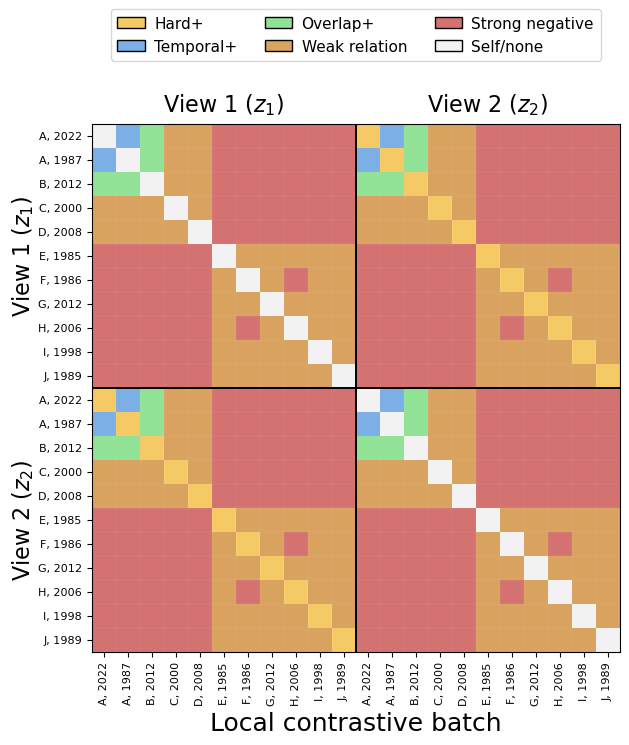

In [2]:
#!/usr/bin/env python3
# ==========================================================
# Visualize metadata-aware Basin2Vec relation matrix
# Updated for the new monthly/static Basin2Vec export.
#
# This version does NOT require the training Dataset/Encoder/checkpoint.
# It reads the exported NPZ directly:
#   basin_embeddings_full.npz
#
# Required NPZ keys:
#   embeddings, labels, years, basin_meta
# Optional NPZ keys:
#   avg_embeddings, avg_labels, year_counts, branch_attention
#
# Relations shown:
#   Hard+, Temporal+, Overlap+, Weak relation, Strong negative, Self/none
# ==========================================================

from __future__ import annotations

from pathlib import Path
import string
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch


# ----------------------------------------------------------
# CONFIG
# ----------------------------------------------------------
BASIN2VEC_NPZ = Path(
    "../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz"
)
BASIN2VEC_ARRAY_KEY = "embeddings"  # basin-year embeddings, shape [N_basin_year, D]

OVERLAP_PAIRS_PARQUET = Path("/data/basin2vec/cache/basin_overlap_pairs.parquet")

FIG_DIR = Path("results_figures/pair_relations_monthly")
TABLE_DIR = Path("results_tables/pair_relations_monthly")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
RNG = np.random.default_rng(SEED)

# These should match your monthly HCLV4 loss settings.
META_TAU = 1.5
YEAR_TAU = 8.0

# Visualization threshold only.
# Training can use continuous metadata weights, but the figure needs discrete categories.
WEAK_META_SIM_THRESHOLD = 0.65

# Number of examples to include around the anchor basin.
N_WEAK = 2
N_STRONG = 6

# Optional: set an anchor basin manually, e.g. "04101500".
ANCHOR_SITE_ID: Optional[str] = None

# Figure output size.
FIGSIZE = (10.2, 8.8)
DPI = 300


# ----------------------------------------------------------
# Generic helpers
# ----------------------------------------------------------
def normalize_site_id(x) -> Optional[str]:
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    s = "".join(ch for ch in s if ch.isdigit())
    if not s:
        return None
    return s.zfill(8) if len(s) <= 8 else s


def l2_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 1:
        x = x[None, :]
    return x / np.clip(np.linalg.norm(x, axis=1, keepdims=True), eps, None)


def savefig(path: Path, dpi: int = DPI):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved:", path)


def metadata_similarity_matrix(meta: np.ndarray, meta_tau: float = META_TAU) -> np.ndarray:
    """
    Convert standardized metadata vectors to pairwise similarity in [0, 1].
    This mirrors the Gaussian distance weighting used in the metadata-aware loss.
    """
    meta = np.nan_to_num(
        np.asarray(meta, dtype=np.float32),
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )
    if meta.ndim != 2:
        raise ValueError(f"meta must be [N, M], got shape={meta.shape}")

    diff = meta[:, None, :] - meta[None, :, :]
    d2 = np.sum(diff * diff, axis=-1) / max(float(meta.shape[1]), 1.0)
    sim = np.exp(-d2 / (2.0 * float(meta_tau) ** 2))
    return np.clip(sim, 0.0, 1.0).astype(np.float32)


def metadata_similarity_to_anchor(
    anchor_meta: np.ndarray,
    meta: np.ndarray,
    meta_tau: float = META_TAU,
) -> np.ndarray:
    """Memory-light anchor-to-all metadata similarity."""
    anchor_meta = np.nan_to_num(
        np.asarray(anchor_meta, dtype=np.float32).reshape(1, -1),
        nan=0.0,
    )
    meta = np.nan_to_num(np.asarray(meta, dtype=np.float32), nan=0.0)
    d2 = np.sum((meta - anchor_meta) ** 2, axis=1) / max(float(meta.shape[1]), 1.0)
    sim = np.exp(-d2 / (2.0 * float(meta_tau) ** 2))
    return np.clip(sim, 0.0, 1.0).astype(np.float32)


# ----------------------------------------------------------
# Load monthly Basin2Vec NPZ export
# ----------------------------------------------------------
def load_monthly_basin2vec_npz(npz_path: Path, array_key: str):
    npz_path = Path(npz_path)
    if not npz_path.exists():
        raise FileNotFoundError(f"Basin2Vec NPZ not found: {npz_path}")

    data = np.load(npz_path, allow_pickle=True)
    print("Basin2Vec NPZ:", npz_path)
    print("NPZ keys:", list(data.files))

    for required in [array_key, "labels", "years", "basin_meta"]:
        if required not in data.files:
            raise KeyError(
                f"Required key {required!r} not found in {npz_path}. "
                f"Available keys: {list(data.files)}"
            )

    emb = np.asarray(data[array_key], dtype=np.float32)
    labels = np.asarray(data["labels"])
    years = np.asarray(data["years"]).astype(int)
    basin_meta = np.asarray(data["basin_meta"], dtype=np.float32)

    if len(labels) != len(emb) or len(years) != len(emb) or len(basin_meta) != len(emb):
        raise ValueError(
            "NPZ length mismatch: "
            f"emb={len(emb)}, labels={len(labels)}, years={len(years)}, "
            f"basin_meta={len(basin_meta)}"
        )

    index_df = pd.DataFrame({
        "row": np.arange(len(emb), dtype=int),
        "site_id": [normalize_site_id(x) for x in labels],
        "year": years.astype(int),
    })

    valid = index_df["site_id"].notna().to_numpy()
    index_df = index_df.loc[valid].reset_index(drop=True)
    emb = emb[valid]
    basin_meta = basin_meta[valid]

    site_ids = sorted(index_df["site_id"].unique().tolist())
    site_to_int = {sid: i for i, sid in enumerate(site_ids)}
    int_to_site = {i: sid for sid, i in site_to_int.items()}
    index_df["site_id_int"] = index_df["site_id"].map(site_to_int).astype(int)

    print("Embedding rows:", emb.shape)
    print("Metadata rows:", basin_meta.shape)
    print("Unique basins:", index_df["site_id"].nunique())
    print("Year range:", int(index_df["year"].min()), "-", int(index_df["year"].max()))

    return index_df, emb, basin_meta, site_to_int, int_to_site


index_df, embeddings, basin_meta_rows, site_to_int, int_to_site = load_monthly_basin2vec_npz(
    BASIN2VEC_NPZ,
    BASIN2VEC_ARRAY_KEY,
)

# Normalize embeddings only for optional cosine diagnostics in saved table.
embeddings_norm = l2_normalize(
    np.nan_to_num(embeddings, nan=0.0, posinf=0.0, neginf=0.0)
)


# ----------------------------------------------------------
# Build basin-level metadata table by averaging basin-year metadata
# ----------------------------------------------------------
basin_meta_df = (
    pd.DataFrame({
        "site_id_int": index_df["site_id_int"].to_numpy(),
        "site_id": index_df["site_id"].to_numpy(),
        "meta_row": list(basin_meta_rows.astype(np.float32)),
    })
    .groupby(["site_id_int", "site_id"], as_index=False)
    .agg(
        basin_meta=(
            "meta_row",
            lambda x: np.stack(list(x)).mean(axis=0).astype(np.float32),
        )
    )
)

basin_meta_matrix = np.stack(basin_meta_df["basin_meta"].values).astype(np.float32)
sid_int_to_meta_row = {
    int(row.site_id_int): int(i)
    for i, row in basin_meta_df.reset_index(drop=True).iterrows()
}

all_basin_ints = sorted(index_df["site_id_int"].unique().astype(int).tolist())
all_basin_int_set = set(all_basin_ints)

print("Basin-level metadata matrix:", basin_meta_matrix.shape)


# ----------------------------------------------------------
# Load basin overlap graph
# ----------------------------------------------------------
def infer_overlap_id_columns(
    df: pd.DataFrame,
    valid_site_ids: Iterable[str],
) -> Tuple[str, str]:
    """Infer the two basin-id columns in an overlap-pair parquet."""
    valid_site_ids = set(valid_site_ids)
    scores = []

    for c in df.columns:
        sample = df[c].head(min(len(df), 20000))
        normed = [normalize_site_id(x) for x in sample]
        n_match = sum(1 for x in normed if x in valid_site_ids)

        if n_match > 0:
            scores.append((c, n_match))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    if len(scores) < 2:
        raise RuntimeError(
            "Could not infer two basin-id columns in overlap parquet. "
            f"Columns are: {df.columns.tolist()}"
        )

    return str(scores[0][0]), str(scores[1][0])


def infer_overlap_weight_column(
    df: pd.DataFrame,
    id_cols: Tuple[str, str],
) -> Optional[str]:
    preferred = [
        "overlap_weight",
        "weight",
        "overlap",
        "overlap_score",
        "score",
        "frac_overlap",
        "overlap_frac",
        "jaccard",
        "area_frac",
        "w",
    ]

    for c in preferred:
        if c in df.columns and c not in id_cols:
            return c

    numeric_candidates = []

    for c in df.columns:
        if c in id_cols:
            continue

        vals = pd.to_numeric(df[c], errors="coerce")
        finite = vals[np.isfinite(vals)]

        if len(finite) == 0:
            continue

        if finite.min() >= 0:
            numeric_candidates.append((c, float(finite.max()), float(finite.mean())))

    if not numeric_candidates:
        return None

    numeric_candidates = sorted(
        numeric_candidates,
        key=lambda t: (t[1] > 1.5, -t[2]),
    )
    return str(numeric_candidates[0][0])


def load_overlap_adjacency_from_parquet(
    path: Path,
    site_to_int: Dict[str, int],
) -> Tuple[Dict[int, Dict[int, float]], int, Tuple[str, str], Optional[str]]:
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Overlap parquet not found: {path}")

    df = pd.read_parquet(path)

    id_a, id_b = infer_overlap_id_columns(df, site_to_int.keys())
    weight_col = infer_overlap_weight_column(df, (id_a, id_b))

    adjacency: Dict[int, Dict[int, float]] = {}
    n_pairs = 0

    for _, row in df.iterrows():
        a = normalize_site_id(row[id_a])
        b = normalize_site_id(row[id_b])

        if a not in site_to_int or b not in site_to_int or a == b:
            continue

        ia = int(site_to_int[a])
        ib = int(site_to_int[b])

        if weight_col is None:
            w = 1.0
        else:
            w = pd.to_numeric(row[weight_col], errors="coerce")
            w = float(w) if np.isfinite(w) else 1.0

        adjacency.setdefault(ia, {})[ib] = max(
            float(w),
            adjacency.get(ia, {}).get(ib, 0.0),
        )
        adjacency.setdefault(ib, {})[ia] = max(
            float(w),
            adjacency.get(ib, {}).get(ia, 0.0),
        )
        n_pairs += 1

    return adjacency, n_pairs, (id_a, id_b), weight_col


overlap_adjacency, overlap_pair_count, overlap_id_cols, overlap_weight_col = (
    load_overlap_adjacency_from_parquet(
        OVERLAP_PAIRS_PARQUET,
        site_to_int,
    )
)

print("Overlap parquet:", OVERLAP_PAIRS_PARQUET)
print("Inferred overlap ID columns:", overlap_id_cols)
print("Inferred overlap weight column:", overlap_weight_col)
print("Loaded overlap pairs matched to NPZ basins:", overlap_pair_count)
print("Basins with overlap partners:", len(overlap_adjacency))


# ----------------------------------------------------------
# Choose a representative local batch
# ----------------------------------------------------------
def sample_one_index_for_basin(
    index_df: pd.DataFrame,
    basin_int: int,
    seed: int,
    year_not_equal: Optional[int] = None,
) -> int:
    rows = index_df[index_df["site_id_int"] == int(basin_int)].copy()

    if year_not_equal is not None:
        rows = rows[rows["year"].astype(int) != int(year_not_equal)]

    if len(rows) == 0:
        raise RuntimeError(f"No rows available for basin_int={basin_int}")

    return int(
        rows.sample(1, random_state=int(seed) % 2_000_000_000).iloc[0].name
    )


def choose_metadata_aware_visualization_indices(
    index_df: pd.DataFrame,
    overlap_adjacency: Dict[int, Dict[int, float]],
    basin_meta_matrix: np.ndarray,
    sid_int_to_meta_row: Dict[int, int],
    n_weak: int = N_WEAK,
    n_strong: int = N_STRONG,
    weak_threshold: float = WEAK_META_SIM_THRESHOLD,
    seed: int = SEED,
    anchor_site_id: Optional[str] = ANCHOR_SITE_ID,
):
    rng = np.random.default_rng(int(seed))

    basin_counts = index_df.groupby("site_id_int").size()

    candidate_basins = [
        int(b)
        for b in basin_counts.index
        if basin_counts.loc[b] >= 2
        and int(b) in overlap_adjacency
        and int(b) in sid_int_to_meta_row
    ]

    if anchor_site_id is not None:
        anchor_site_id_norm = normalize_site_id(anchor_site_id)

        if anchor_site_id_norm not in site_to_int:
            raise ValueError(f"ANCHOR_SITE_ID={anchor_site_id!r} not found in NPZ labels.")

        candidate_basins = [site_to_int[anchor_site_id_norm]]
    else:
        rng.shuffle(candidate_basins)

    for anchor_basin in candidate_basins:
        anchor_meta_row = sid_int_to_meta_row[anchor_basin]

        anchor_sim = metadata_similarity_to_anchor(
            basin_meta_matrix[anchor_meta_row],
            basin_meta_matrix,
            meta_tau=META_TAU,
        )

        overlap_set = set(int(x) for x in overlap_adjacency.get(anchor_basin, {}).keys())
        overlap_set = overlap_set.intersection(all_basin_int_set)

        if len(overlap_set) == 0:
            continue

        anchor_rows = index_df[index_df["site_id_int"] == anchor_basin].copy()

        if anchor_rows["year"].nunique() < 2:
            continue

        anchor_row = anchor_rows.sample(1, random_state=seed).iloc[0]
        anchor_idx = int(anchor_row.name)
        anchor_year = int(anchor_row["year"])

        try:
            temporal_idx = sample_one_index_for_basin(
                index_df,
                anchor_basin,
                seed + 1,
                year_not_equal=anchor_year,
            )
        except RuntimeError:
            continue

        overlap_candidates = []

        for p in overlap_set:
            if p not in all_basin_int_set:
                continue

            w = float(overlap_adjacency.get(anchor_basin, {}).get(p, 1.0))

            if len(index_df[index_df["site_id_int"] == p]) > 0:
                overlap_candidates.append((p, w))

        overlap_candidates = sorted(
            overlap_candidates,
            key=lambda x: x[1],
            reverse=True,
        )

        if not overlap_candidates:
            continue

        overlap_basin, overlap_weight = overlap_candidates[0]
        overlap_idx = sample_one_index_for_basin(
            index_df,
            overlap_basin,
            seed + 2,
        )

        non_overlap_basins = [
            b
            for b in all_basin_ints
            if b != anchor_basin
            and b not in overlap_set
            and b in sid_int_to_meta_row
        ]

        weak_candidates = []
        strong_candidates = []

        for b in non_overlap_basins:
            sim = float(anchor_sim[sid_int_to_meta_row[b]])

            if sim >= float(weak_threshold):
                weak_candidates.append((b, sim))
            else:
                strong_candidates.append((b, sim))

        weak_candidates = sorted(weak_candidates, key=lambda x: x[1], reverse=True)
        strong_candidates = sorted(strong_candidates, key=lambda x: x[1])

        if len(weak_candidates) < n_weak or len(strong_candidates) < n_strong:
            continue

        chosen_weak = weak_candidates[:n_weak]
        chosen_strong = strong_candidates[:n_strong]

        weak_indices = [
            sample_one_index_for_basin(index_df, b, seed + 100 + i)
            for i, (b, _) in enumerate(chosen_weak)
        ]

        strong_indices = [
            sample_one_index_for_basin(index_df, b, seed + 200 + i)
            for i, (b, _) in enumerate(chosen_strong)
        ]

        batch_indices = [anchor_idx, temporal_idx, overlap_idx] + weak_indices + strong_indices

        info = {
            "anchor_basin_int": int(anchor_basin),
            "anchor_site_id": int_to_site.get(anchor_basin, str(anchor_basin)),
            "anchor_year": int(anchor_year),
            "temporal_idx": int(temporal_idx),
            "overlap_basin_int": int(overlap_basin),
            "overlap_site_id": int_to_site.get(overlap_basin, str(overlap_basin)),
            "overlap_weight": float(overlap_weight),
            "weak_basins": [
                {
                    "basin_int": int(b),
                    "site_id": int_to_site.get(int(b), str(b)),
                    "meta_similarity_to_anchor": float(s),
                }
                for b, s in chosen_weak
            ],
            "strong_basins": [
                {
                    "basin_int": int(b),
                    "site_id": int_to_site.get(int(b), str(b)),
                    "meta_similarity_to_anchor": float(s),
                }
                for b, s in chosen_strong
            ],
        }

        return batch_indices, info

    raise RuntimeError(
        "Could not find a valid batch with temporal, overlap, weak, and strong examples. "
        "Try lowering WEAK_META_SIM_THRESHOLD or N_STRONG/N_WEAK."
    )


batch_indices, anchor_info = choose_metadata_aware_visualization_indices(
    index_df=index_df,
    overlap_adjacency=overlap_adjacency,
    basin_meta_matrix=basin_meta_matrix,
    sid_int_to_meta_row=sid_int_to_meta_row,
    n_weak=N_WEAK,
    n_strong=N_STRONG,
    weak_threshold=WEAK_META_SIM_THRESHOLD,
    seed=SEED,
    anchor_site_id=ANCHOR_SITE_ID,
)

print("\nAnchor info:")
for k, v in anchor_info.items():
    print(f"  {k}: {v}")

print("Batch row indices:", batch_indices)


# ----------------------------------------------------------
# Build local loss-space tensors from selected rows
# ----------------------------------------------------------
sel = index_df.loc[batch_indices].reset_index(drop=True).copy()
row_ids = sel["row"].to_numpy(dtype=int)

site_ids_int = sel["site_id_int"].to_numpy(dtype=int)
years_batch = sel["year"].to_numpy(dtype=int)
meta_batch = basin_meta_rows[row_ids].astype(np.float32)
z_base = embeddings_norm[row_ids].astype(np.float32)

# In the original contrastive loss, the matrix is built over [z1; z2].
# The exported NPZ already contains final embeddings, so we duplicate each
# selected row to represent View 1 and View 2 for relation visualization.
z = np.vstack([z_base, z_base]).astype(np.float32)
site_tensor = np.concatenate([site_ids_int, site_ids_int]).astype(int)
year_tensor = np.concatenate([years_batch, years_batch]).astype(int)
meta_tensor = np.vstack([meta_batch, meta_batch]).astype(np.float32)

B = len(batch_indices)
N = 2 * B

print("\nLocal batch size:", B)
print("Loss-space size [z1; z2]:", N)


# ----------------------------------------------------------
# Build relation masks
# ----------------------------------------------------------
eye = np.eye(N, dtype=bool)

same_basin = site_tensor[:, None] == site_tensor[None, :]
same_year = year_tensor[:, None] == year_tensor[None, :]

year_gap = np.abs(year_tensor[:, None] - year_tensor[None, :]).astype(np.float32)
temporal_decay = np.exp(-year_gap / float(YEAR_TAU)).astype(np.float32)

overlap_strength = np.zeros((N, N), dtype=np.float32)

for i in range(N):
    a = int(site_tensor[i])
    partners = overlap_adjacency.get(a, {})

    for j in range(N):
        if i == j:
            continue

        b = int(site_tensor[j])

        if b in partners:
            overlap_strength[i, j] = float(partners[b])

overlap_mask = overlap_strength > 0

meta_sim = metadata_similarity_matrix(meta_tensor, meta_tau=META_TAU)
cosine_sim = z @ z.T

hard_pos = same_basin & same_year & (~eye)
temporal_pos = same_basin & (~same_year) & (~eye)
overlap_pos = (~same_basin) & overlap_mask & (~eye)

non_positive = (~same_basin) & (~overlap_mask) & (~eye)
weak_rel = non_positive & (meta_sim >= float(WEAK_META_SIM_THRESHOLD))
strong_neg = non_positive & (meta_sim < float(WEAK_META_SIM_THRESHOLD))

print("Hard positives:", int(hard_pos.sum()))
print("Temporal positives:", int(temporal_pos.sum()))
print("Overlap positives:", int(overlap_pos.sum()))
print("Weak relations:", int(weak_rel.sum()))
print("Strong negatives:", int(strong_neg.sum()))


# ----------------------------------------------------------
# Prepare relation matrix
# 0 self/none, 1 strong negative, 2 weak relation,
# 3 overlap+, 4 temporal+, 5 hard+
# ----------------------------------------------------------
relation_mat = np.zeros((N, N), dtype=int)
relation_mat[strong_neg] = 1
relation_mat[weak_rel] = 2
relation_mat[overlap_pos] = 3
relation_mat[temporal_pos] = 4
relation_mat[hard_pos] = 5


# ----------------------------------------------------------
# Create short basin labels A, B, C, ...
# ----------------------------------------------------------
unique_batch_basin_ints: List[int] = []

for sid in site_ids_int.tolist():
    sid = int(sid)

    if sid not in unique_batch_basin_ints:
        unique_batch_basin_ints.append(sid)

letters = list(string.ascii_uppercase)

if len(unique_batch_basin_ints) > len(letters):
    raise ValueError("Too many unique basins for A-Z labels.")

basin_int_to_letter = {
    sid: letters[i]
    for i, sid in enumerate(unique_batch_basin_ints)
}

basin_letter_df = pd.DataFrame([
    {
        "short_label": basin_int_to_letter[sid],
        "site_id_int": int(sid),
        "usgs_site_id": int_to_site.get(int(sid), str(sid)),
    }
    for sid in unique_batch_basin_ints
])

basin_letter_csv = TABLE_DIR / "example_basin_letter_mapping_monthly.csv"
basin_letter_df.to_csv(basin_letter_csv, index=False)
print("Saved basin letter mapping:", basin_letter_csv)

caption_mapping = "; ".join([
    f"{row.short_label}: {row.usgs_site_id}"
    for _, row in basin_letter_df.iterrows()
])

caption_mapping_path = FIG_DIR / "fig_pair_relation_basin_letter_caption_mapping_monthly.txt"

with open(caption_mapping_path, "w") as f:
    f.write(caption_mapping)

print("Caption mapping:")
print(caption_mapping)


# ----------------------------------------------------------
# Save relation summary tables
# ----------------------------------------------------------
summary_df = pd.DataFrame({
    "relation": [
        "hard_positive",
        "temporal_positive",
        "overlap_positive",
        "weak_relation",
        "strong_negative",
    ],
    "count": [
        int(hard_pos.sum()),
        int(temporal_pos.sum()),
        int(overlap_pos.sum()),
        int(weak_rel.sum()),
        int(strong_neg.sum()),
    ],
})

summary_csv = TABLE_DIR / "relation_counts_monthly.csv"
summary_df.to_csv(summary_csv, index=False)
print("Saved relation counts:", summary_csv)

pair_rows = []

for i in range(N):
    for j in range(N):
        code = int(relation_mat[i, j])

        pair_rows.append({
            "i": i,
            "j": j,
            "site_i": int_to_site.get(int(site_tensor[i]), str(int(site_tensor[i]))),
            "site_j": int_to_site.get(int(site_tensor[j]), str(int(site_tensor[j]))),
            "year_i": int(year_tensor[i]),
            "year_j": int(year_tensor[j]),
            "relation_code": code,
            "metadata_similarity": float(meta_sim[i, j]),
            "overlap_strength": float(overlap_strength[i, j]),
            "temporal_decay": float(temporal_decay[i, j]),
            "embedding_cosine_similarity": float(cosine_sim[i, j]),
        })

pair_df = pd.DataFrame(pair_rows)

pair_csv = TABLE_DIR / "pair_relation_values_monthly.csv"
pair_df.to_csv(pair_csv, index=False)
print("Saved pair relation values:", pair_csv)


# ----------------------------------------------------------
# Axis labels
# ----------------------------------------------------------
sample_labels = []

for i in range(B):
    sid = int(site_ids_int[i])
    yr = int(years_batch[i])
    basin_letter = basin_int_to_letter[sid]
    sample_labels.append(f"{basin_letter}, {yr}")

axis_labels = sample_labels + sample_labels


# ----------------------------------------------------------
# Plot pair relation matrix
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)

colors = {
    "self": "#f2f2f2",
    "strong_neg": "#d47272",
    "weak": "#d9a35f",
    "overlap": "#91e197",
    "temporal": "#7cafe6",
    "hard": "#f5ca65",
}

cmap = ListedColormap([
    colors["self"],        # 0 self/none
    colors["strong_neg"],  # 1 strong negative
    colors["weak"],        # 2 weak relation
    colors["overlap"],     # 3 overlap+
    colors["temporal"],    # 4 temporal+
    colors["hard"],        # 5 hard+
])

norm = BoundaryNorm(np.arange(-0.5, 6.5, 1), cmap.N)

ax.imshow(
    relation_mat,
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
    aspect="equal",
)

ax.set_xlabel("Local contrastive batch", fontsize=18)

ax.set_xticks(np.arange(N))
ax.set_yticks(np.arange(N))
ax.set_xticklabels(axis_labels, rotation=90, fontsize=8)
ax.set_yticklabels(axis_labels, fontsize=8)

# Separator between z1 and z2 blocks.
ax.axhline(B - 0.5, color="black", linewidth=1.4)
ax.axvline(B - 0.5, color="black", linewidth=1.4)

# Subtle cell grid.
ax.set_xticks(np.arange(-0.5, N, 1), minor=True)
ax.set_yticks(np.arange(-0.5, N, 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.25, alpha=0.18)
ax.tick_params(which="minor", bottom=False, left=False)

# View labels.
ax.text(
    0.25,
    1.012,
    r"View 1 ($z_1$)",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=16,
)

ax.text(
    0.75,
    1.012,
    r"View 2 ($z_2$)",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=16,
)

ax.text(
    -0.130,
    0.75,
    r"View 1 ($z_1$)",
    transform=ax.transAxes,
    rotation=90,
    ha="center",
    va="center",
    fontsize=16,
)

ax.text(
    -0.130,
    0.25,
    r"View 2 ($z_2$)",
    transform=ax.transAxes,
    rotation=90,
    ha="center",
    va="center",
    fontsize=16,
)

legend_elements = [
    Patch(facecolor=colors["hard"], edgecolor="black", label="Hard+"),
    Patch(facecolor=colors["temporal"], edgecolor="black", label="Temporal+"),
    Patch(facecolor=colors["overlap"], edgecolor="black", label="Overlap+"),
    Patch(facecolor=colors["weak"], edgecolor="black", label="Weak relation"),
    Patch(facecolor=colors["strong_neg"], edgecolor="black", label="Strong negative"),
    Patch(facecolor=colors["self"], edgecolor="black", label="Self/none"),
]

ax.legend(
    handles=legend_elements,
    ncol=3,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.105),
    frameon=True,
    fontsize=11,
    handlelength=1.8,
    columnspacing=1.8,
    handletextpad=0.6,
    borderpad=0.45,
)

fig.subplots_adjust(
    left=0.16,
    right=0.985,
    bottom=0.22,
    top=0.82,
)

savefig(FIG_DIR / "pair_relation_matrix_metadata_aware_monthly.pdf")
savefig(FIG_DIR / "pair_relation_matrix_metadata_aware_monthly.png", dpi=DPI)

plt.show()


Overlapping selected basins:
  A: 08385522
  B: 08385630

Boundary assignment:
  Outer/larger basin : B (08385630)
  Inner/smaller basin: A (08385522)

Overlap pairs:
site_id_a site_id_b  overlap_score
 08385522  08385630            1.0
Saved: results_figures/overlap_basin_maps/overlap_basins_landcover_streams_usinset_compactpanel.png
Saved: results_figures/overlap_basin_maps/overlap_basins_landcover_streams_usinset_compactpanel.pdf


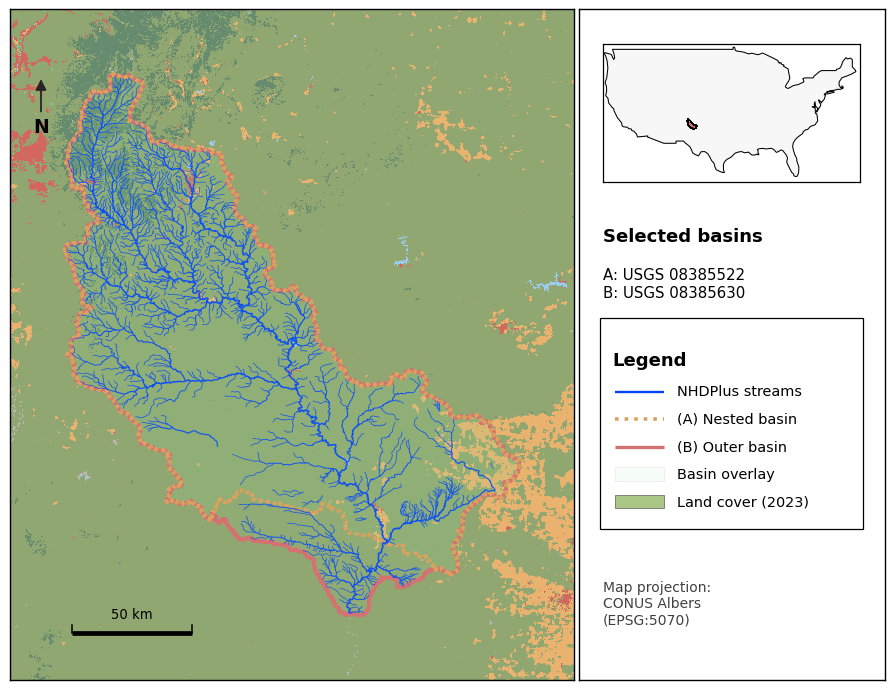

In [3]:
#!/usr/bin/env python3
# ==========================================================
# Publication-style overlapping basin map
# - Land cover visible inside and outside basin boundaries
# - NHDPlus streams
# - Larger/outer basin solid boundary
# - Smaller/nested basin dotted boundary
# - US inset map showing basin location
# - Legend in boxed side panel
# - Compact/tight layout
# ==========================================================

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap, BoundaryNorm

warnings.filterwarnings("ignore")

# ==========================================================
# CONFIG
# ==========================================================
BASIN_FILE = Path("/data/basin2vec/raw/gages-ii/geopackage/gages_basins.gpkg")
BASIN_LAYER = "gages_basins"

INDEX_PARQUET = Path("../config/training_step5/sample_index.parquet")
OVERLAP_PAIRS_PARQUET = Path("/data/basin2vec/cache/basin_overlap_pairs.parquet")

OUT_DIR = Path("results_figures/overlap_basin_maps")
OUT_DIR.mkdir(parents=True, exist_ok=True)

selected_ids = [
    "08385522",  # A
    "08385630",  # B
    "05464500",  # C
    "05344490",  # D
    "01484100",  # E
    "02309848",  # F
    "03250310",  # G
    "02197338",  # H
    "01589317",  # I
    "04163400",  # J
]

short_labels = {
    "08385522": "A",
    "08385630": "B",
    "05464500": "C",
    "05344490": "D",
    "01484100": "E",
    "02309848": "F",
    "03250310": "G",
    "02197338": "H",
    "01589317": "I",
    "04163400": "J",
}

colors = {
    "self": "#f2f2f2",
    "strong_neg": "#d47272",  # larger/outer basin boundary
    "weak": "#d9a35f",        # smaller/nested basin boundary
    "overlap": "#91e197",
    "temporal": "#7cafe6",
    "hard": "#f5ca65",
}

TARGET_CRS = "EPSG:5070"

ADD_STREAMS = True
ADD_LANDCOVER = True
LANDCOVER_YEAR = 2023
LANDCOVER_RESOLUTION_M = 90
SAVE_LAYERS = True

# Used both for land-cover request and final map extent
MAP_PAD_FRAC = 0.12


# ==========================================================
# HELPERS
# ==========================================================
def detect_site_id_column(gdf):
    for c in ["site_id", "SITE_ID", "STAID", "staid", "GAGE_ID", "gage_id", "GAGEID"]:
        if c in gdf.columns:
            return c
    raise ValueError(f"No site-id column found. Columns: {list(gdf.columns)}")


def normalize_site_id(x, target_len=8):
    return str(x).strip().zfill(target_len)


def recreate_training_site_mapping(index_parquet):
    index_df = pd.read_parquet(index_parquet).reset_index(drop=True)
    index_df["site_id"] = index_df["site_id"].astype(str).str.strip()

    target_len = int(index_df["site_id"].str.len().mode().iloc[0])
    index_df["site_id"] = index_df["site_id"].apply(
        lambda s: normalize_site_id(s, target_len)
    )

    unique_site_ids = sorted(index_df["site_id"].unique().tolist())
    site_to_int = {sid: i for i, sid in enumerate(unique_site_ids)}
    int_to_site = {i: sid for sid, i in site_to_int.items()}

    return index_df, site_to_int, int_to_site, target_len


def load_overlap_pairs(path):
    df = pd.read_parquet(path)

    required = {"site_id_int_a", "site_id_int_b"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Overlap file missing columns: {missing}")

    weight_col = None
    for c in ["overlap_score", "overlap_strength", "score", "weight"]:
        if c in df.columns:
            weight_col = c
            break

    return df, weight_col


def geom_union(gdf):
    try:
        return gdf.geometry.union_all()
    except Exception:
        return gdf.geometry.unary_union


def padded_bounds(gdf, pad_frac=0.08):
    xmin, ymin, xmax, ymax = gdf.total_bounds
    dx = max((xmax - xmin) * pad_frac, 1e-9)
    dy = max((ymax - ymin) * pad_frac, 1e-9)
    return xmin - dx, ymin - dy, xmax + dx, ymax + dy


def add_north_arrow(ax, x=0.055, y=0.90):
    ax.annotate(
        "N",
        xy=(x, y),
        xytext=(x, y - 0.075),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontsize=13.5,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-|>",
            color="0.15",
            lw=1.3,
            mutation_scale=16,
        ),
        zorder=30,
    )


def add_scale_bar(ax, length_km=50, location=(0.11, 0.07), linewidth=3.3):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    x0 = xmin + location[0] * (xmax - xmin)
    y0 = ymin + location[1] * (ymax - ymin)
    x1 = x0 + length_km * 1000.0

    ax.plot(
        [x0, x1],
        [y0, y0],
        color="black",
        lw=linewidth,
        solid_capstyle="butt",
        zorder=30,
    )
    ax.plot(
        [x0, x0],
        [y0, y0 + 0.012 * (ymax - ymin)],
        color="black",
        lw=1.1,
        zorder=30,
    )
    ax.plot(
        [x1, x1],
        [y0, y0 + 0.012 * (ymax - ymin)],
        color="black",
        lw=1.1,
        zorder=30,
    )

    ax.text(
        (x0 + x1) / 2,
        y0 + 0.018 * (ymax - ymin),
        f"{length_km} km",
        ha="center",
        va="bottom",
        fontsize=9.5,
        color="black",
        zorder=30,
    )


# ==========================================================
# STREAMS
# ==========================================================
def fetch_nhdplus_flowlines(basin_gdf):
    from pynhd import WaterData

    basin_4326 = basin_gdf.to_crs("EPSG:4326")
    xmin, ymin, xmax, ymax = padded_bounds(basin_4326, pad_frac=0.02)
    bbox = (xmin, ymin, xmax, ymax)

    wd = WaterData("nhdflowline_network")
    flowlines = wd.bybox(bbox)

    if flowlines is None or len(flowlines) == 0:
        raise RuntimeError("No NHDPlus flowlines returned.")

    if flowlines.crs is None:
        flowlines = flowlines.set_crs("EPSG:4326")

    return flowlines


def clip_flowlines_to_basins(flowlines, basin_gdf):
    flowlines = flowlines.to_crs(basin_gdf.crs)

    basin_union_gdf = gpd.GeoDataFrame(
        {"id": [1]},
        geometry=[geom_union(basin_gdf)],
        crs=basin_gdf.crs,
    )

    clipped = gpd.clip(flowlines, basin_union_gdf)

    if len(clipped) == 0:
        return clipped

    clipped = clipped[
        clipped.geometry.type.isin(["LineString", "MultiLineString"])
    ].copy()

    return clipped


def plot_streams(ax, flowlines_clip):
    if flowlines_clip is None or len(flowlines_clip) == 0:
        return

    order_col = None
    for c in ["streamorde", "streamorder", "StreamOrde", "STREAMORDE"]:
        if c in flowlines_clip.columns:
            order_col = c
            break

    if order_col is not None:
        tmp = flowlines_clip.copy()
        tmp[order_col] = pd.to_numeric(tmp[order_col], errors="coerce").fillna(1)
        tmp["_lw"] = 0.32 + 0.16 * tmp[order_col].clip(1, 8)

        for lw, group in tmp.groupby("_lw"):
            group.plot(
                ax=ax,
                color="#0047ff",
                linewidth=float(lw),
                alpha=0.90,
                zorder=8,
            )
    else:
        flowlines_clip.plot(
            ax=ax,
            color="#0047ff",
            linewidth=0.80,
            alpha=0.90,
            zorder=8,
        )


# ==========================================================
# LAND COVER
# ==========================================================
def fetch_online_lulc(basin_gdf, year=2023, resolution_m=90):
    """
    Fetch Microsoft Planetary Computer annual LULC for the padded map extent.

    This does NOT clip to basin geometry, so land cover remains visible
    outside basin boundaries.
    """
    try:
        from pystac_client import Client
        import planetary_computer
        import odc.stac
    except Exception as e:
        print("[WARN] Land-cover packages unavailable:", repr(e))
        return None

    try:
        basin_4326 = basin_gdf.to_crs("EPSG:4326")
        xmin, ymin, xmax, ymax = padded_bounds(basin_4326, pad_frac=MAP_PAD_FRAC)
        bbox = (xmin, ymin, xmax, ymax)

        catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
        search = catalog.search(
            collections=["io-lulc-annual-v02"],
            bbox=bbox,
            datetime=f"{year}-01-01/{year}-12-31",
        )

        items = list(search.items())
        if len(items) == 0:
            print("[WARN] No land-cover items returned.")
            return None

        signed_items = [planetary_computer.sign(item) for item in items]
        asset_names = list(signed_items[0].assets.keys())
        band_name = "data" if "data" in asset_names else asset_names[0]

        ds = odc.stac.load(
            signed_items,
            bands=[band_name],
            bbox=bbox,
            crs=basin_gdf.crs,
            resolution=resolution_m,
        )

        da = ds[band_name].isel(time=0).squeeze()
        return da

    except Exception as e:
        print("[WARN] Online land-cover fetch failed:", repr(e))
        return None


def plot_lulc(ax, lulc_da):
    if lulc_da is None:
        return False

    arr = np.squeeze(lulc_da.values).astype(float)
    if arr.ndim != 2:
        return False

    arr[arr <= 0] = np.nan

    x = lulc_da["x"].values
    y = lulc_da["y"].values
    extent = [float(x.min()), float(x.max()), float(y.min()), float(y.max())]
    origin = "upper" if y[0] > y[-1] else "lower"

    class_values = [1, 2, 4, 5, 7, 8, 9, 10, 11]
    class_colors = [
        "#74bdf5",  # water
        "#275c34",  # trees
        "#6674b9",  # flooded vegetation
        "#e49635",  # crops
        "#c4281b",  # built
        "#a59b8f",  # bare
        "#c5b6e8",  # snow/ice
        "#ffffff",  # clouds
        "#648538",  # rangeland/grass
    ]

    remapped = np.full_like(arr, np.nan, dtype=float)
    for i, val in enumerate(class_values, start=1):
        remapped[arr == val] = i

    cmap = ListedColormap(class_colors)
    cmap.set_bad(alpha=0.0)
    norm = BoundaryNorm(np.arange(0.5, len(class_values) + 1.5, 1), cmap.N)

    ax.imshow(
        remapped,
        extent=extent,
        origin=origin,
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
        alpha=0.70,
        zorder=0,
    )
    return True


# ==========================================================
# US INSET
# ==========================================================
def draw_us_inset(ax_inset, basin_union_wgs84):
    """
    Draw a simple USA map and highlight basin location.
    """
    try:
        usa = gpd.read_file(
            "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
        )
        usa = usa[usa["ADMIN"] == "United States of America"].to_crs("EPSG:4326")
    except Exception as e:
        print("[WARN] Could not load Natural Earth USA map:", repr(e))
        ax_inset.text(
            0.5,
            0.5,
            "USA map\nunavailable",
            ha="center",
            va="center",
            fontsize=8.5,
        )
        ax_inset.set_xticks([])
        ax_inset.set_yticks([])
        return

    usa.plot(
        ax=ax_inset,
        facecolor="#f7f7f7",
        edgecolor="black",
        linewidth=0.75,
        zorder=1,
    )

    basin_gdf = gpd.GeoDataFrame(
        {"id": [1]},
        geometry=[basin_union_wgs84],
        crs="EPSG:4326",
    )

    basin_gdf.plot(
        ax=ax_inset,
        facecolor=colors["strong_neg"],
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
    )

    ax_inset.set_xlim(-125, -66)
    ax_inset.set_ylim(24, 50)
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])

    for spine in ax_inset.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.9)


# ==========================================================
# LOAD BASINS
# ==========================================================
index_df, site_to_int, int_to_site, target_len = recreate_training_site_mapping(INDEX_PARQUET)

basins = gpd.read_file(BASIN_FILE, layer=BASIN_LAYER)
site_col = detect_site_id_column(basins)

basins[site_col] = basins[site_col].astype(str).str.strip()
basins[site_col] = basins[site_col].apply(lambda x: normalize_site_id(x, target_len))

if basins.crs is None:
    raise ValueError("Basin polygon file has no CRS.")

basins = basins.to_crs(TARGET_CRS)

selected_ids = [normalize_site_id(s, target_len) for s in selected_ids]
selected_basins = basins[basins[site_col].isin(selected_ids)].copy()

selected_ints = {site_to_int[sid] for sid in selected_ids if sid in site_to_int}

overlap_df, weight_col = load_overlap_pairs(OVERLAP_PAIRS_PARQUET)
pair_mask = (
    overlap_df["site_id_int_a"].isin(selected_ints)
    & overlap_df["site_id_int_b"].isin(selected_ints)
)
selected_overlap_df = overlap_df.loc[pair_mask].copy()

if len(selected_overlap_df) == 0:
    raise RuntimeError("No overlap pairs found among selected basins.")

selected_overlap_df["site_id_a"] = selected_overlap_df["site_id_int_a"].map(int_to_site)
selected_overlap_df["site_id_b"] = selected_overlap_df["site_id_int_b"].map(int_to_site)

overlap_site_ids = sorted(
    set(selected_overlap_df["site_id_a"]).union(set(selected_overlap_df["site_id_b"]))
)

overlap_basins = selected_basins[selected_basins[site_col].isin(overlap_site_ids)].copy()

# Automatically identify larger/outer and smaller/nested basins
area_df = overlap_basins[[site_col, "geometry"]].copy()
area_df["area_m2"] = area_df.geometry.area
area_df = area_df.sort_values("area_m2", ascending=False).reset_index(drop=True)

OUTER_BASIN_ID = str(area_df.loc[0, site_col])
INNER_BASIN_ID = str(area_df.loc[len(area_df) - 1, site_col])

print("\nOverlapping selected basins:")
for sid in overlap_site_ids:
    print(f"  {short_labels.get(sid, '?')}: {sid}")

print("\nBoundary assignment:")
print(f"  Outer/larger basin : {short_labels.get(OUTER_BASIN_ID, '?')} ({OUTER_BASIN_ID})")
print(f"  Inner/smaller basin: {short_labels.get(INNER_BASIN_ID, '?')} ({INNER_BASIN_ID})")

print("\nOverlap pairs:")
cols = ["site_id_a", "site_id_b"]
if weight_col is not None:
    cols.append(weight_col)
print(selected_overlap_df[cols].to_string(index=False))


# ==========================================================
# STREAMS + LAND COVER
# ==========================================================
flowlines_clip = None
if ADD_STREAMS:
    try:
        flowlines = fetch_nhdplus_flowlines(overlap_basins)
        flowlines_clip = clip_flowlines_to_basins(flowlines, overlap_basins)

        if SAVE_LAYERS and flowlines_clip is not None and len(flowlines_clip) > 0:
            flowlines_clip.to_file(
                OUT_DIR / "selected_overlap_nhdplus_flowlines.gpkg",
                layer="flowlines",
                driver="GPKG",
            )
    except Exception as e:
        print("[WARN] Stream download failed:", repr(e))
        flowlines_clip = None

lulc_da = None
if ADD_LANDCOVER:
    lulc_da = fetch_online_lulc(
        overlap_basins,
        year=LANDCOVER_YEAR,
        resolution_m=LANDCOVER_RESOLUTION_M,
    )


# ==========================================================
# PLOT
# ==========================================================
xmin, ymin, xmax, ymax = padded_bounds(overlap_basins, pad_frac=MAP_PAD_FRAC)
data_ratio = (xmax - xmin) / (ymax - ymin)

# Smaller figure and fixed narrower panel
fig_w, fig_h = 12.0, 7.8
fig = plt.figure(figsize=(fig_w, fig_h))

map_left = 0.035
map_bottom = 0.065
map_height = 0.86

# Match map frame to projected map aspect ratio
map_width = map_height * (fig_h / fig_w) * data_ratio

gap = 0.004
panel_width = 0.255

max_map_width = 0.965 - map_left - gap - panel_width
map_width = min(map_width, max_map_width)

panel_left = map_left + map_width + gap
panel_bottom = map_bottom
panel_height = map_height

ax = fig.add_axes([map_left, map_bottom, map_width, map_height])
ax_panel = fig.add_axes([panel_left, panel_bottom, panel_width, panel_height])

ax.set_facecolor("#f7f7f7")
ax_panel.set_facecolor("white")

has_lulc = plot_lulc(ax, lulc_da)

fill_alpha = 0.08 if has_lulc else 0.28
overlap_basins.plot(
    ax=ax,
    facecolor=colors["overlap"],
    edgecolor="none",
    alpha=fill_alpha,
    zorder=2,
)

# Larger/outer basin: solid red boundary
outer = overlap_basins[overlap_basins[site_col] == OUTER_BASIN_ID]
if len(outer) > 0:
    outer.plot(
        ax=ax,
        facecolor="none",
        edgecolor=colors["strong_neg"],
        linewidth=2.5,
        linestyle="-",
        zorder=7,
    )

# Smaller/nested basin: dotted orange boundary
inner = overlap_basins[overlap_basins[site_col] == INNER_BASIN_ID]
if len(inner) > 0:
    inner.plot(
        ax=ax,
        facecolor="none",
        edgecolor=colors["weak"],
        linewidth=2.5,
        linestyle=":",
        zorder=8,
    )

plot_streams(ax, flowlines_clip)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal", adjustable="box")

add_north_arrow(ax, x=0.055, y=0.90)
add_scale_bar(ax, length_km=50, location=(0.11, 0.07), linewidth=3.4)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.0)

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")


# ==========================================================
# SIDE PANEL
# ==========================================================
ax_panel.set_xticks([])
ax_panel.set_yticks([])

for spine in ax_panel.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.0)

# US inset map
ax_inset = ax_panel.inset_axes([0.08, 0.735, 0.84, 0.22])

basin_union_wgs84 = (
    gpd.GeoSeries([geom_union(overlap_basins)], crs=overlap_basins.crs)
    .to_crs("EPSG:4326")
    .iloc[0]
)
draw_us_inset(ax_inset, basin_union_wgs84)

# Selected basins text
ax_panel.text(
    0.08,
    0.675,
    "Selected basins",
    transform=ax_panel.transAxes,
    fontsize=13,
    fontweight="bold",
    ha="left",
    va="top",
)

selected_text = "\n".join(
    [f"{short_labels.get(sid, '?')}: USGS {sid}" for sid in overlap_site_ids]
)

ax_panel.text(
    0.08,
    0.615,
    selected_text,
    transform=ax_panel.transAxes,
    fontsize=10.8,
    ha="left",
    va="top",
)

# Legend box
legend_x, legend_y, legend_w, legend_h = 0.07, 0.225, 0.86, 0.315
legend_box = Rectangle(
    (legend_x, legend_y),
    legend_w,
    legend_h,
    transform=ax_panel.transAxes,
    facecolor="white",
    edgecolor="black",
    linewidth=0.9,
)
ax_panel.add_patch(legend_box)

ax_panel.text(
    legend_x + 0.04,
    legend_y + legend_h - 0.05,
    "Legend",
    transform=ax_panel.transAxes,
    fontsize=13,
    fontweight="bold",
    ha="left",
    va="top",
)

entries = [
    ("line", "#0047ff", "-", 1.7, "NHDPlus streams"),
    ("line", colors["weak"], ":", 2.6, "(A) Nested basin"),
    ("line", colors["strong_neg"], "-", 2.4, "(B) Outer basin"),
    ("patch", colors["overlap"], None, None, "Basin overlay"),
]

if has_lulc:
    entries.append(("patch", "#88b053", None, None, f"Land cover ({LANDCOVER_YEAR})"))

y0 = legend_y + legend_h - 0.11
dy = 0.041

for i, entry in enumerate(entries):
    kind, col, ls, lw, label = entry
    yy = y0 - i * dy

    if kind == "line":
        ax_panel.plot(
            [legend_x + 0.05, legend_x + 0.21],
            [yy, yy],
            transform=ax_panel.transAxes,
            color=col,
            linestyle=ls,
            linewidth=lw,
            solid_capstyle="butt",
            clip_on=False,
        )
    else:
        rect = Rectangle(
            (legend_x + 0.05, yy - 0.010),
            0.16,
            0.020,
            transform=ax_panel.transAxes,
            facecolor=col,
            edgecolor="0.35",
            linewidth=0.7,
            alpha=0.70 if "Land cover" in label else fill_alpha,
        )
        ax_panel.add_patch(rect)

    ax_panel.text(
        legend_x + 0.25,
        yy,
        label,
        transform=ax_panel.transAxes,
        fontsize=10.4,
        ha="left",
        va="center",
    )

ax_panel.text(
    0.08,
    0.08,
    "Map projection:\nCONUS Albers\n(EPSG:5070)",
    transform=ax_panel.transAxes,
    fontsize=10.0,
    ha="left",
    va="bottom",
    color="0.25",
)


# ==========================================================
# SAVE
# ==========================================================
png_path = OUT_DIR / "overlap_basins_landcover_streams_usinset_compactpanel.png"
pdf_path = OUT_DIR / "overlap_basins_landcover_streams_usinset_compactpanel.pdf"

plt.savefig(png_path, dpi=300)
plt.savefig(pdf_path)

print("Saved:", png_path)
print("Saved:", pdf_path)

plt.show()

Basin2Vec NPZ: ../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz
NPZ keys: ['embeddings', 'hydrologic_repr', 'z_multisource', 'z_monthly', 'z_static', 'labels', 'label_ints', 'years', 'basin_meta', 'area_target', 'area_pred', 'overlap_degree', 'branch_attention', 'avg_embeddings', 'avg_labels', 'year_counts']
Embedding rows: (362680, 64)
Metadata rows: (362680, 11)
Unique basins: 9067
Year range: 1985 - 2024
Basin-level metadata matrix: (9067, 11)
Overlap parquet: /data/basin2vec/cache/basin_overlap_pairs.parquet
Inferred overlap ID columns: ('site_id_a', 'site_id_b')
Inferred overlap weight column: overlap_score
Loaded overlap pairs matched to NPZ basins: 34291
Basins with overlap partners: 8099

Anchor info:
  anchor_basin_int: 6560
  anchor_site_id: 08385522
  anchor_year: 2022
  temporal_idx: 246940
  overlap_basin_int: 6561
  overlap_site_id: 08385630
  overlap_weight: 1.0
  weak_basins: [{'basin_int': 4110, 'site_id': '05464500', 'm

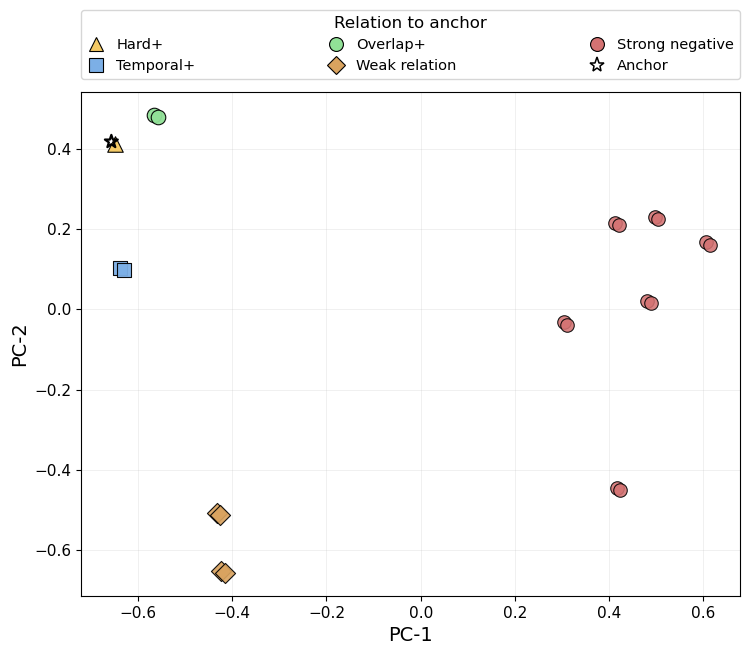

In [5]:
#!/usr/bin/env python3
# ==========================================================
# Local embedding neighborhood around anchor
# Updated for new monthly/static Basin2Vec NPZ export
#
# Relations:
#   0 = self/none
#   1 = strong negative
#   2 = weak relation
#   3 = overlap+
#   4 = temporal+
#   5 = hard+
# ==========================================================

from __future__ import annotations

from pathlib import Path
from typing import Dict, Iterable, Optional, Tuple, List

import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D


# ==========================================================
# CONFIG
# ==========================================================

BASIN2VEC_NPZ = Path(
    "../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz"
)

BASIN2VEC_ARRAY_KEY = "embeddings"

OVERLAP_PAIRS_PARQUET = Path("/data/basin2vec/cache/basin_overlap_pairs.parquet")

FIG_DIR = Path("results_figures/local_embedding_neighborhood_monthly")
TABLE_DIR = Path("results_tables/local_embedding_neighborhood_monthly")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
RNG = np.random.default_rng(SEED)

# Should match your HCLV4 monthly loss settings
META_TAU = 1.5
YEAR_TAU = 8.0

WEAK_META_SIM_THRESHOLD = 0.65

N_WEAK = 2
N_STRONG = 6

# Optional: set anchor manually, e.g. "04101500"
ANCHOR_SITE_ID: Optional[str] = None

# This makes duplicated View-2 points visible in the plot.
# It only changes plotting coordinates, not relations or saved similarities.
VISUAL_JITTER_DUPLICATE_VIEWS = True


# ==========================================================
# HELPERS
# ==========================================================

def normalize_site_id(x) -> Optional[str]:
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    s = "".join(ch for ch in s if ch.isdigit())

    if not s:
        return None

    return s.zfill(8) if len(s) <= 8 else s


def l2_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)

    if x.ndim == 1:
        x = x[None, :]

    return x / np.clip(np.linalg.norm(x, axis=1, keepdims=True), eps, None)


def savefig(path: Path, dpi: int = 300):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved:", path)


def pca_2d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    x_centered = x - x.mean(axis=0, keepdims=True)

    _, _, vt = np.linalg.svd(x_centered, full_matrices=False)

    return x_centered @ vt[:2].T


def metadata_similarity_matrix(meta: np.ndarray, meta_tau: float = META_TAU) -> np.ndarray:
    meta = np.nan_to_num(
        np.asarray(meta, dtype=np.float32),
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    diff = meta[:, None, :] - meta[None, :, :]
    d2 = np.sum(diff * diff, axis=-1) / max(float(meta.shape[1]), 1.0)

    sim = np.exp(-d2 / (2.0 * float(meta_tau) ** 2))

    return np.clip(sim, 0.0, 1.0).astype(np.float32)


def metadata_similarity_to_anchor(
    anchor_meta: np.ndarray,
    meta: np.ndarray,
    meta_tau: float = META_TAU,
) -> np.ndarray:
    anchor_meta = np.nan_to_num(
        np.asarray(anchor_meta, dtype=np.float32).reshape(1, -1),
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    meta = np.nan_to_num(
        np.asarray(meta, dtype=np.float32),
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    d2 = np.sum((meta - anchor_meta) ** 2, axis=1) / max(float(meta.shape[1]), 1.0)
    sim = np.exp(-d2 / (2.0 * float(meta_tau) ** 2))

    return np.clip(sim, 0.0, 1.0).astype(np.float32)


# ==========================================================
# LOAD MONTHLY BASIN2VEC NPZ
# ==========================================================

def load_monthly_basin2vec_npz(npz_path: Path, array_key: str):
    npz_path = Path(npz_path)

    if not npz_path.exists():
        raise FileNotFoundError(f"Basin2Vec NPZ not found: {npz_path}")

    data = np.load(npz_path, allow_pickle=True)

    print("Basin2Vec NPZ:", npz_path)
    print("NPZ keys:", list(data.files))

    required_keys = [array_key, "labels", "years", "basin_meta"]

    for k in required_keys:
        if k not in data.files:
            raise KeyError(f"Missing required NPZ key: {k}. Available keys: {list(data.files)}")

    emb = np.asarray(data[array_key], dtype=np.float32)
    labels = np.asarray(data["labels"])
    years = np.asarray(data["years"]).astype(int)
    basin_meta = np.asarray(data["basin_meta"], dtype=np.float32)

    if len(emb) != len(labels) or len(emb) != len(years) or len(emb) != len(basin_meta):
        raise ValueError(
            "NPZ length mismatch: "
            f"emb={len(emb)}, labels={len(labels)}, years={len(years)}, basin_meta={len(basin_meta)}"
        )

    index_df = pd.DataFrame(
        {
            "row": np.arange(len(emb), dtype=int),
            "site_id": [normalize_site_id(x) for x in labels],
            "year": years.astype(int),
        }
    )

    valid = index_df["site_id"].notna().to_numpy()

    index_df = index_df.loc[valid].reset_index(drop=True)
    emb = emb[valid]
    basin_meta = basin_meta[valid]

    site_ids = sorted(index_df["site_id"].unique().tolist())
    site_to_int = {sid: i for i, sid in enumerate(site_ids)}
    int_to_site = {i: sid for sid, i in site_to_int.items()}

    index_df["site_id_int"] = index_df["site_id"].map(site_to_int).astype(int)

    print("Embedding rows:", emb.shape)
    print("Metadata rows:", basin_meta.shape)
    print("Unique basins:", index_df["site_id"].nunique())
    print("Year range:", int(index_df["year"].min()), "-", int(index_df["year"].max()))

    return index_df, emb, basin_meta, site_to_int, int_to_site


index_df, embeddings, basin_meta_rows, site_to_int, int_to_site = load_monthly_basin2vec_npz(
    BASIN2VEC_NPZ,
    BASIN2VEC_ARRAY_KEY,
)

embeddings_norm = l2_normalize(
    np.nan_to_num(
        embeddings,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )
)


# ==========================================================
# BASIN-LEVEL METADATA TABLE
# ==========================================================

meta_tmp = pd.DataFrame(
    {
        "site_id_int": index_df["site_id_int"].to_numpy(),
        "site_id": index_df["site_id"].to_numpy(),
        "npz_row": index_df["row"].to_numpy(),
    }
)

basin_meta_rows_out = []

for (sid_int, site_id), sub in meta_tmp.groupby(["site_id_int", "site_id"]):
    rows = sub["npz_row"].to_numpy(dtype=int)
    meta_vec = basin_meta_rows[rows].mean(axis=0).astype(np.float32)

    basin_meta_rows_out.append(
        {
            "site_id_int": int(sid_int),
            "site_id": str(site_id),
            "basin_meta": meta_vec,
        }
    )

basin_meta_df = pd.DataFrame(basin_meta_rows_out)
basin_meta_matrix = np.stack(basin_meta_df["basin_meta"].values).astype(np.float32)

sid_int_to_meta_row = {
    int(row.site_id_int): int(i)
    for i, row in basin_meta_df.reset_index(drop=True).iterrows()
}

all_basin_ints = sorted(index_df["site_id_int"].unique().astype(int).tolist())
all_basin_int_set = set(all_basin_ints)

print("Basin-level metadata matrix:", basin_meta_matrix.shape)


# ==========================================================
# LOAD OVERLAP ADJACENCY
# ==========================================================

def infer_overlap_id_columns(
    df: pd.DataFrame,
    valid_site_ids: Iterable[str],
) -> Tuple[str, str]:
    valid_site_ids = set(valid_site_ids)
    scores = []

    for c in df.columns:
        sample = df[c].head(min(len(df), 20000))
        normed = [normalize_site_id(x) for x in sample]
        n_match = sum(1 for x in normed if x in valid_site_ids)

        if n_match > 0:
            scores.append((c, n_match))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    if len(scores) < 2:
        raise RuntimeError(
            "Could not infer two basin-id columns from overlap parquet. "
            f"Columns: {df.columns.tolist()}"
        )

    return str(scores[0][0]), str(scores[1][0])


def infer_overlap_weight_column(
    df: pd.DataFrame,
    id_cols: Tuple[str, str],
) -> Optional[str]:
    preferred = [
        "overlap_weight",
        "weight",
        "overlap",
        "overlap_score",
        "score",
        "frac_overlap",
        "overlap_frac",
        "jaccard",
        "area_frac",
        "w",
    ]

    for c in preferred:
        if c in df.columns and c not in id_cols:
            return c

    candidates = []

    for c in df.columns:
        if c in id_cols:
            continue

        vals = pd.to_numeric(df[c], errors="coerce")
        finite = vals[np.isfinite(vals)]

        if len(finite) == 0:
            continue

        if finite.min() >= 0:
            candidates.append((c, float(finite.max()), float(finite.mean())))

    if not candidates:
        return None

    candidates = sorted(candidates, key=lambda t: (t[1] > 1.5, -t[2]))

    return str(candidates[0][0])


def load_overlap_adjacency_from_parquet(
    path: Path,
    site_to_int: Dict[str, int],
):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Overlap parquet not found: {path}")

    df = pd.read_parquet(path)

    id_a, id_b = infer_overlap_id_columns(df, site_to_int.keys())
    weight_col = infer_overlap_weight_column(df, (id_a, id_b))

    adjacency: Dict[int, Dict[int, float]] = {}
    n_pairs = 0

    for _, row in df.iterrows():
        a = normalize_site_id(row[id_a])
        b = normalize_site_id(row[id_b])

        if a not in site_to_int or b not in site_to_int or a == b:
            continue

        ia = int(site_to_int[a])
        ib = int(site_to_int[b])

        if weight_col is None:
            w = 1.0
        else:
            w = pd.to_numeric(row[weight_col], errors="coerce")
            w = float(w) if np.isfinite(w) else 1.0

        adjacency.setdefault(ia, {})[ib] = max(
            float(w),
            adjacency.get(ia, {}).get(ib, 0.0),
        )
        adjacency.setdefault(ib, {})[ia] = max(
            float(w),
            adjacency.get(ib, {}).get(ia, 0.0),
        )

        n_pairs += 1

    return adjacency, n_pairs, (id_a, id_b), weight_col


overlap_adjacency, overlap_pair_count, overlap_id_cols, overlap_weight_col = (
    load_overlap_adjacency_from_parquet(
        OVERLAP_PAIRS_PARQUET,
        site_to_int,
    )
)

print("Overlap parquet:", OVERLAP_PAIRS_PARQUET)
print("Inferred overlap ID columns:", overlap_id_cols)
print("Inferred overlap weight column:", overlap_weight_col)
print("Loaded overlap pairs matched to NPZ basins:", overlap_pair_count)
print("Basins with overlap partners:", len(overlap_adjacency))


# ==========================================================
# CHOOSE REPRESENTATIVE LOCAL BATCH
# ==========================================================

def sample_one_index_for_basin(
    index_df: pd.DataFrame,
    basin_int: int,
    seed: int,
    year_not_equal: Optional[int] = None,
) -> int:
    rows = index_df[index_df["site_id_int"] == int(basin_int)].copy()

    if year_not_equal is not None:
        rows = rows[rows["year"].astype(int) != int(year_not_equal)]

    if len(rows) == 0:
        raise RuntimeError(f"No rows found for basin_int={basin_int}")

    return int(
        rows.sample(
            1,
            random_state=int(seed) % 2_000_000_000,
        ).iloc[0].name
    )


def choose_metadata_aware_visualization_indices(
    index_df: pd.DataFrame,
    overlap_adjacency: Dict[int, Dict[int, float]],
    basin_meta_matrix: np.ndarray,
    sid_int_to_meta_row: Dict[int, int],
    n_weak: int = N_WEAK,
    n_strong: int = N_STRONG,
    weak_threshold: float = WEAK_META_SIM_THRESHOLD,
    seed: int = SEED,
    anchor_site_id: Optional[str] = ANCHOR_SITE_ID,
):
    rng = np.random.default_rng(int(seed))

    basin_counts = index_df.groupby("site_id_int").size()

    candidate_basins = [
        int(b)
        for b in basin_counts.index
        if basin_counts.loc[b] >= 2
        and int(b) in overlap_adjacency
        and int(b) in sid_int_to_meta_row
    ]

    if anchor_site_id is not None:
        anchor_site_id_norm = normalize_site_id(anchor_site_id)

        if anchor_site_id_norm not in site_to_int:
            raise ValueError(f"ANCHOR_SITE_ID={anchor_site_id!r} not found in NPZ labels.")

        candidate_basins = [site_to_int[anchor_site_id_norm]]
    else:
        rng.shuffle(candidate_basins)

    for anchor_basin in candidate_basins:
        anchor_meta_row = sid_int_to_meta_row[anchor_basin]

        anchor_sim = metadata_similarity_to_anchor(
            basin_meta_matrix[anchor_meta_row],
            basin_meta_matrix,
            meta_tau=META_TAU,
        )

        overlap_set = set(int(x) for x in overlap_adjacency.get(anchor_basin, {}).keys())
        overlap_set = overlap_set.intersection(all_basin_int_set)

        if len(overlap_set) == 0:
            continue

        anchor_rows = index_df[index_df["site_id_int"] == anchor_basin].copy()

        if anchor_rows["year"].nunique() < 2:
            continue

        anchor_row = anchor_rows.sample(1, random_state=seed).iloc[0]
        anchor_idx = int(anchor_row.name)
        anchor_year = int(anchor_row["year"])

        try:
            temporal_idx = sample_one_index_for_basin(
                index_df=index_df,
                basin_int=anchor_basin,
                seed=seed + 1,
                year_not_equal=anchor_year,
            )
        except RuntimeError:
            continue

        overlap_candidates = []

        for p in overlap_set:
            if p not in all_basin_int_set:
                continue

            if len(index_df[index_df["site_id_int"] == p]) == 0:
                continue

            w = float(overlap_adjacency.get(anchor_basin, {}).get(p, 1.0))
            overlap_candidates.append((p, w))

        overlap_candidates = sorted(
            overlap_candidates,
            key=lambda x: x[1],
            reverse=True,
        )

        if not overlap_candidates:
            continue

        overlap_basin, overlap_weight = overlap_candidates[0]
        overlap_idx = sample_one_index_for_basin(
            index_df=index_df,
            basin_int=overlap_basin,
            seed=seed + 2,
        )

        non_overlap_basins = [
            b
            for b in all_basin_ints
            if b != anchor_basin
            and b not in overlap_set
            and b in sid_int_to_meta_row
        ]

        weak_candidates = []
        strong_candidates = []

        for b in non_overlap_basins:
            sim = float(anchor_sim[sid_int_to_meta_row[b]])

            if sim >= float(weak_threshold):
                weak_candidates.append((b, sim))
            else:
                strong_candidates.append((b, sim))

        weak_candidates = sorted(weak_candidates, key=lambda x: x[1], reverse=True)
        strong_candidates = sorted(strong_candidates, key=lambda x: x[1])

        if len(weak_candidates) < n_weak or len(strong_candidates) < n_strong:
            continue

        chosen_weak = weak_candidates[:n_weak]
        chosen_strong = strong_candidates[:n_strong]

        weak_indices = [
            sample_one_index_for_basin(index_df, b, seed + 100 + i)
            for i, (b, _) in enumerate(chosen_weak)
        ]

        strong_indices = [
            sample_one_index_for_basin(index_df, b, seed + 200 + i)
            for i, (b, _) in enumerate(chosen_strong)
        ]

        batch_indices = [anchor_idx, temporal_idx, overlap_idx] + weak_indices + strong_indices

        info = {
            "anchor_basin_int": int(anchor_basin),
            "anchor_site_id": int_to_site.get(anchor_basin, str(anchor_basin)),
            "anchor_year": int(anchor_year),
            "temporal_idx": int(temporal_idx),
            "overlap_basin_int": int(overlap_basin),
            "overlap_site_id": int_to_site.get(overlap_basin, str(overlap_basin)),
            "overlap_weight": float(overlap_weight),
            "weak_basins": [
                {
                    "basin_int": int(b),
                    "site_id": int_to_site.get(int(b), str(b)),
                    "meta_similarity_to_anchor": float(s),
                }
                for b, s in chosen_weak
            ],
            "strong_basins": [
                {
                    "basin_int": int(b),
                    "site_id": int_to_site.get(int(b), str(b)),
                    "meta_similarity_to_anchor": float(s),
                }
                for b, s in chosen_strong
            ],
        }

        return batch_indices, info

    raise RuntimeError(
        "Could not find a valid batch with temporal, overlap, weak, and strong examples. "
        "Try lowering WEAK_META_SIM_THRESHOLD or reducing N_WEAK/N_STRONG."
    )


batch_indices, anchor_info = choose_metadata_aware_visualization_indices(
    index_df=index_df,
    overlap_adjacency=overlap_adjacency,
    basin_meta_matrix=basin_meta_matrix,
    sid_int_to_meta_row=sid_int_to_meta_row,
    n_weak=N_WEAK,
    n_strong=N_STRONG,
    weak_threshold=WEAK_META_SIM_THRESHOLD,
    seed=SEED,
    anchor_site_id=ANCHOR_SITE_ID,
)

print("\nAnchor info:")
for k, v in anchor_info.items():
    print(f"  {k}: {v}")

print("Batch row indices:", batch_indices)


# ==========================================================
# BUILD LOCAL LOSS-SPACE REPRESENTATION
# ==========================================================

sel = index_df.loc[batch_indices].reset_index(drop=True).copy()
row_ids = sel["row"].to_numpy(dtype=int)

site_ids_int = sel["site_id_int"].to_numpy(dtype=int)
years_batch = sel["year"].to_numpy(dtype=int)
meta_batch = basin_meta_rows[row_ids].astype(np.float32)
z_base = embeddings_norm[row_ids].astype(np.float32)

# The original checkpoint-based script used stochastic z1/z2 views.
# The exported NPZ already contains final embeddings, so here we duplicate
# the selected embeddings to form [z1; z2] for relation visualization.
z_loss = np.vstack([z_base, z_base]).astype(np.float32)

site_tensor = np.concatenate([site_ids_int, site_ids_int]).astype(int)
year_tensor = np.concatenate([years_batch, years_batch]).astype(int)
meta_tensor = np.vstack([meta_batch, meta_batch]).astype(np.float32)

B = len(batch_indices)
N = 2 * B

print("\nLocal batch size:", B)
print("Loss-space size [z1; z2]:", N)


# ==========================================================
# BUILD RELATION MATRIX
# ==========================================================

eye = np.eye(N, dtype=bool)

same_basin = site_tensor[:, None] == site_tensor[None, :]
same_year = year_tensor[:, None] == year_tensor[None, :]

overlap_strength = np.zeros((N, N), dtype=np.float32)

for i in range(N):
    a = int(site_tensor[i])
    partners = overlap_adjacency.get(a, {})

    for j in range(N):
        if i == j:
            continue

        b = int(site_tensor[j])

        if b in partners:
            overlap_strength[i, j] = float(partners[b])

overlap_mask = overlap_strength > 0

meta_sim = metadata_similarity_matrix(meta_tensor, meta_tau=META_TAU)
cosine_sim = z_loss @ z_loss.T

hard_pos = same_basin & same_year & (~eye)
temporal_pos = same_basin & (~same_year) & (~eye)
overlap_pos = (~same_basin) & overlap_mask & (~eye)

non_positive = (~same_basin) & (~overlap_mask) & (~eye)
weak_rel = non_positive & (meta_sim >= float(WEAK_META_SIM_THRESHOLD))
strong_neg = non_positive & (meta_sim < float(WEAK_META_SIM_THRESHOLD))

relation_mat = np.zeros((N, N), dtype=int)
relation_mat[strong_neg] = 1
relation_mat[weak_rel] = 2
relation_mat[overlap_pos] = 3
relation_mat[temporal_pos] = 4
relation_mat[hard_pos] = 5

print("\nRelation counts:")
print("  Hard positives     :", int(hard_pos.sum()))
print("  Temporal positives :", int(temporal_pos.sum()))
print("  Overlap positives  :", int(overlap_pos.sum()))
print("  Weak relations     :", int(weak_rel.sum()))
print("  Strong negatives   :", int(strong_neg.sum()))


# ==========================================================
# SHORT BASIN LABELS
# ==========================================================

unique_batch_basin_ints: List[int] = []

for sid in site_ids_int.tolist():
    sid = int(sid)

    if sid not in unique_batch_basin_ints:
        unique_batch_basin_ints.append(sid)

letters = list(string.ascii_uppercase)

if len(unique_batch_basin_ints) > len(letters):
    raise ValueError("Too many unique basins for A-Z labels.")

basin_int_to_letter = {
    sid: letters[i]
    for i, sid in enumerate(unique_batch_basin_ints)
}

basin_letter_df = pd.DataFrame(
    [
        {
            "short_label": basin_int_to_letter[sid],
            "site_id_int": int(sid),
            "usgs_site_id": int_to_site.get(int(sid), str(sid)),
        }
        for sid in unique_batch_basin_ints
    ]
)

basin_letter_csv = TABLE_DIR / "local_embedding_basin_letter_mapping_monthly.csv"
basin_letter_df.to_csv(basin_letter_csv, index=False)
print("Saved basin mapping:", basin_letter_csv)

caption_mapping = "; ".join(
    [
        f"{row.short_label}: {row.usgs_site_id}"
        for _, row in basin_letter_df.iterrows()
    ]
)

caption_mapping_path = FIG_DIR / "local_embedding_basin_letter_caption_mapping_monthly.txt"

with open(caption_mapping_path, "w") as f:
    f.write(caption_mapping)

print("Caption mapping:")
print(caption_mapping)


# ==========================================================
# SAVE LOCAL TABLES
# ==========================================================

relation_name = {
    0: "self_none",
    1: "strong_negative",
    2: "weak_relation",
    3: "overlap_positive",
    4: "temporal_positive",
    5: "hard_positive",
}

anchor_idx = 0
anchor_relation = relation_mat[anchor_idx].copy()
anchor_relation[anchor_idx] = 0

point_rows = []

for i in range(N):
    basin_int = int(site_tensor[i])
    year = int(year_tensor[i])
    view = "z1" if i < B else "z2"
    local_i = i if i < B else i - B

    point_rows.append(
        {
            "point_index": int(i),
            "local_sample_index": int(local_i),
            "view": view,
            "short_label": basin_int_to_letter.get(basin_int, ""),
            "site_id_int": basin_int,
            "usgs_site_id": int_to_site.get(basin_int, str(basin_int)),
            "year": year,
            "relation_to_anchor_code": int(anchor_relation[i]),
            "relation_to_anchor": relation_name[int(anchor_relation[i])],
            "metadata_similarity_to_anchor": float(meta_sim[anchor_idx, i]),
            "overlap_strength_to_anchor": float(overlap_strength[anchor_idx, i]),
            "embedding_cosine_similarity_to_anchor": float(cosine_sim[anchor_idx, i]),
        }
    )

point_df = pd.DataFrame(point_rows)
point_csv = TABLE_DIR / "local_embedding_points_monthly.csv"
point_df.to_csv(point_csv, index=False)
print("Saved local embedding point table:", point_csv)

relation_counts = pd.DataFrame(
    {
        "relation": [
            "hard_positive",
            "temporal_positive",
            "overlap_positive",
            "weak_relation",
            "strong_negative",
        ],
        "count": [
            int(hard_pos.sum()),
            int(temporal_pos.sum()),
            int(overlap_pos.sum()),
            int(weak_rel.sum()),
            int(strong_neg.sum()),
        ],
    }
)

relation_counts_csv = TABLE_DIR / "local_embedding_relation_counts_monthly.csv"
relation_counts.to_csv(relation_counts_csv, index=False)
print("Saved relation counts:", relation_counts_csv)


# ==========================================================
# PCA PROJECTION
# ==========================================================

xy = pca_2d(z_loss)

# Make duplicate z2 points visible for plotting only.
if VISUAL_JITTER_DUPLICATE_VIEWS and B > 0:
    scale = np.nanstd(xy, axis=0)

    if not np.isfinite(scale[0]) or scale[0] <= 1e-12:
        scale[0] = 1.0

    if not np.isfinite(scale[1]) or scale[1] <= 1e-12:
        scale[1] = 1.0

    xy[B:, 0] += 0.015 * scale[0]
    xy[B:, 1] -= 0.015 * scale[1]

point_df["pc1"] = xy[:, 0]
point_df["pc2"] = xy[:, 1]
point_df.to_csv(point_csv, index=False)


# ==========================================================
# PLOT LOCAL EMBEDDING NEIGHBORHOOD
# ==========================================================

colors_plot = {
    "self": "#f2f2f2",
    "strong_neg": "#d47272",
    "weak": "#d9a35f",
    "overlap": "#91e197",
    "temporal": "#7cafe6",
    "hard": "#f5ca65",
}

relation_color = {
    0: colors_plot["self"],
    1: colors_plot["strong_neg"],
    2: colors_plot["weak"],
    3: colors_plot["overlap"],
    4: colors_plot["temporal"],
    5: colors_plot["hard"],
}

relation_marker = {
    1: "o",   # Strong negative
    2: "D",   # Weak relation
    3: "o",   # Overlap+
    4: "s",   # Temporal+
    5: "^",   # Hard+
}

relation_size = {
    1: 95,
    2: 105,
    3: 110,
    4: 115,
    5: 125,
}

relation_alpha = {
    1: 0.88,
    2: 0.92,
    3: 0.95,
    4: 0.95,
    5: 0.98,
}

relation_zorder = {
    1: 2,
    2: 3,
    3: 4,
    4: 5,
    5: 6,
}

fig, ax = plt.subplots(figsize=(7.4, 7.2))

# Plot relation groups from negative/far to positive/close.
for r_value in [1, 2, 3, 4, 5]:
    mask_r = anchor_relation == r_value

    if mask_r.sum() == 0:
        continue

    ax.scatter(
        xy[mask_r, 0],
        xy[mask_r, 1],
        s=relation_size[r_value],
        c=relation_color[r_value],
        marker=relation_marker[r_value],
        edgecolors="black",
        linewidths=0.8,
        alpha=relation_alpha[r_value],
        zorder=relation_zorder[r_value],
    )

# Self/none points, excluding anchor.
mask_none = anchor_relation == 0
mask_none[anchor_idx] = False

if mask_none.sum() > 0:
    ax.scatter(
        xy[mask_none, 0],
        xy[mask_none, 1],
        s=50,
        c=relation_color[0],
        marker="o",
        edgecolors="black",
        linewidths=0.5,
        alpha=0.40,
        zorder=1,
    )

# Anchor point.
ax.scatter(
    xy[anchor_idx, 0],
    xy[anchor_idx, 1],
    s=95,
    facecolors="none",
    edgecolors="black",
    marker="*",
    linewidths=1.6,
    zorder=10,
)

ax.set_xlabel("PC-1", fontsize=14)
ax.set_ylabel("PC-2", fontsize=14)

ax.grid(True, linestyle="-", linewidth=0.6, alpha=0.22)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

ax.tick_params(axis="both", labelsize=11)

legend_elements = [
    Line2D(
        [0], [0],
        marker="^",
        color="w",
        markerfacecolor=relation_color[5],
        markeredgecolor="black",
        markeredgewidth=0.8,
        markersize=10,
        linestyle="None",
        label="Hard+",
    ),
    Line2D(
        [0], [0],
        marker="s",
        color="w",
        markerfacecolor=relation_color[4],
        markeredgecolor="black",
        markeredgewidth=0.8,
        markersize=10,
        linestyle="None",
        label="Temporal+",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=relation_color[3],
        markeredgecolor="black",
        markeredgewidth=0.8,
        markersize=10,
        linestyle="None",
        label="Overlap+",
    ),
    Line2D(
        [0], [0],
        marker="D",
        color="w",
        markerfacecolor=relation_color[2],
        markeredgecolor="black",
        markeredgewidth=0.8,
        markersize=9,
        linestyle="None",
        label="Weak relation",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=relation_color[1],
        markeredgecolor="black",
        markeredgewidth=0.8,
        markersize=10,
        linestyle="None",
        label="Strong negative",
    ),
    Line2D(
        [0], [0],
        marker="*",
        color="w",
        markerfacecolor="none",
        markeredgecolor="black",
        markeredgewidth=1.1,
        markersize=11,
        linestyle="None",
        label="Anchor",
    ),
]

ax.legend(
    handles=legend_elements,
    ncol=3,
    loc="lower left",
    bbox_to_anchor=(0.0, 1.025, 1.0, 0.16),
    mode="expand",
    borderaxespad=0.0,
    frameon=True,
    fontsize=10.5,
    title="Relation to anchor",
    title_fontsize=12,
    handlelength=1.2,
    columnspacing=1.3,
)

fig.subplots_adjust(
    left=0.10,
    right=0.99,
    bottom=0.10,
    top=0.80,
)

savefig(FIG_DIR / "local_embedding_neighborhood_anchor_metadata_aware_monthly.pdf")
savefig(FIG_DIR / "local_embedding_neighborhood_anchor_metadata_aware_monthly.png", dpi=300)

plt.show()

Loading GAGES-II basins...
Loaded basins: 9,067
Building basin union geometry...

Loading HUC-2 regions...
Intersecting selected HUC-2 regions with basin domain...

HUC-2 regions selected: 18
huc2                       name
  01         New England Region
  02        Mid Atlantic Region
  03 South Atlantic-Gulf Region
  04         Great Lakes Region
  05                Ohio Region
  06           Tennessee Region
  07   Upper Mississippi Region
  08   Lower Mississippi Region
  09    Souris-Red-Rainy Region
  10            Missouri Region
  11  Arkansas-White-Red Region
  12          Texas-Gulf Region
  13          Rio Grande Region
  14      Upper Colorado Region
  15      Lower Colorado Region
  16         Great Basin Region
  17   Pacific Northwest Region
  18          California Region

Loading stream layer: nhdflowline_network

Processing HUC-2 12: Texas-Gulf Region | nhdflowline_network
  downloaded and cached: 53,136 flowlines

Processing HUC-2 05: Ohio Region | nhdflowline_netwo

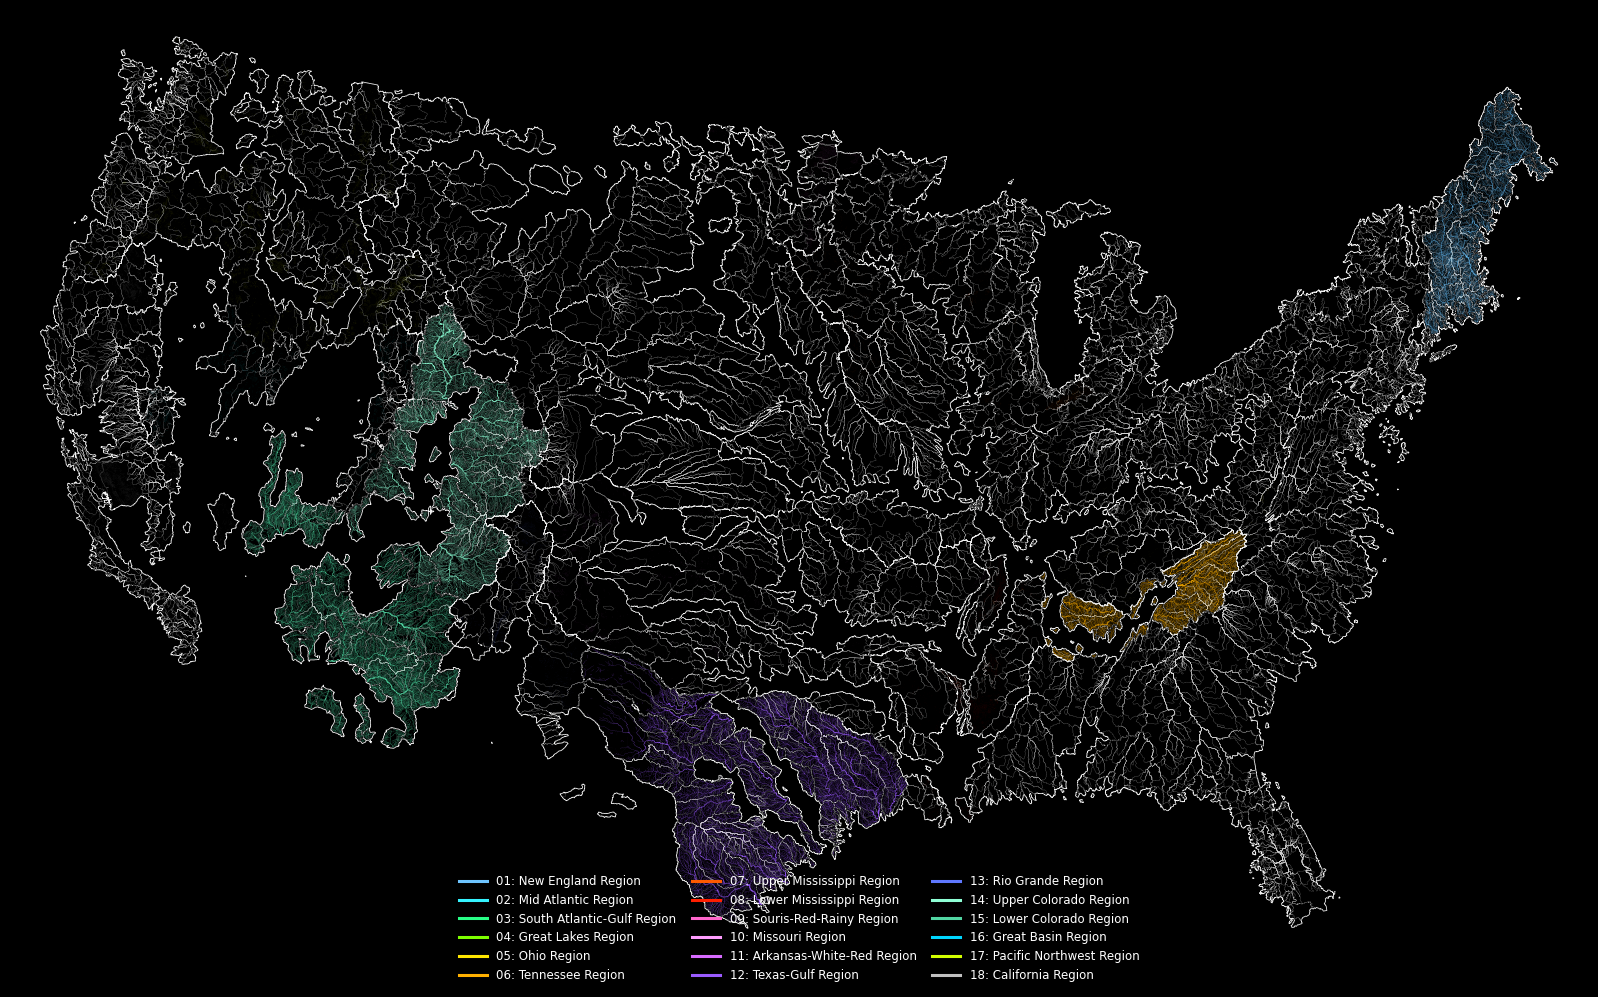

In [1]:
#!/usr/bin/env python3
# ==========================================================
# CONUS Basin2Vec overview map
# - All GAGES-II basin boundaries
# - ALL NHDPlus streams:
#     1) nhdflowline_network
#     2) nhdflowline_nonnetwork
# - Streams colored by HUC-2 hydrologic region
# - Dark-map style
# ==========================================================

from pathlib import Path
import warnings
import hashlib

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")


# ==========================================================
# CONFIG
# ==========================================================

BASIN_FILE = Path("/data/basin2vec/raw/gages-ii/geopackage/gages_basins.gpkg")
BASIN_LAYER = "gages_basins"

HUC2_FILE = Path(
    "/home/talhamuh/basin2vec/emb/evaluation/results_figures/conus_overview/"
    "Watershed_Boundary_Dataset_HUC_2s_-6944941387790115950.geojson"
)

OUT_DIR = Path("evaluation/results_figures/conus_huc2_overview_all_streams")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# New cache directory so old major-river-only cache is not reused
STREAM_CACHE_DIR = OUT_DIR / "nhdplus_all_flowlines_by_huc2_cache"
STREAM_CACHE_DIR.mkdir(parents=True, exist_ok=True)

TARGET_CRS = "EPSG:5070"  # CONUS Albers
FIGSIZE = (18, 10)

# ----------------------------------------------------------
# Stream layers
# ----------------------------------------------------------
# network = routed/major NHDPlus flowline network
# nonnetwork = smaller/non-routed flowlines and tributaries
STREAM_LAYERS = (
    "nhdflowline_network",
    "nhdflowline_nonnetwork",
)

# ----------------------------------------------------------
# Speed / detail controls
# ----------------------------------------------------------
# True  = streams only inside GAGES-II basin union; slower but focused.
# False = streams inside full HUC-2 regions intersecting your basin domain; faster clip,
#         but shows more streams outside basin polygons.
CLIP_STREAMS_TO_BASINS = True

# For testing, set this to e.g. ["03"] or ["03", "06"].
# For final CONUS figure, keep None.
HUC2_SUBSET = None

# Simplification for plotting speed and file size
BASIN_SIMPLIFY_M = 120.0
HUC2_SIMPLIFY_M = 500.0
STREAM_SIMPLIFY_M = 100.0

# Use cached combined all-stream file if available
USE_COMBINED_STREAM_CACHE = True

# Set True only if you want to force re-download/rebuild
FORCE_REBUILD_STREAM_CACHE = False

# PDF with all streams can be extremely large/slow.
SAVE_PDF = False

# Plot style
BACKGROUND = "black"

BASIN_BOUNDARY_COLOR = "#d9d9d9"
BASIN_BOUNDARY_LW = 0.18
BASIN_BOUNDARY_ALPHA = 0.55

HUC2_OUTLINE_COLOR = "#f2f2f2"
HUC2_OUTLINE_LW = 0.55
HUC2_OUTLINE_ALPHA = 0.90

DRAW_LEGEND = True
LEGEND_NCOL = 3

# Stream linewidths
# Keep small streams thin, otherwise the map becomes visually saturated.
NONNETWORK_LW = 0.045
NONNETWORK_ALPHA = 0.32

LOW_ORDER_LW = 0.10
MID_ORDER_LW = 0.18
HIGH_ORDER_LW = 0.35
MAIN_ORDER_LW = 0.70

STREAM_RASTERIZED = True


# ==========================================================
# HELPERS
# ==========================================================

STREAM_ORDER_CANDIDATES = [
    "streamorde",
    "streamorder",
    "StreamOrde",
    "STREAMORDE",
    "stream_order",
    "ORDER_",
    "strmOrder",
]


def load_vector(path, layer=None):
    path = Path(path)
    suffix = path.suffix.lower()

    if suffix == ".parquet":
        return gpd.read_parquet(path)

    if layer is not None:
        return gpd.read_file(path, layer=layer)

    return gpd.read_file(path)


def simplify_if_needed(gdf, tol):
    if tol is None or tol <= 0:
        return gdf

    gdf = gdf.copy()
    gdf["geometry"] = gdf.geometry.simplify(tol, preserve_topology=True)
    gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()
    return gdf


def geom_union(gdf):
    try:
        return gdf.geometry.union_all()
    except Exception:
        return gdf.geometry.unary_union


def make_one_geom_gdf(gdf, name="union"):
    return gpd.GeoDataFrame(
        {"id": [name]},
        geometry=[geom_union(gdf)],
        crs=gdf.crs,
    )


def normalize_huc2_column(huc2):
    huc2 = huc2.copy()

    if "huc2" not in huc2.columns:
        raise ValueError("Expected HUC-2 file to contain a column named 'huc2'.")

    if "name" not in huc2.columns:
        huc2["name"] = huc2["huc2"].astype(str)

    huc2["huc2"] = huc2["huc2"].astype(str).str.strip().str.zfill(2)
    huc2["name"] = huc2["name"].astype(str).str.strip()

    return huc2


def get_stream_order_column(gdf):
    for c in STREAM_ORDER_CANDIDATES:
        if c in gdf.columns:
            return c
    return None


def keep_light_stream_columns(gdf):
    """
    Keep only columns needed for plotting/caching.
    This makes parquet caches smaller and plotting faster.
    """
    keep = ["geometry"]

    for c in STREAM_ORDER_CANDIDATES:
        if c in gdf.columns and c not in keep:
            keep.append(c)

    optional_cols = [
        "comid",
        "COMID",
        "fcode",
        "FCode",
        "ftype",
        "FType",
        "gnis_name",
        "GNIS_Name",
        "reachcode",
        "ReachCode",
    ]

    for c in optional_cols:
        if c in gdf.columns and c not in keep:
            keep.append(c)

    return gdf[keep].copy()


def filter_line_geometries(gdf):
    if gdf is None or len(gdf) == 0:
        return gdf

    gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()

    if len(gdf) == 0:
        return gdf

    # Explode after clipping because clipping can create multi-part geometries
    try:
        gdf = gdf.explode(index_parts=False).reset_index(drop=True)
    except Exception:
        gdf = gdf.explode().reset_index(drop=True)

    gdf = gdf[
        gdf.geometry.geom_type.isin(["LineString", "MultiLineString"])
    ].copy()

    return gdf


def make_stream_cache_key(huc2_gdf, stream_layers, clip_to_basins, simplify_m):
    hucs = sorted(huc2_gdf["huc2"].astype(str).str.zfill(2).unique().tolist())
    text = "|".join(hucs) + "|" + "|".join(stream_layers)
    text += f"|clip={clip_to_basins}|simp={simplify_m}"
    digest = hashlib.md5(text.encode("utf-8")).hexdigest()[:10]
    return digest


def get_huc2_subsets(huc2, basin_union):
    """
    Returns:
      huc2_full_subset:
        full HUC-2 polygons that intersect the basin domain.
        Used for downloading/clipping streams by HUC-2.

      huc2_intersections:
        HUC-2 polygons intersected with basin union.
        Used for focused outlines/legend/domain plot.
    """
    basin_geom = basin_union.geometry.iloc[0]

    huc2_full_subset = huc2[huc2.intersects(basin_geom)].copy()

    if HUC2_SUBSET is not None:
        subset = [str(h).zfill(2) for h in HUC2_SUBSET]
        huc2_full_subset = huc2_full_subset[
            huc2_full_subset["huc2"].isin(subset)
        ].copy()

    if len(huc2_full_subset) == 0:
        raise RuntimeError("No HUC-2 regions intersect the basin domain.")

    print("Intersecting selected HUC-2 regions with basin domain...")
    huc2_intersections = gpd.overlay(
        huc2_full_subset[["huc2", "name", "geometry"]],
        basin_union,
        how="intersection",
    )

    huc2_intersections = simplify_if_needed(huc2_intersections, HUC2_SIMPLIFY_M)

    return huc2_full_subset, huc2_intersections


def fetch_streams_by_huc2_online(
    huc2_full_gdf,
    basin_union_gdf,
    target_crs,
    cache_dir,
    clip_to_basins=True,
    simplify_m=100.0,
    stream_layers=("nhdflowline_network", "nhdflowline_nonnetwork"),
    use_combined_cache=True,
    force_rebuild=False,
):
    """
    Download NHDPlus flowlines HUC-2 by HUC-2 using PyNHD.

    This loads both major routed streams and smaller non-network flowlines.
    Each HUC-2 and layer is cached separately.
    A combined cache is also written for faster repeated plotting.
    """
    from pynhd import WaterData

    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    cache_key = make_stream_cache_key(
        huc2_full_gdf,
        stream_layers,
        clip_to_basins,
        simplify_m,
    )

    combined_cache_path = cache_dir / f"combined_all_streams_{cache_key}.parquet"

    if (
        use_combined_cache
        and combined_cache_path.exists()
        and not force_rebuild
    ):
        print(f"\nLoading combined stream cache:")
        print(f"  {combined_cache_path}")
        streams = gpd.read_parquet(combined_cache_path)
        streams = streams.to_crs(target_crs)
        return streams

    huc2_4326 = huc2_full_gdf.to_crs("EPSG:4326")
    basin_union_target = basin_union_gdf.to_crs(target_crs)

    all_parts = []

    for layer in stream_layers:
        print("\n" + "=" * 80)
        print(f"Loading stream layer: {layer}")
        print("=" * 80)

        wd = WaterData(layer)

        for _, row in huc2_4326.iterrows():
            huc = str(row["huc2"]).zfill(2)
            name = str(row["name"])

            layer_short = layer.replace("nhdflowline_", "")
            cache_path = cache_dir / f"{layer_short}_huc2_{huc}_simp{int(simplify_m or 0)}_clip{int(clip_to_basins)}.parquet"

            print(f"\nProcessing HUC-2 {huc}: {name} | {layer}")

            if cache_path.exists() and not force_rebuild:
                part = gpd.read_parquet(cache_path)
                all_parts.append(part)
                print(f"  loaded cache: {len(part):,} flowlines")
                continue

            try:
                bbox = row.geometry.bounds

                # Download by HUC-2 bounding box in EPSG:4326
                part = wd.bybox(bbox)

                if part is None or len(part) == 0:
                    print("  no flowlines returned")
                    continue

                if part.crs is None:
                    part = part.set_crs("EPSG:4326")

                part = part.to_crs(target_crs)
                part = filter_line_geometries(part)

                if part is None or len(part) == 0:
                    print("  no line geometries returned")
                    continue

                # Full HUC-2 polygon in target CRS
                huc_poly = gpd.GeoDataFrame(
                    {"huc2": [huc], "name": [name]},
                    geometry=[
                        gpd.GeoSeries([row.geometry], crs="EPSG:4326")
                        .to_crs(target_crs)
                        .iloc[0]
                    ],
                    crs=target_crs,
                )

                # Clip to full HUC-2 polygon to remove bbox spillover
                part = gpd.clip(part, huc_poly)
                part = filter_line_geometries(part)

                if part is None or len(part) == 0:
                    print("  empty after HUC-2 clipping")
                    continue

                if clip_to_basins:
                    # This is the slowest step, but keeps streams inside basin domain.
                    part = gpd.clip(part, basin_union_target)
                    part = filter_line_geometries(part)

                if part is None or len(part) == 0:
                    print("  empty after basin clipping")
                    continue

                if simplify_m is not None and simplify_m > 0:
                    part["geometry"] = part.geometry.simplify(
                        simplify_m,
                        preserve_topology=True,
                    )
                    part = filter_line_geometries(part)

                if part is None or len(part) == 0:
                    print("  empty after simplification")
                    continue

                # Keep only useful columns to reduce cache size
                part = keep_light_stream_columns(part)

                part["huc2"] = huc
                part["name"] = name
                part["source_layer"] = layer

                part = gpd.GeoDataFrame(part, geometry="geometry", crs=target_crs)

                part.to_parquet(cache_path)
                all_parts.append(part)

                print(f"  downloaded and cached: {len(part):,} flowlines")

            except Exception as e:
                print(f"  [WARN] failed for HUC-2 {huc}, layer {layer}: {repr(e)}")
                continue

    if len(all_parts) == 0:
        raise RuntimeError("No NHDPlus streams were downloaded or loaded from cache.")

    streams_huc = pd.concat(all_parts, ignore_index=True)
    streams_huc = gpd.GeoDataFrame(streams_huc, geometry="geometry", crs=target_crs)

    streams_huc["huc2"] = streams_huc["huc2"].astype(str).str.zfill(2)
    streams_huc["name"] = streams_huc["name"].astype(str)
    streams_huc["source_layer"] = streams_huc["source_layer"].astype(str)

    if use_combined_cache:
        streams_huc.to_parquet(combined_cache_path)
        print(f"\nSaved combined stream cache:")
        print(f"  {combined_cache_path}")

    return streams_huc


def plot_network_streams_by_order(ax, network, color):
    """
    Plot routed network flowlines using stream order if available.
    """
    if network is None or len(network) == 0:
        return

    order_col = get_stream_order_column(network)

    if order_col is not None:
        tmp = network.copy()
        tmp[order_col] = pd.to_numeric(tmp[order_col], errors="coerce").fillna(1)

        bins = [
            (1, 2, LOW_ORDER_LW, 0.68),
            (3, 4, MID_ORDER_LW, 0.80),
            (5, 6, HIGH_ORDER_LW, 0.90),
            (7, 20, MAIN_ORDER_LW, 0.98),
        ]

        for lo, hi, lw, alpha in bins:
            part = tmp[(tmp[order_col] >= lo) & (tmp[order_col] <= hi)]
            if len(part) == 0:
                continue

            part.plot(
                ax=ax,
                color=color,
                linewidth=lw,
                alpha=alpha,
                zorder=3,
                rasterized=STREAM_RASTERIZED,
            )
    else:
        network.plot(
            ax=ax,
            color=color,
            linewidth=0.12,
            alpha=0.80,
            zorder=3,
            rasterized=STREAM_RASTERIZED,
        )


def plot_stream_subset(ax, sub, color):
    """
    Plot one HUC-2 subset of streams.
    Non-network streams are plotted first and lightly.
    Network streams are plotted on top with stream-order linewidth.
    """
    if sub is None or len(sub) == 0:
        return

    if "source_layer" in sub.columns:
        nonnetwork = sub[sub["source_layer"] == "nhdflowline_nonnetwork"]
        network = sub[sub["source_layer"] == "nhdflowline_network"]
    else:
        nonnetwork = sub.iloc[0:0]
        network = sub

    # Smaller/non-network streams first
    if len(nonnetwork) > 0:
        nonnetwork.plot(
            ax=ax,
            color=color,
            linewidth=NONNETWORK_LW,
            alpha=NONNETWORK_ALPHA,
            zorder=2,
            rasterized=STREAM_RASTERIZED,
        )

    # Routed network streams on top
    plot_network_streams_by_order(ax, network, color)


# ==========================================================
# MAIN
# ==========================================================

def main():
    # ------------------------------------------------------
    # Load basins
    # ------------------------------------------------------
    print("Loading GAGES-II basins...")
    basins = load_vector(BASIN_FILE, layer=BASIN_LAYER)

    if basins.crs is None:
        raise ValueError("Basin dataset has no CRS.")

    basins = basins.to_crs(TARGET_CRS)
    basins = simplify_if_needed(basins, BASIN_SIMPLIFY_M)

    print(f"Loaded basins: {len(basins):,}")

    print("Building basin union geometry...")
    basin_union = make_one_geom_gdf(basins, name="gages2_union")

    # ------------------------------------------------------
    # Load HUC-2
    # ------------------------------------------------------
    print("\nLoading HUC-2 regions...")
    huc2 = load_vector(HUC2_FILE)

    if huc2.crs is None:
        raise ValueError("HUC-2 GeoJSON has no CRS.")

    huc2 = normalize_huc2_column(huc2)
    huc2 = huc2.to_crs(TARGET_CRS)

    huc2_full_subset, huc2_intersections = get_huc2_subsets(huc2, basin_union)

    unique_huc2 = sorted(
        huc2_full_subset["huc2"].astype(str).str.zfill(2).unique().tolist()
    )

    print(f"\nHUC-2 regions selected: {len(unique_huc2)}")
    print(
        huc2_full_subset[["huc2", "name"]]
        .drop_duplicates()
        .sort_values("huc2")
        .to_string(index=False)
    )

    # ------------------------------------------------------
    # Download / load all streams
    # ------------------------------------------------------
    streams_huc = fetch_streams_by_huc2_online(
        huc2_full_gdf=huc2_full_subset,
        basin_union_gdf=basin_union,
        target_crs=TARGET_CRS,
        cache_dir=STREAM_CACHE_DIR,
        clip_to_basins=CLIP_STREAMS_TO_BASINS,
        simplify_m=STREAM_SIMPLIFY_M,
        stream_layers=STREAM_LAYERS,
        use_combined_cache=USE_COMBINED_STREAM_CACHE,
        force_rebuild=FORCE_REBUILD_STREAM_CACHE,
    )

    streams_huc["huc2"] = streams_huc["huc2"].astype(str).str.zfill(2)
    streams_huc["name"] = streams_huc["name"].astype(str)

    print(f"\nTotal stream features loaded: {len(streams_huc):,}")

    if "source_layer" in streams_huc.columns:
        print("\nStream features by source layer:")
        print(streams_huc["source_layer"].value_counts().to_string())

    # ------------------------------------------------------
    # HUC-2 color palette
    # ------------------------------------------------------
    palette = [
        "#6ec5ff",  # light blue
        "#35f3ff",  # cyan
        "#29ff87",  # green-cyan
        "#7eff00",  # lime
        "#ffe600",  # yellow
        "#ffb000",  # orange
        "#ff5a00",  # red-orange
        "#ff1e00",  # red
        "#ff66cc",  # pink
        "#ff9dff",  # lavender pink
        "#d76bff",  # violet
        "#9a5bff",  # purple
        "#5f78ff",  # blue-violet
        "#8fffd6",  # mint
        "#52d6a3",  # green
        "#00d6ff",  # aqua blue
        "#d2ff00",  # yellow-green
        "#c0c0c0",  # silver
        "#ffffff",  # white
    ]

    huc2_to_color = {
        h: palette[i % len(palette)]
        for i, h in enumerate(unique_huc2)
    }

    # ------------------------------------------------------
    # Plot
    # ------------------------------------------------------
    fig, ax = plt.subplots(figsize=FIGSIZE, facecolor=BACKGROUND)
    ax.set_facecolor(BACKGROUND)

    print("\nPlotting basin boundaries...")
    basins.boundary.plot(
        ax=ax,
        color=BASIN_BOUNDARY_COLOR,
        linewidth=BASIN_BOUNDARY_LW,
        alpha=BASIN_BOUNDARY_ALPHA,
        zorder=1,
        rasterized=True,
    )

    print("Plotting all streams colored by HUC-2...")
    for h in unique_huc2:
        sub = streams_huc[streams_huc["huc2"] == h]
        if len(sub) == 0:
            continue
        plot_stream_subset(ax, sub, huc2_to_color[h])

    print("Plotting HUC-2 outlines...")
    huc2_intersections.boundary.plot(
        ax=ax,
        color=HUC2_OUTLINE_COLOR,
        linewidth=HUC2_OUTLINE_LW,
        alpha=HUC2_OUTLINE_ALPHA,
        zorder=4,
        rasterized=True,
    )

    basin_union.boundary.plot(
        ax=ax,
        color="white",
        linewidth=0.55,
        alpha=0.95,
        zorder=5,
        path_effects=[pe.withStroke(linewidth=1.2, foreground="black")],
    )

    # Extent
    xmin, ymin, xmax, ymax = basins.total_bounds
    dx = (xmax - xmin) * 0.02
    dy = (ymax - ymin) * 0.03

    ax.set_xlim(xmin - dx, xmax + dx)
    ax.set_ylim(ymin - dy, ymax + dy)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    # ------------------------------------------------------
    # Legend
    # ------------------------------------------------------
    if DRAW_LEGEND:
        huc2_label_df = (
            huc2_full_subset[["huc2", "name"]]
            .drop_duplicates()
            .sort_values("huc2")
        )

        legend_items = []
        for _, row in huc2_label_df.iterrows():
            h = str(row["huc2"]).zfill(2)
            name = str(row["name"])

            if h not in huc2_to_color:
                continue

            legend_items.append(
                Line2D(
                    [0],
                    [0],
                    color=huc2_to_color[h],
                    lw=2.2,
                    label=f"{h}: {name}",
                )
            )

        leg = ax.legend(
            handles=legend_items,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.04),
            ncol=LEGEND_NCOL,
            frameon=False,
            fontsize=8.5,
            handlelength=2.4,
            columnspacing=1.3,
            labelcolor="white",
        )

        for txt in leg.get_texts():
            txt.set_color("white")

    plt.tight_layout()

    # ------------------------------------------------------
    # Save
    # ------------------------------------------------------
    suffix = "clip_to_basins" if CLIP_STREAMS_TO_BASINS else "full_huc2"
    png_path = OUT_DIR / f"conus_basins_all_streams_colored_by_huc2_dark_{suffix}.png"

    plt.savefig(
        png_path,
        dpi=300,
        facecolor=fig.get_facecolor(),
        bbox_inches="tight",
    )

    print("\nSaved:")
    print(" ", png_path)

    if SAVE_PDF:
        pdf_path = OUT_DIR / f"conus_basins_all_streams_colored_by_huc2_dark_{suffix}.pdf"
        plt.savefig(
            pdf_path,
            facecolor=fig.get_facecolor(),
            bbox_inches="tight",
        )
        print(" ", pdf_path)

    plt.show()


if __name__ == "__main__":
    main()


In [ ]:
#!/usr/bin/env python3
# ==========================================================
# CONUS Basin2Vec overview map
# - All GAGES-II basin boundaries
# - NHDPlus streams downloaded HUC-2 by HUC-2
# - Streams colored by HUC-2 hydrologic region
# - Dark-map style inspired by attached watershed-network figure
# ==========================================================

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

# ==========================================================
# CONFIG
# ==========================================================
BASIN_FILE = Path("/data/basin2vec/raw/gages-ii/geopackage/gages_basins.gpkg")
BASIN_LAYER = "gages_basins"

# Uploaded HUC-2 GeoJSON
HUC2_FILE = Path("/home/talhamuh/basin2vec/emb/evaluation/results_figures/conus_overview/Watershed_Boundary_Dataset_HUC_2s_-6944941387790115950.geojson")

OUT_DIR = Path("evaluation/results_figures/conus_huc2_overview")
OUT_DIR.mkdir(parents=True, exist_ok=True)

STREAM_CACHE_DIR = OUT_DIR / "nhdplus_by_huc2_cache"
STREAM_CACHE_DIR.mkdir(parents=True, exist_ok=True)

TARGET_CRS = "EPSG:5070"   # CONUS Albers
FIGSIZE = (18, 10)

# Simplification for plotting speed and file size
BASIN_SIMPLIFY_M = 120.0
HUC2_SIMPLIFY_M = 500.0
STREAM_SIMPLIFY_M = 80.0

# If True, streams are clipped to the union of GAGES-II basins.
# This keeps the figure focused on your basin set.
CLIP_STREAMS_TO_BASINS = True

# If downloading all HUC-2 streams is too slow, set this to a list, e.g. ["01", "02", "03"].
# Leave as None for all HUC-2 regions intersecting your basin set.
HUC2_SUBSET = None

# Plot style
BACKGROUND = "black"
BASIN_BOUNDARY_COLOR = "#d9d9d9"
BASIN_BOUNDARY_LW = 0.20
BASIN_BOUNDARY_ALPHA = 0.65

HUC2_OUTLINE_COLOR = "#f2f2f2"
HUC2_OUTLINE_LW = 0.55
HUC2_OUTLINE_ALPHA = 0.90

DRAW_LEGEND = True
LEGEND_NCOL = 3

# Stream linewidths
LOW_ORDER_LW = 0.13
MID_ORDER_LW = 0.26
HIGH_ORDER_LW = 0.48
MAIN_ORDER_LW = 0.90


# ==========================================================
# HELPERS
# ==========================================================
def load_vector(path, layer=None):
    path = Path(path)
    suffix = path.suffix.lower()

    if suffix == ".parquet":
        return gpd.read_parquet(path)

    if layer is not None:
        return gpd.read_file(path, layer=layer)

    return gpd.read_file(path)


def simplify_if_needed(gdf, tol):
    if tol is None or tol <= 0:
        return gdf

    gdf = gdf.copy()
    gdf["geometry"] = gdf.geometry.simplify(tol, preserve_topology=True)
    return gdf


def geom_union(gdf):
    try:
        return gdf.geometry.union_all()
    except Exception:
        return gdf.geometry.unary_union


def get_stream_order_column(gdf):
    candidates = [
        "streamorde",
        "streamorder",
        "StreamOrde",
        "STREAMORDE",
        "stream_order",
        "ORDER_",
        "strmOrder",
    ]
    for c in candidates:
        if c in gdf.columns:
            return c
    return None


def get_bounds_with_padding(gdf, pad_x=0.02, pad_y=0.03):
    xmin, ymin, xmax, ymax = gdf.total_bounds
    dx = (xmax - xmin) * pad_x
    dy = (ymax - ymin) * pad_y
    return xmin - dx, ymin - dy, xmax + dx, ymax + dy


def make_basin_union_gdf(basins):
    return gpd.GeoDataFrame(
        {"id": [1]},
        geometry=[geom_union(basins)],
        crs=basins.crs,
    )


def normalize_huc2_column(huc2):
    huc2 = huc2.copy()
    huc2["huc2"] = huc2["huc2"].astype(str).str.strip().str.zfill(2)
    huc2["name"] = huc2["name"].astype(str).str.strip()
    return huc2


def fetch_streams_by_huc2_online(
    huc2_gdf,
    basin_union_gdf,
    target_crs,
    cache_dir,
    clip_to_basins=True,
    simplify_m=80.0,
):
    """
    Download NHDPlus flowlines HUC-2 by HUC-2 using PyNHD.
    Each HUC-2 stream layer is cached as parquet.

    First run can take time. Later runs reuse cached files.
    """
    from pynhd import WaterData

    wd = WaterData("nhdflowline_network")

    huc2_4326 = huc2_gdf.to_crs("EPSG:4326")
    basin_union_target = basin_union_gdf.to_crs(target_crs)

    all_parts = []

    for _, row in huc2_4326.iterrows():
        huc = str(row["huc2"]).zfill(2)
        name = str(row["name"])
        cache_path = cache_dir / f"nhdplus_huc2_{huc}.parquet"

        print(f"\nProcessing HUC-2 {huc}: {name}")

        if cache_path.exists():
            part = gpd.read_parquet(cache_path)
            all_parts.append(part)
            print(f"  loaded cache: {len(part):,} flowlines")
            continue

        try:
            bbox = row.geometry.bounds

            # Download by HUC-2 bounding box
            part = wd.bybox(bbox)

            if part is None or len(part) == 0:
                print("  no flowlines returned")
                continue

            if part.crs is None:
                part = part.set_crs("EPSG:4326")

            part = part.to_crs(target_crs)

            part = part[
                part.geometry.type.isin(["LineString", "MultiLineString"])
            ].copy()

            if len(part) == 0:
                print("  no line geometries returned")
                continue

            # HUC-2 polygon in target CRS
            huc_poly = gpd.GeoDataFrame(
                {"huc2": [huc], "name": [name]},
                geometry=[
                    gpd.GeoSeries([row.geometry], crs="EPSG:4326")
                    .to_crs(target_crs)
                    .iloc[0]
                ],
                crs=target_crs,
            )

            # Clip to HUC-2 polygon
            part = gpd.clip(part, huc_poly)

            if clip_to_basins:
                # Further clip to GAGES-II basin union
                part = gpd.clip(part, basin_union_target)

            if len(part) == 0:
                print("  empty after clipping")
                continue

            if simplify_m is not None and simplify_m > 0:
                part["geometry"] = part.geometry.simplify(
                    simplify_m,
                    preserve_topology=True,
                )

            part["huc2"] = huc
            part["name"] = name

            part.to_parquet(cache_path)
            all_parts.append(part)

            print(f"  downloaded and cached: {len(part):,} flowlines")

        except Exception as e:
            print(f"  [WARN] failed for HUC-2 {huc}: {repr(e)}")
            continue

    if len(all_parts) == 0:
        raise RuntimeError("No NHDPlus streams were downloaded or loaded from cache.")

    streams_huc = pd.concat(all_parts, ignore_index=True)
    streams_huc = gpd.GeoDataFrame(streams_huc, geometry="geometry", crs=target_crs)

    return streams_huc


def plot_stream_subset(ax, sub, color):
    """
    Plot one HUC-2 subset of streams using stream order if available.
    """
    if sub is None or len(sub) == 0:
        return

    order_col = get_stream_order_column(sub)

    if order_col is not None:
        tmp = sub.copy()
        tmp[order_col] = pd.to_numeric(tmp[order_col], errors="coerce").fillna(1)

        bins = [
            (1, 2, LOW_ORDER_LW, 0.80),
            (3, 4, MID_ORDER_LW, 0.88),
            (5, 6, HIGH_ORDER_LW, 0.94),
            (7, 20, MAIN_ORDER_LW, 0.98),
        ]

        for lo, hi, lw, alpha in bins:
            part = tmp[(tmp[order_col] >= lo) & (tmp[order_col] <= hi)]
            if len(part) == 0:
                continue

            part.plot(
                ax=ax,
                color=color,
                linewidth=lw,
                alpha=alpha,
                zorder=3,
            )
    else:
        sub.plot(
            ax=ax,
            color=color,
            linewidth=0.20,
            alpha=0.88,
            zorder=3,
        )


# ==========================================================
# LOAD BASINS
# ==========================================================
print("Loading GAGES-II basins...")
basins = load_vector(BASIN_FILE, layer=BASIN_LAYER)

if basins.crs is None:
    raise ValueError("Basin dataset has no CRS.")

basins = basins.to_crs(TARGET_CRS)
basins = simplify_if_needed(basins, BASIN_SIMPLIFY_M)

print(f"Loaded basins: {len(basins):,}")

basin_union = make_basin_union_gdf(basins)

# ==========================================================
# LOAD HUC-2 REGIONS
# ==========================================================
print("\nLoading HUC-2 regions...")
huc2 = load_vector(HUC2_FILE)

if huc2.crs is None:
    raise ValueError("HUC-2 GeoJSON has no CRS.")

huc2 = normalize_huc2_column(huc2)
huc2 = huc2.to_crs(TARGET_CRS)

# Keep only HUC-2 regions intersecting the basin domain
print("Intersecting HUC-2 regions with basin domain...")
huc2_intersections = gpd.overlay(
    huc2[["huc2", "name", "geometry"]],
    basin_union,
    how="intersection",
)

huc2_intersections = simplify_if_needed(huc2_intersections, HUC2_SIMPLIFY_M)

if HUC2_SUBSET is not None:
    HUC2_SUBSET = [str(h).zfill(2) for h in HUC2_SUBSET]
    huc2_intersections = huc2_intersections[
        huc2_intersections["huc2"].isin(HUC2_SUBSET)
    ].copy()

unique_huc2 = sorted(huc2_intersections["huc2"].astype(str).unique().tolist())

print(f"HUC-2 regions intersecting basins: {len(unique_huc2)}")
print(
    huc2_intersections[["huc2", "name"]]
    .drop_duplicates()
    .sort_values("huc2")
    .to_string(index=False)
)

# ==========================================================
# DOWNLOAD / LOAD STREAMS BY HUC-2
# ==========================================================
streams_huc = fetch_streams_by_huc2_online(
    huc2_gdf=huc2_intersections,
    basin_union_gdf=basin_union,
    target_crs=TARGET_CRS,
    cache_dir=STREAM_CACHE_DIR,
    clip_to_basins=CLIP_STREAMS_TO_BASINS,
    simplify_m=STREAM_SIMPLIFY_M,
)

streams_huc["huc2"] = streams_huc["huc2"].astype(str).str.zfill(2)
streams_huc["name"] = streams_huc["name"].astype(str)

print(f"\nTotal stream features: {len(streams_huc):,}")

# ==========================================================
# HUC-2 COLOR PALETTE
# ==========================================================
# Bright colors on black background.
# Colors are assigned by HUC-2, so they have hydrologic meaning.
palette = [
    "#6ec5ff",  # light blue
    "#35f3ff",  # cyan
    "#29ff87",  # green-cyan
    "#7eff00",  # lime
    "#ffe600",  # yellow
    "#ffb000",  # orange
    "#ff5a00",  # red-orange
    "#ff1e00",  # red
    "#ff66cc",  # pink
    "#ff9dff",  # lavender pink
    "#d76bff",  # violet
    "#9a5bff",  # purple
    "#5f78ff",  # blue-violet
    "#8fffd6",  # mint
    "#52d6a3",  # green
    "#00d6ff",  # aqua blue
    "#d2ff00",  # yellow-green
    "#c0c0c0",  # silver
    "#ffffff",  # white
]

huc2_to_color = {
    h: palette[i % len(palette)]
    for i, h in enumerate(unique_huc2)
}

# ==========================================================
# PLOT
# ==========================================================
fig, ax = plt.subplots(figsize=FIGSIZE, facecolor=BACKGROUND)
ax.set_facecolor(BACKGROUND)

print("\nPlotting basin boundaries...")
basins.boundary.plot(
    ax=ax,
    color=BASIN_BOUNDARY_COLOR,
    linewidth=BASIN_BOUNDARY_LW,
    alpha=BASIN_BOUNDARY_ALPHA,
    zorder=1,
)

print("Plotting streams colored by HUC-2...")
for h in unique_huc2:
    sub = streams_huc[streams_huc["huc2"] == h]
    if len(sub) == 0:
        continue
    plot_stream_subset(ax, sub, huc2_to_color[h])

print("Plotting HUC-2 outlines...")
huc2_intersections.boundary.plot(
    ax=ax,
    color=HUC2_OUTLINE_COLOR,
    linewidth=HUC2_OUTLINE_LW,
    alpha=HUC2_OUTLINE_ALPHA,
    zorder=4,
)

basin_union.boundary.plot(
    ax=ax,
    color="white",
    linewidth=0.55,
    alpha=0.95,
    zorder=5,
    path_effects=[pe.withStroke(linewidth=1.2, foreground="black")],
)

# Extent
xmin, ymin, xmax, ymax = basins.total_bounds
dx = (xmax - xmin) * 0.02
dy = (ymax - ymin) * 0.03
ax.set_xlim(xmin - dx, xmax + dx)
ax.set_ylim(ymin - dy, ymax + dy)

ax.set_aspect("equal", adjustable="box")
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

# ==========================================================
# LEGEND
# ==========================================================
if DRAW_LEGEND:
    huc2_label_df = (
        huc2_intersections[["huc2", "name"]]
        .drop_duplicates()
        .sort_values("huc2")
    )

    legend_items = []
    for _, row in huc2_label_df.iterrows():
        h = str(row["huc2"]).zfill(2)
        name = str(row["name"])
        legend_items.append(
            Line2D(
                [0],
                [0],
                color=huc2_to_color[h],
                lw=2.2,
                label=f"{h}: {name}",
            )
        )

    leg = ax.legend(
        handles=legend_items,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.04),
        ncol=LEGEND_NCOL,
        frameon=False,
        fontsize=8.5,
        handlelength=2.4,
        columnspacing=1.3,
        labelcolor="white",
    )

    for txt in leg.get_texts():
        txt.set_color("white")

plt.tight_layout()

# ==========================================================
# SAVE
# ==========================================================
png_path = OUT_DIR / "conus_basins_streams_colored_by_huc2_dark_online.png"
pdf_path = OUT_DIR / "conus_basins_streams_colored_by_huc2_dark_online.pdf"

plt.savefig(
    png_path,
    dpi=300,
    facecolor=fig.get_facecolor(),
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    facecolor=fig.get_facecolor(),
    bbox_inches="tight",
)

print("\nSaved:")
print(" ", png_path)
print(" ", pdf_path)

plt.show()

Loading GAGES-II basins...
Loaded basins: 9,067

Loading HUC-2 regions...
Intersecting HUC-2 regions with basin domain...
HUC-2 regions intersecting basins: 18
huc2                       name
  01         New England Region
  02        Mid Atlantic Region
  03 South Atlantic-Gulf Region
  04         Great Lakes Region
  05                Ohio Region
  06           Tennessee Region
  07   Upper Mississippi Region
  08   Lower Mississippi Region
  09    Souris-Red-Rainy Region
  10            Missouri Region
  11  Arkansas-White-Red Region
  12          Texas-Gulf Region
  13          Rio Grande Region
  14      Upper Colorado Region
  15      Lower Colorado Region
  16         Great Basin Region
  17   Pacific Northwest Region
  18          California Region

Processing HUC-2 12: Texas-Gulf Region
  downloaded and cached: 53,138 flowlines

Processing HUC-2 05: Ohio Region
  [WARN] failed for HUC-2 05: TimeoutError()

Processing HUC-2 06: Tennessee Region


Loading GAGES-II basins...
Loaded basins: 9,067
Loading HUC-2 regions...
Intersecting HUC-2 with basin domain...
HUC-2 regions used: 18
huc2                       name
  01         New England Region
  02        Mid Atlantic Region
  03 South Atlantic-Gulf Region
  04         Great Lakes Region
  05                Ohio Region
  06           Tennessee Region
  07   Upper Mississippi Region
  08   Lower Mississippi Region
  09    Souris-Red-Rainy Region
  10            Missouri Region
  11  Arkansas-White-Red Region
  12          Texas-Gulf Region
  13          Rio Grande Region
  14      Upper Colorado Region
  15      Lower Colorado Region
  16         Great Basin Region
  17   Pacific Northwest Region
  18          California Region
Loading Natural Earth major rivers...
Loaded major rivers: 140
Plotting HUC-2 region fills...
Plotting basin boundaries in black...
Plotting colored HUC-2 outlines...
Plotting major rivers in white...
Saved: results_figures/conus_huc2_overview/conus_basins

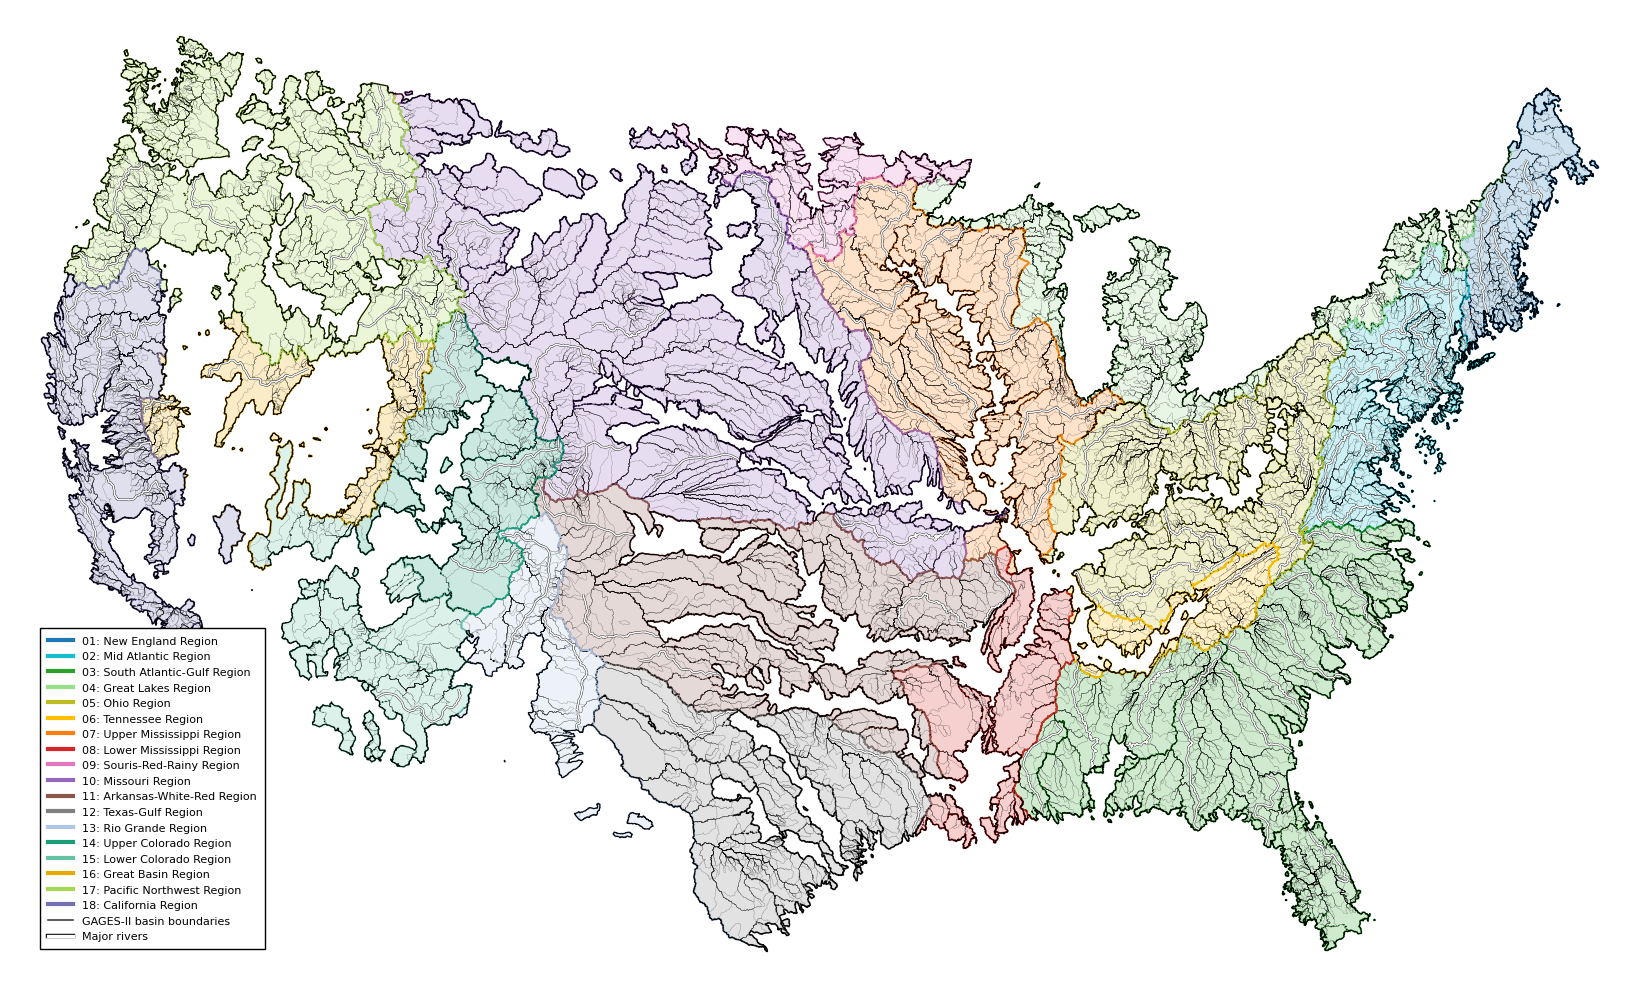

In [ ]:
#!/usr/bin/env python3
# ==========================================================
# CONUS GAGES-II basin map
# - HUC-2 darker fills
# - Black basin boundaries
# - Colored HUC-2 outlines
# - White major rivers
# ==========================================================

from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")


# ==========================================================
# CONFIG
# ==========================================================

BASIN_FILE = Path("/data/basin2vec/raw/gages-ii/geopackage/gages_basins.gpkg")
BASIN_LAYER = "gages_basins"

HUC2_FILE = Path(
    "/home/talhamuh/basin2vec/emb/evaluation/results_figures/conus_overview/"
    "Watershed_Boundary_Dataset_HUC_2s_-6944941387790115950.geojson"
)

if not HUC2_FILE.exists():
    HUC2_FILE = Path("/mnt/data/Watershed_Boundary_Dataset_HUC_2s_-6944941387790115950.geojson")

OUT_DIR = Path("results_figures/conus_huc2_overview")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_CRS = "EPSG:5070"

ADD_MAJOR_RIVERS = True
NATURAL_EARTH_RIVERS_URL = (
    "https://naturalearth.s3.amazonaws.com/10m_physical/"
    "ne_10m_rivers_lake_centerlines.zip"
)

FIGSIZE = (18, 10)

BASIN_SIMPLIFY_M = 90.0
HUC2_SIMPLIFY_M = 500.0
RIVER_SIMPLIFY_M = 500.0

DRAW_LEGEND = True


# ==========================================================
# STYLE
# ==========================================================

BACKGROUND = "white"

BASIN_BOUNDARY_COLOR = "black"
BASIN_BOUNDARY_LW = 0.18
BASIN_BOUNDARY_ALPHA = 0.52

HUC2_FILL_ALPHA = 0.22
HUC2_OUTLINE_LW = 1.20
HUC2_OUTLINE_ALPHA = 0.95

MAJOR_RIVER_COLOR = "white"
MAJOR_RIVER_LW = 1.10
MAJOR_RIVER_ALPHA = 0.98
MAJOR_RIVER_HALO_COLOR = "#000000"
MAJOR_RIVER_HALO_LW = 1.65

OUTER_BOUNDARY_LW = 0.75
OUTER_BOUNDARY_ALPHA = 0.95


# ==========================================================
# HELPERS
# ==========================================================

def load_vector(path: Path, layer=None):
    path = Path(path)

    if path.suffix.lower() == ".parquet":
        return gpd.read_parquet(path)

    if layer is not None:
        return gpd.read_file(path, layer=layer)

    return gpd.read_file(path)


def simplify_if_needed(gdf, tol):
    if tol is None or tol <= 0:
        return gdf

    gdf = gdf.copy()
    gdf["geometry"] = gdf.geometry.simplify(tol, preserve_topology=True)
    return gdf


def geom_union(gdf):
    try:
        return gdf.geometry.union_all()
    except Exception:
        return gdf.geometry.unary_union


def normalize_huc2_column(huc2):
    huc2 = huc2.copy()
    huc2["huc2"] = huc2["huc2"].astype(str).str.strip().str.zfill(2)
    huc2["name"] = huc2["name"].astype(str).str.strip()
    return huc2


def get_bounds_with_padding(gdf, pad_x=0.02, pad_y=0.03):
    xmin, ymin, xmax, ymax = gdf.total_bounds
    dx = (xmax - xmin) * pad_x
    dy = (ymax - ymin) * pad_y
    return xmin - dx, ymin - dy, xmax + dx, ymax + dy


# ==========================================================
# LOAD BASINS
# ==========================================================

print("Loading GAGES-II basins...")

basins = load_vector(BASIN_FILE, layer=BASIN_LAYER)

if basins.crs is None:
    raise ValueError("Basin dataset has no CRS.")

basins = basins.to_crs(TARGET_CRS)
basins = simplify_if_needed(basins, BASIN_SIMPLIFY_M)

print(f"Loaded basins: {len(basins):,}")

basin_union_geom = geom_union(basins)

basin_union = gpd.GeoDataFrame(
    {"id": [1]},
    geometry=[basin_union_geom],
    crs=basins.crs,
)


# ==========================================================
# LOAD HUC-2 REGIONS
# ==========================================================

print("Loading HUC-2 regions...")

huc2 = load_vector(HUC2_FILE)

if huc2.crs is None:
    raise ValueError("HUC-2 file has no CRS.")

huc2 = normalize_huc2_column(huc2)
huc2 = huc2.to_crs(TARGET_CRS)

print("Intersecting HUC-2 with basin domain...")

huc2_intersections = gpd.overlay(
    huc2[["huc2", "name", "geometry"]],
    basin_union,
    how="intersection",
)

huc2_intersections = simplify_if_needed(huc2_intersections, HUC2_SIMPLIFY_M)

unique_huc2 = sorted(huc2_intersections["huc2"].astype(str).unique().tolist())

print(f"HUC-2 regions used: {len(unique_huc2)}")
print(
    huc2_intersections[["huc2", "name"]]
    .drop_duplicates()
    .sort_values("huc2")
    .to_string(index=False)
)


# ==========================================================
# LOAD MAJOR RIVERS
# ==========================================================

rivers = None

if ADD_MAJOR_RIVERS:
    try:
        print("Loading Natural Earth major rivers...")

        rivers = gpd.read_file(NATURAL_EARTH_RIVERS_URL)

        if rivers.crs is None:
            rivers = rivers.set_crs("EPSG:4326")

        rivers = rivers.to_crs(TARGET_CRS)

        rivers = rivers[
            rivers.geometry.type.isin(["LineString", "MultiLineString"])
        ].copy()

        rivers = gpd.clip(rivers, basin_union)
        rivers = simplify_if_needed(rivers, RIVER_SIMPLIFY_M)

        print(f"Loaded major rivers: {len(rivers):,}")

    except Exception as e:
        print("[WARN] Could not load Natural Earth rivers:", repr(e))
        rivers = None




Plotting HUC-2 region fills...
Plotting basin boundaries in black...
Plotting colored HUC-2 outlines...
Plotting major rivers in white...
Saved: results_figures/conus_huc2_overview/conus_basins_black_boundaries_huc2_darkerfill_white_rivers.png
Saved: results_figures/conus_huc2_overview/conus_basins_black_boundaries_huc2_darkerfill_white_rivers.pdf


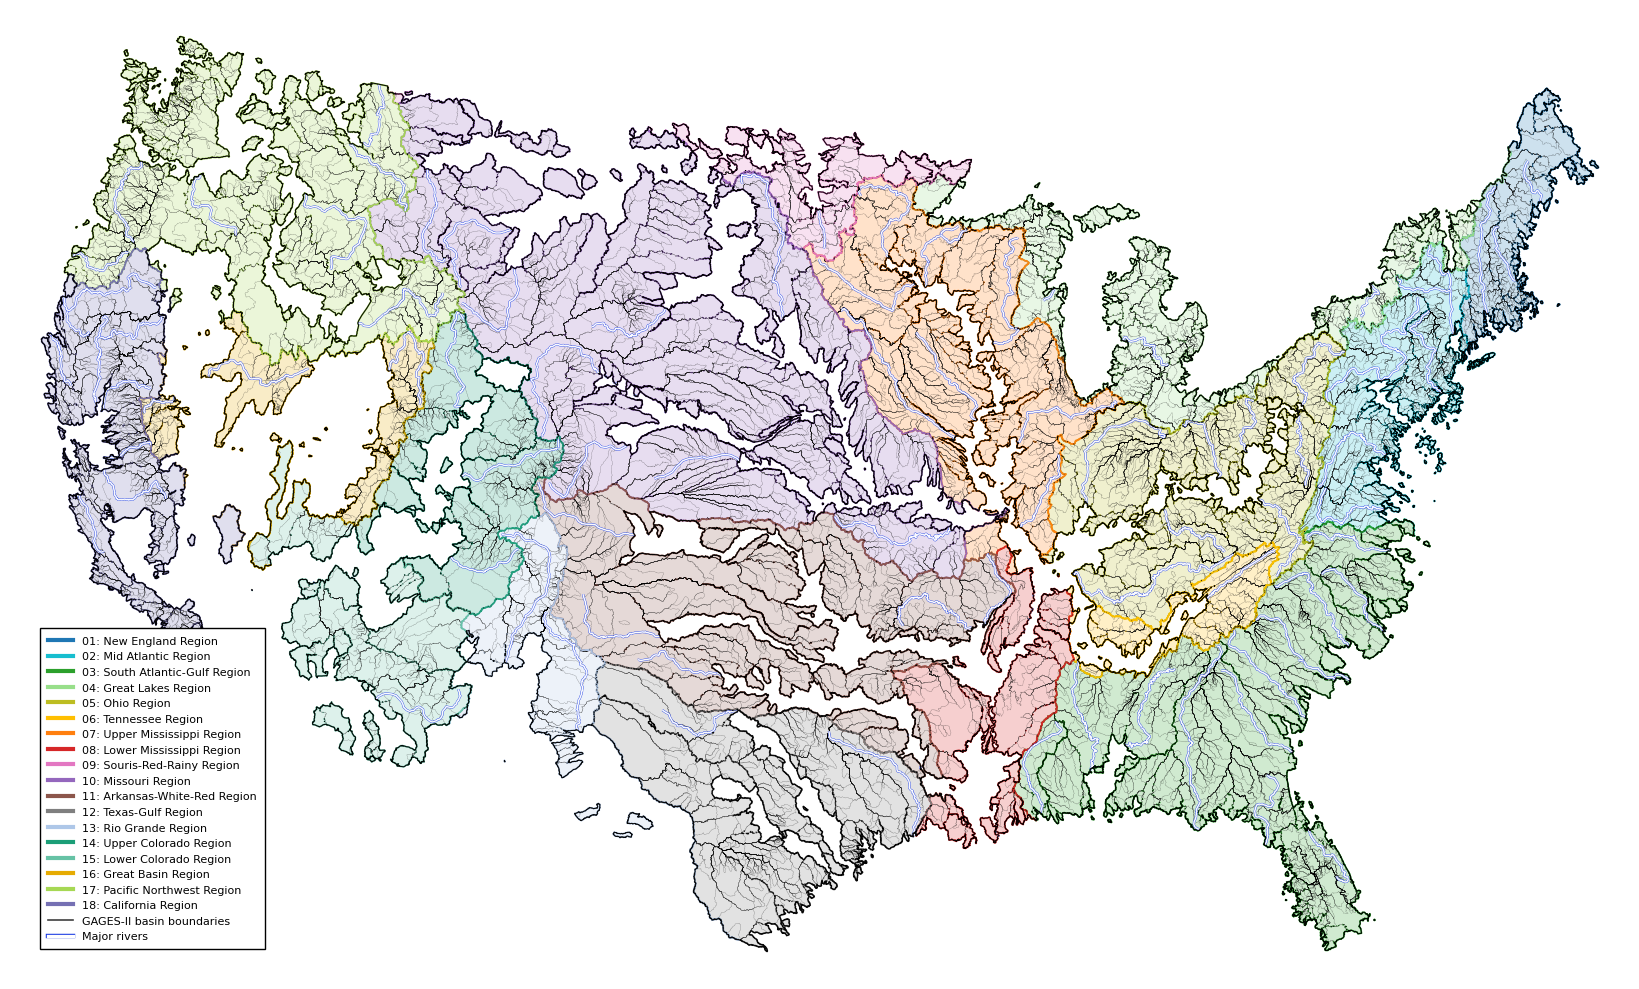

In [6]:
# ==========================================================
# STYLE
# ==========================================================

BACKGROUND = "white"

BASIN_BOUNDARY_COLOR = "black"
BASIN_BOUNDARY_LW = 0.18
BASIN_BOUNDARY_ALPHA = 0.52

HUC2_FILL_ALPHA = 0.22
HUC2_OUTLINE_LW = 1.20
HUC2_OUTLINE_ALPHA = 0.95

MAJOR_RIVER_COLOR = "white"
MAJOR_RIVER_LW = 1.10
MAJOR_RIVER_ALPHA = 0.98
MAJOR_RIVER_HALO_COLOR = "#1436E3"
MAJOR_RIVER_HALO_LW = 1.65

OUTER_BOUNDARY_LW = 0.75
OUTER_BOUNDARY_ALPHA = 0.95


# ==========================================================
# HUC-2 COLORS
# ==========================================================

palette = [
    "#1f77b4",
    "#17becf",
    "#2ca02c",
    "#98df8a",
    "#bcbd22",
    "#ffbf00",
    "#ff7f0e",
    "#d62728",
    "#e377c2",
    "#9467bd",
    "#8c564b",
    "#7f7f7f",
    "#aec7e8",
    "#1b9e77",
    "#66c2a5",
    "#e6ab02",
    "#a6d854",
    "#7570b3",
    "#000000",
]

huc2_to_color = {
    h: palette[i % len(palette)]
    for i, h in enumerate(unique_huc2)
}


# ==========================================================
# PLOT
# ==========================================================

fig, ax = plt.subplots(figsize=FIGSIZE, facecolor=BACKGROUND)
ax.set_facecolor(BACKGROUND)


# ----------------------------------------------------------
# 1) HUC-2 darker fills
# ----------------------------------------------------------

print("Plotting HUC-2 region fills...")

for h in unique_huc2:
    sub = huc2_intersections[huc2_intersections["huc2"] == h]

    if len(sub) == 0:
        continue

    sub.plot(
        ax=ax,
        facecolor=huc2_to_color[h],
        edgecolor="none",
        alpha=HUC2_FILL_ALPHA,
        zorder=0,
    )


# ----------------------------------------------------------
# 2) Basin boundaries in black
# ----------------------------------------------------------

print("Plotting basin boundaries in black...")

basins.boundary.plot(
    ax=ax,
    color=BASIN_BOUNDARY_COLOR,
    linewidth=BASIN_BOUNDARY_LW,
    alpha=BASIN_BOUNDARY_ALPHA,
    zorder=2,
)


# ----------------------------------------------------------
# 3) Colored HUC-2 outlines
# ----------------------------------------------------------

print("Plotting colored HUC-2 outlines...")

for h in unique_huc2:
    sub = huc2_intersections[huc2_intersections["huc2"] == h]

    if len(sub) == 0:
        continue

    sub.boundary.plot(
        ax=ax,
        color=huc2_to_color[h],
        linewidth=HUC2_OUTLINE_LW,
        alpha=HUC2_OUTLINE_ALPHA,
        zorder=5,
    )


# ----------------------------------------------------------
# 4) Major rivers in white
# ----------------------------------------------------------

if rivers is not None and len(rivers) > 0:
    print("Plotting major rivers in white...")

    rivers.plot(
        ax=ax,
        color=MAJOR_RIVER_COLOR,
        linewidth=MAJOR_RIVER_LW,
        alpha=MAJOR_RIVER_ALPHA,
        zorder=6,
        path_effects=[
            pe.withStroke(
                linewidth=MAJOR_RIVER_HALO_LW,
                foreground=MAJOR_RIVER_HALO_COLOR,
                alpha=0.9,
            )
        ],
    )


# ----------------------------------------------------------
# 5) Crisp outer outline
# ----------------------------------------------------------

basin_union.boundary.plot(
    ax=ax,
    color="black",
    linewidth=OUTER_BOUNDARY_LW,
    alpha=OUTER_BOUNDARY_ALPHA,
    zorder=8,
)


# ----------------------------------------------------------
# Extent and axes
# ----------------------------------------------------------

xmin, ymin, xmax, ymax = get_bounds_with_padding(
    basins,
    pad_x=0.02,
    pad_y=0.03,
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_aspect("equal", adjustable="box")
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)


# ==========================================================
# LEGEND
# ==========================================================

if DRAW_LEGEND:
    huc2_label_df = (
        huc2_intersections[["huc2", "name"]]
        .drop_duplicates()
        .sort_values("huc2")
    )

    legend_items = []

    for _, row in huc2_label_df.iterrows():
        h = str(row["huc2"]).zfill(2)
        name = str(row["name"])

        legend_items.append(
            Line2D(
                [0],
                [0],
                color=huc2_to_color[h],
                lw=3.0,
                label=f"{h}: {name}",
            )
        )

    legend_items.append(
        Line2D(
            [0],
            [0],
            color="black",
            lw=1.2,
            alpha=0.75,
            label="GAGES-II basin boundaries",
        )
    )

    if rivers is not None and len(rivers) > 0:
        river_legend = Line2D(
            [0],
            [0],
            color="white",
            lw=2.4,
            label="Major rivers",
        )
        river_legend.set_path_effects([
            pe.withStroke(linewidth=3.2, foreground=MAJOR_RIVER_HALO_COLOR)
        ])
        legend_items.append(river_legend)

    leg = ax.legend(
        handles=legend_items,
        loc="lower left",
        bbox_to_anchor=(0.015, 0.025),
        ncol=1,
        frameon=True,
        fancybox=False,
        framealpha=1.0,
        facecolor="white",
        edgecolor="black",
        fontsize=8.0,
        handlelength=2.3,
        labelcolor="black",
        borderpad=0.7,
    )

    leg.set_zorder(1000)

    frame = leg.get_frame()
    frame.set_facecolor("white")
    frame.set_edgecolor("black")
    frame.set_alpha(1.0)
    frame.set_linewidth(1.0)
    frame.set_zorder(1000)

    for txt in leg.get_texts():
        txt.set_color("black")
        txt.set_zorder(1001)

    for line in leg.get_lines():
        line.set_zorder(1001)


plt.tight_layout()


# ==========================================================
# SAVE
# ==========================================================

png_path = OUT_DIR / "conus_basins_black_boundaries_huc2_darkerfill_white_rivers.png"
pdf_path = OUT_DIR / "conus_basins_black_boundaries_huc2_darkerfill_white_rivers.pdf"

plt.savefig(
    png_path,
    dpi=300,
    facecolor="white",
    bbox_inches="tight",
    transparent=False,
)

plt.savefig(
    pdf_path,
    facecolor="white",
    bbox_inches="tight",
    transparent=False,
)

print("Saved:", png_path)
print("Saved:", pdf_path)

plt.show()


Basin2Vec NPZ keys: ../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz
embeddings                          shape=(362680, 64), dtype=float32
hydrologic_repr                     shape=(362680, 64), dtype=float32
z_multisource                       shape=(362680, 64), dtype=float32
z_monthly                           shape=(362680, 64), dtype=float32
z_static                            shape=(362680, 64), dtype=float32
labels                              shape=(362680,), dtype=<U15
label_ints                          shape=(362680,), dtype=int64
years                               shape=(362680,), dtype=int64
basin_meta                          shape=(362680, 11), dtype=float32
area_target                         shape=(362680,), dtype=float32
area_pred                           shape=(362680,), dtype=float32
overlap_degree                      shape=(362680,), dtype=float32
branch_attention                    shape=(362680, 2), dtype=float

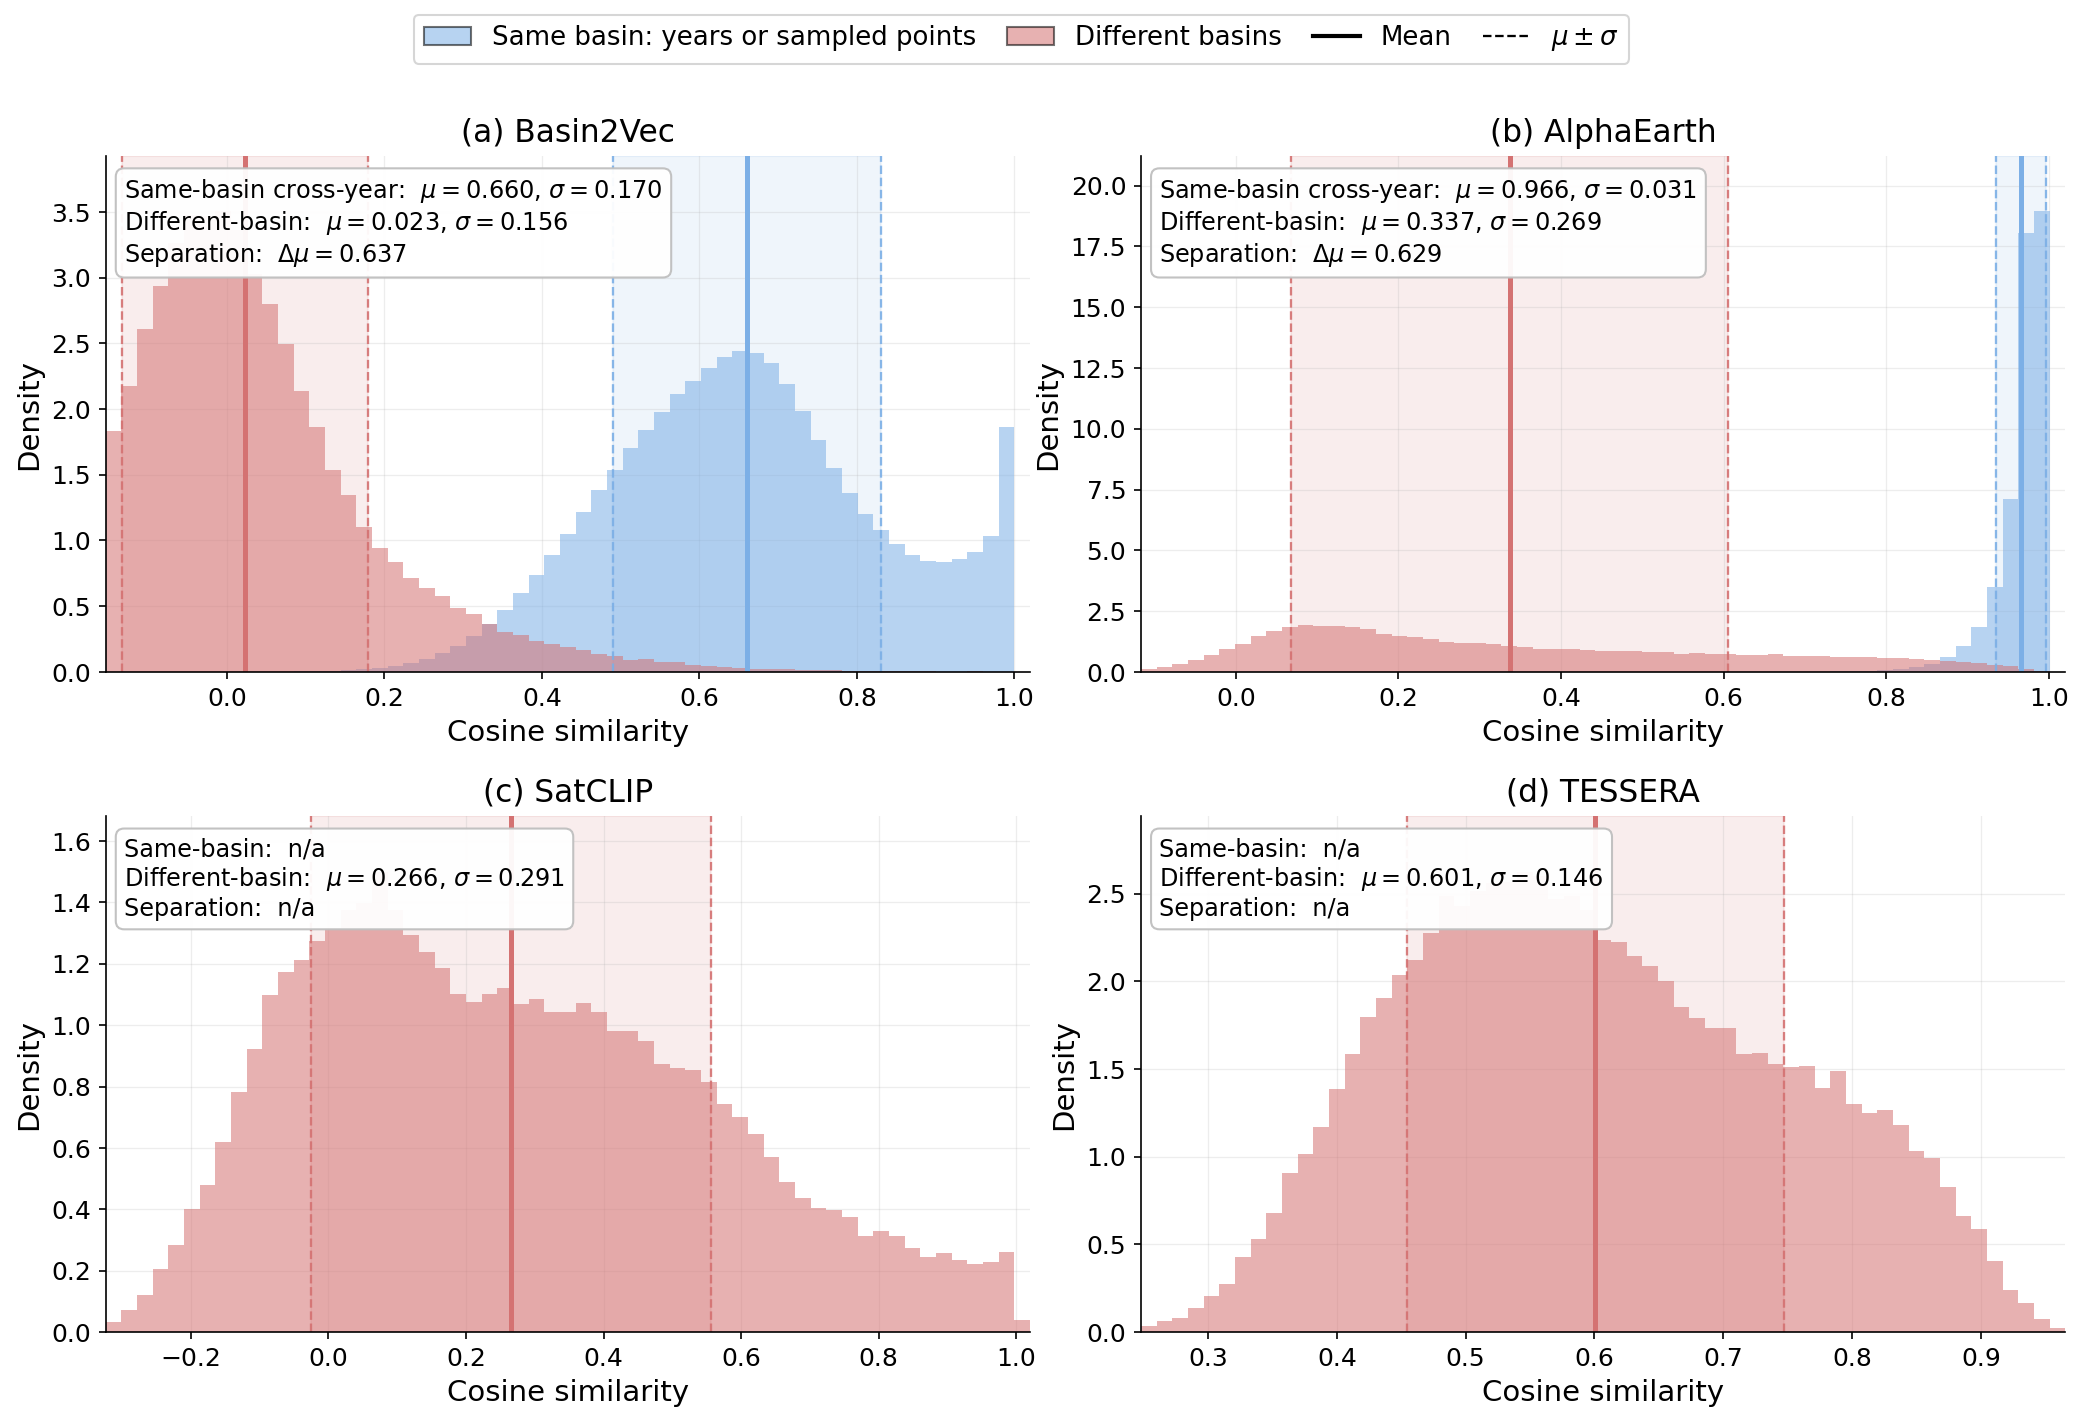

In [9]:
#!/usr/bin/env python3
# ==========================================================
# Compare Basin2Vec, AlphaEarth, SatCLIP, and TESSERA embeddings:
#
#   Basin2Vec / AlphaEarth:
#       Same-basin across-year cosine similarity
#       Different-basin cosine similarity
#
#   SatCLIP / TESSERA 8-point embeddings:
#       Same-basin across sampled points cosine similarity
#       Different-basin sampled-point cosine similarity
#
# Important:
#   - For 3D embeddings [n_basins, n_points, dim], this script DOES NOT average
#     over the 8 points. It flattens them so same-basin point similarity can be plotted.
#   - If no years key exists, the script infers year=2024 from the filename.
#
# Output:
#   paper_results_all_embedding_similarity/
#       figures/
#           fig_all_embeddings_cosine_similarity_distribution.pdf
#           fig_all_embeddings_cosine_similarity_distribution.png
#       tables/
#           all_embeddings_similarity_summary.csv
#           all_embeddings_loaded_samples.csv
#           all_embeddings_similarity_distributions.npz
# ==========================================================

from __future__ import annotations

from pathlib import Path
from collections import defaultdict
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")


# ==========================================================
# CONFIG
# ==========================================================

SEED = 42
RNG = np.random.default_rng(SEED)

ALPHAEARTH_NPZ = Path(
    "alphaearth_embeddings/embeddings/alphaearth_annual_basin_embeddings_2017_2024_scale500m.npz"
)
SATCLIP_NPZ = Path("satclip_embeddings/satclip_8point_2024_embeddings.npz")
TESSERA_NPZ = Path("tessera_embeddings/tessera_8point_2024_embeddings.npz")
BASIN2VEC_NPZ = Path(
    "../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz"
)

BASIN2VEC_EMBEDDING_KEY = "embeddings"

MODEL_CONFIGS = [
    {
        "name": "Basin2Vec",
        "path": BASIN2VEC_NPZ,
        "preferred_embedding_key": BASIN2VEC_EMBEDDING_KEY,
        "prefer_3d_points": False,
    },
    {
        "name": "AlphaEarth",
        "path": ALPHAEARTH_NPZ,
        "preferred_embedding_key": None,
        "prefer_3d_points": False,
    },
    {
        "name": "SatCLIP",
        "path": SATCLIP_NPZ,
        "preferred_embedding_key": None,
        "prefer_3d_points": True,
    },
    {
        "name": "TESSERA",
        "path": TESSERA_NPZ,
        "preferred_embedding_key": None,
        "prefer_3d_points": True,
    },
]

RESULTS_DIR = Path("paper_results_all_embedding_similarity")
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Usually keep False.
# If True, all models are restricted to the common basin-year intersection.
# With SatCLIP/TESSERA 2024-only files, this can reduce everything to 2024.
FILTER_TO_COMMON_BASIN_YEARS = False

N_BINS = 60
MAX_DIFF_PAIRS = 100_000
MAX_SAME_PAIRS = None

SAME_COLOR = "#7cafe6"
DIFF_COLOR = "#d47272"

plt.rcParams.update({
    "figure.figsize": (12, 5.4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 12,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})


# ==========================================================
# BASIC HELPERS
# ==========================================================

def normalize_site_id(x) -> str | None:
    if pd.isna(x):
        return None

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    s_digits = re.sub(r"\D", "", s)

    if len(s_digits) > 0:
        if len(s_digits) <= 8:
            return s_digits.zfill(8)
        return s_digits

    if len(s) == 0:
        return None

    return s


def l2_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    return x / np.clip(np.linalg.norm(x, axis=1, keepdims=True), eps, None)


def safe_mean(x) -> float:
    x = np.asarray(x)
    return float(np.mean(x)) if len(x) else float("nan")


def safe_std(x) -> float:
    x = np.asarray(x)
    return float(np.std(x)) if len(x) else float("nan")


def safe_median(x) -> float:
    x = np.asarray(x)
    return float(np.median(x)) if len(x) else float("nan")


def safe_percentile(x, q: float) -> float:
    x = np.asarray(x)
    return float(np.percentile(x, q)) if len(x) else float("nan")


def savefig(path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, bbox_inches="tight", dpi=300)
    print(f"Saved: {path}")


def is_numeric_array(arr: np.ndarray) -> bool:
    return np.issubdtype(arr.dtype, np.number)


def infer_year_from_filename(npz_path: Path) -> int | None:
    matches = re.findall(r"(?<!\d)(19\d{2}|20\d{2})(?!\d)", npz_path.name)
    if len(matches) == 0:
        return None
    return int(matches[-1])


def print_npz_keys(npz_path: Path, model_name: str):
    data = np.load(npz_path, allow_pickle=True)

    print("\n" + "=" * 80)
    print(f"{model_name} NPZ keys: {npz_path}")
    print("=" * 80)

    for k in data.files:
        arr = data[k]
        print(f"{k:35s} shape={arr.shape}, dtype={arr.dtype}")

    return data


# ==========================================================
# NPZ KEY SELECTION
# ==========================================================

def choose_embedding_array(
    data,
    preferred_key: str | None,
    model_name: str,
    prefer_3d_points: bool = False,
) -> tuple[str, np.ndarray]:
    """
    Select embedding array.

    For SatCLIP/TESSERA, prefer_3d_points=True tries to use 3D arrays
    [n_basins, n_points, dim] so we can compute same-basin point similarity.
    """

    if preferred_key is not None and preferred_key in data.files:
        key = preferred_key
        emb = np.asarray(data[key], dtype=np.float32)
        return key, emb

    candidates = [
        "point_embeddings",
        "pointwise_embeddings",
        "embeddings_8point",
        "embeddings_8points",
        "basin_point_embeddings",
        "satclip_point_embeddings",
        "tessera_point_embeddings",
        "embeddings",
        "embedding",
        "raw_embeddings",
        "alphaearth_embeddings",
        "satclip_embeddings",
        "tessera_embeddings",
        "basin_embeddings",
        "avg_embeddings",
        "hydrologic_repr",
        "z",
        "features",
    ]

    # ------------------------------------------------------
    # For SatCLIP/TESSERA: first try to find a 3D point-level array.
    # ------------------------------------------------------
    if prefer_3d_points:
        for key in candidates:
            if key in data.files:
                arr = np.asarray(data[key])
                if is_numeric_array(arr) and arr.ndim == 3:
                    return key, arr.astype(np.float32)

        numeric_3d_candidates = []

        for key in data.files:
            arr = np.asarray(data[key])
            if is_numeric_array(arr) and arr.ndim == 3:
                numeric_3d_candidates.append((arr.size, key, arr))

        if numeric_3d_candidates:
            _, key, arr = max(numeric_3d_candidates, key=lambda x: x[0])
            print(f"Warning: using auto-detected 3D embedding key for {model_name}: {key}")
            return key, arr.astype(np.float32)

    # ------------------------------------------------------
    # Standard 2D or 3D embedding selection.
    # ------------------------------------------------------
    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if is_numeric_array(arr) and arr.ndim in (2, 3):
                return key, arr.astype(np.float32)

    numeric_candidates = []

    for key in data.files:
        arr = np.asarray(data[key])
        if is_numeric_array(arr) and arr.ndim in (2, 3):
            numeric_candidates.append((arr.size, key, arr))

    if numeric_candidates:
        _, key, arr = max(numeric_candidates, key=lambda x: x[0])
        print(f"Warning: using auto-detected embedding key for {model_name}: {key}")
        return key, arr.astype(np.float32)

    raise KeyError(
        f"Could not find embedding array for {model_name}. "
        f"Available keys: {data.files}"
    )


def choose_site_ids(data, model_name: str, n_expected: int) -> tuple[str, np.ndarray]:
    candidates = [
        "labels",
        "avg_labels",
        "site_ids",
        "site_id",
        "gage_ids",
        "gauge_ids",
        "basin_ids",
        "basin_id",
        "ids",
        "id",
        "label_ints",
        "site_ids_int",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr

    skip_patterns = [
        "year",
        "embedding",
        "feature",
        "coord",
        "lat",
        "lon",
        "x",
        "y",
        "point",
        "dim",
    ]

    for key in data.files:
        key_lower = key.lower()

        if any(p in key_lower for p in skip_patterns):
            continue

        arr = np.asarray(data[key])

        if arr.ndim != 1 or len(arr) != n_expected:
            continue

        if arr.dtype.kind not in {"O", "U", "S", "i", "u"}:
            continue

        # Avoid accidentally using a year vector as site IDs.
        if np.issubdtype(arr.dtype, np.number):
            arr_min = np.nanmin(arr)
            arr_max = np.nanmax(arr)
            if 1900 <= arr_min <= 2100 and 1900 <= arr_max <= 2100:
                continue

        print(f"Warning: using auto-detected site-id key for {model_name}: {key}")
        return key, arr

    raise KeyError(
        f"Could not find site/basin ID array for {model_name} with length {n_expected}. "
        f"Available keys: {data.files}"
    )


def choose_years(
    data,
    model_name: str,
    n_expected: int,
    npz_path: Path,
) -> tuple[str, np.ndarray]:
    candidates = [
        "years",
        "year",
        "sample_years",
        "embedding_years",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr.astype(int)

    inferred_year = infer_year_from_filename(npz_path)

    if inferred_year is not None:
        years = np.full(n_expected, inferred_year, dtype=int)
        print(
            f"{model_name}: no year array found; inferred year={inferred_year} "
            f"from filename {npz_path.name}."
        )
        return "inferred_from_filename", years

    raise KeyError(
        f"Could not find years array for {model_name}, and no year could be "
        f"inferred from filename: {npz_path.name}. Available keys: {data.files}"
    )


# ==========================================================
# LOAD EMBEDDINGS
# ==========================================================

def collapse_duplicate_basin_years(
    df: pd.DataFrame,
    emb: np.ndarray,
) -> tuple[pd.DataFrame, np.ndarray]:
    """
    If multiple rows exist for the same site_id/year in 2D annual embeddings,
    average them.
    """
    df = df.copy()
    df["row"] = np.arange(len(df))

    rows = []
    embs = []

    for (sid, year), sub in df.groupby(["site_id", "year"], sort=True):
        idx = sub["row"].to_numpy(dtype=int)

        z = emb[idx].mean(axis=0, keepdims=True)
        z = l2_normalize(z)[0]

        rows.append({
            "site_id": sid,
            "year": int(year),
            "point_id": 0,
            "n_duplicate_rows": int(len(idx)),
        })
        embs.append(z)

    out_df = pd.DataFrame(rows)
    out_emb = np.stack(embs, axis=0).astype(np.float32)

    return out_df, out_emb


def reduce_or_flatten_embedding_array(
    emb: np.ndarray,
    df_base: pd.DataFrame,
    model_name: str,
    emb_key: str,
) -> tuple[pd.DataFrame, np.ndarray, str, str]:
    """
    Handles:
      2D: [n_samples, dim]
      3D: [n_basins, n_points, dim]

    For 3D embeddings, flatten to [n_basins * n_points, dim].
    This preserves the 8 sampled points, allowing same-basin point similarity.
    """
    emb = np.asarray(emb, dtype=np.float32)

    if emb.ndim == 2:
        df = df_base.copy()
        df["point_id"] = 0

        if df["year"].nunique() > 1:
            same_label = "Same-basin cross-year"
            same_mode = "years"
        else:
            same_label = "Same-basin"
            same_mode = "single_sample"

        return df, emb, same_label, same_mode

    if emb.ndim == 3:
        n_basins, n_points, dim = emb.shape

        print(
            f"{model_name}: embedding key '{emb_key}' is 3D {emb.shape}; "
            "flattening sampled points instead of averaging."
        )

        if len(df_base) != n_basins:
            raise ValueError(
                f"{model_name}: 3D embedding first dimension does not match metadata. "
                f"emb.shape[0]={n_basins}, len(df_base)={len(df_base)}"
            )

        emb_flat = emb.reshape(n_basins * n_points, dim).astype(np.float32)

        df_rep = df_base.loc[df_base.index.repeat(n_points)].copy().reset_index(drop=True)
        df_rep["point_id"] = np.tile(np.arange(n_points), n_basins)

        same_label = f"Same-basin across {n_points} sampled points"
        same_mode = "points"

        return df_rep, emb_flat, same_label, same_mode

    raise ValueError(
        f"{model_name} embedding array must be 2D or 3D. "
        f"Got shape={emb.shape} from key={emb_key}"
    )


def load_embedding_npz(
    npz_path: Path,
    model_name: str,
    preferred_embedding_key: str | None = None,
    prefer_3d_points: bool = False,
) -> tuple[pd.DataFrame, np.ndarray, dict]:
    npz_path = Path(npz_path)

    if not npz_path.exists():
        raise FileNotFoundError(f"{model_name} NPZ not found: {npz_path}")

    data = print_npz_keys(npz_path, model_name)

    emb_key, emb_raw = choose_embedding_array(
        data=data,
        preferred_key=preferred_embedding_key,
        model_name=model_name,
        prefer_3d_points=prefer_3d_points,
    )

    n_base = emb_raw.shape[0]

    site_key, site_ids_raw = choose_site_ids(
        data=data,
        model_name=model_name,
        n_expected=n_base,
    )

    year_key, years = choose_years(
        data=data,
        model_name=model_name,
        n_expected=n_base,
        npz_path=npz_path,
    )

    site_ids = np.array([normalize_site_id(x) for x in site_ids_raw], dtype=object)

    df_base = pd.DataFrame({
        "site_id": site_ids,
        "year": years.astype(int),
    })

    valid = df_base["site_id"].notna().to_numpy()
    df_base = df_base.loc[valid].reset_index(drop=True)
    emb_raw = emb_raw[valid]

    df, emb, same_label, same_mode = reduce_or_flatten_embedding_array(
        emb=emb_raw,
        df_base=df_base,
        model_name=model_name,
        emb_key=emb_key,
    )

    emb = l2_normalize(emb)

    # Collapse duplicate basin-years only for true 2D annual embeddings.
    # Do NOT collapse 3D point embeddings, because that would destroy the point structure.
    if emb_raw.ndim == 2:
        df, emb = collapse_duplicate_basin_years(df, emb)

    metadata = {
        "model_name": model_name,
        "npz_path": str(npz_path),
        "embedding_key": emb_key,
        "site_key": site_key,
        "year_key": year_key,
        "same_label": same_label,
        "same_mode": same_mode,
        "raw_embedding_shape": tuple(emb_raw.shape),
        "n_samples_after_loading": int(len(df)),
        "n_unique_basins": int(df["site_id"].nunique()),
        "n_unique_years": int(df["year"].nunique()),
        "min_year": int(df["year"].min()),
        "max_year": int(df["year"].max()),
        "embedding_dim": int(emb.shape[1]),
    }

    print("\nLoaded:", model_name)
    for k, v in metadata.items():
        print(f"  {k}: {v}")

    return df, emb, metadata


# ==========================================================
# COMMON FILTERING
# ==========================================================

def basin_year_keys(df: pd.DataFrame) -> pd.Series:
    return df["site_id"].astype(str) + "::" + df["year"].astype(str)


def restrict_all_to_common_basin_years(
    loaded: dict[str, dict],
) -> dict[str, dict]:
    key_sets = []

    for item in loaded.values():
        key_sets.append(set(basin_year_keys(item["df"])))

    common_keys = sorted(set.intersection(*key_sets))

    if len(common_keys) == 0:
        raise RuntimeError(
            "No common basin-year pairs found across all models. "
            "Check site_id normalization and year ranges."
        )

    common_set = set(common_keys)
    out = {}

    print("\n" + "=" * 80)
    print("Common basin-year filtering across all models")
    print("=" * 80)
    print("Common basin-years:", len(common_keys))

    for model_name, item in loaded.items():
        df = item["df"]
        emb = item["emb"]

        keys = basin_year_keys(df)
        keep = keys.isin(common_set).to_numpy()

        df2 = df.loc[keep].copy()
        emb2 = emb[keep]

        df2["key"] = basin_year_keys(df2)

        sort_cols = ["key"]
        if "point_id" in df2.columns:
            sort_cols.append("point_id")

        order = np.lexsort(
            tuple(df2[c].to_numpy() for c in reversed(sort_cols))
        )

        df2 = df2.iloc[order].drop(columns=["key"]).reset_index(drop=True)
        emb2 = emb2[order]

        out[model_name] = dict(item)
        out[model_name]["df"] = df2
        out[model_name]["emb"] = emb2

        print(
            f"{model_name}: n={len(df2)}, "
            f"basins={df2['site_id'].nunique()}, "
            f"years={sorted(df2['year'].unique().tolist())}"
        )

    return out


# ==========================================================
# SIMILARITY COMPUTATION
# ==========================================================

def compute_same_basin_sims(
    emb: np.ndarray,
    df: pd.DataFrame,
    same_mode: str,
    max_same_pairs: int | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Computes same-basin similarities.

    For same_mode == "years":
        compares different years of the same basin.

    For same_mode == "points":
        compares different sampled points of the same basin.

    For same_mode == "single_sample":
        returns empty array because each basin has only one sample.
    """
    if same_mode == "single_sample":
        return np.array([], dtype=np.float32), np.array([], dtype=np.int16)

    labels = df["site_id"].to_numpy(dtype=str)
    years = df["year"].to_numpy(dtype=int)

    if "point_id" in df.columns:
        point_ids = df["point_id"].to_numpy(dtype=int)
    else:
        point_ids = np.zeros(len(df), dtype=int)

    basin_to_idx = defaultdict(list)

    for i, sid in enumerate(labels):
        basin_to_idx[sid].append(i)

    sims_list = []
    gap_list = []

    for _, idx_list in basin_to_idx.items():
        if len(idx_list) < 2:
            continue

        idx = np.array(idx_list, dtype=int)

        e = emb[idx]
        sim = e @ e.T

        iu = np.triu_indices(len(idx), k=1)

        if same_mode == "years":
            yrs = years[idx]
            valid_pair = yrs[iu[0]] != yrs[iu[1]]
            gap = np.abs(yrs[iu[0]] - yrs[iu[1]]).astype(np.int16)

        elif same_mode == "points":
            pts = point_ids[idx]
            valid_pair = pts[iu[0]] != pts[iu[1]]
            gap = np.abs(pts[iu[0]] - pts[iu[1]]).astype(np.int16)

        else:
            valid_pair = np.ones(len(iu[0]), dtype=bool)
            gap = np.zeros(len(iu[0]), dtype=np.int16)

        if valid_pair.sum() == 0:
            continue

        sims_list.append(sim[iu][valid_pair].astype(np.float32))
        gap_list.append(gap[valid_pair].astype(np.int16))

    if len(sims_list) == 0:
        return np.array([], dtype=np.float32), np.array([], dtype=np.int16)

    sims = np.concatenate(sims_list).astype(np.float32)
    gaps = np.concatenate(gap_list).astype(np.int16)

    if max_same_pairs is not None and len(sims) > max_same_pairs:
        keep = RNG.choice(len(sims), size=max_same_pairs, replace=False)
        sims = sims[keep]
        gaps = gaps[keep]

    return sims, gaps


def sample_different_basin_sims(
    emb: np.ndarray,
    df: pd.DataFrame,
    max_pairs: int = 100_000,
) -> np.ndarray:
    labels = df["site_id"].to_numpy(dtype=str)
    n = len(labels)

    if n < 2 or df["site_id"].nunique() < 2:
        return np.array([], dtype=np.float32)

    collected = []
    n_collected = 0

    max_tries = 1000
    tries = 0

    while n_collected < max_pairs and tries < max_tries:
        tries += 1

        need = max_pairs - n_collected
        batch_size = max(10_000, int(need * 1.5))

        i = RNG.integers(0, n, size=batch_size)
        j = RNG.integers(0, n, size=batch_size)

        valid = labels[i] != labels[j]

        if valid.sum() == 0:
            continue

        sims = np.sum(emb[i[valid]] * emb[j[valid]], axis=1).astype(np.float32)

        collected.append(sims)
        n_collected += len(sims)

    if not collected:
        return np.array([], dtype=np.float32)

    out = np.concatenate(collected)[:max_pairs].astype(np.float32)
    return out


def embedding_similarity_analysis(
    emb: np.ndarray,
    df: pd.DataFrame,
    model_name: str,
    same_label: str,
    same_mode: str,
) -> dict:
    same_sims, same_gaps = compute_same_basin_sims(
        emb=emb,
        df=df,
        same_mode=same_mode,
        max_same_pairs=MAX_SAME_PAIRS,
    )

    diff_sims = sample_different_basin_sims(
        emb=emb,
        df=df,
        max_pairs=MAX_DIFF_PAIRS,
    )

    same_mean = safe_mean(same_sims)
    diff_mean = safe_mean(diff_sims)

    if len(same_sims) and len(diff_sims):
        separation = same_mean - diff_mean
    else:
        separation = float("nan")

    metrics = {
        "model": model_name,
        "same_label": same_label,
        "same_mode": same_mode,
        "n_samples": int(len(df)),
        "n_unique_basins": int(df["site_id"].nunique()),
        "n_years": int(df["year"].nunique()),
        "min_year": int(df["year"].min()),
        "max_year": int(df["year"].max()),
        "embedding_dim": int(emb.shape[1]),
        "same_basin_n": int(len(same_sims)),
        "different_basin_n": int(len(diff_sims)),
        "same_basin_mean": same_mean,
        "same_basin_std": safe_std(same_sims),
        "different_basin_mean": diff_mean,
        "different_basin_std": safe_std(diff_sims),
        "mean_separation": separation,
        "median_same_basin": safe_median(same_sims),
        "median_different_basin": safe_median(diff_sims),
        "p05_same_basin": safe_percentile(same_sims, 5),
        "p95_same_basin": safe_percentile(same_sims, 95),
        "p05_different_basin": safe_percentile(diff_sims, 5),
        "p95_different_basin": safe_percentile(diff_sims, 95),
    }

    return {
        "model": model_name,
        "df": df,
        "emb": emb,
        "same_label": same_label,
        "same_mode": same_mode,
        "same_sims": same_sims,
        "diff_sims": diff_sims,
        "same_gaps": same_gaps,
        "metrics": metrics,
    }


# ==========================================================
# PLOTTING
# ==========================================================

def format_stats_line(label: str, mean: float, std: float, has_values: bool) -> str:
    if not has_values or not np.isfinite(mean) or not np.isfinite(std):
        return f"{label}:  n/a"

    return f"{label}:  $\\mu={mean:.3f}$, $\\sigma={std:.3f}$"


def plot_all_similarity(results: dict[str, dict]):
    model_order = list(results.keys())
    n_models = len(model_order)

    ncols = 2 if n_models > 1 else 1
    nrows = int(math.ceil(n_models / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(7.1 * ncols, 4.9 * nrows),
        sharex=False,
        sharey=False,
    )

    axes = np.atleast_1d(axes).ravel()
    panel_labels = [f"({chr(ord('a') + i)})" for i in range(n_models)]

    for ax, panel_label, model_name in zip(axes, panel_labels, model_order):
        r = results[model_name]

        same_sims = r["same_sims"]
        diff_sims = r["diff_sims"]

        same_label = r["same_label"]

        same_mean = r["metrics"]["same_basin_mean"]
        same_std = r["metrics"]["same_basin_std"]

        diff_mean = r["metrics"]["different_basin_mean"]
        diff_std = r["metrics"]["different_basin_std"]

        has_same = len(same_sims) > 0
        has_diff = len(diff_sims) > 0

        if has_same and has_diff:
            all_vals = np.concatenate([same_sims, diff_sims])
        elif has_same:
            all_vals = same_sims
        elif has_diff:
            all_vals = diff_sims
        else:
            ax.set_title(f"{panel_label} {model_name}", fontsize=15, pad=7)
            ax.text(
                0.5,
                0.5,
                "No valid similarity pairs",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=13,
            )
            ax.set_axis_off()
            continue

        x_lo = np.percentile(all_vals, 0.2) - 0.03
        x_hi = np.percentile(all_vals, 99.8) + 0.03

        x_lo = max(-0.35, x_lo)
        x_hi = min(1.02, x_hi)

        if x_hi <= x_lo:
            x_lo = float(np.min(all_vals)) - 0.05
            x_hi = float(np.max(all_vals)) + 0.05

        bins = np.linspace(x_lo, x_hi, N_BINS)

        hist_max = 0.0

        # --------------------------------------------------
        # Same-basin distribution
        # --------------------------------------------------
        if has_same:
            n_same, _, _ = ax.hist(
                same_sims,
                bins=bins,
                density=True,
                alpha=0.55,
                color=SAME_COLOR,
                edgecolor="none",
                label="Same basin",
            )

            hist_max = max(hist_max, float(np.nanmax(n_same)))

            if np.isfinite(same_mean):
                ax.axvline(
                    same_mean,
                    color=SAME_COLOR,
                    linewidth=2.4,
                )

            if np.isfinite(same_mean) and np.isfinite(same_std):
                ax.axvspan(
                    same_mean - same_std,
                    same_mean + same_std,
                    color=SAME_COLOR,
                    alpha=0.12,
                    zorder=0,
                )

                ax.axvline(
                    same_mean - same_std,
                    color=SAME_COLOR,
                    linestyle="--",
                    linewidth=1.1,
                    alpha=0.9,
                )

                ax.axvline(
                    same_mean + same_std,
                    color=SAME_COLOR,
                    linestyle="--",
                    linewidth=1.1,
                    alpha=0.9,
                )

        # --------------------------------------------------
        # Different-basin distribution
        # --------------------------------------------------
        if has_diff:
            n_diff, _, _ = ax.hist(
                diff_sims,
                bins=bins,
                density=True,
                alpha=0.55,
                color=DIFF_COLOR,
                edgecolor="none",
                label="Different basins",
            )

            hist_max = max(hist_max, float(np.nanmax(n_diff)))

            if np.isfinite(diff_mean):
                ax.axvline(
                    diff_mean,
                    color=DIFF_COLOR,
                    linewidth=2.4,
                )

            if np.isfinite(diff_mean) and np.isfinite(diff_std):
                ax.axvspan(
                    diff_mean - diff_std,
                    diff_mean + diff_std,
                    color=DIFF_COLOR,
                    alpha=0.12,
                    zorder=0,
                )

                ax.axvline(
                    diff_mean - diff_std,
                    color=DIFF_COLOR,
                    linestyle="--",
                    linewidth=1.1,
                    alpha=0.9,
                )

                ax.axvline(
                    diff_mean + diff_std,
                    color=DIFF_COLOR,
                    linestyle="--",
                    linewidth=1.1,
                    alpha=0.9,
                )

        if hist_max > 0:
            ax.set_ylim(0, hist_max * 1.12)

        same_text = format_stats_line(
            label=same_label,
            mean=same_mean,
            std=same_std,
            has_values=has_same,
        )

        diff_text = format_stats_line(
            label="Different-basin",
            mean=diff_mean,
            std=diff_std,
            has_values=has_diff,
        )

        separation = r["metrics"]["mean_separation"]

        if np.isfinite(separation):
            sep_text = f"Separation:  $\\Delta\\mu={separation:.3f}$"
        else:
            sep_text = "Separation:  n/a"

        stats_text = same_text + "\n" + diff_text + "\n" + sep_text

        ax.text(
            0.02,
            0.96,
            stats_text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=11.5,
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="white",
                edgecolor="0.75",
                alpha=0.95,
            ),
        )

        ax.set_title(f"{panel_label} {model_name}", fontsize=15, pad=7)
        ax.set_xlabel("Cosine similarity", fontsize=14)
        ax.set_ylabel("Density", fontsize=14)
        ax.set_xlim(x_lo, x_hi)
        ax.grid(True, linestyle="-", linewidth=0.6, alpha=0.22)
        ax.set_axisbelow(True)

        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

    for ax in axes[n_models:]:
        ax.set_axis_off()

    legend_elements = [
        Patch(
            facecolor=SAME_COLOR,
            edgecolor="black",
            alpha=0.55,
            label="Same basin: years or sampled points",
        ),
        Patch(
            facecolor=DIFF_COLOR,
            edgecolor="black",
            alpha=0.55,
            label="Different basins",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            linewidth=2.0,
            label="Mean",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            linestyle="--",
            linewidth=1.1,
            label=r"$\mu \pm \sigma$",
        ),
    ]

    fig.legend(
        handles=legend_elements,
        ncol=4,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.985),
        frameon=True,
        fontsize=12.5,
        handlelength=1.8,
        columnspacing=1.2,
    )

    fig.subplots_adjust(
        left=0.07,
        right=0.99,
        bottom=0.08,
        top=0.88,
        wspace=0.12,
        hspace=0.28,
    )

    out_pdf = FIG_DIR / "fig_all_embeddings_cosine_similarity_distribution.pdf"
    out_png = FIG_DIR / "fig_all_embeddings_cosine_similarity_distribution.png"

    savefig(out_pdf)
    savefig(out_png)

    plt.show()


# ==========================================================
# MAIN
# ==========================================================

def main():
    loaded = {}

    for cfg in MODEL_CONFIGS:
        model_name = cfg["name"]
        npz_path = cfg["path"]
        preferred_key = cfg.get("preferred_embedding_key")
        prefer_3d_points = cfg.get("prefer_3d_points", False)

        df, emb, meta = load_embedding_npz(
            npz_path=npz_path,
            model_name=model_name,
            preferred_embedding_key=preferred_key,
            prefer_3d_points=prefer_3d_points,
        )

        loaded[model_name] = {
            "df": df,
            "emb": emb,
            "meta": meta,
            "same_label": meta["same_label"],
            "same_mode": meta["same_mode"],
        }

    if FILTER_TO_COMMON_BASIN_YEARS:
        loaded = restrict_all_to_common_basin_years(loaded)

    # ------------------------------------------------------
    # Save loaded metadata
    # ------------------------------------------------------
    loaded_dfs = []

    for model_name, item in loaded.items():
        tmp = item["df"].copy()
        tmp["model"] = model_name
        tmp["embedding_dim"] = item["emb"].shape[1]
        tmp["same_mode"] = item["same_mode"]
        tmp["same_label"] = item["same_label"]
        loaded_dfs.append(tmp)

    loaded_df = pd.concat(loaded_dfs, ignore_index=True)

    loaded_samples_path = TABLE_DIR / "all_embeddings_loaded_samples.csv"
    loaded_df.to_csv(loaded_samples_path, index=False)

    print("\nSaved loaded sample table:")
    print(loaded_samples_path)

    # ------------------------------------------------------
    # Compute similarity distributions
    # ------------------------------------------------------
    results = {}

    for model_name, item in loaded.items():
        results[model_name] = embedding_similarity_analysis(
            emb=item["emb"],
            df=item["df"],
            model_name=model_name,
            same_label=item["same_label"],
            same_mode=item["same_mode"],
        )

    # ------------------------------------------------------
    # Save summary table
    # ------------------------------------------------------
    summary_rows = [results[m]["metrics"] for m in results]
    summary_df = pd.DataFrame(summary_rows)

    summary_path = TABLE_DIR / "all_embeddings_similarity_summary.csv"
    summary_df.to_csv(summary_path, index=False)

    print("\nSimilarity summary:")
    print(summary_df.to_string(index=False))

    print("\nSaved summary:")
    print(summary_path)

    # ------------------------------------------------------
    # Save distributions
    # ------------------------------------------------------
    npz_payload = {}

    for model_name, r in results.items():
        prefix = re.sub(r"[^a-z0-9]+", "_", model_name.lower()).strip("_")

        npz_payload[f"{prefix}_same_sims"] = r["same_sims"]
        npz_payload[f"{prefix}_diff_sims"] = r["diff_sims"]
        npz_payload[f"{prefix}_same_gaps"] = r["same_gaps"]

    dist_path = TABLE_DIR / "all_embeddings_similarity_distributions.npz"
    np.savez_compressed(dist_path, **npz_payload)

    print("\nSaved distributions:")
    print(dist_path)

    # ------------------------------------------------------
    # Plot
    # ------------------------------------------------------
    plot_all_similarity(results)


if __name__ == "__main__":
    main()


Loaded basin metadata
Metadata path: /data/basin2vec/cache/metadata/basin_metadata.parquet
Site ID column: site_id
Integer ID column: site_id_int
Number of metadata basins: 9067
Metadata features: ['log_area_km2_z', 'log_bbox_width_km_z', 'log_bbox_height_km_z', 'log_patch_pixel_width_km_z', 'log_patch_pixel_height_km_z', 'log_patch_pixel_area_km2_z', 'bbox_fill_fraction_z', 'compactness_z', 'solidity_z', 'log_shape_index_z', 'log_overlap_degree_z']

Using overlap score column: overlap_score
Overlap threshold: > 0.5
Overlap/nested basin pairs: 34291

##########################################################################################
Processing model: Basin2Vec
##########################################################################################

Basin2Vec NPZ keys: ../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz
embeddings                          shape=(362680, 64), dtype=float32
hydrologic_repr                     shape=(

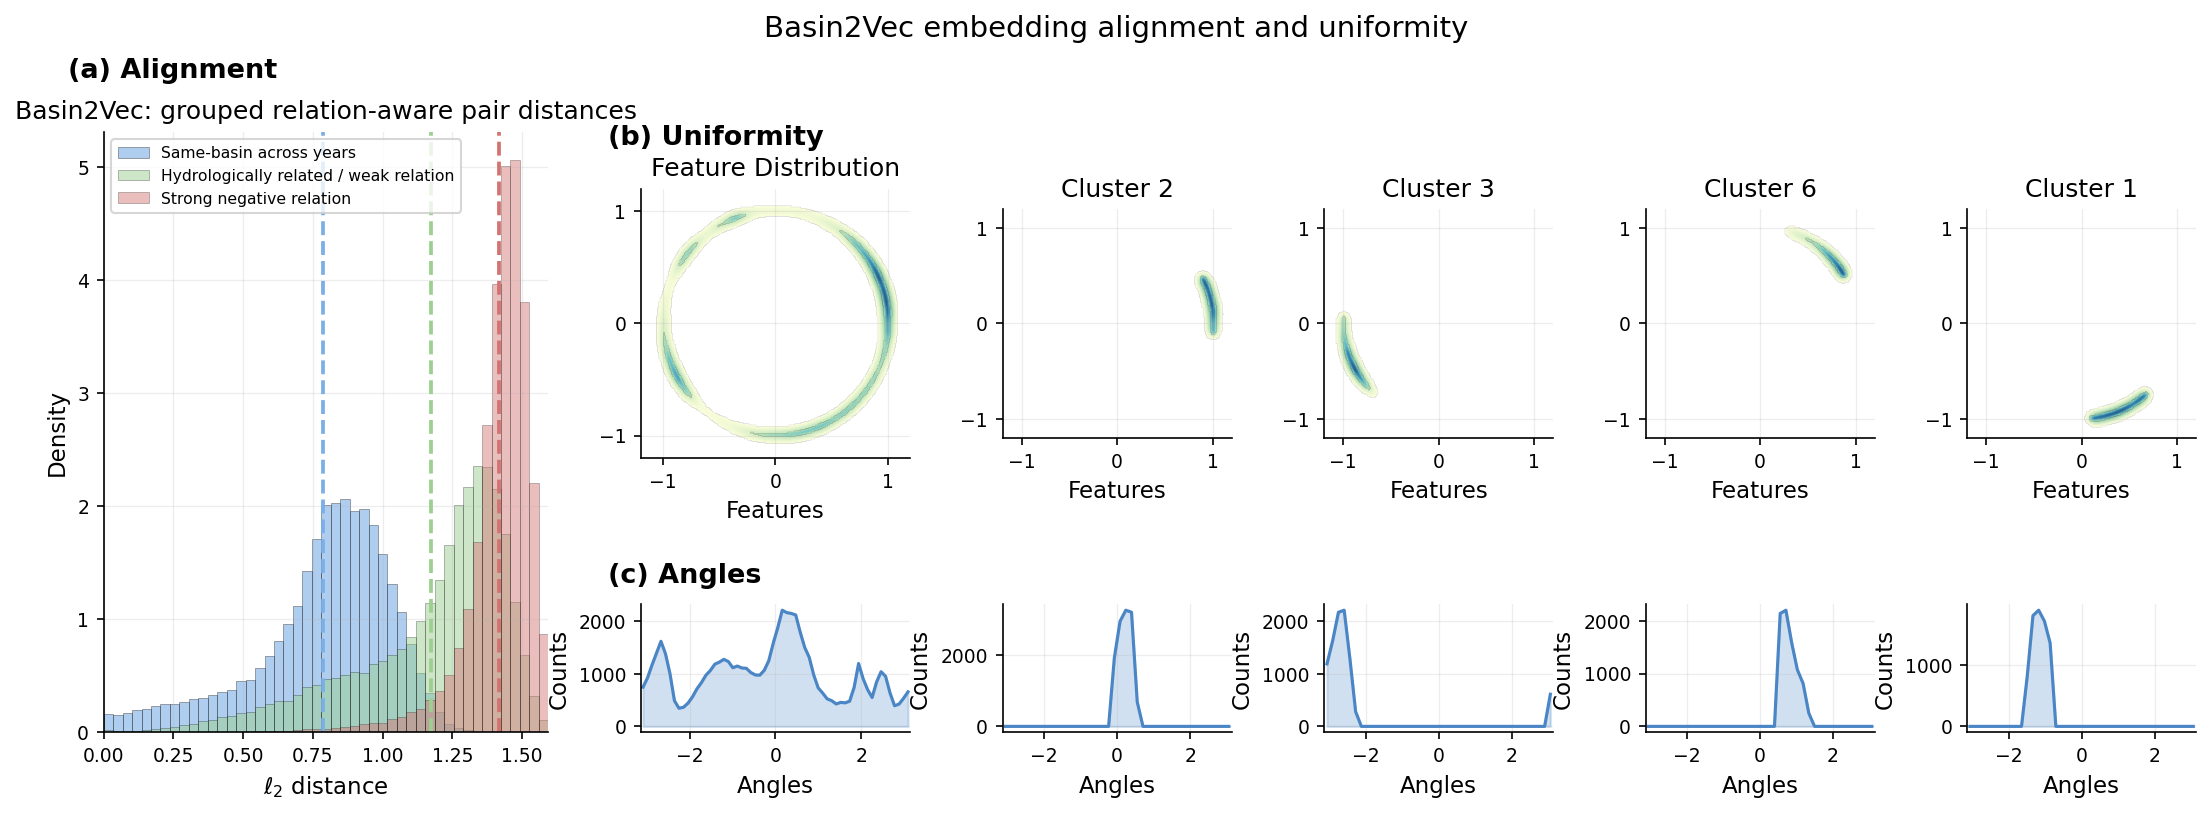


##########################################################################################
Processing model: AlphaEarth
##########################################################################################

AlphaEarth NPZ keys: alphaearth_embeddings/embeddings/alphaearth_annual_basin_embeddings_2017_2024_scale500m.npz
embeddings                          shape=(72536, 64), dtype=float32
raw_embeddings                      shape=(72536, 64), dtype=float32
site_ids                            shape=(72536,), dtype=object
labels                              shape=(72536,), dtype=object
years                               shape=(72536,), dtype=int32
bands                               shape=(64,), dtype=<U3
scale_m                             shape=(1,), dtype=int32

Loaded: AlphaEarth
  model_name: AlphaEarth
  npz_path: alphaearth_embeddings/embeddings/alphaearth_annual_basin_embeddings_2017_2024_scale500m.npz
  embedding_key: embeddings
  site_key: labels
  site_int_key: None
  year

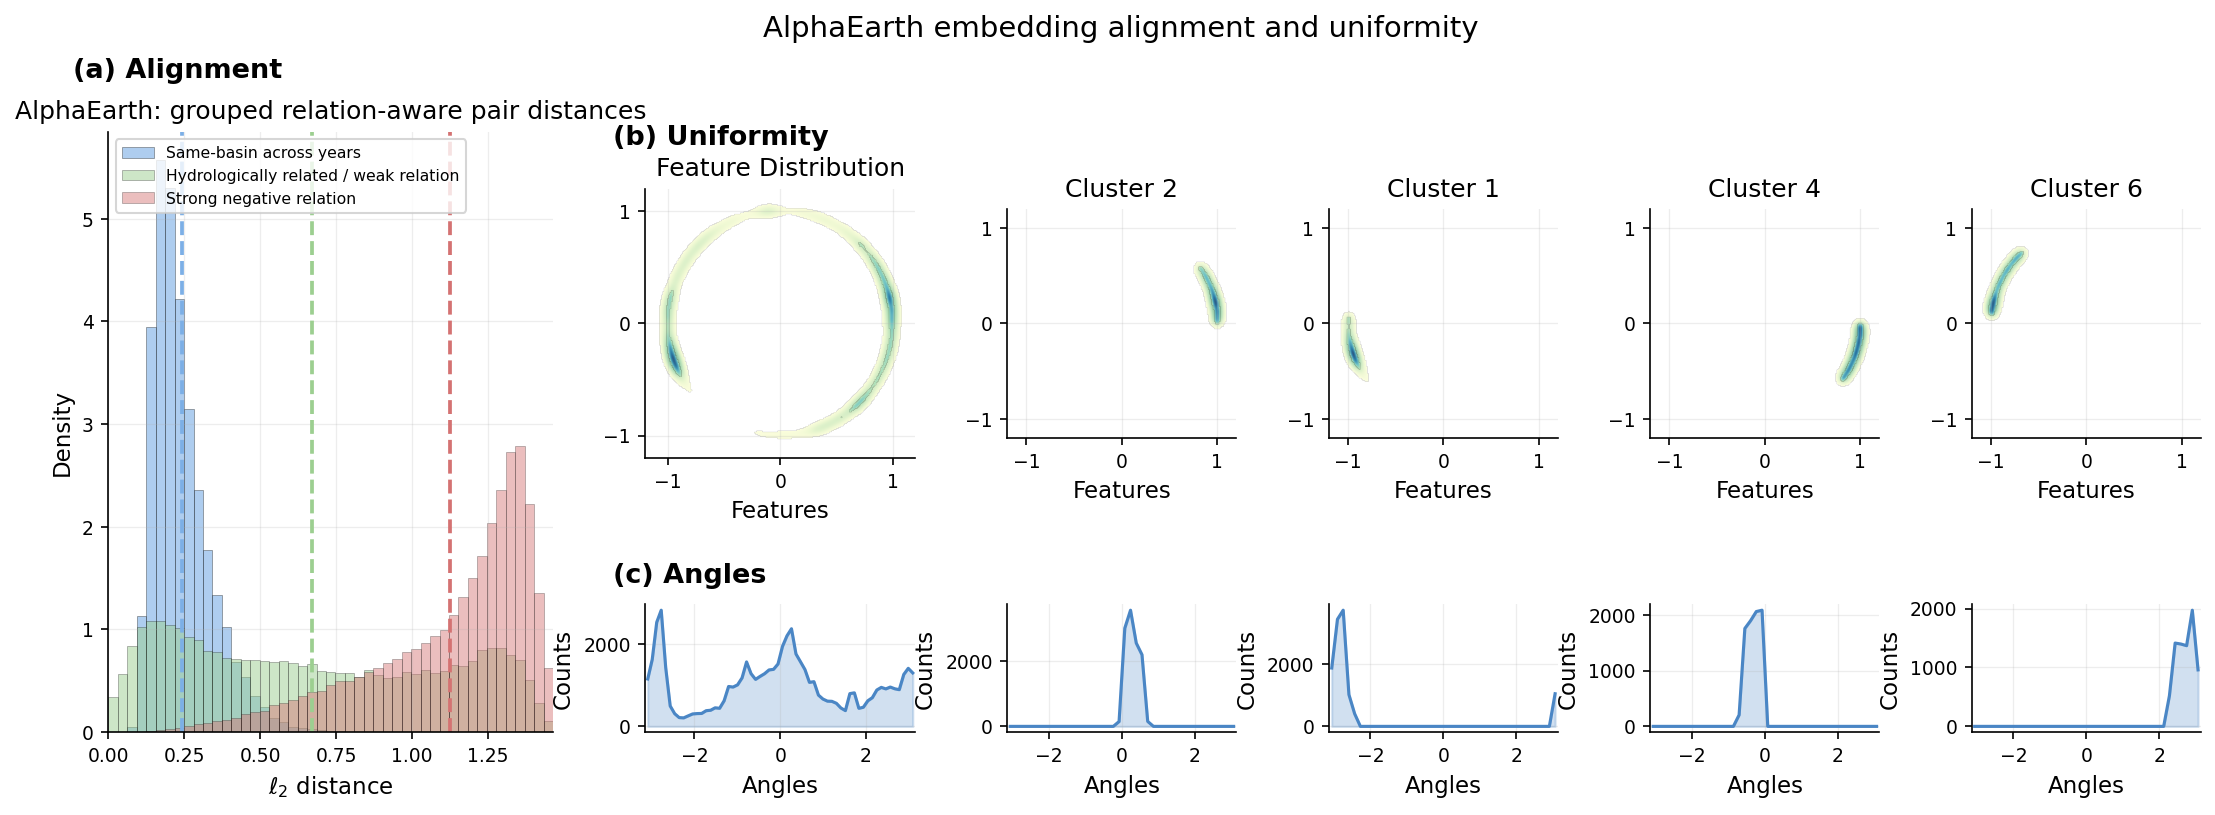


##########################################################################################
Processing model: SatCLIP
##########################################################################################

SatCLIP NPZ keys: satclip_embeddings/satclip_8point_2024_embeddings.npz
embeddings                          shape=(9067, 256), dtype=float32
X                                   shape=(9067, 256), dtype=float32
site_ids                            shape=(9067,), dtype=<U15
basin_ids                           shape=(9067,), dtype=<U15
site_id                             shape=(9067,), dtype=<U15
years                               shape=(9067,), dtype=int32
year                                shape=(9067,), dtype=int32
n_points                            shape=(9067,), dtype=int32
n_valid_points                      shape=(9067,), dtype=int32
lon_mean                            shape=(9067,), dtype=float32
lat_mean                            shape=(9067,), dtype=float32
embedding_co

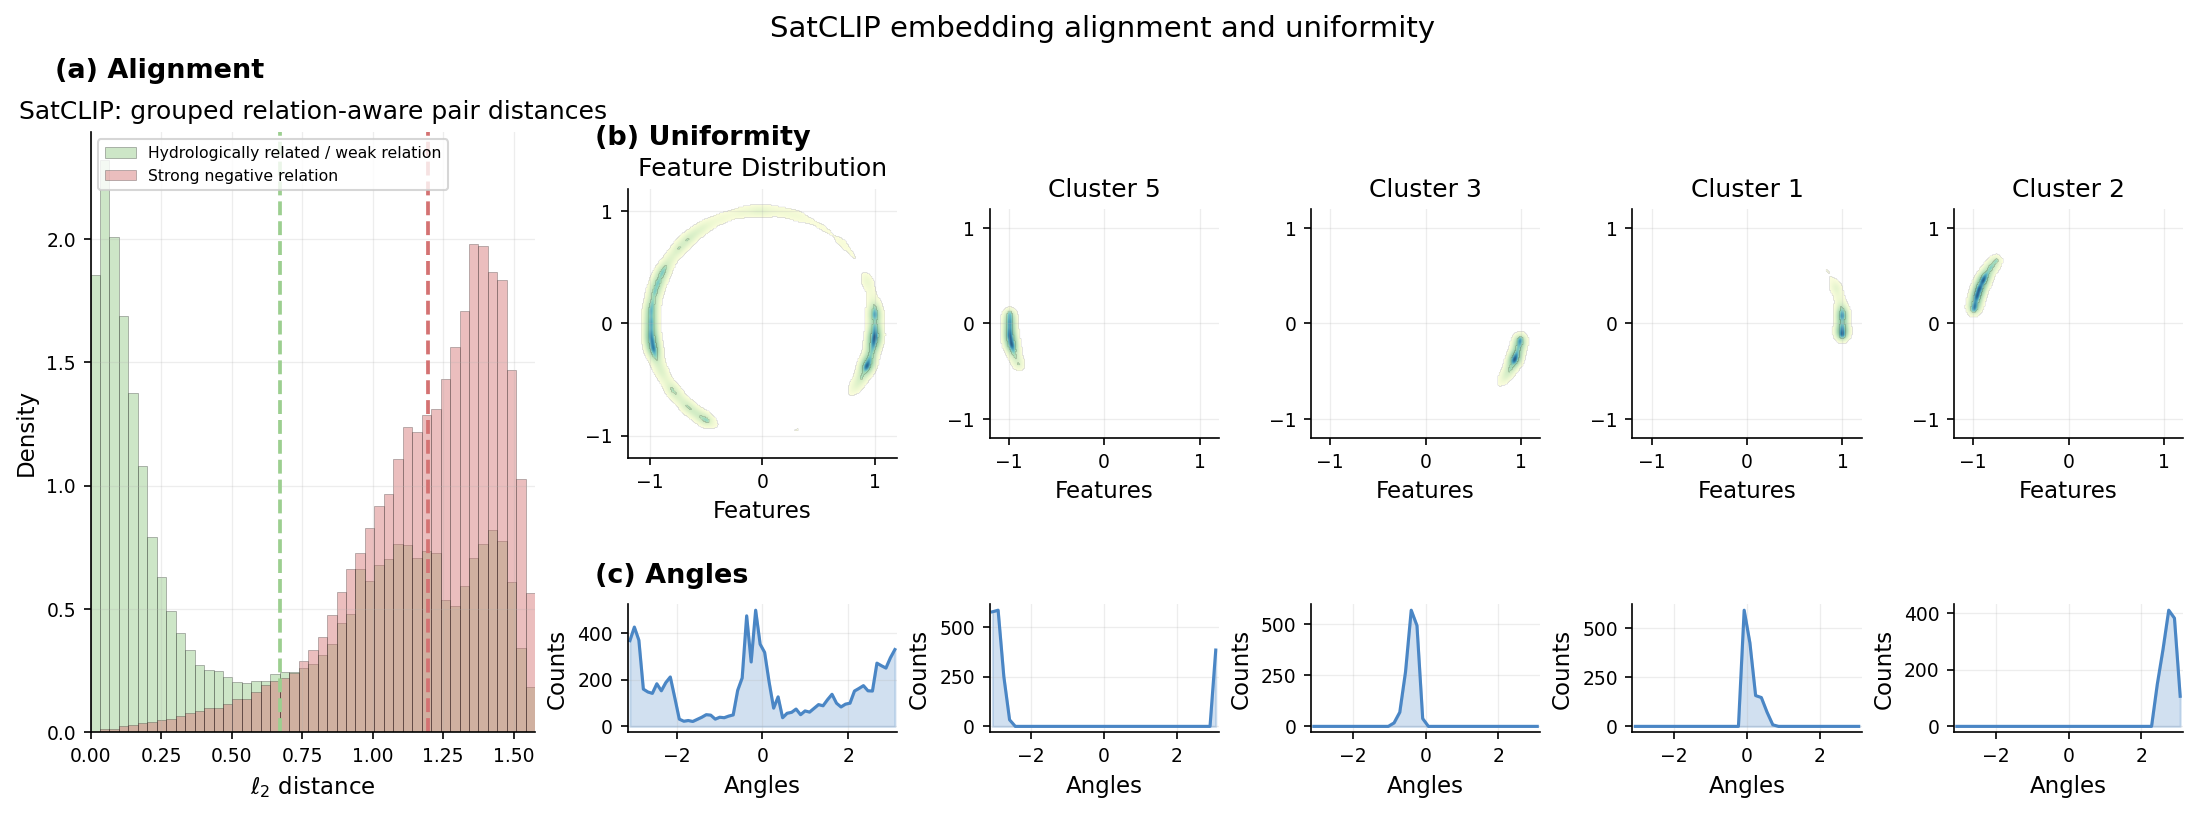


##########################################################################################
Processing model: TESSERA
##########################################################################################

TESSERA NPZ keys: tessera_embeddings/tessera_8point_2024_embeddings.npz
embeddings                          shape=(9066, 128), dtype=float32
X                                   shape=(9066, 128), dtype=float32
site_ids                            shape=(9066,), dtype=object
basin_ids                           shape=(9066,), dtype=object
years                               shape=(9066,), dtype=int32
n_points                            shape=(9066,), dtype=int32
n_valid_points                      shape=(9066,), dtype=int32
lon_mean                            shape=(9066,), dtype=float32
lat_mean                            shape=(9066,), dtype=float32
embedding_columns                   shape=(128,), dtype=object
source                              shape=(1,), dtype=object

Loaded: 

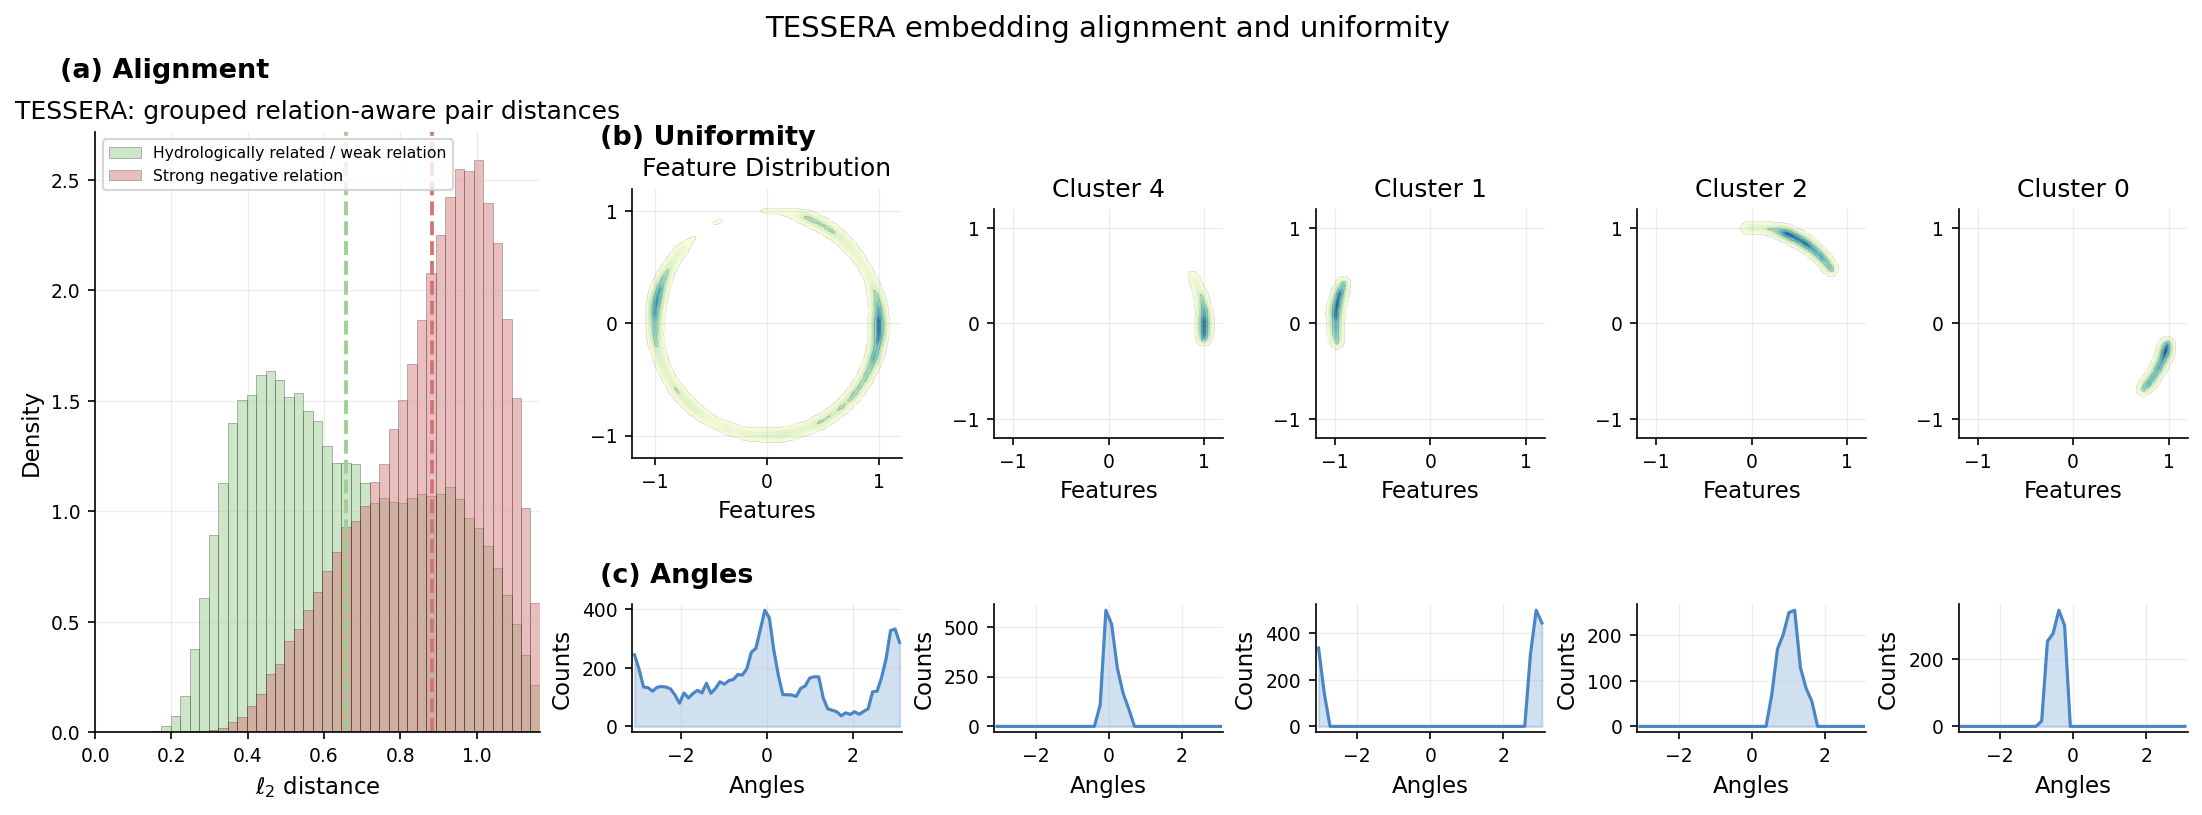


Saved all-model detailed summary:
paper_results_all_embeddings_alignment_uniformity/tables/all_models_alignment_detailed_summary.csv

Saved all-model grouped summary:
paper_results_all_embeddings_alignment_uniformity/tables/all_models_alignment_grouped_summary.csv


In [10]:
#!/usr/bin/env python3
# ==========================================================
# Alignment + uniformity plots for multiple embedding types:
#
#   1. Basin2Vec
#      - Same-basin across years
#      - Overlap/nested relation
#      - Metadata-similar non-overlap relation
#      - Metadata-dissimilar / random non-overlap negatives
#
#   2. AlphaEarth
#      - Same-basin across years
#      - Same overlap/metadata/random relations
#
#   3. SatCLIP
#      - Same-basin across sampled points, if 3D [basin, point, dim]
#      - Same overlap/metadata/random relations on basin-averaged embeddings
#
#   4. TESSERA
#      - Same-basin across sampled points, if 3D [basin, point, dim]
#      - Same overlap/metadata/random relations on basin-averaged embeddings
#
# Output:
#   paper_results_all_embeddings_alignment_uniformity/
#       figures/
#           fig_basin2vec_alignment_uniformity.png/pdf
#           fig_alphaearth_alignment_uniformity.png/pdf
#           fig_satclip_alignment_uniformity.png/pdf
#           fig_tessera_alignment_uniformity.png/pdf
#       tables/
#           all_models_alignment_detailed_summary.csv
#           all_models_alignment_grouped_summary.csv
# ==========================================================

from __future__ import annotations

from pathlib import Path
from collections import defaultdict
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")


# ==========================================================
# CONFIG
# ==========================================================

SEED = 42
RNG = np.random.default_rng(SEED)

ALPHAEARTH_NPZ = Path(
    "alphaearth_embeddings/embeddings/alphaearth_annual_basin_embeddings_2017_2024_scale500m.npz"
)
SATCLIP_NPZ = Path("satclip_embeddings/satclip_8point_2024_embeddings.npz")
TESSERA_NPZ = Path("tessera_embeddings/tessera_8point_2024_embeddings.npz")
BASIN2VEC_NPZ = Path(
    "../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz"
)

BASIN_METADATA = Path(
    "/data/basin2vec/cache/metadata/basin_metadata.parquet"
)

OVERLAP_PAIRS_PARQUET = Path(
    "/data/basin2vec/cache/basin_overlap_pairs.parquet"
)

MODEL_CONFIGS = [
    {
        "name": "Basin2Vec",
        "path": BASIN2VEC_NPZ,
        "preferred_embedding_key": "embeddings",
        "prefer_3d_points": False,
    },
    {
        "name": "AlphaEarth",
        "path": ALPHAEARTH_NPZ,
        "preferred_embedding_key": None,
        "prefer_3d_points": False,
    },
    {
        "name": "SatCLIP",
        "path": SATCLIP_NPZ,
        "preferred_embedding_key": None,
        "prefer_3d_points": True,
    },
    {
        "name": "TESSERA",
        "path": TESSERA_NPZ,
        "preferred_embedding_key": None,
        "prefer_3d_points": True,
    },
]

OVERLAP_THRESHOLD = 0.50

RESULTS_DIR = Path("paper_results_all_embeddings_alignment_uniformity")
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MAX_SAME_BASIN_PAIRS = 50_000
MAX_OVERLAP_PAIRS = 50_000
MAX_META_SIMILAR_PAIRS = 50_000
MAX_META_DISSIMILAR_PAIRS = 50_000
MAX_RANDOM_NEG_PAIRS = 50_000

META_SIMILAR_NEIGHBORS = 40
META_DISSIMILAR_CANDIDATES = 500_000

N_VIS = 60_000
N_CLUSTERS = 8
N_CLUSTER_PANELS = 4

DEFAULT_METADATA_COLUMNS = [
    "log_area_km2_z",
    "log_bbox_width_km_z",
    "log_bbox_height_km_z",
    "log_patch_pixel_width_km_z",
    "log_patch_pixel_height_km_z",
    "log_patch_pixel_area_km2_z",
    "bbox_fill_fraction_z",
    "compactness_z",
    "solidity_z",
    "log_shape_index_z",
    "log_overlap_degree_z",
]

plt.rcParams.update({
    "figure.figsize": (18, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})


# ==========================================================
# BASIC HELPERS
# ==========================================================

def normalize_site_id(x) -> str | None:
    if pd.isna(x):
        return None

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    digits = re.sub(r"\D", "", s)

    if len(digits) > 0:
        if len(digits) <= 8:
            return digits.zfill(8)
        return digits

    if len(s) == 0:
        return None

    return s


def l2_normalize(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float32)
    return x / np.clip(np.linalg.norm(x, axis=1, keepdims=True), eps, None)


def pair_distances(x, pairs):
    pairs = np.asarray(pairs, dtype=np.int64)

    if pairs.size == 0:
        return np.empty(0, dtype=np.float32)

    pairs = pairs.reshape(-1, 2)
    i = pairs[:, 0]
    j = pairs[:, 1]

    return np.linalg.norm(x[i] - x[j], axis=1).astype(np.float32)


def savefig(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, bbox_inches="tight", dpi=300)
    print(f"Saved: {path}")


def slugify(s):
    return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")


def is_numeric_array(arr):
    return np.issubdtype(np.asarray(arr).dtype, np.number)


def infer_year_from_filename(npz_path: Path) -> int | None:
    matches = re.findall(r"(?<!\d)(19\d{2}|20\d{2})(?!\d)", npz_path.name)
    if len(matches) == 0:
        return None
    return int(matches[-1])


def infer_site_id_column(df):
    candidates = [
        "site_id", "siteid", "gage_id", "gageid", "gauge_id", "gaugeid",
        "station_id", "staid", "site_no", "usgs_id", "basin_id",
        "GAGE_ID", "STAID",
    ]

    lower = {str(c).lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]

    return None


def infer_site_id_int_column(df):
    candidates = [
        "site_id_int",
        "site_int",
        "gage_id_int",
        "basin_id_int",
        "basin_index",
        "basin_idx",
        "index",
    ]

    lower = {str(c).lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]

    return None


# ==========================================================
# GENERIC NPZ LOADER
# ==========================================================

def print_npz_keys(npz_path, model_name):
    data = np.load(npz_path, allow_pickle=True)

    print("\n" + "=" * 80)
    print(f"{model_name} NPZ keys: {npz_path}")
    print("=" * 80)

    for k in data.files:
        arr = data[k]
        print(f"{k:35s} shape={arr.shape}, dtype={arr.dtype}")

    return data


def choose_embedding_array(
    data,
    preferred_key: str | None,
    model_name: str,
    prefer_3d_points: bool = False,
):
    if preferred_key is not None and preferred_key in data.files:
        arr = np.asarray(data[preferred_key])
        return preferred_key, arr.astype(np.float32)

    candidates = [
        "point_embeddings",
        "pointwise_embeddings",
        "embeddings_8point",
        "embeddings_8points",
        "basin_point_embeddings",
        "satclip_point_embeddings",
        "tessera_point_embeddings",
        "embeddings",
        "embedding",
        "raw_embeddings",
        "alphaearth_embeddings",
        "satclip_embeddings",
        "tessera_embeddings",
        "basin_embeddings",
        "avg_embeddings",
        "hydrologic_repr",
        "z",
        "features",
    ]

    if prefer_3d_points:
        for key in candidates:
            if key in data.files:
                arr = np.asarray(data[key])
                if is_numeric_array(arr) and arr.ndim == 3:
                    return key, arr.astype(np.float32)

        numeric_3d = []

        for key in data.files:
            arr = np.asarray(data[key])
            if is_numeric_array(arr) and arr.ndim == 3:
                numeric_3d.append((arr.size, key, arr))

        if len(numeric_3d) > 0:
            _, key, arr = max(numeric_3d, key=lambda x: x[0])
            print(f"Warning: using auto-detected 3D embedding key for {model_name}: {key}")
            return key, arr.astype(np.float32)

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if is_numeric_array(arr) and arr.ndim in (2, 3):
                return key, arr.astype(np.float32)

    numeric = []

    for key in data.files:
        arr = np.asarray(data[key])
        if is_numeric_array(arr) and arr.ndim in (2, 3):
            numeric.append((arr.size, key, arr))

    if len(numeric) > 0:
        _, key, arr = max(numeric, key=lambda x: x[0])
        print(f"Warning: using auto-detected embedding key for {model_name}: {key}")
        return key, arr.astype(np.float32)

    raise KeyError(
        f"Could not find embedding array for {model_name}. "
        f"Available keys: {data.files}"
    )


def choose_site_ids(data, model_name, n_expected):
    candidates = [
        "labels",
        "avg_labels",
        "site_ids",
        "site_id",
        "gage_ids",
        "gauge_ids",
        "basin_ids",
        "basin_id",
        "ids",
        "id",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr

    skip_patterns = [
        "year",
        "embedding",
        "feature",
        "coord",
        "lat",
        "lon",
        "x",
        "y",
        "point",
        "dim",
    ]

    for key in data.files:
        key_lower = key.lower()

        if any(p in key_lower for p in skip_patterns):
            continue

        arr = np.asarray(data[key])

        if arr.ndim != 1 or len(arr) != n_expected:
            continue

        if arr.dtype.kind not in {"O", "U", "S", "i", "u"}:
            continue

        if np.issubdtype(arr.dtype, np.number):
            arr_min = np.nanmin(arr)
            arr_max = np.nanmax(arr)

            if 1900 <= arr_min <= 2100 and 1900 <= arr_max <= 2100:
                continue

        print(f"Warning: using auto-detected site-id key for {model_name}: {key}")
        return key, arr

    raise KeyError(
        f"Could not find site/basin ID array for {model_name} with length {n_expected}. "
        f"Available keys: {data.files}"
    )


def choose_site_ids_int(data, n_expected):
    candidates = [
        "site_ids_int",
        "site_id_int",
        "label_ints",
        "basin_ids_int",
        "basin_id_int",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr.astype(int)

    return None, None


def choose_years(data, model_name, n_expected, npz_path):
    candidates = [
        "years",
        "year",
        "sample_years",
        "embedding_years",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr.astype(int)

    inferred_year = infer_year_from_filename(npz_path)

    if inferred_year is not None:
        years = np.full(n_expected, inferred_year, dtype=int)
        print(
            f"{model_name}: no year array found; inferred year={inferred_year} "
            f"from filename {npz_path.name}."
        )
        return "inferred_from_filename", years

    raise KeyError(
        f"Could not find years array for {model_name}, and no year could be "
        f"inferred from filename: {npz_path.name}. Available keys: {data.files}"
    )


def flatten_or_keep_embeddings(emb_raw, df_base, model_name, emb_key):
    emb_raw = np.asarray(emb_raw, dtype=np.float32)

    if emb_raw.ndim == 2:
        df = df_base.copy()
        df["point_id"] = 0

        if df["year"].nunique() > 1:
            same_mode = "years"
            same_label = "Same-basin across years"
        else:
            same_mode = "single_sample"
            same_label = "Same-basin"

        return df, emb_raw, same_mode, same_label

    if emb_raw.ndim == 3:
        n_basins, n_points, dim = emb_raw.shape

        if len(df_base) != n_basins:
            raise ValueError(
                f"{model_name}: 3D embedding first dimension does not match metadata. "
                f"emb.shape[0]={n_basins}, len(df_base)={len(df_base)}"
            )

        print(
            f"{model_name}: embedding key '{emb_key}' is 3D {emb_raw.shape}; "
            "flattening sampled points instead of averaging."
        )

        emb = emb_raw.reshape(n_basins * n_points, dim).astype(np.float32)

        df = df_base.loc[df_base.index.repeat(n_points)].copy().reset_index(drop=True)
        df["point_id"] = np.tile(np.arange(n_points), n_basins)

        same_mode = "points"
        same_label = f"Same-basin across {n_points} sampled points"

        return df, emb, same_mode, same_label

    raise ValueError(
        f"{model_name}: embedding array must be 2D or 3D. "
        f"Got shape={emb_raw.shape}."
    )


def load_embedding_npz(npz_path, model_name, preferred_embedding_key=None, prefer_3d_points=False):
    npz_path = Path(npz_path)

    if not npz_path.exists():
        raise FileNotFoundError(f"{model_name} NPZ not found: {npz_path}")

    data = print_npz_keys(npz_path, model_name)

    emb_key, emb_raw = choose_embedding_array(
        data=data,
        preferred_key=preferred_embedding_key,
        model_name=model_name,
        prefer_3d_points=prefer_3d_points,
    )

    n_base = emb_raw.shape[0]

    site_key, site_ids_raw = choose_site_ids(
        data=data,
        model_name=model_name,
        n_expected=n_base,
    )

    site_int_key, site_ids_int = choose_site_ids_int(
        data=data,
        n_expected=n_base,
    )

    year_key, years = choose_years(
        data=data,
        model_name=model_name,
        n_expected=n_base,
        npz_path=npz_path,
    )

    site_ids = np.array([normalize_site_id(x) for x in site_ids_raw], dtype=object)

    df_base = pd.DataFrame({
        "site_id": site_ids,
        "year": years.astype(int),
    })

    if site_ids_int is not None:
        df_base["site_id_int"] = site_ids_int.astype(int)

    valid = df_base["site_id"].notna().to_numpy()
    df_base = df_base.loc[valid].reset_index(drop=True)
    emb_raw = emb_raw[valid]

    df, emb, same_mode, same_label = flatten_or_keep_embeddings(
        emb_raw=emb_raw,
        df_base=df_base,
        model_name=model_name,
        emb_key=emb_key,
    )

    emb = l2_normalize(emb)

    metadata = {
        "model_name": model_name,
        "npz_path": str(npz_path),
        "embedding_key": emb_key,
        "site_key": site_key,
        "site_int_key": site_int_key,
        "year_key": year_key,
        "raw_embedding_shape": tuple(emb_raw.shape),
        "n_samples": int(len(df)),
        "n_unique_basins_before_metadata": int(df["site_id"].nunique()),
        "n_years": int(df["year"].nunique()),
        "min_year": int(df["year"].min()),
        "max_year": int(df["year"].max()),
        "embedding_dim": int(emb.shape[1]),
        "same_mode": same_mode,
        "same_label": same_label,
    }

    print("\nLoaded:", model_name)
    for k, v in metadata.items():
        print(f"  {k}: {v}")

    return df, emb, metadata


# ==========================================================
# METADATA + OVERLAP
# ==========================================================

def load_basin_metadata(metadata_path):
    metadata_path = Path(metadata_path)

    if not metadata_path.exists():
        raise FileNotFoundError(f"Could not find metadata parquet: {metadata_path}")

    meta = pd.read_parquet(metadata_path).copy()

    site_col = infer_site_id_column(meta)
    int_col = infer_site_id_int_column(meta)

    if site_col is not None:
        meta["site_id"] = meta[site_col].apply(normalize_site_id)
    else:
        raise RuntimeError("Could not infer site ID column from metadata parquet.")

    if int_col is not None:
        meta["site_id_int"] = pd.to_numeric(meta[int_col], errors="coerce").astype("Int64")
    else:
        raise RuntimeError("Could not infer integer basin ID column from metadata parquet.")

    feature_cols = [c for c in DEFAULT_METADATA_COLUMNS if c in meta.columns]

    if len(feature_cols) == 0:
        exclude = {
            site_col,
            int_col,
            "site_id",
            "site_id_int",
            "year",
            "lat",
            "lon",
            "latitude",
            "longitude",
        }

        numeric_cols = []

        for c in meta.columns:
            if c in exclude:
                continue

            x = pd.to_numeric(meta[c], errors="coerce")

            if x.notna().mean() >= 0.70 and x.std(skipna=True) > 1e-12:
                meta[c] = x
                numeric_cols.append(c)

        feature_cols = numeric_cols

    if len(feature_cols) == 0:
        raise RuntimeError("No usable metadata feature columns found.")

    for c in feature_cols:
        meta[c] = pd.to_numeric(meta[c], errors="coerce")
        meta[c] = meta[c].fillna(meta[c].median(skipna=True))

    X = meta[feature_cols].to_numpy(dtype=np.float32)
    X = (X - X.mean(axis=0, keepdims=True)) / np.clip(
        X.std(axis=0, keepdims=True),
        1e-6,
        None,
    )

    meta_features = meta[["site_id", "site_id_int"] + feature_cols].copy()
    meta_features[feature_cols] = X

    meta_features = meta_features.dropna(subset=["site_id", "site_id_int"]).copy()
    meta_features["site_id_int"] = meta_features["site_id_int"].astype(int)

    meta_features = meta_features.drop_duplicates(
        subset=["site_id_int"],
        keep="first",
    )

    print("\nLoaded basin metadata")
    print("Metadata path:", metadata_path)
    print("Site ID column:", site_col)
    print("Integer ID column:", int_col)
    print("Number of metadata basins:", len(meta_features))
    print("Metadata features:", feature_cols)

    return meta_features, feature_cols


def attach_int_ids_from_metadata(sample_df, emb, meta_features, model_name):
    sample_df = sample_df.copy()

    mapper = (
        meta_features[["site_id", "site_id_int"]]
        .dropna()
        .drop_duplicates(subset=["site_id"])
        .set_index("site_id")["site_id_int"]
        .to_dict()
    )

    mapped = sample_df["site_id"].map(mapper)

    if "site_id_int" in sample_df.columns:
        sample_df["site_id_int_original"] = sample_df["site_id_int"]
        sample_df["site_id_int"] = mapped.combine_first(sample_df["site_id_int"])
    else:
        sample_df["site_id_int"] = mapped

    missing = int(sample_df["site_id_int"].isna().sum())

    if missing > 0:
        print(
            f"Warning: {model_name}: {missing} rows could not be mapped to metadata site_id_int. "
            "Dropping those rows."
        )

    valid = sample_df["site_id_int"].notna().to_numpy()
    sample_df = sample_df.loc[valid].reset_index(drop=True)
    emb = emb[valid]

    sample_df["site_id_int"] = sample_df["site_id_int"].astype(int)

    print(
        f"{model_name}: after metadata mapping: "
        f"samples={len(sample_df)}, basins={sample_df['site_id_int'].nunique()}"
    )

    return sample_df, emb


def load_overlap_pairs_for_eval(path, threshold=0.5):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Could not find overlap pair parquet: {path}")

    df = pd.read_parquet(path).copy()

    required = {"site_id_int_a", "site_id_int_b"}
    missing = required - set(df.columns)

    if missing:
        raise ValueError(f"{path} missing required columns: {sorted(missing)}")

    score_candidates = [
        "overlap_score",
        "score",
        "overlap",
        "iou",
        "overlap_frac",
        "overlap_fraction",
    ]

    score_col = None

    for c in score_candidates:
        if c in df.columns:
            score_col = c
            break

    if score_col is not None:
        df = df[df[score_col] > threshold].copy()
        print(f"\nUsing overlap score column: {score_col}")
        print(f"Overlap threshold: > {threshold}")
    else:
        print("\nNo overlap score column found. Using all overlap pairs.")

    df["site_id_int_a"] = df["site_id_int_a"].astype(int)
    df["site_id_int_b"] = df["site_id_int_b"].astype(int)

    df = df[df["site_id_int_a"] != df["site_id_int_b"]].copy()

    print("Overlap/nested basin pairs:", len(df))

    return df, score_col


def build_overlap_set(overlap_df):
    overlap_set = set()

    for _, row in overlap_df.iterrows():
        a = int(row["site_id_int_a"])
        b = int(row["site_id_int_b"])

        if a == b:
            continue

        overlap_set.add((a, b))
        overlap_set.add((b, a))

    return overlap_set


# ==========================================================
# BASIN-LEVEL AVERAGE EMBEDDINGS
# ==========================================================

def compute_basin_average_embeddings(sample_df, emb, model_name):
    df = sample_df.copy()
    df["row"] = np.arange(len(df))

    rows = []
    avg_embs = []

    for sid_int, sub in df.groupby("site_id_int", sort=True):
        idx = sub["row"].to_numpy(dtype=int)

        z = emb[idx].mean(axis=0, keepdims=True)
        z = l2_normalize(z)[0]

        if sub["site_id"].notna().any():
            site_id = sub["site_id"].dropna().astype(str).iloc[0]
        else:
            site_id = str(sid_int)

        rows.append({
            "site_id_int": int(sid_int),
            "site_id": site_id,
            "n_samples": int(len(sub)),
            "n_years": int(sub["year"].nunique()),
            "min_year": int(sub["year"].min()),
            "max_year": int(sub["year"].max()),
        })

        avg_embs.append(z)

    avg_df = pd.DataFrame(rows)
    avg_emb = np.stack(avg_embs, axis=0).astype(np.float32)

    print(f"\n{model_name}: computed basin-level averaged embeddings")
    print("Basin-level embeddings:", avg_emb.shape)
    print("Basins:", len(avg_df))
    print("Samples per basin summary:")
    print(avg_df["n_samples"].describe())

    return avg_df, avg_emb


def prepare_avg_metadata(avg_df, avg_emb, meta_features, feature_cols, model_name):
    avg_df2 = avg_df.copy()
    avg_df2["avg_index"] = np.arange(len(avg_df2))

    merged = avg_df2.merge(
        meta_features[["site_id_int"] + feature_cols],
        on="site_id_int",
        how="inner",
    )

    if len(merged) == 0:
        raise RuntimeError(f"{model_name}: no basin-level embeddings matched to metadata.")

    emb2 = avg_emb[merged["avg_index"].to_numpy(dtype=int)]

    X_meta = merged[feature_cols].to_numpy(dtype=np.float32)
    X_meta = (X_meta - X_meta.mean(axis=0, keepdims=True)) / np.clip(
        X_meta.std(axis=0, keepdims=True),
        1e-6,
        None,
    )

    merged = merged.reset_index(drop=True)

    print(f"\n{model_name}: prepared metadata-matched basin-level embeddings")
    print("Matched basins:", len(merged))
    print("Metadata feature dim:", X_meta.shape[1])

    return merged, emb2, X_meta


# ==========================================================
# PAIR SAMPLING
# ==========================================================

def sample_same_basin_pairs(sample_df, same_mode, max_pairs=50_000):
    """
    same_mode == years:
        same basin, different years.

    same_mode == points:
        same basin, different sampled points.

    same_mode == single_sample:
        no same-basin relation available.
    """
    if same_mode == "single_sample":
        return np.empty((0, 2), dtype=np.int64)

    df = sample_df.reset_index(drop=True)

    basin_to_rows = defaultdict(list)

    for i, row in df.iterrows():
        basin_to_rows[int(row["site_id_int"])].append(
            (
                int(i),
                int(row["year"]),
                int(row.get("point_id", 0)),
            )
        )

    valid_groups = []

    for _, items in basin_to_rows.items():
        if same_mode == "years":
            vals = {yr for _, yr, _ in items}
        elif same_mode == "points":
            vals = {pt for _, _, pt in items}
        else:
            vals = set()

        if len(items) >= 2 and len(vals) >= 2:
            valid_groups.append(items)

    if len(valid_groups) == 0:
        return np.empty((0, 2), dtype=np.int64)

    pairs = []
    attempts = 0
    max_attempts = max_pairs * 80

    while len(pairs) < max_pairs and attempts < max_attempts:
        items = valid_groups[RNG.integers(0, len(valid_groups))]

        a, b = RNG.choice(len(items), size=2, replace=False)

        ia, ya, pa = items[a]
        ib, yb, pb = items[b]

        if same_mode == "years" and ya == yb:
            attempts += 1
            continue

        if same_mode == "points" and pa == pb:
            attempts += 1
            continue

        pairs.append((ia, ib))
        attempts += 1

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_overlap_positive_pairs(avg_df, overlap_df, max_pairs=50_000):
    label_to_idx = {
        int(row.site_id_int): int(i)
        for i, row in avg_df.reset_index(drop=True).iterrows()
    }

    pairs = []

    for _, row in overlap_df.iterrows():
        a = int(row["site_id_int_a"])
        b = int(row["site_id_int_b"])

        if a in label_to_idx and b in label_to_idx:
            pairs.append((label_to_idx[a], label_to_idx[b]))

    if len(pairs) > max_pairs:
        keep = RNG.choice(len(pairs), size=max_pairs, replace=False)
        pairs = [pairs[i] for i in keep]

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_random_nonoverlap_pairs(avg_df, overlap_set, max_pairs=50_000):
    labels = avg_df["site_id_int"].to_numpy(dtype=int)
    n = len(labels)

    pairs = []
    attempts = 0
    max_attempts = max_pairs * 80

    while len(pairs) < max_pairs and attempts < max_attempts:
        i = int(RNG.integers(0, n))
        j = int(RNG.integers(0, n))

        attempts += 1

        if i == j:
            continue

        a = int(labels[i])
        b = int(labels[j])

        if a == b:
            continue

        if (a, b) in overlap_set:
            continue

        pairs.append((i, j))

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_metadata_similar_nonoverlap_pairs(
    avg_meta_df,
    X_meta,
    overlap_set,
    max_pairs=50_000,
    n_neighbors=40,
):
    labels = avg_meta_df["site_id_int"].to_numpy(dtype=int)
    n = len(labels)

    if n < 2:
        return np.empty((0, 2), dtype=np.int64)

    nn = NearestNeighbors(
        n_neighbors=min(n_neighbors + 1, n),
        metric="euclidean",
        algorithm="auto",
    )

    nn.fit(X_meta)
    _, indices = nn.kneighbors(X_meta)

    pairs = []

    for i in range(n):
        a = int(labels[i])

        for jj in indices[i, 1:]:
            j = int(jj)
            b = int(labels[j])

            if a == b:
                continue

            if (a, b) in overlap_set:
                continue

            pairs.append((i, j))

            if len(pairs) >= max_pairs:
                break

        if len(pairs) >= max_pairs:
            break

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_metadata_dissimilar_nonoverlap_pairs(
    avg_meta_df,
    X_meta,
    overlap_set,
    max_pairs=50_000,
    n_candidates=500_000,
):
    labels = avg_meta_df["site_id_int"].to_numpy(dtype=int)
    n = len(labels)

    if n < 2:
        return np.empty((0, 2), dtype=np.int64)

    cand_i = []
    cand_j = []
    cand_d = []

    total_collected = 0
    attempts = 0
    max_attempts = n_candidates * 20

    while total_collected < n_candidates and attempts < max_attempts:
        batch = min(50_000, n_candidates - total_collected)

        i = RNG.integers(0, n, size=batch)
        j = RNG.integers(0, n, size=batch)

        attempts += batch

        valid = i != j
        i = i[valid]
        j = j[valid]

        if len(i) == 0:
            continue

        a = labels[i]
        b = labels[j]

        keep = np.ones(len(i), dtype=bool)

        for idx, (aa, bb) in enumerate(zip(a, b)):
            if aa == bb:
                keep[idx] = False
            elif (int(aa), int(bb)) in overlap_set:
                keep[idx] = False

        if keep.sum() == 0:
            continue

        i2 = i[keep]
        j2 = j[keep]

        d = np.linalg.norm(X_meta[i2] - X_meta[j2], axis=1)

        cand_i.append(i2)
        cand_j.append(j2)
        cand_d.append(d)

        total_collected += len(i2)

    if len(cand_i) == 0:
        return np.empty((0, 2), dtype=np.int64)

    cand_i = np.concatenate(cand_i)
    cand_j = np.concatenate(cand_j)
    cand_d = np.concatenate(cand_d)

    order = np.argsort(-cand_d)
    order = order[:min(max_pairs, len(order))]

    pairs = np.stack([cand_i[order], cand_j[order]], axis=1).astype(np.int64)

    return pairs.reshape(-1, 2)


# ==========================================================
# UNIFORMITY HELPERS
# ==========================================================

def project_to_unit_circle_shared(x):
    x = np.asarray(x, dtype=np.float32)

    if len(x) < 2:
        raise RuntimeError("Need at least two samples for PCA projection.")

    pca = PCA(n_components=2, random_state=SEED)
    xy = pca.fit_transform(x)

    xy_unit = xy / np.clip(
        np.linalg.norm(xy, axis=1, keepdims=True),
        1e-12,
        None,
    )

    return xy_unit.astype(np.float32)


def angles_from_xy(xy_unit):
    return np.arctan2(xy_unit[:, 1], xy_unit[:, 0])


def choose_clusters_by_size(cluster_labels, top_k=4):
    unique, counts = np.unique(cluster_labels, return_counts=True)
    order = np.argsort(-counts)
    return unique[order[:top_k]]


def add_panel_label(ax, label, x=-0.08, y=1.08, fontsize=13):
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=fontsize,
        fontweight="bold",
        clip_on=False,
    )


def plot_ring_density_soft(
    ax,
    xy_unit,
    title="",
    bins=220,
    sigma_mid=4.0,
    sigma_inner=2.0,
    alpha_mid=0.45,
    alpha_inner=0.65,
    show_points=False,
):
    x = xy_unit[:, 0]
    y = xy_unit[:, 1]

    H, _, _ = np.histogram2d(
        x,
        y,
        bins=bins,
        range=[[-1.25, 1.25], [-1.25, 1.25]],
    )

    extent = [-1.25, 1.25, -1.25, 1.25]

    H_mid = gaussian_filter(H, sigma=sigma_mid)
    H_inner = gaussian_filter(H, sigma=sigma_inner)

    def normalize(A):
        A = A.astype(float)
        if A.max() > 0:
            A = A / A.max()
        return A

    H_mid = normalize(H_mid)
    H_inner = normalize(H_inner)

    mid = np.ma.masked_where(H_mid < 0.12, H_mid)
    inner = np.ma.masked_where(H_inner < 0.35, H_inner)

    ax.imshow(
        mid.T,
        origin="lower",
        extent=extent,
        cmap="YlGn",
        alpha=alpha_mid,
        interpolation="bilinear",
        aspect="equal",
        vmin=0,
        vmax=1,
    )

    ax.imshow(
        inner.T,
        origin="lower",
        extent=extent,
        cmap="GnBu",
        alpha=alpha_inner,
        interpolation="bilinear",
        aspect="equal",
        vmin=0,
        vmax=1,
    )

    if show_points:
        ax.scatter(
            x,
            y,
            s=5,
            alpha=0.015,
            color="black",
            edgecolors="none",
            rasterized=True,
        )

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect("equal")

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Features")
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


def plot_angle_hist(ax, angles, color="#4a86c5", bins=50):
    hist, edges = np.histogram(
        angles,
        bins=bins,
        range=(-np.pi, np.pi),
        density=False,
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    ax.fill_between(centers, hist, alpha=0.25, color=color)
    ax.plot(centers, hist, linewidth=1.5, color=color)

    ax.set_xlim(-np.pi, np.pi)
    ax.set_xlabel("Angles")
    ax.set_ylabel("Counts")


# ==========================================================
# MODEL ANALYSIS + PLOT
# ==========================================================

def summarize_relation(model_name, relation_name, grouped_relation, distances):
    d = np.asarray(distances, dtype=np.float64)

    if len(d) == 0:
        return {
            "model": model_name,
            "relation": relation_name,
            "grouped_relation": grouped_relation,
            "n_pairs": 0,
            "mean_l2_distance": np.nan,
            "median_l2_distance": np.nan,
            "std_l2_distance": np.nan,
            "p05_l2_distance": np.nan,
            "p95_l2_distance": np.nan,
        }

    return {
        "model": model_name,
        "relation": relation_name,
        "grouped_relation": grouped_relation,
        "n_pairs": int(len(d)),
        "mean_l2_distance": float(np.mean(d)),
        "median_l2_distance": float(np.median(d)),
        "std_l2_distance": float(np.std(d)),
        "p05_l2_distance": float(np.percentile(d, 5)),
        "p95_l2_distance": float(np.percentile(d, 95)),
    }


def analyze_one_model(
    model_name,
    sample_df,
    emb,
    meta,
    meta_features,
    feature_cols,
    overlap_df,
    overlap_set,
):
    same_mode = meta["same_mode"]
    same_label = meta["same_label"]

    avg_df, avg_emb = compute_basin_average_embeddings(
        sample_df=sample_df,
        emb=emb,
        model_name=model_name,
    )

    avg_meta_df, avg_meta_emb, X_meta = prepare_avg_metadata(
        avg_df=avg_df,
        avg_emb=avg_emb,
        meta_features=meta_features,
        feature_cols=feature_cols,
        model_name=model_name,
    )

    # ------------------------------------------------------
    # 1. Same-basin relation
    # ------------------------------------------------------
    same_pairs = sample_same_basin_pairs(
        sample_df=sample_df,
        same_mode=same_mode,
        max_pairs=MAX_SAME_BASIN_PAIRS,
    )

    same_dist = pair_distances(
        emb,
        same_pairs,
    )

    # ------------------------------------------------------
    # 2. Overlap / nested relation
    # ------------------------------------------------------
    overlap_pairs = sample_overlap_positive_pairs(
        avg_df=avg_df,
        overlap_df=overlap_df,
        max_pairs=MAX_OVERLAP_PAIRS,
    )

    overlap_dist = pair_distances(
        avg_emb,
        overlap_pairs,
    )

    # ------------------------------------------------------
    # 3. Metadata-similar non-overlap relation
    # ------------------------------------------------------
    meta_sim_pairs = sample_metadata_similar_nonoverlap_pairs(
        avg_meta_df=avg_meta_df,
        X_meta=X_meta,
        overlap_set=overlap_set,
        max_pairs=MAX_META_SIMILAR_PAIRS,
        n_neighbors=META_SIMILAR_NEIGHBORS,
    )

    meta_sim_dist = pair_distances(
        avg_meta_emb,
        meta_sim_pairs,
    )

    # ------------------------------------------------------
    # 4. Metadata-dissimilar non-overlap relation
    # ------------------------------------------------------
    meta_dis_pairs = sample_metadata_dissimilar_nonoverlap_pairs(
        avg_meta_df=avg_meta_df,
        X_meta=X_meta,
        overlap_set=overlap_set,
        max_pairs=MAX_META_DISSIMILAR_PAIRS,
        n_candidates=META_DISSIMILAR_CANDIDATES,
    )

    meta_dis_dist = pair_distances(
        avg_meta_emb,
        meta_dis_pairs,
    )

    # ------------------------------------------------------
    # 5. Random non-overlap negative relation
    # ------------------------------------------------------
    random_neg_pairs = sample_random_nonoverlap_pairs(
        avg_df=avg_df,
        overlap_set=overlap_set,
        max_pairs=MAX_RANDOM_NEG_PAIRS,
    )

    random_neg_dist = pair_distances(
        avg_emb,
        random_neg_pairs,
    )

    related_or_weak_parts = [
        d for d in [overlap_dist, meta_sim_dist]
        if len(d) > 0
    ]

    strong_negative_parts = [
        d for d in [meta_dis_dist, random_neg_dist]
        if len(d) > 0
    ]

    related_or_weak_dist = (
        np.concatenate(related_or_weak_parts).astype(np.float32)
        if len(related_or_weak_parts) > 0
        else np.empty(0, dtype=np.float32)
    )

    strong_negative_dist = (
        np.concatenate(strong_negative_parts).astype(np.float32)
        if len(strong_negative_parts) > 0
        else np.empty(0, dtype=np.float32)
    )

    relation_distances = []

    if len(same_dist) > 0:
        relation_distances.append({
            "name": same_label,
            "short": "Same basin",
            "dist": same_dist,
            "color": "#7cafe6",
            "alpha": 0.62,
        })

    relation_distances.extend([
        {
            "name": "Hydrologically related / weak relation",
            "short": "Related / weak",
            "dist": related_or_weak_dist,
            "color": "#9ccf90",
            "alpha": 0.50,
        },
        {
            "name": "Strong negative relation",
            "short": "Strong negative",
            "dist": strong_negative_dist,
            "color": "#d47272",
            "alpha": 0.46,
        },
    ])

    detailed_rows = [
        summarize_relation(
            model_name,
            same_label,
            "Same-basin relation",
            same_dist,
        ),
        summarize_relation(
            model_name,
            f"Overlap/nested+: overlap > {OVERLAP_THRESHOLD}",
            "Hydrologically related / weak relation",
            overlap_dist,
        ),
        summarize_relation(
            model_name,
            "Metadata-similar non-overlap",
            "Hydrologically related / weak relation",
            meta_sim_dist,
        ),
        summarize_relation(
            model_name,
            "Metadata-dissimilar non-overlap",
            "Strong negative relation",
            meta_dis_dist,
        ),
        summarize_relation(
            model_name,
            "Random non-overlap negative",
            "Strong negative relation",
            random_neg_dist,
        ),
    ]

    grouped_rows = []

    for r in relation_distances:
        grouped_rows.append(
            summarize_relation(
                model_name=model_name,
                relation_name=r["name"],
                grouped_relation=r["name"],
                distances=r["dist"],
            )
        )

    return {
        "model_name": model_name,
        "sample_df": sample_df,
        "emb": emb,
        "avg_df": avg_df,
        "avg_emb": avg_emb,
        "same_label": same_label,
        "same_mode": same_mode,
        "relation_distances": relation_distances,
        "detailed_rows": detailed_rows,
        "grouped_rows": grouped_rows,
    }


def plot_one_model(result):
    model_name = result["model_name"]
    emb = result["emb"]
    relation_distances = result["relation_distances"]

    valid_relation_distances = [
        r for r in relation_distances
        if len(r["dist"]) > 0
    ]

    if len(valid_relation_distances) == 0:
        print(f"Skipping plot for {model_name}: no valid relation distances.")
        return

    # ------------------------------------------------------
    # Uniformity data
    # ------------------------------------------------------
    n_vis = min(N_VIS, len(emb))

    if n_vis < 10:
        print(f"Skipping uniformity plot for {model_name}: too few samples.")
        return

    sample_proj_idx = RNG.choice(len(emb), size=n_vis, replace=False)
    emb_vis = emb[sample_proj_idx]

    xy_unit_all = project_to_unit_circle_shared(emb_vis)
    angles_all = angles_from_xy(xy_unit_all)

    n_clusters = min(N_CLUSTERS, len(xy_unit_all))

    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=SEED,
        batch_size=4096,
        n_init=10,
    )

    sample_clusters = kmeans.fit_predict(xy_unit_all)

    selected_clusters = choose_clusters_by_size(
        sample_clusters,
        top_k=min(N_CLUSTER_PANELS, n_clusters),
    )

    print(f"\n{model_name}: selected clusters:", selected_clusters.tolist())

    # ------------------------------------------------------
    # Plot
    # ------------------------------------------------------
    fig = plt.figure(figsize=(18, 5.2))

    gs = GridSpec(
        2,
        2 + len(selected_clusters),
        width_ratios=[1.65, 1.0] + [0.85] * len(selected_clusters),
        height_ratios=[3, 1],
        wspace=0.34,
        hspace=0.35,
    )

    # ------------------------------------------------------
    # (a) Grouped alignment histogram
    # ------------------------------------------------------
    ax_align = fig.add_subplot(gs[:, 0])

    max_x = max(
        np.percentile(r["dist"], 99)
        for r in valid_relation_distances
        if len(r["dist"]) > 0
    )

    bins = np.linspace(0, max_x, 48)

    for r in valid_relation_distances:
        d = np.asarray(r["dist"], dtype=np.float32)

        ax_align.hist(
            d,
            bins=bins,
            density=True,
            alpha=r["alpha"],
            color=r["color"],
            edgecolor="black",
            linewidth=0.25,
            label=r["name"],
        )

        ax_align.axvline(
            np.mean(d),
            linestyle="--",
            color=r["color"],
            linewidth=1.8,
        )

    add_panel_label(ax_align, "(a) Alignment", x=-0.08, y=1.08)

    ax_align.set_title(
        f"{model_name}: grouped relation-aware pair distances",
        fontsize=12,
    )

    ax_align.set_xlabel(r"$\ell_2$ distance")
    ax_align.set_ylabel("Density")

    ax_align.legend(
        fontsize=7.5,
        frameon=True,
        loc="upper left",
    )

    ax_align.set_xlim(0, max_x)

    # ------------------------------------------------------
    # (b) Overall uniformity
    # ------------------------------------------------------
    ax_uniform_top = fig.add_subplot(gs[0, 1])

    plot_ring_density_soft(
        ax_uniform_top,
        xy_unit_all,
        title="Feature Distribution",
        bins=240,
        sigma_mid=4.5,
        sigma_inner=2.2,
        alpha_mid=0.50,
        alpha_inner=0.70,
    )

    add_panel_label(ax_uniform_top, "(b) Uniformity", x=-0.12, y=1.14)

    # ------------------------------------------------------
    # (c) Overall angle distribution
    # ------------------------------------------------------
    ax_uniform_bottom = fig.add_subplot(gs[1, 1])

    plot_angle_hist(
        ax_uniform_bottom,
        angles_all,
        color="#4a86c5",
        bins=60,
    )

    add_panel_label(ax_uniform_bottom, "(c) Angles", x=-0.12, y=1.12)

    # ------------------------------------------------------
    # Cluster-level uniformity and angle panels
    # ------------------------------------------------------
    cluster_top_axes = []
    cluster_bottom_axes = []

    for col_offset, cluster_id in enumerate(selected_clusters, start=2):
        mask = sample_clusters == cluster_id

        xy_cluster = xy_unit_all[mask]
        angles_cluster = angles_from_xy(xy_cluster)

        ax_top = fig.add_subplot(gs[0, col_offset])

        plot_ring_density_soft(
            ax_top,
            xy_cluster,
            title=f"Cluster {cluster_id}",
            bins=200,
            sigma_mid=4.0,
            sigma_inner=2.0,
            alpha_mid=0.48,
            alpha_inner=0.72,
        )

        cluster_top_axes.append(ax_top)

        ax_bottom = fig.add_subplot(gs[1, col_offset])

        plot_angle_hist(
            ax_bottom,
            angles_cluster,
            color="#4a86c5",
            bins=40,
        )

        cluster_bottom_axes.append(ax_bottom)

    all_axes = (
        [ax_align, ax_uniform_top, ax_uniform_bottom]
        + cluster_top_axes
        + cluster_bottom_axes
    )

    for ax in all_axes:
        ax.grid(True, alpha=0.22, linewidth=0.6)
        ax.tick_params(axis="both", labelsize=9)

        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

    fig.suptitle(
        f"{model_name} embedding alignment and uniformity",
        fontsize=14,
        y=1.03,
    )

    out_slug = slugify(model_name)

    out_pdf = FIG_DIR / f"fig_{out_slug}_alignment_uniformity.pdf"
    out_png = FIG_DIR / f"fig_{out_slug}_alignment_uniformity.png"

    savefig(out_pdf)
    savefig(out_png)

    plt.show()


# ==========================================================
# MAIN
# ==========================================================

def main():
    # ------------------------------------------------------
    # Load shared metadata and overlap pairs
    # ------------------------------------------------------
    meta_features, feature_cols = load_basin_metadata(BASIN_METADATA)

    overlap_df, overlap_score_col = load_overlap_pairs_for_eval(
        OVERLAP_PAIRS_PARQUET,
        threshold=OVERLAP_THRESHOLD,
    )

    overlap_set = build_overlap_set(overlap_df)

    all_detailed_rows = []
    all_grouped_rows = []

    # ------------------------------------------------------
    # Loop over models
    # ------------------------------------------------------
    for cfg in MODEL_CONFIGS:
        model_name = cfg["name"]

        print("\n" + "#" * 90)
        print(f"Processing model: {model_name}")
        print("#" * 90)

        sample_df, emb, model_meta = load_embedding_npz(
            npz_path=cfg["path"],
            model_name=model_name,
            preferred_embedding_key=cfg.get("preferred_embedding_key"),
            prefer_3d_points=cfg.get("prefer_3d_points", False),
        )

        sample_df, emb = attach_int_ids_from_metadata(
            sample_df=sample_df,
            emb=emb,
            meta_features=meta_features,
            model_name=model_name,
        )

        if len(sample_df) == 0:
            print(f"Skipping {model_name}: no samples after metadata mapping.")
            continue

        result = analyze_one_model(
            model_name=model_name,
            sample_df=sample_df,
            emb=emb,
            meta=model_meta,
            meta_features=meta_features,
            feature_cols=feature_cols,
            overlap_df=overlap_df,
            overlap_set=overlap_set,
        )

        all_detailed_rows.extend(result["detailed_rows"])
        all_grouped_rows.extend(result["grouped_rows"])

        detailed_tmp = pd.DataFrame(result["detailed_rows"])
        grouped_tmp = pd.DataFrame(result["grouped_rows"])

        print(f"\n{model_name}: detailed alignment summary:")
        print(detailed_tmp.to_string(index=False))

        print(f"\n{model_name}: grouped alignment summary:")
        print(grouped_tmp.to_string(index=False))

        plot_one_model(result)

    # ------------------------------------------------------
    # Save all summaries
    # ------------------------------------------------------
    detailed_summary = pd.DataFrame(all_detailed_rows)
    grouped_summary = pd.DataFrame(all_grouped_rows)

    detailed_path = TABLE_DIR / "all_models_alignment_detailed_summary.csv"
    grouped_path = TABLE_DIR / "all_models_alignment_grouped_summary.csv"

    detailed_summary.to_csv(detailed_path, index=False)
    grouped_summary.to_csv(grouped_path, index=False)

    print("\nSaved all-model detailed summary:")
    print(detailed_path)

    print("\nSaved all-model grouped summary:")
    print(grouped_path)


if __name__ == "__main__":
    main()


Candidate AlphaEarth NPZ files:
  [0] /home/talhamuh/basin2vec/emb/evaluation/alphaearth_embeddings/embeddings/alphaearth_annual_basin_embeddings_2017_2024_scale500m.npz

Using AlphaEarth NPZ: /home/talhamuh/basin2vec/emb/evaluation/alphaearth_embeddings/embeddings/alphaearth_annual_basin_embeddings_2017_2024_scale500m.npz

Available keys in AlphaEarth NPZ:
  embeddings                shape=(72536, 64), dtype=float32
  raw_embeddings            shape=(72536, 64), dtype=float32
  site_ids                  shape=(72536,), dtype=object
  labels                    shape=(72536,), dtype=object
  years                     shape=(72536,), dtype=int32
  bands                     shape=(64,), dtype=<U3
  scale_m                   shape=(1,), dtype=int32

Loaded AlphaEarth annual embeddings
Embedding shape: (72536, 64)
Rows: 72536
Unique basins: 9067
Year range: 2017 - 2024

Loaded basin metadata
Number of metadata basins: 9067
Metadata features: ['log_area_km2_z', 'log_bbox_width_km_z', 'log_b

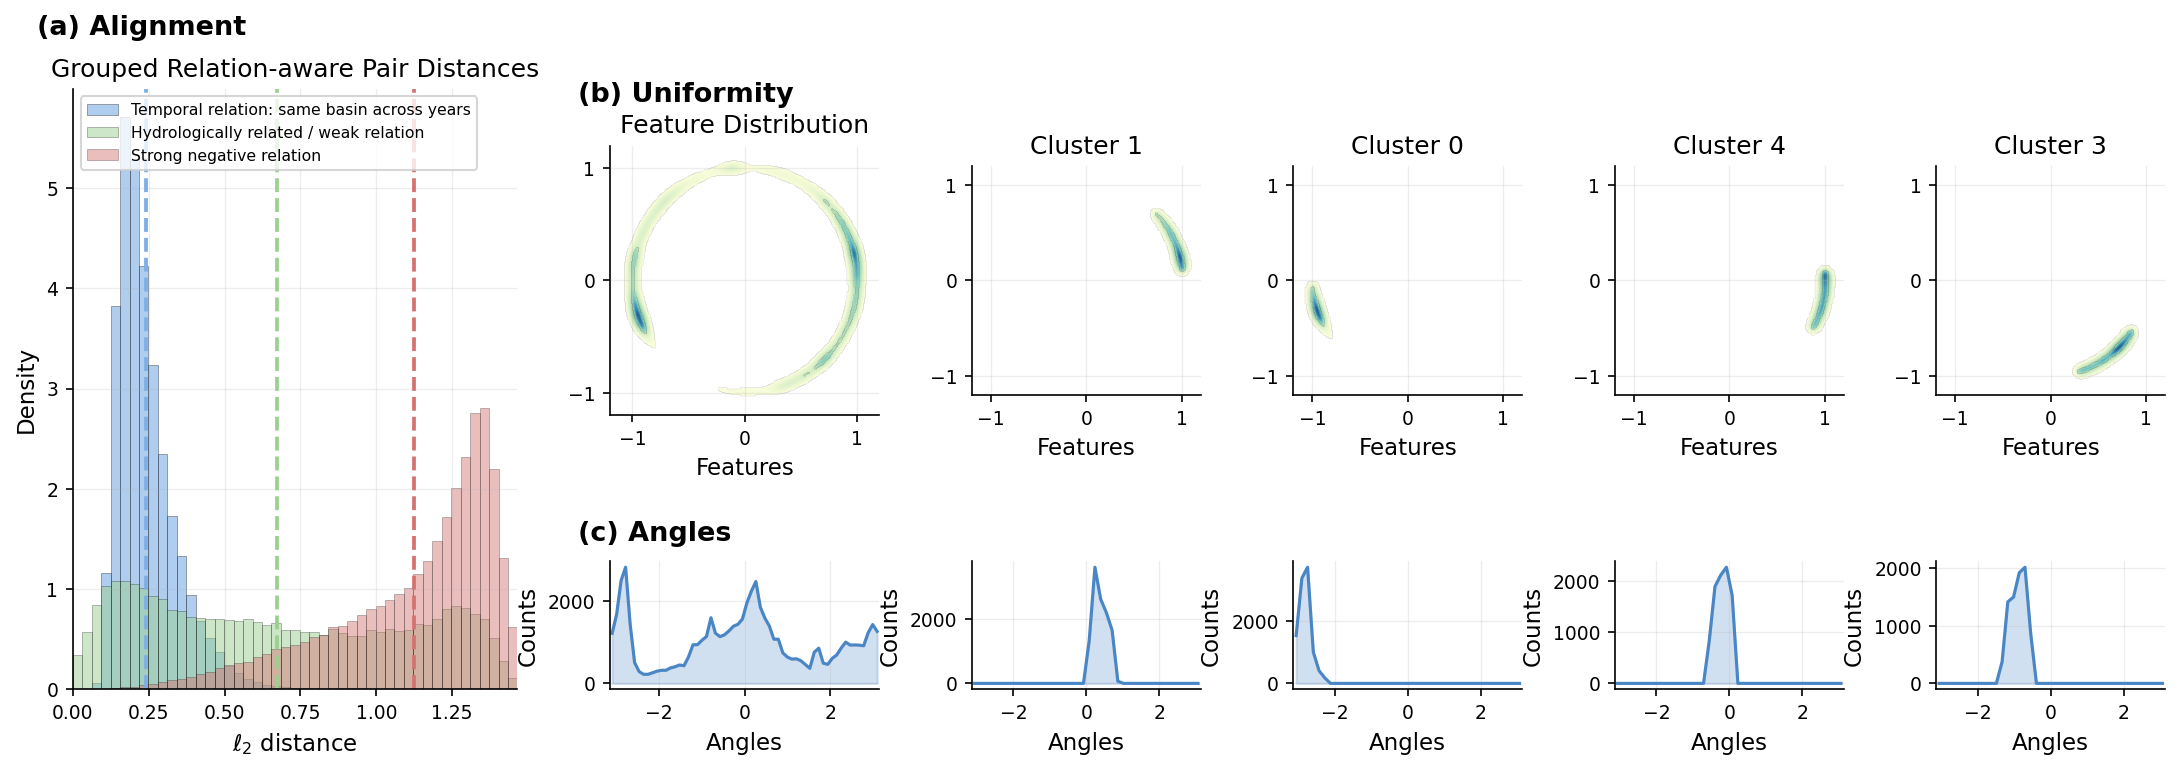

In [16]:
#!/usr/bin/env python3
# ==========================================================
# AlphaEarth grouped alignment + uniformity plot
#
# Creates the same type of figure as the Basin2Vec version:
#
#   (a) Alignment:
#       - Temporal relation: same basin across years
#       - Hydrologically related / weak relation:
#           overlap/nested + metadata-similar non-overlap
#       - Strong negative relation:
#           metadata-dissimilar non-overlap + random non-overlap
#
#   (b) Uniformity:
#       feature distribution on unit-circle projection
#
#   (c) Angles:
#       overall and cluster-specific angle distributions
#
# Run:
#   python plot_alphaearth_grouped_alignment_uniformity.py
# ==========================================================

from pathlib import Path
from collections import defaultdict
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")


# ==========================================================
# CONFIG
# ==========================================================

SEED = 42
RNG = np.random.default_rng(SEED)

ALPHAEARTH_DIR = Path(
    "/home/talhamuh/basin2vec/emb/evaluation/alphaearth_embeddings/embeddings/"
)

# If you know the exact file, set it here. Otherwise leave None and
# the code will try to find one automatically in ALPHAEARTH_DIR.
ALPHAEARTH_NPZ = None
# Example:
# ALPHAEARTH_NPZ = ALPHAEARTH_DIR / "alphaearth_annual_basin_embeddings_2017_2024_scale500m.npz"

BASIN_METADATA = Path("/data/basin2vec/cache/metadata/basin_metadata.parquet")
OVERLAP_PAIRS_PARQUET = Path("/data/basin2vec/cache/basin_overlap_pairs.parquet")
OVERLAP_THRESHOLD = 0.50

RESULTS_DIR = Path("paper_results_alphaearth_grouped_alignment_uniformity")
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MAX_TEMPORAL_PAIRS = 50_000
MAX_OVERLAP_PAIRS = 50_000
MAX_META_SIMILAR_PAIRS = 50_000
MAX_META_DISSIMILAR_PAIRS = 50_000
MAX_RANDOM_NEG_PAIRS = 50_000

META_SIMILAR_NEIGHBORS = 40
META_DISSIMILAR_CANDIDATES = 500_000

N_VIS = 60_000
N_CLUSTERS = 8
N_CLUSTER_PANELS = 4

DEFAULT_METADATA_COLUMNS = [
    "log_area_km2_z",
    "log_bbox_width_km_z",
    "log_bbox_height_km_z",
    "log_patch_pixel_width_km_z",
    "log_patch_pixel_height_km_z",
    "log_patch_pixel_area_km2_z",
    "bbox_fill_fraction_z",
    "compactness_z",
    "solidity_z",
    "log_shape_index_z",
    "log_overlap_degree_z",
]

plt.rcParams.update({
    "figure.figsize": (18, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})


# ==========================================================
# BASIC HELPERS
# ==========================================================

def normalize_site_id(x) -> str | None:
    if pd.isna(x):
        return None

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    digits = re.sub(r"\D", "", s)

    if len(digits) > 0:
        if len(digits) <= 8:
            return digits.zfill(8)
        return digits

    if len(s) == 0:
        return None

    return s


def l2_normalize(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float32)
    return x / np.clip(np.linalg.norm(x, axis=1, keepdims=True), eps, None)


def pair_distances(x, pairs):
    pairs = np.asarray(pairs, dtype=np.int64)

    if pairs.size == 0:
        return np.empty(0, dtype=np.float32)

    pairs = pairs.reshape(-1, 2)
    i = pairs[:, 0]
    j = pairs[:, 1]

    return np.linalg.norm(x[i] - x[j], axis=1).astype(np.float32)


def savefig(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, bbox_inches="tight", dpi=300)
    print(f"Saved: {path}")


def infer_site_id_column(df):
    candidates = [
        "site_id", "siteid", "gage_id", "gageid", "gauge_id", "gaugeid",
        "station_id", "staid", "site_no", "usgs_id", "basin_id",
        "GAGE_ID", "STAID",
    ]
    lower = {str(c).lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    return None


def infer_site_id_int_column(df):
    candidates = [
        "site_id_int",
        "site_int",
        "gage_id_int",
        "basin_id_int",
        "basin_index",
        "basin_idx",
        "index",
    ]
    lower = {str(c).lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    return None


# ==========================================================
# LOAD ALPHAEARTH EMBEDDINGS
# ==========================================================

def find_alphaearth_npz(alphaearth_dir: Path) -> Path:
    alphaearth_dir = Path(alphaearth_dir)

    if not alphaearth_dir.exists():
        raise FileNotFoundError(f"AlphaEarth directory not found: {alphaearth_dir}")

    patterns = [
        "alphaearth_annual_basin_embeddings*.npz",
        "*alphaearth*.npz",
        "*.npz",
    ]

    candidates = []
    for pat in patterns:
        candidates.extend(sorted(alphaearth_dir.glob(pat)))

    # unique preserve order
    seen = set()
    uniq = []
    for p in candidates:
        if p not in seen:
            uniq.append(p)
            seen.add(p)

    if len(uniq) == 0:
        raise FileNotFoundError(f"No NPZ files found in {alphaearth_dir}")

    print("\nCandidate AlphaEarth NPZ files:")
    for i, p in enumerate(uniq):
        print(f"  [{i}] {p}")

    # Prefer filename containing annual + basin + embeddings
    for p in uniq:
        name = p.name.lower()
        if "annual" in name and "basin" in name and "embedding" in name:
            print(f"\nUsing AlphaEarth NPZ: {p}")
            return p

    print(f"\nUsing AlphaEarth NPZ: {uniq[0]}")
    return uniq[0]


def load_alphaearth_embeddings(npz_path: Path):
    npz_path = Path(npz_path)

    if not npz_path.exists():
        raise FileNotFoundError(f"Could not find AlphaEarth NPZ: {npz_path}")

    data = np.load(npz_path, allow_pickle=True)

    print("\nAvailable keys in AlphaEarth NPZ:")
    for k in data.files:
        arr = data[k]
        print(f"  {k:25s} shape={arr.shape}, dtype={arr.dtype}")

    if "embeddings" in data.files:
        emb = np.asarray(data["embeddings"], dtype=np.float32)
    elif "raw_embeddings" in data.files:
        emb = np.asarray(data["raw_embeddings"], dtype=np.float32)
    else:
        raise KeyError(
            "Could not find AlphaEarth embeddings array. "
            "Expected one of: embeddings, raw_embeddings"
        )

    emb = l2_normalize(emb)

    if "years" not in data.files:
        raise KeyError("AlphaEarth NPZ must contain 'years'.")

    years = np.asarray(data["years"]).astype(int)

    if "site_ids" in data.files:
        site_ids = np.array([normalize_site_id(x) for x in data["site_ids"]], dtype=object)
    elif "labels" in data.files:
        site_ids = np.array([normalize_site_id(x) for x in data["labels"]], dtype=object)
    elif "site_id" in data.files:
        site_ids = np.array([normalize_site_id(x) for x in data["site_id"]], dtype=object)
    else:
        raise KeyError(
            "AlphaEarth NPZ must contain basin IDs in one of: site_ids, labels, site_id"
        )

    if len(emb) != len(years) or len(emb) != len(site_ids):
        raise ValueError(
            f"Length mismatch: embeddings={len(emb)}, years={len(years)}, site_ids={len(site_ids)}"
        )

    sample_df = pd.DataFrame({
        "site_id": site_ids,
        "year": years,
    })

    print("\nLoaded AlphaEarth annual embeddings")
    print("Embedding shape:", emb.shape)
    print("Rows:", len(sample_df))
    print("Unique basins:", sample_df["site_id"].nunique())
    print("Year range:", int(sample_df["year"].min()), "-", int(sample_df["year"].max()))

    return sample_df, emb


# ==========================================================
# LOAD METADATA
# ==========================================================

def load_basin_metadata(metadata_path):
    metadata_path = Path(metadata_path)

    if not metadata_path.exists():
        raise FileNotFoundError(f"Could not find metadata parquet: {metadata_path}")

    meta = pd.read_parquet(metadata_path).copy()

    site_col = infer_site_id_column(meta)
    int_col = infer_site_id_int_column(meta)

    if site_col is not None:
        meta["site_id"] = meta[site_col].apply(normalize_site_id)
    else:
        meta["site_id"] = None

    if int_col is not None:
        meta["site_id_int"] = pd.to_numeric(meta[int_col], errors="coerce").astype("Int64")
    else:
        raise RuntimeError("Could not infer integer basin ID column from metadata parquet.")

    feature_cols = [c for c in DEFAULT_METADATA_COLUMNS if c in meta.columns]

    if len(feature_cols) == 0:
        exclude = {
            site_col, int_col, "site_id", "site_id_int",
            "year", "lat", "lon", "latitude", "longitude"
        }

        numeric_cols = []
        for c in meta.columns:
            if c in exclude:
                continue
            x = pd.to_numeric(meta[c], errors="coerce")
            if x.notna().mean() >= 0.70 and x.std(skipna=True) > 1e-12:
                meta[c] = x
                numeric_cols.append(c)

        feature_cols = numeric_cols

    if len(feature_cols) == 0:
        raise RuntimeError("No usable metadata feature columns found.")

    for c in feature_cols:
        meta[c] = pd.to_numeric(meta[c], errors="coerce")
        meta[c] = meta[c].fillna(meta[c].median(skipna=True))

    X = meta[feature_cols].to_numpy(dtype=np.float32)
    X = (X - X.mean(axis=0, keepdims=True)) / np.clip(
        X.std(axis=0, keepdims=True), 1e-6, None
    )

    meta_features = meta[["site_id", "site_id_int"] + feature_cols].copy()
    meta_features[feature_cols] = X

    meta_features = meta_features.dropna(subset=["site_id_int"]).copy()
    meta_features["site_id_int"] = meta_features["site_id_int"].astype(int)
    meta_features = meta_features.drop_duplicates(subset=["site_id_int"], keep="first")

    print("\nLoaded basin metadata")
    print("Number of metadata basins:", len(meta_features))
    print("Metadata features:", feature_cols)

    return meta_features, feature_cols


def attach_int_ids_from_metadata(sample_df, meta_features):
    sample_df = sample_df.copy()

    mapper = (
        meta_features[["site_id", "site_id_int"]]
        .dropna()
        .drop_duplicates(subset=["site_id"])
        .set_index("site_id")["site_id_int"]
        .to_dict()
    )

    sample_df["site_id_int"] = sample_df["site_id"].map(mapper)

    missing = int(sample_df["site_id_int"].isna().sum())
    if missing > 0:
        print(f"Warning: {missing} AlphaEarth rows could not be mapped to site_id_int.")

    sample_df = sample_df.dropna(subset=["site_id_int"]).copy()
    sample_df["site_id_int"] = sample_df["site_id_int"].astype(int)

    return sample_df


# ==========================================================
# BASIN-LEVEL AVERAGE EMBEDDINGS
# ==========================================================

def compute_basin_average_embeddings(sample_df, emb):
    df = sample_df.copy()
    df["row"] = np.arange(len(df))

    rows = []
    avg_embs = []

    for sid_int, sub in df.groupby("site_id_int", sort=True):
        idx = sub["row"].to_numpy(dtype=int)

        z = emb[idx].mean(axis=0, keepdims=True)
        z = l2_normalize(z)[0]

        site_id = sub["site_id"].dropna().astype(str).iloc[0]

        rows.append({
            "site_id_int": int(sid_int),
            "site_id": site_id,
            "n_years": int(sub["year"].nunique()),
            "min_year": int(sub["year"].min()),
            "max_year": int(sub["year"].max()),
        })
        avg_embs.append(z)

    avg_df = pd.DataFrame(rows)
    avg_emb = np.stack(avg_embs, axis=0).astype(np.float32)

    print("\nComputed basin-level averaged AlphaEarth embeddings")
    print("Basin-level embeddings:", avg_emb.shape)
    print("Basins:", len(avg_df))
    print(avg_df["n_years"].describe())

    return avg_df, avg_emb


# ==========================================================
# OVERLAP PAIRS
# ==========================================================

def load_overlap_pairs_for_eval(path, threshold=0.5):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Could not find overlap pair parquet: {path}")

    df = pd.read_parquet(path).copy()

    required = {"site_id_int_a", "site_id_int_b"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing required columns: {sorted(missing)}")

    score_candidates = [
        "overlap_score", "score", "overlap", "iou",
        "overlap_frac", "overlap_fraction"
    ]

    score_col = None
    for c in score_candidates:
        if c in df.columns:
            score_col = c
            break

    if score_col is not None:
        df = df[df[score_col] > threshold].copy()
        print(f"\nUsing overlap score column: {score_col}")
        print(f"Overlap threshold: > {threshold}")
    else:
        print("\nNo overlap score column found. Using all overlap pairs.")

    df["site_id_int_a"] = df["site_id_int_a"].astype(int)
    df["site_id_int_b"] = df["site_id_int_b"].astype(int)
    df = df[df["site_id_int_a"] != df["site_id_int_b"]].copy()

    print("Overlap/nested basin pairs:", len(df))
    return df, score_col


def build_overlap_set(overlap_df):
    overlap_set = set()

    for _, row in overlap_df.iterrows():
        a = int(row["site_id_int_a"])
        b = int(row["site_id_int_b"])

        if a == b:
            continue

        overlap_set.add((a, b))
        overlap_set.add((b, a))

    return overlap_set


# ==========================================================
# SAMPLE RELATION PAIRS
# ==========================================================

def sample_temporal_positive_pairs(sample_df, max_pairs=50_000):
    basin_to_rows = defaultdict(list)

    for i, row in sample_df.reset_index(drop=True).iterrows():
        basin_to_rows[int(row["site_id_int"])].append((int(i), int(row["year"])))

    valid_groups = []
    for _, items in basin_to_rows.items():
        years = {yr for _, yr in items}
        if len(items) >= 2 and len(years) >= 2:
            valid_groups.append(items)

    if len(valid_groups) == 0:
        return np.empty((0, 2), dtype=np.int64)

    pairs = []
    attempts = 0
    max_attempts = max_pairs * 40

    while len(pairs) < max_pairs and attempts < max_attempts:
        items = valid_groups[RNG.integers(0, len(valid_groups))]
        a, b = RNG.choice(len(items), size=2, replace=False)

        ia, ya = items[a]
        ib, yb = items[b]

        if ya != yb:
            pairs.append((ia, ib))

        attempts += 1

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_overlap_positive_pairs(avg_df, overlap_df, max_pairs=50_000):
    label_to_idx = {
        int(row.site_id_int): int(i)
        for i, row in avg_df.reset_index(drop=True).iterrows()
    }

    pairs = []
    for _, row in overlap_df.iterrows():
        a = int(row["site_id_int_a"])
        b = int(row["site_id_int_b"])

        if a in label_to_idx and b in label_to_idx:
            pairs.append((label_to_idx[a], label_to_idx[b]))

    if len(pairs) > max_pairs:
        keep = RNG.choice(len(pairs), size=max_pairs, replace=False)
        pairs = [pairs[i] for i in keep]

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_random_nonoverlap_pairs(avg_df, overlap_set, max_pairs=50_000):
    labels = avg_df["site_id_int"].to_numpy(dtype=int)
    n = len(labels)

    pairs = []
    attempts = 0
    max_attempts = max_pairs * 60

    while len(pairs) < max_pairs and attempts < max_attempts:
        i = int(RNG.integers(0, n))
        j = int(RNG.integers(0, n))
        attempts += 1

        if i == j:
            continue

        a = int(labels[i])
        b = int(labels[j])

        if a == b:
            continue

        if (a, b) in overlap_set:
            continue

        pairs.append((i, j))

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def prepare_avg_metadata(avg_df, avg_emb, meta_features, feature_cols):
    avg_df2 = avg_df.copy()
    avg_df2["avg_index"] = np.arange(len(avg_df2))

    merged = avg_df2.merge(
        meta_features[["site_id_int"] + feature_cols],
        on="site_id_int",
        how="inner",
    )

    if len(merged) == 0:
        raise RuntimeError("No basin-level embeddings could be matched to metadata.")

    emb2 = avg_emb[merged["avg_index"].to_numpy(dtype=int)]

    X_meta = merged[feature_cols].to_numpy(dtype=np.float32)
    X_meta = (X_meta - X_meta.mean(axis=0, keepdims=True)) / np.clip(
        X_meta.std(axis=0, keepdims=True), 1e-6, None
    )

    merged = merged.reset_index(drop=True)

    print("\nPrepared metadata-matched basin-level AlphaEarth embeddings")
    print("Matched basins:", len(merged))
    print("Metadata feature dim:", X_meta.shape[1])

    return merged, emb2, X_meta


def sample_metadata_similar_nonoverlap_pairs(
    avg_meta_df,
    X_meta,
    overlap_set,
    max_pairs=50_000,
    n_neighbors=40,
):
    labels = avg_meta_df["site_id_int"].to_numpy(dtype=int)
    n = len(labels)

    nn = NearestNeighbors(
        n_neighbors=min(n_neighbors + 1, n),
        metric="euclidean",
        algorithm="auto",
    )
    nn.fit(X_meta)
    _, indices = nn.kneighbors(X_meta)

    pairs = []
    for i in range(n):
        a = int(labels[i])

        for jj in indices[i, 1:]:
            j = int(jj)
            b = int(labels[j])

            if a == b:
                continue
            if (a, b) in overlap_set:
                continue

            pairs.append((i, j))

            if len(pairs) >= max_pairs:
                break

        if len(pairs) >= max_pairs:
            break

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_metadata_dissimilar_nonoverlap_pairs(
    avg_meta_df,
    X_meta,
    overlap_set,
    max_pairs=50_000,
    n_candidates=500_000,
):
    labels = avg_meta_df["site_id_int"].to_numpy(dtype=int)
    n = len(labels)

    cand_i = []
    cand_j = []
    cand_d = []

    total_collected = 0
    attempts = 0
    max_attempts = n_candidates * 20

    while total_collected < n_candidates and attempts < max_attempts:
        batch = min(50_000, n_candidates - total_collected)

        i = RNG.integers(0, n, size=batch)
        j = RNG.integers(0, n, size=batch)

        attempts += batch

        valid = i != j
        i = i[valid]
        j = j[valid]

        if len(i) == 0:
            continue

        a = labels[i]
        b = labels[j]

        keep = np.ones(len(i), dtype=bool)
        for idx, (aa, bb) in enumerate(zip(a, b)):
            if aa == bb:
                keep[idx] = False
            elif (int(aa), int(bb)) in overlap_set:
                keep[idx] = False

        if keep.sum() == 0:
            continue

        i2 = i[keep]
        j2 = j[keep]

        d = np.linalg.norm(X_meta[i2] - X_meta[j2], axis=1)

        cand_i.append(i2)
        cand_j.append(j2)
        cand_d.append(d)

        total_collected += len(i2)

    if len(cand_i) == 0:
        return np.empty((0, 2), dtype=np.int64)

    cand_i = np.concatenate(cand_i)
    cand_j = np.concatenate(cand_j)
    cand_d = np.concatenate(cand_d)

    order = np.argsort(-cand_d)
    order = order[:min(max_pairs, len(order))]

    pairs = np.stack([cand_i[order], cand_j[order]], axis=1).astype(np.int64)
    return pairs.reshape(-1, 2)


# ==========================================================
# UNIFORMITY PROJECTION AND PLOTTING HELPERS
# ==========================================================

def project_to_unit_circle_shared(x):
    x = np.asarray(x, dtype=np.float32)
    pca = PCA(n_components=2, random_state=SEED)
    xy = pca.fit_transform(x)

    xy_unit = xy / np.clip(
        np.linalg.norm(xy, axis=1, keepdims=True), 1e-12, None
    )

    return xy_unit.astype(np.float32)


def angles_from_xy(xy_unit):
    return np.arctan2(xy_unit[:, 1], xy_unit[:, 0])


def choose_clusters_by_size(cluster_labels, top_k=4):
    unique, counts = np.unique(cluster_labels, return_counts=True)
    order = np.argsort(-counts)
    return unique[order[:top_k]]


def add_panel_label(ax, label, x=-0.08, y=1.08, fontsize=13):
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=fontsize,
        fontweight="bold",
        clip_on=False,
    )


def plot_ring_density_soft(
    ax,
    xy_unit,
    title="",
    bins=220,
    sigma_mid=4.0,
    sigma_inner=2.0,
    alpha_mid=0.45,
    alpha_inner=0.65,
    show_points=False,
):
    x = xy_unit[:, 0]
    y = xy_unit[:, 1]

    H, _, _ = np.histogram2d(
        x, y,
        bins=bins,
        range=[[-1.25, 1.25], [-1.25, 1.25]],
    )

    extent = [-1.25, 1.25, -1.25, 1.25]

    H_mid = gaussian_filter(H, sigma=sigma_mid)
    H_inner = gaussian_filter(H, sigma=sigma_inner)

    def normalize(A):
        A = A.astype(float)
        if A.max() > 0:
            A = A / A.max()
        return A

    H_mid = normalize(H_mid)
    H_inner = normalize(H_inner)

    mid = np.ma.masked_where(H_mid < 0.12, H_mid)
    inner = np.ma.masked_where(H_inner < 0.35, H_inner)

    ax.imshow(
        mid.T,
        origin="lower",
        extent=extent,
        cmap="YlGn",
        alpha=alpha_mid,
        interpolation="bilinear",
        aspect="equal",
        vmin=0, vmax=1,
    )

    ax.imshow(
        inner.T,
        origin="lower",
        extent=extent,
        cmap="GnBu",
        alpha=alpha_inner,
        interpolation="bilinear",
        aspect="equal",
        vmin=0, vmax=1,
    )

    if show_points:
        ax.scatter(
            x, y,
            s=5,
            alpha=0.015,
            color="black",
            edgecolors="none",
            rasterized=True,
        )

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect("equal")

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Features")
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


def plot_angle_hist(ax, angles, color="#4a86c5", bins=50):
    hist, edges = np.histogram(
        angles,
        bins=bins,
        range=(-np.pi, np.pi),
        density=False,
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    ax.fill_between(centers, hist, alpha=0.25, color=color)
    ax.plot(centers, hist, linewidth=1.5, color=color)

    ax.set_xlim(-np.pi, np.pi)
    ax.set_xlabel("Angles")
    ax.set_ylabel("Counts")


# ==========================================================
# MAIN
# ==========================================================

def main():
    # ------------------------------------------------------
    # Load AlphaEarth embeddings
    # ------------------------------------------------------
    if ALPHAEARTH_NPZ is None:
        npz_path = find_alphaearth_npz(ALPHAEARTH_DIR)
    else:
        npz_path = Path(ALPHAEARTH_NPZ)

    sample_df, emb = load_alphaearth_embeddings(npz_path)

    # ------------------------------------------------------
    # Load metadata and attach integer basin IDs
    # ------------------------------------------------------
    meta_features, feature_cols = load_basin_metadata(BASIN_METADATA)
    sample_df = attach_int_ids_from_metadata(sample_df, meta_features)

    valid = sample_df["site_id_int"].notna().to_numpy()
    sample_df = sample_df.loc[valid].reset_index(drop=True)
    emb = emb[valid]

    sample_df["site_id_int"] = sample_df["site_id_int"].astype(int)

    # ------------------------------------------------------
    # Basin-level averages
    # ------------------------------------------------------
    avg_df, avg_emb = compute_basin_average_embeddings(sample_df, emb)

    # ------------------------------------------------------
    # Overlap relations
    # ------------------------------------------------------
    overlap_df, overlap_score_col = load_overlap_pairs_for_eval(
        OVERLAP_PAIRS_PARQUET,
        threshold=OVERLAP_THRESHOLD,
    )
    overlap_set = build_overlap_set(overlap_df)

    avg_meta_df, avg_meta_emb, X_meta = prepare_avg_metadata(
        avg_df, avg_emb, meta_features, feature_cols
    )

    # ------------------------------------------------------
    # Relation pairs
    # ------------------------------------------------------
    temporal_pairs = sample_temporal_positive_pairs(
        sample_df,
        max_pairs=MAX_TEMPORAL_PAIRS,
    )
    temporal_dist = pair_distances(emb, temporal_pairs)

    overlap_pairs = sample_overlap_positive_pairs(
        avg_df,
        overlap_df,
        max_pairs=MAX_OVERLAP_PAIRS,
    )
    overlap_dist = pair_distances(avg_emb, overlap_pairs)

    meta_sim_pairs = sample_metadata_similar_nonoverlap_pairs(
        avg_meta_df,
        X_meta,
        overlap_set,
        max_pairs=MAX_META_SIMILAR_PAIRS,
        n_neighbors=META_SIMILAR_NEIGHBORS,
    )
    meta_sim_dist = pair_distances(avg_meta_emb, meta_sim_pairs)

    meta_dis_pairs = sample_metadata_dissimilar_nonoverlap_pairs(
        avg_meta_df,
        X_meta,
        overlap_set,
        max_pairs=MAX_META_DISSIMILAR_PAIRS,
        n_candidates=META_DISSIMILAR_CANDIDATES,
    )
    meta_dis_dist = pair_distances(avg_meta_emb, meta_dis_pairs)

    random_neg_pairs = sample_random_nonoverlap_pairs(
        avg_df,
        overlap_set,
        max_pairs=MAX_RANDOM_NEG_PAIRS,
    )
    random_neg_dist = pair_distances(avg_emb, random_neg_pairs)

    # ------------------------------------------------------
    # Grouped distances
    # ------------------------------------------------------
    related_or_weak_dist = np.concatenate([
        overlap_dist,
        meta_sim_dist,
    ]).astype(np.float32)

    strong_negative_dist = np.concatenate([
        meta_dis_dist,
        random_neg_dist,
    ]).astype(np.float32)

    relation_distances = [
        {
            "name": "Temporal relation: same basin across years",
            "short": "Temporal relation",
            "dist": temporal_dist,
            "color": "#7cafe6",
            "alpha": 0.62,
        },
        {
            "name": "Hydrologically related / weak relation",
            "short": "Related / weak",
            "dist": related_or_weak_dist,
            "color": "#9ccf90",
            "alpha": 0.50,
        },
        {
            "name": "Strong negative relation",
            "short": "Strong negative",
            "dist": strong_negative_dist,
            "color": "#d47272",
            "alpha": 0.46,
        },
    ]

    detailed_relation_distances = [
        {
            "relation": "Temporal+: same basin, different years",
            "grouped_relation": "Temporal relation",
            "dist": temporal_dist,
        },
        {
            "relation": f"Overlap/nested+: overlap > {OVERLAP_THRESHOLD}",
            "grouped_relation": "Hydrologically related / weak relation",
            "dist": overlap_dist,
        },
        {
            "relation": "Metadata-similar non-overlap",
            "grouped_relation": "Hydrologically related / weak relation",
            "dist": meta_sim_dist,
        },
        {
            "relation": "Metadata-dissimilar non-overlap",
            "grouped_relation": "Strong negative relation",
            "dist": meta_dis_dist,
        },
        {
            "relation": "Random non-overlap negative",
            "grouped_relation": "Strong negative relation",
            "dist": random_neg_dist,
        },
    ]

    # ------------------------------------------------------
    # Save summaries
    # ------------------------------------------------------
    detailed_rows = []
    for r in detailed_relation_distances:
        d = np.asarray(r["dist"], dtype=np.float64)
        if len(d) == 0:
            continue
        detailed_rows.append({
            "relation": r["relation"],
            "grouped_relation": r["grouped_relation"],
            "n_pairs": int(len(d)),
            "mean_l2_distance": float(np.mean(d)),
            "median_l2_distance": float(np.median(d)),
            "std_l2_distance": float(np.std(d)),
            "p05_l2_distance": float(np.percentile(d, 5)),
            "p95_l2_distance": float(np.percentile(d, 95)),
        })

    detailed_summary = pd.DataFrame(detailed_rows)
    detailed_summary.to_csv(
        TABLE_DIR / "alphaearth_alignment_metadata_hierarchy_detailed_summary.csv",
        index=False,
    )

    grouped_rows = []
    for r in relation_distances:
        d = np.asarray(r["dist"], dtype=np.float64)
        if len(d) == 0:
            continue
        grouped_rows.append({
            "grouped_relation": r["name"],
            "short_name": r["short"],
            "n_pairs": int(len(d)),
            "mean_l2_distance": float(np.mean(d)),
            "median_l2_distance": float(np.median(d)),
            "std_l2_distance": float(np.std(d)),
            "p05_l2_distance": float(np.percentile(d, 5)),
            "p95_l2_distance": float(np.percentile(d, 95)),
        })

    alignment_summary = pd.DataFrame(grouped_rows)
    alignment_summary.to_csv(
        TABLE_DIR / "alphaearth_alignment_metadata_hierarchy_grouped_summary.csv",
        index=False,
    )

    print("\nDetailed alignment summary:")
    print(detailed_summary.to_string(index=False))

    print("\nGrouped alignment summary:")
    print(alignment_summary.to_string(index=False))

    # ------------------------------------------------------
    # Uniformity data
    # ------------------------------------------------------
    n_vis = min(N_VIS, len(emb))
    sample_proj_idx = RNG.choice(len(emb), size=n_vis, replace=False)

    emb_vis = emb[sample_proj_idx]
    xy_unit_all = project_to_unit_circle_shared(emb_vis)
    angles_all = angles_from_xy(xy_unit_all)

    kmeans = MiniBatchKMeans(
        n_clusters=N_CLUSTERS,
        random_state=SEED,
        batch_size=4096,
        n_init=10,
    )
    sample_clusters = kmeans.fit_predict(xy_unit_all)

    selected_clusters = choose_clusters_by_size(
        sample_clusters,
        top_k=N_CLUSTER_PANELS,
    )

    print("\nSelected clusters:", selected_clusters.tolist())

    # ------------------------------------------------------
    # Plot
    # ------------------------------------------------------
    fig = plt.figure(figsize=(18, 5.2))

    gs = GridSpec(
        2,
        2 + len(selected_clusters),
        width_ratios=[1.65, 1.0] + [0.85] * len(selected_clusters),
        height_ratios=[3, 1],
        wspace=0.34,
        hspace=0.35,
    )

    # (a) Alignment
    ax_align = fig.add_subplot(gs[:, 0])

    max_x = max(
        np.percentile(r["dist"], 99)
        for r in relation_distances
        if len(r["dist"]) > 0
    )
    bins = np.linspace(0, max_x, 48)

    for r in relation_distances:
        d = np.asarray(r["dist"], dtype=np.float32)
        if len(d) == 0:
            continue

        ax_align.hist(
            d,
            bins=bins,
            density=True,
            alpha=r["alpha"],
            color=r["color"],
            edgecolor="black",
            linewidth=0.25,
            label=r["name"],
        )

        ax_align.axvline(
            np.mean(d),
            linestyle="--",
            color=r["color"],
            linewidth=1.8,
        )

    add_panel_label(ax_align, "(a) Alignment", x=-0.08, y=1.08)

    ax_align.set_title("Grouped Relation-aware Pair Distances", fontsize=12)
    ax_align.set_xlabel(r"$\ell_2$ distance")
    ax_align.set_ylabel("Density")
    ax_align.set_xlim(0, max_x)

    ax_align.legend(
        fontsize=7.5,
        frameon=True,
        loc="upper left",
    )

    # (b) Uniformity
    ax_uniform_top = fig.add_subplot(gs[0, 1])
    plot_ring_density_soft(
        ax_uniform_top,
        xy_unit_all,
        title="Feature Distribution",
        bins=240,
        sigma_mid=4.5,
        sigma_inner=2.2,
        alpha_mid=0.50,
        alpha_inner=0.70,
    )
    add_panel_label(ax_uniform_top, "(b) Uniformity", x=-0.12, y=1.14)

    # (c) Angles
    ax_uniform_bottom = fig.add_subplot(gs[1, 1])
    plot_angle_hist(
        ax_uniform_bottom,
        angles_all,
        color="#4a86c5",
        bins=60,
    )
    add_panel_label(ax_uniform_bottom, "(c) Angles", x=-0.12, y=1.12)

    # Cluster panels
    cluster_top_axes = []
    cluster_bottom_axes = []

    for col_offset, cluster_id in enumerate(selected_clusters, start=2):
        mask = sample_clusters == cluster_id

        xy_cluster = xy_unit_all[mask]
        angles_cluster = angles_from_xy(xy_cluster)

        ax_top = fig.add_subplot(gs[0, col_offset])
        plot_ring_density_soft(
            ax_top,
            xy_cluster,
            title=f"Cluster {cluster_id}",
            bins=200,
            sigma_mid=4.0,
            sigma_inner=2.0,
            alpha_mid=0.48,
            alpha_inner=0.72,
        )
        cluster_top_axes.append(ax_top)

        ax_bottom = fig.add_subplot(gs[1, col_offset])
        plot_angle_hist(
            ax_bottom,
            angles_cluster,
            color="#4a86c5",
            bins=40,
        )
        cluster_bottom_axes.append(ax_bottom)

    # Shared style
    all_axes = (
        [ax_align, ax_uniform_top, ax_uniform_bottom]
        + cluster_top_axes
        + cluster_bottom_axes
    )

    for ax in all_axes:
        ax.grid(True, alpha=0.22, linewidth=0.6)
        ax.tick_params(axis="both", labelsize=9)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

    # Save
    out_pdf = FIG_DIR / "fig_alphaearth_grouped_alignment_uniformity_metadata_hierarchy.pdf"
    out_png = FIG_DIR / "fig_alphaearth_grouped_alignment_uniformity_metadata_hierarchy.png"

    savefig(out_pdf)
    savefig(out_png)
    plt.show()


if __name__ == "__main__":
    main()


##########################################################################################
Loading model: Basin2Vec
##########################################################################################

Basin2Vec NPZ keys: ../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz
embeddings                          shape=(362680, 64), dtype=float32
hydrologic_repr                     shape=(362680, 64), dtype=float32
z_multisource                       shape=(362680, 64), dtype=float32
z_monthly                           shape=(362680, 64), dtype=float32
z_static                            shape=(362680, 64), dtype=float32
labels                              shape=(362680,), dtype=<U15
label_ints                          shape=(362680,), dtype=int64
years                               shape=(362680,), dtype=int64
basin_meta                          shape=(362680, 11), dtype=float32
area_target                         shape=(362680,), dtype=

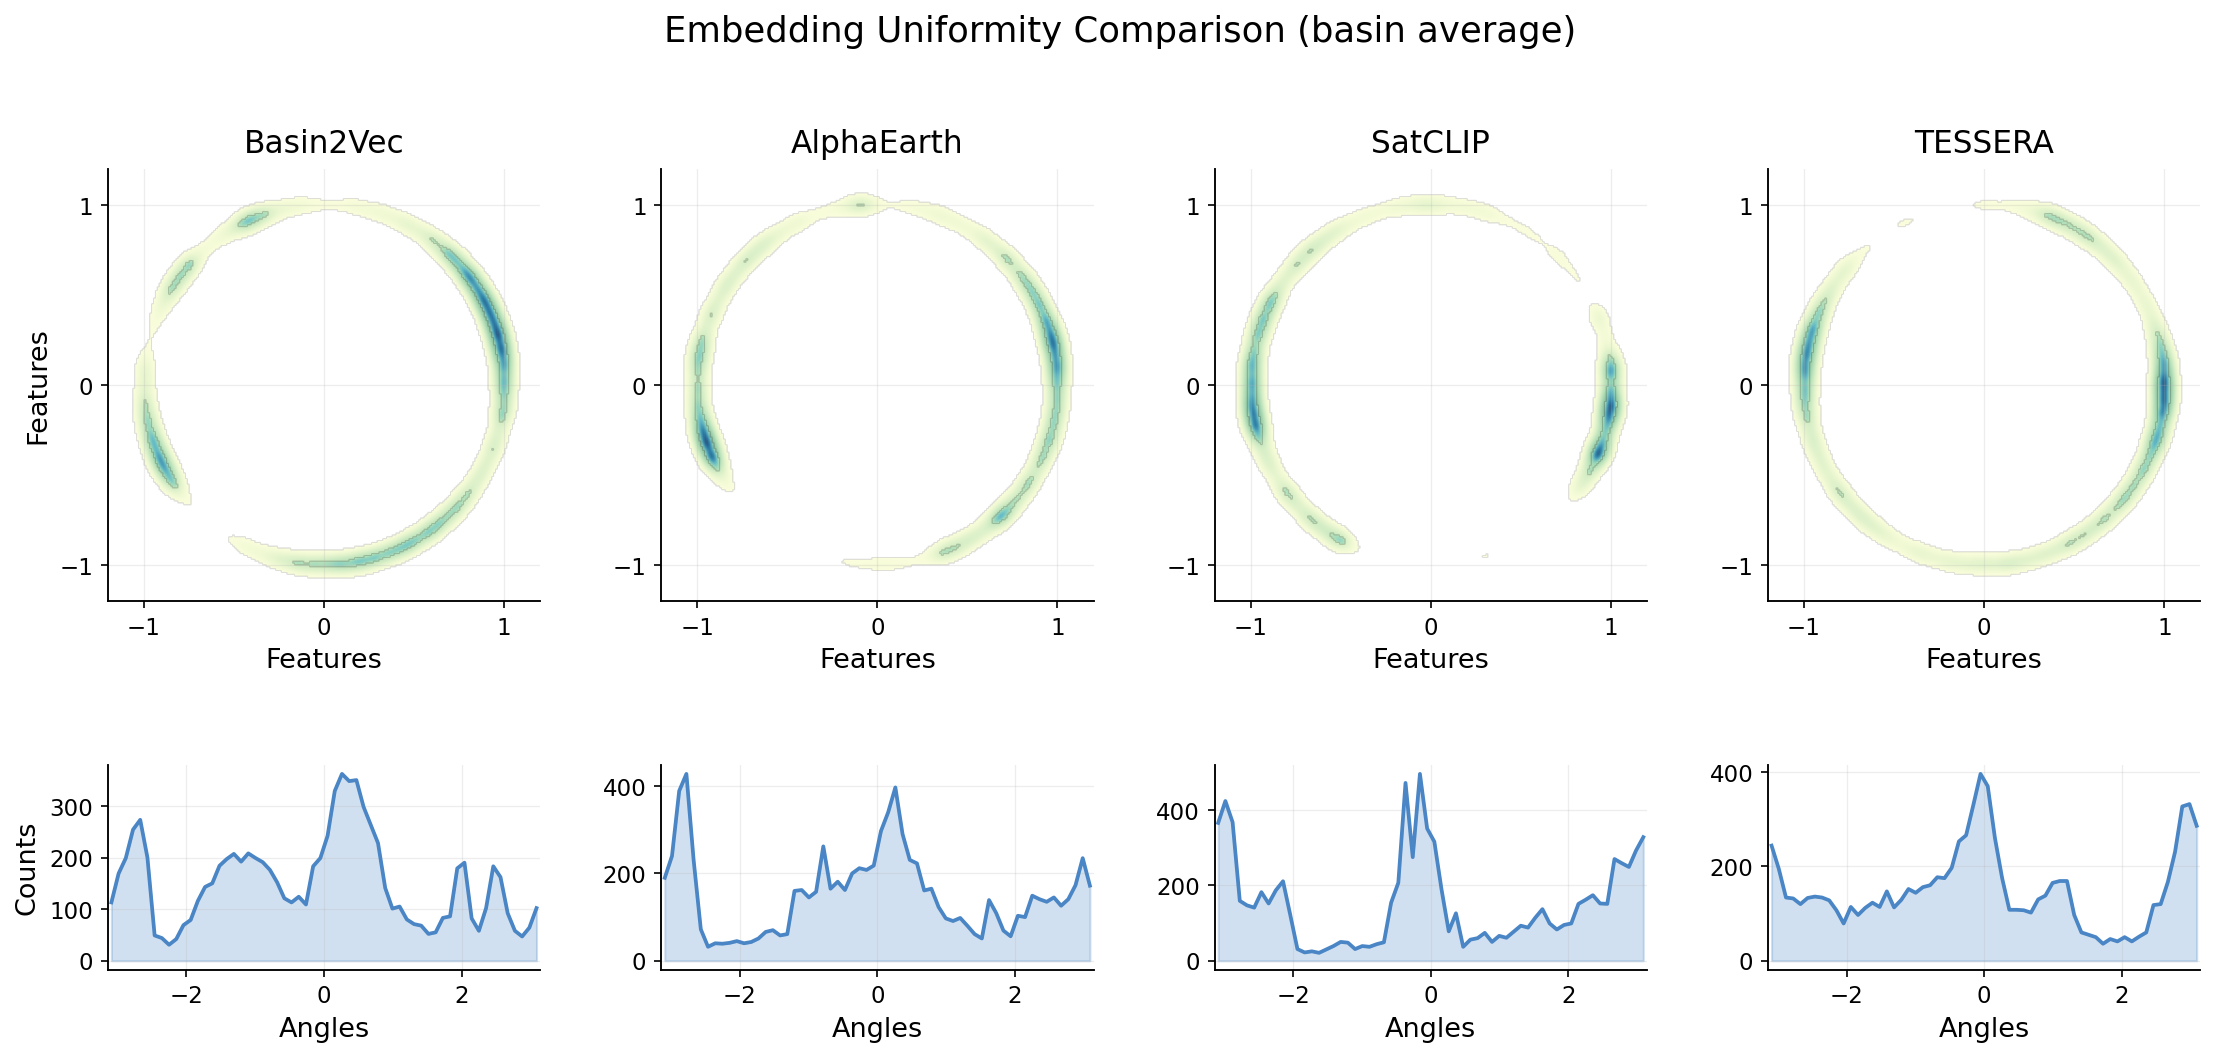

In [12]:
#!/usr/bin/env python3
# ==========================================================
# Uniformity-only plot for four embeddings:
#   Basin2Vec | AlphaEarth | SatCLIP | TESSERA
#
# Output:
#   paper_results_uniformity_4_embeddings/
#       fig_uniformity_4_embeddings.pdf
#       fig_uniformity_4_embeddings.png
#
# Notes:
#   - Basin2Vec / AlphaEarth annual embeddings are averaged per basin by default.
#   - SatCLIP / TESSERA 8-point embeddings are averaged per basin by default.
#   - This gives fair one-vector-per-basin uniformity comparison.
#
# To use all raw samples instead of basin-averaged vectors:
#   set UNIFORMITY_LEVEL = "sample"
# ==========================================================

from __future__ import annotations

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")


# ==========================================================
# CONFIG
# ==========================================================

SEED = 42
RNG = np.random.default_rng(SEED)

ALPHAEARTH_NPZ = Path(
    "alphaearth_embeddings/embeddings/alphaearth_annual_basin_embeddings_2017_2024_scale500m.npz"
)
SATCLIP_NPZ = Path("satclip_embeddings/satclip_8point_2024_embeddings.npz")
TESSERA_NPZ = Path("tessera_embeddings/tessera_8point_2024_embeddings.npz")
BASIN2VEC_NPZ = Path(
    "../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz"
)

MODEL_CONFIGS = [
    {
        "name": "Basin2Vec",
        "path": BASIN2VEC_NPZ,
        "preferred_embedding_key": "embeddings",
        "prefer_3d_points": False,
    },
    {
        "name": "AlphaEarth",
        "path": ALPHAEARTH_NPZ,
        "preferred_embedding_key": None,
        "prefer_3d_points": False,
    },
    {
        "name": "SatCLIP",
        "path": SATCLIP_NPZ,
        "preferred_embedding_key": None,
        "prefer_3d_points": True,
    },
    {
        "name": "TESSERA",
        "path": TESSERA_NPZ,
        "preferred_embedding_key": None,
        "prefer_3d_points": True,
    },
]

RESULTS_DIR = Path("paper_results_uniformity_4_embeddings")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Recommended for fair comparison:
#   "basin_average" = one vector per basin
#   "sample"        = use all annual/point samples
UNIFORMITY_LEVEL = "basin_average"

N_VIS = 60_000

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
})


# ==========================================================
# BASIC HELPERS
# ==========================================================

def normalize_site_id(x) -> str | None:
    if pd.isna(x):
        return None

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    digits = re.sub(r"\D", "", s)

    if len(digits) > 0:
        if len(digits) <= 8:
            return digits.zfill(8)
        return digits

    if len(s) == 0:
        return None

    return s


def l2_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    return x / np.clip(np.linalg.norm(x, axis=1, keepdims=True), eps, None)


def is_numeric_array(arr: np.ndarray) -> bool:
    return np.issubdtype(np.asarray(arr).dtype, np.number)


def infer_year_from_filename(npz_path: Path) -> int | None:
    matches = re.findall(r"(?<!\d)(19\d{2}|20\d{2})(?!\d)", npz_path.name)
    if len(matches) == 0:
        return None
    return int(matches[-1])


def savefig(path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, bbox_inches="tight", dpi=300)
    print(f"Saved: {path}")


# ==========================================================
# NPZ LOADING
# ==========================================================

def print_npz_keys(npz_path: Path, model_name: str):
    data = np.load(npz_path, allow_pickle=True)

    print("\n" + "=" * 80)
    print(f"{model_name} NPZ keys: {npz_path}")
    print("=" * 80)

    for k in data.files:
        arr = data[k]
        print(f"{k:35s} shape={arr.shape}, dtype={arr.dtype}")

    return data


def choose_embedding_array(
    data,
    preferred_key: str | None,
    model_name: str,
    prefer_3d_points: bool = False,
):
    if preferred_key is not None and preferred_key in data.files:
        return preferred_key, np.asarray(data[preferred_key], dtype=np.float32)

    candidates = [
        "point_embeddings",
        "pointwise_embeddings",
        "embeddings_8point",
        "embeddings_8points",
        "basin_point_embeddings",
        "satclip_point_embeddings",
        "tessera_point_embeddings",
        "embeddings",
        "embedding",
        "raw_embeddings",
        "alphaearth_embeddings",
        "satclip_embeddings",
        "tessera_embeddings",
        "basin_embeddings",
        "avg_embeddings",
        "hydrologic_repr",
        "z",
        "features",
    ]

    if prefer_3d_points:
        for key in candidates:
            if key in data.files:
                arr = np.asarray(data[key])
                if is_numeric_array(arr) and arr.ndim == 3:
                    return key, arr.astype(np.float32)

        numeric_3d = []

        for key in data.files:
            arr = np.asarray(data[key])
            if is_numeric_array(arr) and arr.ndim == 3:
                numeric_3d.append((arr.size, key, arr))

        if numeric_3d:
            _, key, arr = max(numeric_3d, key=lambda x: x[0])
            print(f"Warning: using auto-detected 3D embedding key for {model_name}: {key}")
            return key, arr.astype(np.float32)

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if is_numeric_array(arr) and arr.ndim in (2, 3):
                return key, arr.astype(np.float32)

    numeric = []

    for key in data.files:
        arr = np.asarray(data[key])
        if is_numeric_array(arr) and arr.ndim in (2, 3):
            numeric.append((arr.size, key, arr))

    if numeric:
        _, key, arr = max(numeric, key=lambda x: x[0])
        print(f"Warning: using auto-detected embedding key for {model_name}: {key}")
        return key, arr.astype(np.float32)

    raise KeyError(
        f"Could not find embedding array for {model_name}. "
        f"Available keys: {data.files}"
    )


def choose_site_ids(data, model_name: str, n_expected: int):
    candidates = [
        "labels",
        "avg_labels",
        "site_ids",
        "site_id",
        "gage_ids",
        "gauge_ids",
        "basin_ids",
        "basin_id",
        "ids",
        "id",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr

    skip_patterns = [
        "year",
        "embedding",
        "feature",
        "coord",
        "lat",
        "lon",
        "x",
        "y",
        "point",
        "dim",
    ]

    for key in data.files:
        key_lower = key.lower()

        if any(p in key_lower for p in skip_patterns):
            continue

        arr = np.asarray(data[key])

        if arr.ndim != 1 or len(arr) != n_expected:
            continue

        if arr.dtype.kind not in {"O", "U", "S", "i", "u"}:
            continue

        if np.issubdtype(arr.dtype, np.number):
            arr_min = np.nanmin(arr)
            arr_max = np.nanmax(arr)

            if 1900 <= arr_min <= 2100 and 1900 <= arr_max <= 2100:
                continue

        print(f"Warning: using auto-detected site-id key for {model_name}: {key}")
        return key, arr

    raise KeyError(
        f"Could not find site/basin ID array for {model_name} with length {n_expected}. "
        f"Available keys: {data.files}"
    )


def choose_years(data, model_name: str, n_expected: int, npz_path: Path):
    candidates = [
        "years",
        "year",
        "sample_years",
        "embedding_years",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr.astype(int)

    inferred_year = infer_year_from_filename(npz_path)

    if inferred_year is not None:
        print(
            f"{model_name}: no year array found; inferred year={inferred_year} "
            f"from filename {npz_path.name}."
        )
        return "inferred_from_filename", np.full(n_expected, inferred_year, dtype=int)

    print(f"{model_name}: no year array found; using year=0.")
    return "dummy_year", np.zeros(n_expected, dtype=int)


def flatten_embeddings_for_samples(emb_raw, df_base, model_name, emb_key):
    emb_raw = np.asarray(emb_raw, dtype=np.float32)

    if emb_raw.ndim == 2:
        df = df_base.copy()
        df["point_id"] = 0
        return df, emb_raw

    if emb_raw.ndim == 3:
        n_basins, n_points, dim = emb_raw.shape

        if len(df_base) != n_basins:
            raise ValueError(
                f"{model_name}: 3D embedding first dimension does not match metadata. "
                f"emb.shape[0]={n_basins}, len(df_base)={len(df_base)}"
            )

        print(
            f"{model_name}: embedding key '{emb_key}' is 3D {emb_raw.shape}; "
            "flattening sampled points."
        )

        emb = emb_raw.reshape(n_basins * n_points, dim).astype(np.float32)

        df = df_base.loc[df_base.index.repeat(n_points)].copy().reset_index(drop=True)
        df["point_id"] = np.tile(np.arange(n_points), n_basins)

        return df, emb

    raise ValueError(
        f"{model_name}: embedding array must be 2D or 3D. "
        f"Got shape={emb_raw.shape}."
    )


def compute_basin_average_embeddings(df, emb):
    df = df.copy()
    df["row"] = np.arange(len(df))

    rows = []
    avg_embs = []

    for site_id, sub in df.groupby("site_id", sort=True):
        idx = sub["row"].to_numpy(dtype=int)

        z = emb[idx].mean(axis=0, keepdims=True)
        z = l2_normalize(z)[0]

        rows.append({
            "site_id": site_id,
            "n_samples": int(len(idx)),
            "n_years": int(sub["year"].nunique()),
        })

        avg_embs.append(z)

    out_df = pd.DataFrame(rows)
    out_emb = np.stack(avg_embs, axis=0).astype(np.float32)

    return out_df, out_emb


def load_embedding_for_uniformity(
    npz_path: Path,
    model_name: str,
    preferred_embedding_key: str | None = None,
    prefer_3d_points: bool = False,
):
    npz_path = Path(npz_path)

    if not npz_path.exists():
        raise FileNotFoundError(f"{model_name} NPZ not found: {npz_path}")

    data = print_npz_keys(npz_path, model_name)

    emb_key, emb_raw = choose_embedding_array(
        data=data,
        preferred_key=preferred_embedding_key,
        model_name=model_name,
        prefer_3d_points=prefer_3d_points,
    )

    n_base = emb_raw.shape[0]

    site_key, site_ids_raw = choose_site_ids(
        data=data,
        model_name=model_name,
        n_expected=n_base,
    )

    year_key, years = choose_years(
        data=data,
        model_name=model_name,
        n_expected=n_base,
        npz_path=npz_path,
    )

    site_ids = np.array([normalize_site_id(x) for x in site_ids_raw], dtype=object)

    df_base = pd.DataFrame({
        "site_id": site_ids,
        "year": years.astype(int),
    })

    valid = df_base["site_id"].notna().to_numpy()
    df_base = df_base.loc[valid].reset_index(drop=True)
    emb_raw = emb_raw[valid]

    df_sample, emb_sample = flatten_embeddings_for_samples(
        emb_raw=emb_raw,
        df_base=df_base,
        model_name=model_name,
        emb_key=emb_key,
    )

    emb_sample = l2_normalize(emb_sample)

    if UNIFORMITY_LEVEL == "basin_average":
        df_final, emb_final = compute_basin_average_embeddings(
            df_sample,
            emb_sample,
        )
        level_used = "basin_average"
    elif UNIFORMITY_LEVEL == "sample":
        df_final, emb_final = df_sample, emb_sample
        level_used = "sample"
    else:
        raise ValueError("UNIFORMITY_LEVEL must be either 'basin_average' or 'sample'.")

    emb_final = l2_normalize(emb_final)

    print("\nLoaded for uniformity:", model_name)
    print("  embedding key:", emb_key)
    print("  site key:", site_key)
    print("  year key:", year_key)
    print("  raw shape:", emb_raw.shape)
    print("  uniformity level:", level_used)
    print("  final embedding shape:", emb_final.shape)
    print("  unique basins:", df_final["site_id"].nunique())

    return df_final, emb_final


# ==========================================================
# UNIFORMITY HELPERS
# ==========================================================

def project_to_unit_circle(x):
    x = np.asarray(x, dtype=np.float32)

    if len(x) > N_VIS:
        idx = RNG.choice(len(x), size=N_VIS, replace=False)
        x = x[idx]

    pca = PCA(n_components=2, random_state=SEED)
    xy = pca.fit_transform(x)

    xy_unit = xy / np.clip(
        np.linalg.norm(xy, axis=1, keepdims=True),
        1e-12,
        None,
    )

    return xy_unit.astype(np.float32)


def angles_from_xy(xy_unit):
    return np.arctan2(xy_unit[:, 1], xy_unit[:, 0])


def plot_ring_density_soft(
    ax,
    xy_unit,
    title="",
    bins=240,
    sigma_mid=4.5,
    sigma_inner=2.2,
    alpha_mid=0.50,
    alpha_inner=0.70,
):
    x = xy_unit[:, 0]
    y = xy_unit[:, 1]

    H, _, _ = np.histogram2d(
        x,
        y,
        bins=bins,
        range=[[-1.25, 1.25], [-1.25, 1.25]],
    )

    extent = [-1.25, 1.25, -1.25, 1.25]

    H_mid = gaussian_filter(H, sigma=sigma_mid)
    H_inner = gaussian_filter(H, sigma=sigma_inner)

    def normalize(A):
        A = A.astype(float)
        if A.max() > 0:
            A = A / A.max()
        return A

    H_mid = normalize(H_mid)
    H_inner = normalize(H_inner)

    mid = np.ma.masked_where(H_mid < 0.12, H_mid)
    inner = np.ma.masked_where(H_inner < 0.35, H_inner)

    ax.imshow(
        mid.T,
        origin="lower",
        extent=extent,
        cmap="YlGn",
        alpha=alpha_mid,
        interpolation="bilinear",
        aspect="equal",
        vmin=0,
        vmax=1,
    )

    ax.imshow(
        inner.T,
        origin="lower",
        extent=extent,
        cmap="GnBu",
        alpha=alpha_inner,
        interpolation="bilinear",
        aspect="equal",
        vmin=0,
        vmax=1,
    )

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect("equal")

    ax.set_title(title, fontsize=15, pad=8)
    ax.set_xlabel("Features", fontsize=13)
    ax.set_ylabel("Features", fontsize=13)

    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])

    ax.grid(True, alpha=0.22, linewidth=0.6)

    for spine in ax.spines.values():
        spine.set_linewidth(0.9)


def plot_angle_hist(ax, angles, color="#4a86c5", bins=60):
    hist, edges = np.histogram(
        angles,
        bins=bins,
        range=(-np.pi, np.pi),
        density=False,
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    ax.fill_between(
        centers,
        hist,
        alpha=0.25,
        color=color,
    )

    ax.plot(
        centers,
        hist,
        linewidth=1.8,
        color=color,
    )

    ax.set_xlim(-np.pi, np.pi)
    ax.set_xlabel("Angles", fontsize=13)
    ax.set_ylabel("Counts", fontsize=13)

    ax.grid(True, alpha=0.22, linewidth=0.6)

    for spine in ax.spines.values():
        spine.set_linewidth(0.9)


# ==========================================================
# MAIN PLOT
# ==========================================================

def main():
    loaded = {}

    for cfg in MODEL_CONFIGS:
        model_name = cfg["name"]

        print("\n" + "#" * 90)
        print(f"Loading model: {model_name}")
        print("#" * 90)

        df, emb = load_embedding_for_uniformity(
            npz_path=cfg["path"],
            model_name=model_name,
            preferred_embedding_key=cfg.get("preferred_embedding_key"),
            prefer_3d_points=cfg.get("prefer_3d_points", False),
        )

        xy = project_to_unit_circle(emb)
        angles = angles_from_xy(xy)

        loaded[model_name] = {
            "df": df,
            "emb": emb,
            "xy": xy,
            "angles": angles,
        }

    # ------------------------------------------------------
    # 4-column figure:
    #   top row    = feature distribution
    #   bottom row = angle distribution
    # ------------------------------------------------------
    model_order = ["Basin2Vec", "AlphaEarth", "SatCLIP", "TESSERA"]

    fig, axes = plt.subplots(
        2,
        4,
        figsize=(18, 7.2),
        gridspec_kw={
            "height_ratios": [3.0, 1.25],
            "wspace": 0.28,
            "hspace": 0.38,
        },
    )

    for col, model_name in enumerate(model_order):
        xy = loaded[model_name]["xy"]
        angles = loaded[model_name]["angles"]

        ax_top = axes[0, col]
        ax_bottom = axes[1, col]

        plot_ring_density_soft(
            ax_top,
            xy,
            title=model_name,
            bins=240,
            sigma_mid=4.5,
            sigma_inner=2.2,
            alpha_mid=0.50,
            alpha_inner=0.70,
        )

        plot_angle_hist(
            ax_bottom,
            angles,
            color="#4a86c5",
            bins=60,
        )

        if col != 0:
            ax_top.set_ylabel("")
            ax_bottom.set_ylabel("")

    fig.suptitle(
        f"Embedding Uniformity Comparison ({UNIFORMITY_LEVEL.replace('_', ' ')})",
        fontsize=17,
        y=0.995,
    )

    out_pdf = RESULTS_DIR / "fig_uniformity_4_embeddings.pdf"
    out_png = RESULTS_DIR / "fig_uniformity_4_embeddings.png"

    savefig(out_pdf)
    savefig(out_png)

    plt.show()


if __name__ == "__main__":
    main()

Loaded metadata from: /data/basin2vec/cache/metadata/basin_metadata.parquet
Number of basins in metadata: 9067
Filtered overlap pairs: 34291

[Basin2Vec] Loading NPZ: /home/talhamuh/basin2vec/emb/src/evaluation_outputs/HCLV4_meta_scale_overlap_areaaux_64d/basin_embeddings_full.npz
[Basin2Vec] Available keys: ['embeddings', 'hydrologic_repr', 'labels', 'label_ints', 'years', 'basin_meta', 'area_target', 'area_pred', 'overlap_degree', 'avg_embeddings', 'avg_labels', 'year_counts']
[Basin2Vec] after year restriction: 362680 samples, 9067 basins, years=1985--2024
Auto-selected NPZ: /home/talhamuh/basin2vec/emb/evaluation/alphaearth_embeddings/embeddings/alphaearth_annual_basin_embeddings_2017_2024_scale500m.npz

[AlphaEarth] Loading NPZ: /home/talhamuh/basin2vec/emb/evaluation/alphaearth_embeddings/embeddings/alphaearth_annual_basin_embeddings_2017_2024_scale500m.npz
[AlphaEarth] Available keys: ['embeddings', 'raw_embeddings', 'site_ids', 'labels', 'years', 'bands', 'scale_m']
[AlphaEarth

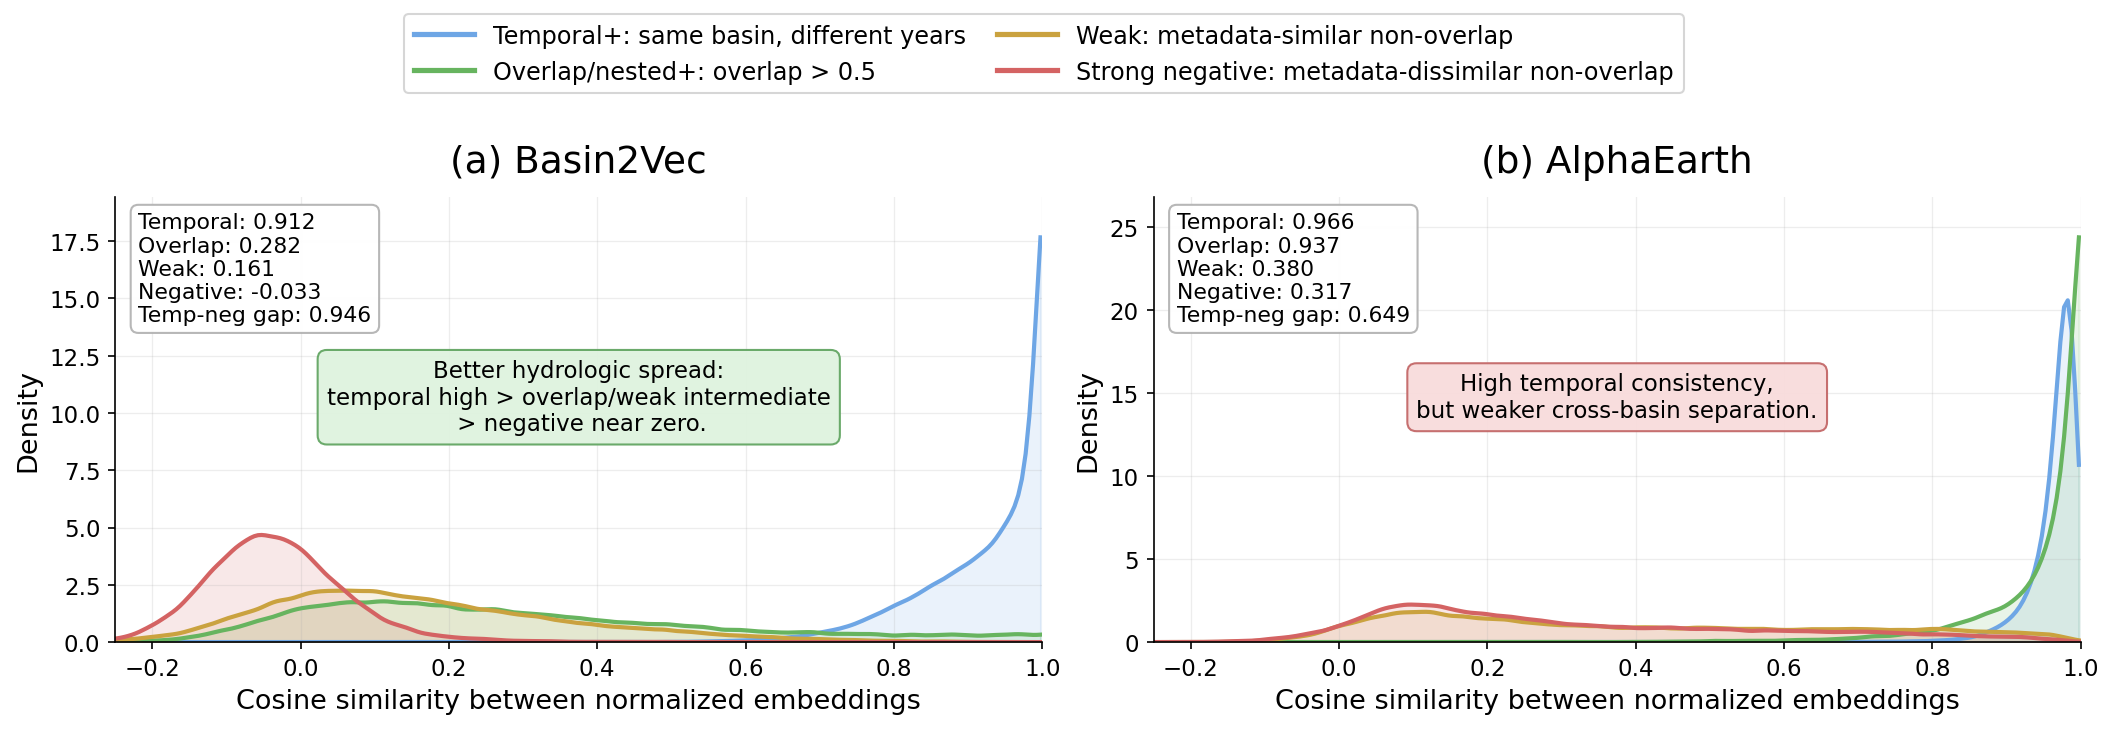

In [2]:
#!/usr/bin/env python3
# ==========================================================
# Hydrologic relation structure figure:
# Basin2Vec vs AlphaEarth
#
# - Uses metadata-aware relation definitions consistently
# - Temporal relation: same basin, different years
# - Overlap/nested relation: basin overlap > threshold
# - Weak relation: metadata-similar non-overlap basins
# - Strong negative: metadata-dissimilar non-overlap basins
#
# Figure changes:
# - separate numeric box and interpretation box
# - interpretation box centered inside each panel
# - green interpretation box for better hydrologic spread
# - red interpretation box for weaker hydrologic separation
# - no expected-order strip on top
# - no mean dotted lines
# - boundary-line density plots instead of bars
# ==========================================================

from __future__ import annotations

from pathlib import Path
from collections import defaultdict
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter1d

warnings.filterwarnings("ignore")

# ==========================================================
# CONFIG
# ==========================================================
SEED = 42
RNG = np.random.default_rng(SEED)

# -------- Input files --------
BASIN2VEC_NPZ = Path(
    "/home/talhamuh/basin2vec/emb/src/evaluation_outputs/"
    "HCLV4_meta_scale_overlap_areaaux_64d/basin_embeddings_full.npz"
)

# Use folder; script auto-picks an AlphaEarth npz
ALPHAEARTH_DIR = Path(
    "/home/talhamuh/basin2vec/emb/evaluation/alphaearth_embeddings/embeddings"
)

BASIN_METADATA_PATH = Path("/data/basin2vec/cache/metadata/basin_metadata.parquet")
OVERLAP_PAIRS_PARQUET = Path("/data/basin2vec/cache/basin_overlap_pairs.parquet")

# -------- Output --------
OUT_DIR = Path("paper_results")
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# -------- Embedding settings --------
BASIN2VEC_EMBED_KEY = "embeddings"   # or "hydrologic_repr" if you want to compare that
BASIN2VEC_YEAR_MIN = 1985
BASIN2VEC_YEAR_MAX = 2024

ALPHAEARTH_YEAR_MIN = 2017
ALPHAEARTH_YEAR_MAX = 2025

# -------- Relation settings --------
OVERLAP_THRESHOLD = 0.5

META_TAU = 1.5
META_SIMILAR_Q = 0.90
META_DISSIMILAR_Q = 0.10

MAX_TEMPORAL_PAIRS = 50000
MAX_OVERLAP_PAIRS = 50000
MAX_META_SIM_PAIRS = 50000
MAX_META_DISSIMILAR_PAIRS = 50000
MAX_CANDIDATE_NONOVERLAP_PAIRS = 300000

# -------- Plot settings --------
plt.rcParams.update({
    "figure.figsize": (14, 5.4),
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RELATION_COLORS = {
    "temporal": "#6ea6e5",  # blue
    "overlap":  "#67b45f",  # green
    "weak":     "#caa23f",  # gold
    "negative": "#d46363",  # red
}

RELATION_LABELS = {
    "temporal": "Temporal+: same basin, different years",
    "overlap":  "Overlap/nested+: overlap > 0.5",
    "weak":     "Weak: metadata-similar non-overlap",
    "negative": "Strong negative: metadata-dissimilar non-overlap",
}

# ==========================================================
# HELPERS
# ==========================================================
def normalize_site_id(x) -> str | None:
    if pd.isna(x):
        return None
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    s = re.sub(r"\D", "", s)
    if len(s) == 0:
        return None
    if len(s) <= 8:
        s = s.zfill(8)
    return s


def l2_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    return x / np.clip(np.linalg.norm(x, axis=1, keepdims=True), eps, None)


def savefig(path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, bbox_inches="tight", dpi=300)
    print(f"Saved: {path}")


def safe_mean(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.nanmean(x)) if len(x) else np.nan


def safe_std(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.nanstd(x)) if len(x) else np.nan


def safe_median(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.nanmedian(x)) if len(x) else np.nan


def auto_find_alphaearth_npz(alphaearth_dir: Path) -> Path:
    candidates = sorted(alphaearth_dir.glob("*.npz"))
    if len(candidates) == 0:
        raise FileNotFoundError(f"No AlphaEarth npz found in {alphaearth_dir}")

    preferred = [p for p in candidates if "2017_2025" in p.name or "2017-2025" in p.name]
    if preferred:
        chosen = preferred[-1]
    else:
        chosen = candidates[-1]

    print(f"Auto-selected NPZ: {chosen}")
    return chosen


# ==========================================================
# LOAD EMBEDDINGS
# ==========================================================
def load_basin2vec_embeddings(npz_path: Path, embed_key="embeddings",
                              year_min=1985, year_max=2024):
    npz_path = Path(npz_path)
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing Basin2Vec npz: {npz_path}")

    data = np.load(npz_path, allow_pickle=True)

    print(f"\n[Basin2Vec] Loading NPZ: {npz_path}")
    print("[Basin2Vec] Available keys:", list(data.files))

    if embed_key not in data.files:
        raise KeyError(f"Basin2Vec npz missing key '{embed_key}'")

    emb = np.asarray(data[embed_key], dtype=np.float32)
    emb = l2_normalize(emb)

    if "labels" in data.files:
        labels = np.asarray([normalize_site_id(x) for x in data["labels"]]).astype(str)
    elif "label_ints" in data.files:
        labels = np.asarray([str(int(x)).zfill(8) for x in data["label_ints"]]).astype(str)
    else:
        raise KeyError("Basin2Vec npz must contain 'labels' or 'label_ints'.")

    if "years" not in data.files:
        raise KeyError("Basin2Vec npz must contain 'years'.")

    years = np.asarray(data["years"]).astype(int)

    keep = (years >= year_min) & (years <= year_max)
    emb = emb[keep]
    labels = labels[keep]
    years = years[keep]

    print(
        f"[Basin2Vec] after year restriction: "
        f"{len(emb)} samples, {len(np.unique(labels))} basins, "
        f"years={sorted(np.unique(years)).__getitem__(0)}--{sorted(np.unique(years)).__getitem__(-1)}"
    )

    return emb, labels, years


def load_alphaearth_embeddings(npz_path: Path, year_min=2017, year_max=2025):
    npz_path = Path(npz_path)
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing AlphaEarth npz: {npz_path}")

    data = np.load(npz_path, allow_pickle=True)

    print(f"\n[AlphaEarth] Loading NPZ: {npz_path}")
    print("[AlphaEarth] Available keys:", list(data.files))

    if "embeddings" in data.files:
        emb = np.asarray(data["embeddings"], dtype=np.float32)
    elif "raw_embeddings" in data.files:
        emb = np.asarray(data["raw_embeddings"], dtype=np.float32)
    else:
        raise KeyError("AlphaEarth npz must contain 'embeddings' or 'raw_embeddings'.")

    emb = l2_normalize(emb)

    if "site_ids" in data.files:
        labels = np.asarray([normalize_site_id(x) for x in data["site_ids"]]).astype(str)
    elif "labels" in data.files:
        labels = np.asarray([normalize_site_id(x) for x in data["labels"]]).astype(str)
    else:
        raise KeyError("AlphaEarth npz must contain 'site_ids' or 'labels'.")

    if "years" not in data.files:
        raise KeyError("AlphaEarth npz must contain 'years'.")

    years = np.asarray(data["years"]).astype(int)

    keep = (years >= year_min) & (years <= year_max)
    emb = emb[keep]
    labels = labels[keep]
    years = years[keep]

    print(
        f"[AlphaEarth] after year restriction: "
        f"{len(emb)} samples, {len(np.unique(labels))} basins, "
        f"years={sorted(np.unique(years)).__getitem__(0)}--{sorted(np.unique(years)).__getitem__(-1)}"
    )

    return emb, labels, years


def average_embeddings_by_basin(emb, labels):
    basin_to_vecs = defaultdict(list)
    for lab, vec in zip(labels, emb):
        basin_to_vecs[str(lab)].append(vec)

    avg_labels = []
    avg_emb = []

    for lab in sorted(basin_to_vecs.keys()):
        z = np.stack(basin_to_vecs[lab], axis=0)
        z_mean = z.mean(axis=0)
        z_mean = l2_normalize(z_mean[None, :])[0]
        avg_labels.append(lab)
        avg_emb.append(z_mean)

    return np.asarray(avg_labels).astype(str), np.stack(avg_emb, axis=0).astype(np.float32)


# ==========================================================
# LOAD METADATA
# ==========================================================
def load_basin_metadata(meta_path: Path, basin_ids=None):
    meta_path = Path(meta_path)
    if not meta_path.exists():
        raise FileNotFoundError(f"Metadata file not found: {meta_path}")

    if meta_path.suffix.lower() == ".parquet":
        df = pd.read_parquet(meta_path)
    else:
        df = pd.read_csv(meta_path, dtype={"site_id": str})

    df = df.copy()
    df["site_id"] = df["site_id"].apply(normalize_site_id)

    if basin_ids is not None:
        basin_ids = set(map(str, basin_ids))
        df = df[df["site_id"].isin(basin_ids)].copy()

    meta_cols = [
        "log_area_km2_z",
        "log_bbox_width_km_z",
        "log_bbox_height_km_z",
        "log_patch_pixel_width_km_z",
        "log_patch_pixel_height_km_z",
        "log_patch_pixel_area_km2_z",
        "bbox_fill_fraction_z",
        "compactness_z",
        "solidity_z",
        "log_shape_index_z",
        "log_overlap_degree_z",
    ]

    missing = [c for c in meta_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Metadata file missing required columns: {missing}")

    if "site_id_int" not in df.columns:
        raise KeyError("Metadata file must contain 'site_id_int'.")

    keep_cols = ["site_id", "site_id_int"] + meta_cols
    out = df[keep_cols].drop_duplicates(subset=["site_id"]).reset_index(drop=True)
    print(f"Loaded metadata from: {meta_path}")
    print(f"Number of basins in metadata: {len(out)}")
    return out, meta_cols


def load_overlap_strengths(overlap_path: Path, meta_df: pd.DataFrame):
    overlap_path = Path(overlap_path)
    if not overlap_path.exists():
        raise FileNotFoundError(f"Overlap pair file not found: {overlap_path}")

    odf = pd.read_parquet(overlap_path).copy()

    if "site_id_int_a" not in odf.columns or "site_id_int_b" not in odf.columns:
        raise KeyError("Overlap parquet must contain site_id_int_a and site_id_int_b.")

    if "overlap_score" in odf.columns:
        score_col = "overlap_score"
    elif "overlap_strength" in odf.columns:
        score_col = "overlap_strength"
    else:
        score_col = None

    int_to_site = dict(zip(meta_df["site_id_int"].astype(int), meta_df["site_id"].astype(str)))

    overlap_strength = {}
    overlap_neighbors = defaultdict(set)

    for _, row in odf.iterrows():
        sid_a = int_to_site.get(int(row["site_id_int_a"]))
        sid_b = int_to_site.get(int(row["site_id_int_b"]))

        if sid_a is None or sid_b is None or sid_a == sid_b:
            continue

        score = float(row[score_col]) if score_col is not None else 1.0
        key = tuple(sorted((sid_a, sid_b)))
        overlap_strength[key] = max(score, overlap_strength.get(key, 0.0))
        overlap_neighbors[sid_a].add(sid_b)
        overlap_neighbors[sid_b].add(sid_a)

    print(f"Filtered overlap pairs: {len(overlap_strength)}")
    return overlap_strength, overlap_neighbors


# ==========================================================
# RELATION BUILDERS
# ==========================================================
def build_temporal_pairs(labels, years, max_pairs=50000):
    basin_to_idx = defaultdict(list)
    for i, (lab, yr) in enumerate(zip(labels, years)):
        basin_to_idx[str(lab)].append((i, int(yr)))

    pairs = []

    for _, items in basin_to_idx.items():
        items = sorted(items, key=lambda x: x[1])
        if len(items) < 2:
            continue
        for a in range(len(items)):
            for b in range(a + 1, len(items)):
                i, ya = items[a]
                j, yb = items[b]
                if ya != yb:
                    pairs.append((i, j))

    if len(pairs) > max_pairs:
        idx = RNG.choice(len(pairs), size=max_pairs, replace=False)
        pairs = [pairs[k] for k in idx]

    return pairs


def build_overlap_pairs(basin_ids, overlap_strength_map, threshold=0.5, max_pairs=50000):
    basin_ids = np.asarray(basin_ids).astype(str)
    id_to_idx = {sid: i for i, sid in enumerate(basin_ids)}

    pairs = []
    strengths = []

    for (a, b), s in overlap_strength_map.items():
        if a in id_to_idx and b in id_to_idx and s >= threshold:
            pairs.append((id_to_idx[a], id_to_idx[b]))
            strengths.append(float(s))

    if len(pairs) > max_pairs:
        idx = RNG.choice(len(pairs), size=max_pairs, replace=False)
        pairs = [pairs[k] for k in idx]
        strengths = np.asarray(strengths, dtype=np.float32)[idx]
    else:
        strengths = np.asarray(strengths, dtype=np.float32)

    return pairs, strengths


def sample_nonoverlap_candidate_pairs(basin_ids, overlap_neighbors, n_pairs=300000):
    basin_ids = np.asarray(basin_ids).astype(str)
    n = len(basin_ids)
    if n < 2:
        return []

    seen = set()
    pairs = []
    attempts = 0
    max_attempts = max(10 * n_pairs, 100000)

    while len(pairs) < n_pairs and attempts < max_attempts:
        i = int(RNG.integers(0, n))
        j = int(RNG.integers(0, n - 1))
        if j >= i:
            j += 1

        a = basin_ids[i]
        b = basin_ids[j]

        if i == j or a == b:
            attempts += 1
            continue
        if b in overlap_neighbors.get(a, set()):
            attempts += 1
            continue

        key = (i, j) if i < j else (j, i)
        if key in seen:
            attempts += 1
            continue

        seen.add(key)
        pairs.append(key)
        attempts += 1

    return pairs


def metadata_similarity_for_pairs(meta_matrix, pairs, tau=1.5):
    if len(pairs) == 0:
        return np.array([], dtype=np.float32)
    pairs = np.asarray(pairs, dtype=np.int64)
    diff = meta_matrix[pairs[:, 0]] - meta_matrix[pairs[:, 1]]
    d2 = np.sum(diff * diff, axis=1)
    sims = np.exp(-d2 / (2.0 * tau * tau))
    return sims.astype(np.float32)


def build_nonoverlap_relation_sets(basin_ids, meta_matrix, overlap_neighbors):
    candidate_pairs = sample_nonoverlap_candidate_pairs(
        basin_ids=basin_ids,
        overlap_neighbors=overlap_neighbors,
        n_pairs=MAX_CANDIDATE_NONOVERLAP_PAIRS,
    )

    if len(candidate_pairs) == 0:
        raise RuntimeError("No non-overlap candidate pairs could be sampled.")

    sims = metadata_similarity_for_pairs(meta_matrix, candidate_pairs, tau=META_TAU)
    candidate_pairs = np.asarray(candidate_pairs, dtype=np.int64)

    q_hi = float(np.quantile(sims, META_SIMILAR_Q))
    q_lo = float(np.quantile(sims, META_DISSIMILAR_Q))

    idx_hi = np.where(sims >= q_hi)[0]
    idx_lo = np.where(sims <= q_lo)[0]

    if len(idx_hi) == 0 or len(idx_lo) == 0:
        raise RuntimeError("Could not form metadata-similar/dissimilar relation sets.")

    def choose(idxs, n_keep):
        if len(idxs) <= n_keep:
            return idxs
        return RNG.choice(idxs, size=n_keep, replace=False)

    idx_meta_sim = choose(idx_hi, MAX_META_SIM_PAIRS)
    idx_meta_dis = choose(idx_lo, MAX_META_DISSIMILAR_PAIRS)

    out = {
        "meta_sim_pairs": [tuple(x) for x in candidate_pairs[idx_meta_sim]],
        "meta_dis_pairs": [tuple(x) for x in candidate_pairs[idx_meta_dis]],
        "similar_q": q_hi,
        "dissimilar_q": q_lo,
    }
    return out


def cosine_for_pairs(emb, pairs):
    if len(pairs) == 0:
        return np.array([], dtype=np.float32)
    pairs = np.asarray(pairs, dtype=np.int64)
    return np.sum(emb[pairs[:, 0]] * emb[pairs[:, 1]], axis=1).astype(np.float32)


# ==========================================================
# BUILD RELATION DISTRIBUTIONS
# ==========================================================
def build_relation_distributions(model_name, emb, labels, years,
                                 meta_df, meta_cols,
                                 overlap_strength_map, overlap_neighbors):
    print("\n" + "=" * 80)
    print(f"Building relation distributions for: {model_name}")
    print("=" * 80)

    # Basin-level average embeddings for cross-basin relations
    avg_labels, avg_emb = average_embeddings_by_basin(emb, labels)

    # Metadata aligned to avg_labels
    meta_map = meta_df.drop_duplicates(subset=["site_id"]).set_index("site_id")
    common_avg_labels = [sid for sid in avg_labels if sid in meta_map.index]

    if len(common_avg_labels) == 0:
        raise RuntimeError(f"No avg_labels found in metadata for {model_name}")

    keep_idx = [i for i, sid in enumerate(avg_labels) if sid in meta_map.index]
    avg_labels = avg_labels[keep_idx]
    avg_emb = avg_emb[keep_idx]
    meta_sub = meta_map.loc[avg_labels]
    meta_matrix = meta_sub[meta_cols].to_numpy(dtype=np.float32)

    temporal_pairs = build_temporal_pairs(labels, years, max_pairs=MAX_TEMPORAL_PAIRS)
    overlap_pairs, overlap_strengths = build_overlap_pairs(
        basin_ids=avg_labels,
        overlap_strength_map=overlap_strength_map,
        threshold=OVERLAP_THRESHOLD,
        max_pairs=MAX_OVERLAP_PAIRS,
    )
    nonoverlap_sets = build_nonoverlap_relation_sets(
        basin_ids=avg_labels,
        meta_matrix=meta_matrix,
        overlap_neighbors=overlap_neighbors,
    )

    weak_pairs = nonoverlap_sets["meta_sim_pairs"]
    negative_pairs = nonoverlap_sets["meta_dis_pairs"]

    print(f"Temporal pairs: {len(temporal_pairs)}")
    print(f"Overlap pairs: {len(overlap_pairs)}")
    print(f"Weak pairs: {len(weak_pairs)}")
    print(f"Negative pairs: {len(negative_pairs)}")

    distributions = {
        "temporal": cosine_for_pairs(emb, temporal_pairs),
        "overlap": cosine_for_pairs(avg_emb, overlap_pairs),
        "weak": cosine_for_pairs(avg_emb, weak_pairs),
        "negative": cosine_for_pairs(avg_emb, negative_pairs),
    }

    summary_rows = []
    for rel_name, values in distributions.items():
        summary_rows.append({
            "model": model_name,
            "relation": rel_name,
            "n_pairs": int(len(values)),
            "mean": safe_mean(values),
            "median": safe_median(values),
            "std": safe_std(values),
            "q25": float(np.quantile(values, 0.25)) if len(values) else np.nan,
            "q75": float(np.quantile(values, 0.75)) if len(values) else np.nan,
        })

    summary_df = pd.DataFrame(summary_rows)
    return distributions, summary_df


# ==========================================================
# PLOTTING HELPERS
# ==========================================================
def smooth_density_line(values, bins=250, x_range=(-0.3, 1.0), sigma=2.0):
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        xs = np.linspace(x_range[0], x_range[1], bins)
        ys = np.zeros_like(xs)
        return xs, ys

    hist, edges = np.histogram(values, bins=bins, range=x_range, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    smooth = gaussian_filter1d(hist.astype(np.float64), sigma=sigma, mode="nearest")
    return centers, smooth


def get_relation_mean(summary_df, model_name, relation_name):
    row = summary_df[
        (summary_df["model"] == model_name) &
        (summary_df["relation"] == relation_name)
    ]
    if len(row) == 0:
        return np.nan
    return float(row["mean"].iloc[0])


def build_numeric_text(summary_df, model_name):
    temporal = get_relation_mean(summary_df, model_name, "temporal")
    overlap = get_relation_mean(summary_df, model_name, "overlap")
    weak = get_relation_mean(summary_df, model_name, "weak")
    negative = get_relation_mean(summary_df, model_name, "negative")

    text = (
        f"Temporal: {temporal:.3f}\n"
        f"Overlap: {overlap:.3f}\n"
        f"Weak: {weak:.3f}\n"
        f"Negative: {negative:.3f}\n"
        f"Temp-neg gap: {temporal - negative:.3f}"
    )
    return text


def build_interpretation_text(model_name):
    if model_name == "Basin2Vec":
        return (
            "Better hydrologic spread:\n"
            "temporal high > overlap/weak intermediate\n"
            " > negative near zero."
        )
    else:
        return (
            "High temporal consistency,\n"
            "but weaker cross-basin separation."
        )


def interpretation_box_style(model_name):
    if model_name == "Basin2Vec":
        return dict(
            boxstyle="round,pad=0.40",
            facecolor="#dff3df",   # green-ish
            edgecolor="#65a765",
            alpha=0.96,
        )
    else:
        return dict(
            boxstyle="round,pad=0.40",
            facecolor="#f8dcdc",   # red-ish
            edgecolor="#c46a6a",
            alpha=0.96,
        )


def plot_model_panel(ax, model_name, distributions, summary_df,
                     x_range=(-0.25, 1.0), bins=260, sigma=2.0):
    order = ["temporal", "overlap", "weak", "negative"]

    ymax = 0.0
    lines = {}

    for rel in order:
        xs, ys = smooth_density_line(
            distributions[rel],
            bins=bins,
            x_range=x_range,
            sigma=sigma,
        )
        ymax = max(ymax, float(np.max(ys)))
        lines[rel] = (xs, ys)

    for rel in order:
        xs, ys = lines[rel]
        ax.plot(
            xs, ys,
            color=RELATION_COLORS[rel],
            linewidth=2.0,
            label=RELATION_LABELS[rel],
        )
        ax.fill_between(xs, ys, 0, color=RELATION_COLORS[rel], alpha=0.14)

    ax.set_xlim(*x_range)
    ax.set_ylim(0, ymax * 1.10)
    ax.set_xlabel("Cosine similarity between normalized embeddings", fontsize=13)
    ax.set_ylabel("Density", fontsize=13)
    ax.set_title(f"(a) {model_name}" if model_name == "Basin2Vec" else f"(b) {model_name}", fontsize=18, pad=12)
    ax.tick_params(axis="both", labelsize=11)
    ax.grid(True, alpha=0.22, linewidth=0.6)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    # -------- Separate numeric box (upper-left) --------
    ax.text(
        0.025, 0.965,
        build_numeric_text(summary_df, model_name),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10.5,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="0.70",
            alpha=0.95,
        ),
    )

    # -------- Separate interpretation box (slightly lower center) --------
    ax.text(
        0.50, 0.55,   # x, y in axis coordinates; lower y moves box down
        build_interpretation_text(model_name),
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=11,
        bbox=interpretation_box_style(model_name),
    )


# ==========================================================
# MAIN
# ==========================================================
def main():
    # ------------------------------------------------------
    # Load shared metadata
    # ------------------------------------------------------
    meta_df, meta_cols = load_basin_metadata(BASIN_METADATA_PATH)
    overlap_strength_map, overlap_neighbors = load_overlap_strengths(
        OVERLAP_PAIRS_PARQUET,
        meta_df,
    )

    # ------------------------------------------------------
    # Load Basin2Vec
    # ------------------------------------------------------
    b2v_emb, b2v_labels, b2v_years = load_basin2vec_embeddings(
        BASIN2VEC_NPZ,
        embed_key=BASIN2VEC_EMBED_KEY,
        year_min=BASIN2VEC_YEAR_MIN,
        year_max=BASIN2VEC_YEAR_MAX,
    )

    # ------------------------------------------------------
    # Load AlphaEarth
    # ------------------------------------------------------
    alphaearth_npz = auto_find_alphaearth_npz(ALPHAEARTH_DIR)
    ae_emb, ae_labels, ae_years = load_alphaearth_embeddings(
        alphaearth_npz,
        year_min=ALPHAEARTH_YEAR_MIN,
        year_max=ALPHAEARTH_YEAR_MAX,
    )

    print("\nFinal dataset coverage:")
    print(
        f"Basin2Vec: {len(b2v_emb)} samples, {len(np.unique(b2v_labels))} basins, "
        f"years {b2v_years.min()}--{b2v_years.max()}, embed_key={BASIN2VEC_EMBED_KEY}"
    )
    print(
        f"AlphaEarth: {len(ae_emb)} samples, {len(np.unique(ae_labels))} basins, "
        f"years {ae_years.min()}--{ae_years.max()}, embed_key=embeddings"
    )

    # ------------------------------------------------------
    # Build relation distributions
    # ------------------------------------------------------
    b2v_distributions, b2v_summary = build_relation_distributions(
        model_name="Basin2Vec",
        emb=b2v_emb,
        labels=b2v_labels,
        years=b2v_years,
        meta_df=meta_df,
        meta_cols=meta_cols,
        overlap_strength_map=overlap_strength_map,
        overlap_neighbors=overlap_neighbors,
    )

    ae_distributions, ae_summary = build_relation_distributions(
        model_name="AlphaEarth",
        emb=ae_emb,
        labels=ae_labels,
        years=ae_years,
        meta_df=meta_df,
        meta_cols=meta_cols,
        overlap_strength_map=overlap_strength_map,
        overlap_neighbors=overlap_neighbors,
    )

    summary_df = pd.concat([b2v_summary, ae_summary], ignore_index=True)
    summary_csv = TABLE_DIR / "relation_similarity_summary_compact_interpretation.csv"
    summary_df.to_csv(summary_csv, index=False)
    print("\nSaved summary table:", summary_csv)
    print(summary_df)

    # ------------------------------------------------------
    # Plot
    # ------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14.4, 5.3), sharex=False, sharey=False)

    plot_model_panel(
        axes[0],
        model_name="Basin2Vec",
        distributions=b2v_distributions,
        summary_df=summary_df,
        x_range=(-0.25, 1.0),
        bins=250,
        sigma=2.2,
    )

    plot_model_panel(
        axes[1],
        model_name="AlphaEarth",
        distributions=ae_distributions,
        summary_df=summary_df,
        x_range=(-0.25, 1.0),
        bins=250,
        sigma=2.2,
    )

    # # Global title
    # fig.suptitle(
    #     "Hydrologic relation structure in embedding space",
    #     fontsize=19,
    #     y=1.04,
    # )

    # Global legend
    handles = [
        plt.Line2D([0], [0], color=RELATION_COLORS["temporal"], lw=2.5, label=RELATION_LABELS["temporal"]),
        plt.Line2D([0], [0], color=RELATION_COLORS["overlap"],  lw=2.5, label=RELATION_LABELS["overlap"]),
        plt.Line2D([0], [0], color=RELATION_COLORS["weak"],     lw=2.5, label=RELATION_LABELS["weak"]),
        plt.Line2D([0], [0], color=RELATION_COLORS["negative"], lw=2.5, label=RELATION_LABELS["negative"]),
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.965),
        ncol=2,
        frameon=True,
        fontsize=11.5,
        columnspacing=1.3,
        handlelength=2.5,
    )

    fig.subplots_adjust(
        left=0.07,
        right=0.98,
        bottom=0.16,
        top=0.72,
        wspace=0.12,
    )

    out_png = FIG_DIR / "fig_relation_structure_b2v_vs_alphaearth_compact_boxes.png"
    out_pdf = FIG_DIR / "fig_relation_structure_b2v_vs_alphaearth_compact_boxes.pdf"

    savefig(out_png)
    savefig(out_pdf)
    plt.show()


if __name__ == "__main__":
    main()


Loaded metadata from: /data/basin2vec/cache/metadata/basin_metadata.parquet
Site ID column: site_id
Integer ID column: site_id_int
Number of basins in metadata: 9067
Metadata columns: ['log_area_km2_z', 'log_bbox_width_km_z', 'log_bbox_height_km_z', 'log_patch_pixel_width_km_z', 'log_patch_pixel_height_km_z', 'log_patch_pixel_area_km2_z', 'bbox_fill_fraction_z', 'compactness_z', 'solidity_z', 'log_shape_index_z', 'log_overlap_degree_z']

Loaded overlap strengths from: /data/basin2vec/cache/basin_overlap_pairs.parquet
Score column: overlap_score
Filtered overlap pairs: 34291

##########################################################################################
Processing: Basin2Vec
##########################################################################################

Basin2Vec NPZ keys: ../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz
embeddings                          shape=(362680, 64), dtype=float32
hydrologic_repr         

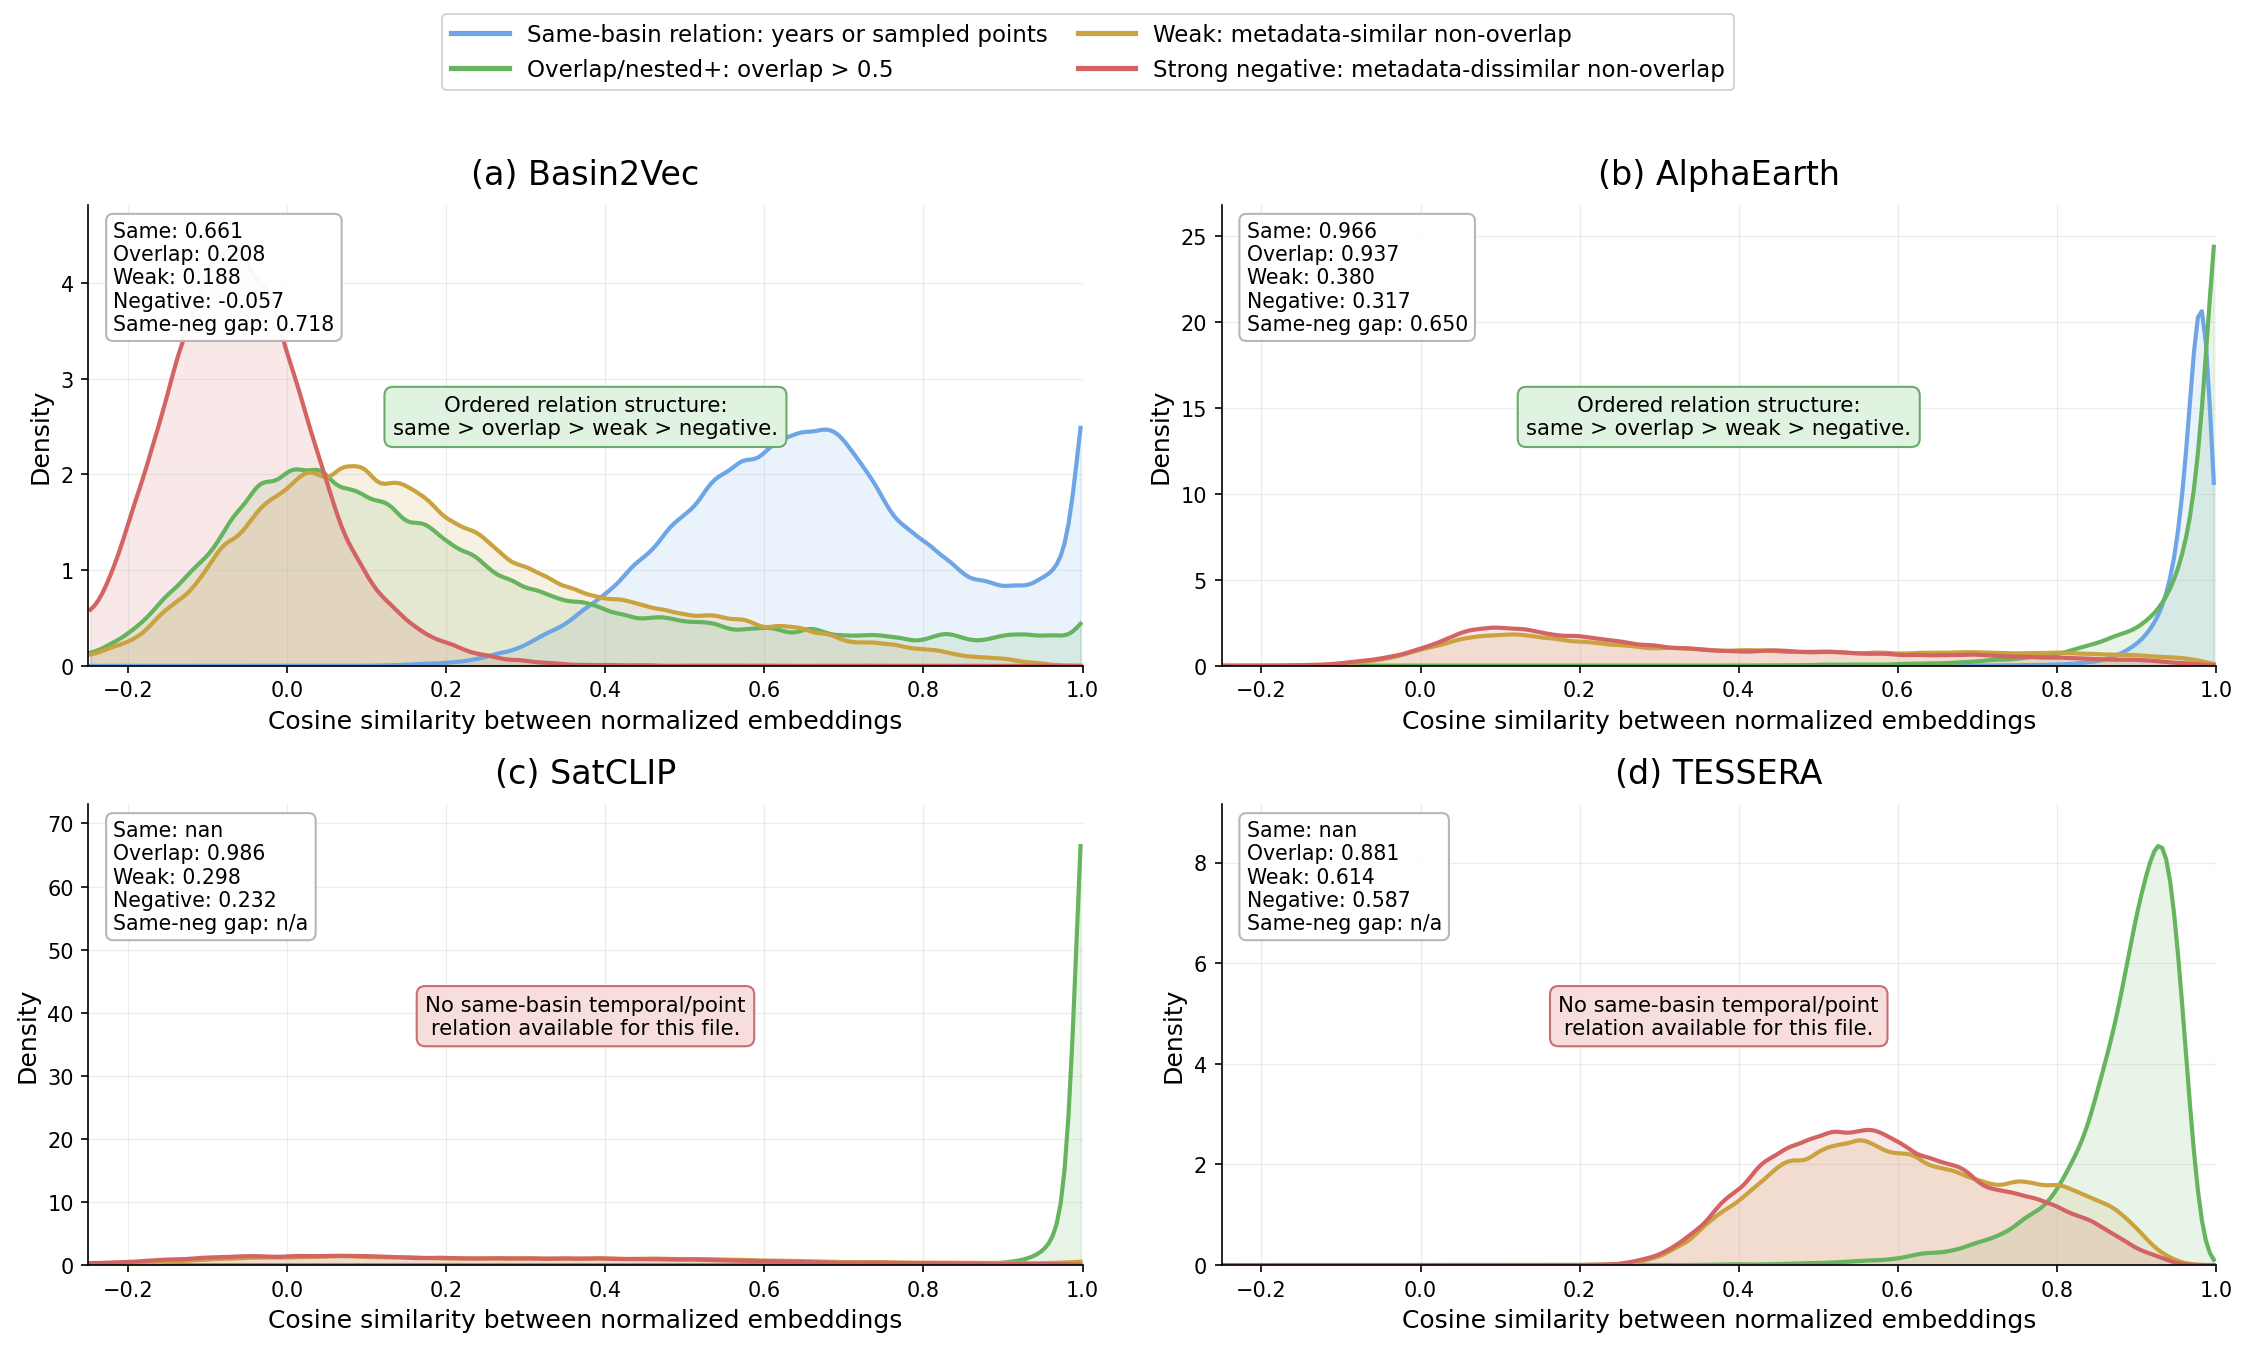

In [14]:
#!/usr/bin/env python3
# ==========================================================
# Hydrologic relation structure figure:
# Basin2Vec vs AlphaEarth vs SatCLIP vs TESSERA
#
# Relation definitions:
#
#   Basin2Vec / AlphaEarth:
#     - Same-basin relation:
#         Temporal+: same basin, different years
#
#   SatCLIP / TESSERA 8-point embeddings:
#     - Same-basin relation:
#         Point+: same basin, different sampled points
#
#   All models:
#     - Overlap/nested relation:
#         basin overlap > threshold
#     - Weak relation:
#         metadata-similar non-overlap basins
#     - Strong negative:
#         metadata-dissimilar non-overlap basins
#
# Outputs:
#   paper_results_all_embedding_relation_structure/
#       figures/
#           fig_relation_structure_all_embeddings.png
#           fig_relation_structure_all_embeddings.pdf
#       tables/
#           relation_similarity_summary_all_embeddings.csv
# ==========================================================

from __future__ import annotations

from pathlib import Path
from collections import defaultdict
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

warnings.filterwarnings("ignore")


# ==========================================================
# CONFIG
# ==========================================================

SEED = 42
RNG = np.random.default_rng(SEED)

ALPHAEARTH_NPZ = Path(
    "alphaearth_embeddings/embeddings/alphaearth_annual_basin_embeddings_2017_2024_scale500m.npz"
)
SATCLIP_NPZ = Path("satclip_embeddings/satclip_8point_2024_embeddings.npz")
TESSERA_NPZ = Path("tessera_embeddings/tessera_8point_2024_embeddings.npz")
BASIN2VEC_NPZ = Path(
    "../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz"
)

BASIN_METADATA_PATH = Path("/data/basin2vec/cache/metadata/basin_metadata.parquet")
OVERLAP_PAIRS_PARQUET = Path("/data/basin2vec/cache/basin_overlap_pairs.parquet")

MODEL_CONFIGS = [
    {
        "name": "Basin2Vec",
        "path": BASIN2VEC_NPZ,
        "preferred_embedding_key": "embeddings",
        "prefer_3d_points": False,
        "year_min": 1985,
        "year_max": 2024,
    },
    {
        "name": "AlphaEarth",
        "path": ALPHAEARTH_NPZ,
        "preferred_embedding_key": None,
        "prefer_3d_points": False,
        "year_min": 2017,
        "year_max": 2024,
    },
    {
        "name": "SatCLIP",
        "path": SATCLIP_NPZ,
        "preferred_embedding_key": None,
        "prefer_3d_points": True,
        "year_min": None,
        "year_max": None,
    },
    {
        "name": "TESSERA",
        "path": TESSERA_NPZ,
        "preferred_embedding_key": None,
        "prefer_3d_points": True,
        "year_min": None,
        "year_max": None,
    },
]

OUT_DIR = Path("paper_results_all_embedding_relation_structure")
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

OVERLAP_THRESHOLD = 0.5

META_TAU = 1.5
META_SIMILAR_Q = 0.90
META_DISSIMILAR_Q = 0.10

MAX_SAME_BASIN_PAIRS = 50_000
MAX_OVERLAP_PAIRS = 50_000
MAX_META_SIM_PAIRS = 50_000
MAX_META_DISSIMILAR_PAIRS = 50_000
MAX_CANDIDATE_NONOVERLAP_PAIRS = 300_000

plt.rcParams.update({
    "figure.figsize": (16, 9),
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RELATION_COLORS = {
    "same": "#6ea6e5",
    "overlap": "#67b45f",
    "weak": "#caa23f",
    "negative": "#d46363",
}

BASE_RELATION_LABELS = {
    "overlap": f"Overlap/nested+: overlap > {OVERLAP_THRESHOLD}",
    "weak": "Weak: metadata-similar non-overlap",
    "negative": "Strong negative: metadata-dissimilar non-overlap",
}

DEFAULT_METADATA_COLUMNS = [
    "log_area_km2_z",
    "log_bbox_width_km_z",
    "log_bbox_height_km_z",
    "log_patch_pixel_width_km_z",
    "log_patch_pixel_height_km_z",
    "log_patch_pixel_area_km2_z",
    "bbox_fill_fraction_z",
    "compactness_z",
    "solidity_z",
    "log_shape_index_z",
    "log_overlap_degree_z",
]


# ==========================================================
# BASIC HELPERS
# ==========================================================

def normalize_site_id(x) -> str | None:
    if pd.isna(x):
        return None

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    digits = re.sub(r"\D", "", s)

    if len(digits) == 0:
        return None

    if len(digits) <= 8:
        digits = digits.zfill(8)

    return digits


def l2_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    return x / np.clip(np.linalg.norm(x, axis=1, keepdims=True), eps, None)


def is_numeric_array(arr: np.ndarray) -> bool:
    return np.issubdtype(np.asarray(arr).dtype, np.number)


def safe_mean(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.nanmean(x)) if len(x) else np.nan


def safe_std(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.nanstd(x)) if len(x) else np.nan


def safe_median(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.nanmedian(x)) if len(x) else np.nan


def savefig(path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, bbox_inches="tight", dpi=300)
    print(f"Saved: {path}")


def infer_year_from_filename(npz_path: Path) -> int | None:
    matches = re.findall(r"(?<!\d)(19\d{2}|20\d{2})(?!\d)", npz_path.name)
    if len(matches) == 0:
        return None
    return int(matches[-1])


def infer_site_id_column(df: pd.DataFrame) -> str | None:
    candidates = [
        "site_id", "siteid", "gage_id", "gageid", "gauge_id", "gaugeid",
        "station_id", "staid", "site_no", "usgs_id", "basin_id",
        "GAGE_ID", "STAID",
    ]

    lower = {str(c).lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]

    return None


def infer_site_id_int_column(df: pd.DataFrame) -> str | None:
    candidates = [
        "site_id_int",
        "site_int",
        "gage_id_int",
        "basin_id_int",
        "basin_index",
        "basin_idx",
        "index",
    ]

    lower = {str(c).lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]

    return None


# ==========================================================
# GENERIC EMBEDDING LOADER
# ==========================================================

def print_npz_keys(npz_path: Path, model_name: str):
    data = np.load(npz_path, allow_pickle=True)

    print("\n" + "=" * 80)
    print(f"{model_name} NPZ keys: {npz_path}")
    print("=" * 80)

    for k in data.files:
        arr = data[k]
        print(f"{k:35s} shape={arr.shape}, dtype={arr.dtype}")

    return data


def choose_embedding_array(
    data,
    preferred_key: str | None,
    model_name: str,
    prefer_3d_points: bool = False,
):
    if preferred_key is not None and preferred_key in data.files:
        return preferred_key, np.asarray(data[preferred_key], dtype=np.float32)

    candidates = [
        "point_embeddings",
        "pointwise_embeddings",
        "embeddings_8point",
        "embeddings_8points",
        "basin_point_embeddings",
        "satclip_point_embeddings",
        "tessera_point_embeddings",
        "embeddings",
        "embedding",
        "raw_embeddings",
        "alphaearth_embeddings",
        "satclip_embeddings",
        "tessera_embeddings",
        "basin_embeddings",
        "avg_embeddings",
        "hydrologic_repr",
        "z",
        "features",
    ]

    if prefer_3d_points:
        for key in candidates:
            if key in data.files:
                arr = np.asarray(data[key])
                if is_numeric_array(arr) and arr.ndim == 3:
                    return key, arr.astype(np.float32)

        numeric_3d = []

        for key in data.files:
            arr = np.asarray(data[key])
            if is_numeric_array(arr) and arr.ndim == 3:
                numeric_3d.append((arr.size, key, arr))

        if numeric_3d:
            _, key, arr = max(numeric_3d, key=lambda x: x[0])
            print(f"Warning: using auto-detected 3D embedding key for {model_name}: {key}")
            return key, arr.astype(np.float32)

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if is_numeric_array(arr) and arr.ndim in (2, 3):
                return key, arr.astype(np.float32)

    numeric = []

    for key in data.files:
        arr = np.asarray(data[key])
        if is_numeric_array(arr) and arr.ndim in (2, 3):
            numeric.append((arr.size, key, arr))

    if numeric:
        _, key, arr = max(numeric, key=lambda x: x[0])
        print(f"Warning: using auto-detected embedding key for {model_name}: {key}")
        return key, arr.astype(np.float32)

    raise KeyError(
        f"Could not find embedding array for {model_name}. "
        f"Available keys: {data.files}"
    )


def choose_site_ids(data, model_name: str, n_expected: int):
    candidates = [
        "labels",
        "avg_labels",
        "site_ids",
        "site_id",
        "gage_ids",
        "gauge_ids",
        "basin_ids",
        "basin_id",
        "ids",
        "id",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr

    skip_patterns = [
        "year",
        "embedding",
        "feature",
        "coord",
        "lat",
        "lon",
        "x",
        "y",
        "point",
        "dim",
    ]

    for key in data.files:
        key_lower = key.lower()

        if any(p in key_lower for p in skip_patterns):
            continue

        arr = np.asarray(data[key])

        if arr.ndim != 1 or len(arr) != n_expected:
            continue

        if arr.dtype.kind not in {"O", "U", "S", "i", "u"}:
            continue

        if np.issubdtype(arr.dtype, np.number):
            arr_min = np.nanmin(arr)
            arr_max = np.nanmax(arr)

            if 1900 <= arr_min <= 2100 and 1900 <= arr_max <= 2100:
                continue

        print(f"Warning: using auto-detected site-id key for {model_name}: {key}")
        return key, arr

    raise KeyError(
        f"Could not find site/basin ID array for {model_name} with length {n_expected}. "
        f"Available keys: {data.files}"
    )


def choose_years(data, model_name: str, n_expected: int, npz_path: Path):
    candidates = [
        "years",
        "year",
        "sample_years",
        "embedding_years",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr.astype(int)

    inferred_year = infer_year_from_filename(npz_path)

    if inferred_year is not None:
        print(
            f"{model_name}: no year array found; inferred year={inferred_year} "
            f"from filename {npz_path.name}."
        )
        return "inferred_from_filename", np.full(n_expected, inferred_year, dtype=int)

    print(f"{model_name}: no year array found; using dummy year=0.")
    return "dummy_year", np.zeros(n_expected, dtype=int)


def flatten_or_keep_embeddings(emb_raw, df_base, model_name, emb_key):
    emb_raw = np.asarray(emb_raw, dtype=np.float32)

    if emb_raw.ndim == 2:
        df = df_base.copy()
        df["point_id"] = 0

        if df["year"].nunique() > 1:
            same_mode = "years"
            same_label = "Temporal+: same basin, different years"
        else:
            same_mode = "single_sample"
            same_label = "Same-basin relation unavailable"

        return df, emb_raw, same_mode, same_label

    if emb_raw.ndim == 3:
        n_basins, n_points, dim = emb_raw.shape

        if len(df_base) != n_basins:
            raise ValueError(
                f"{model_name}: 3D embedding first dimension does not match metadata. "
                f"emb.shape[0]={n_basins}, len(df_base)={len(df_base)}"
            )

        print(
            f"{model_name}: embedding key '{emb_key}' is 3D {emb_raw.shape}; "
            "flattening sampled points instead of averaging."
        )

        emb = emb_raw.reshape(n_basins * n_points, dim).astype(np.float32)

        df = df_base.loc[df_base.index.repeat(n_points)].copy().reset_index(drop=True)
        df["point_id"] = np.tile(np.arange(n_points), n_basins)

        same_mode = "points"
        same_label = "Point+: same basin, different sampled points"

        return df, emb, same_mode, same_label

    raise ValueError(
        f"{model_name}: embedding array must be 2D or 3D. "
        f"Got shape={emb_raw.shape}."
    )


def load_embedding_npz(
    npz_path: Path,
    model_name: str,
    preferred_embedding_key: str | None = None,
    prefer_3d_points: bool = False,
    year_min: int | None = None,
    year_max: int | None = None,
):
    npz_path = Path(npz_path)

    if not npz_path.exists():
        raise FileNotFoundError(f"{model_name} NPZ not found: {npz_path}")

    data = print_npz_keys(npz_path, model_name)

    emb_key, emb_raw = choose_embedding_array(
        data=data,
        preferred_key=preferred_embedding_key,
        model_name=model_name,
        prefer_3d_points=prefer_3d_points,
    )

    n_base = emb_raw.shape[0]

    site_key, site_ids_raw = choose_site_ids(
        data=data,
        model_name=model_name,
        n_expected=n_base,
    )

    year_key, years = choose_years(
        data=data,
        model_name=model_name,
        n_expected=n_base,
        npz_path=npz_path,
    )

    site_ids = np.array([normalize_site_id(x) for x in site_ids_raw], dtype=object)

    df_base = pd.DataFrame({
        "site_id": site_ids,
        "year": years.astype(int),
    })

    # ------------------------------------------------------
    # FIXED FILTERING BLOCK
    # Do NOT use in-place &= here, because pandas may return
    # a read-only NumPy array.
    # ------------------------------------------------------
    valid = df_base["site_id"].notna().to_numpy(dtype=bool, copy=True)
    year_arr = df_base["year"].to_numpy(dtype=int, copy=False)

    if year_min is not None:
        valid = valid & (year_arr >= int(year_min))

    if year_max is not None:
        valid = valid & (year_arr <= int(year_max))

    df_base = df_base.loc[valid].reset_index(drop=True)
    emb_raw = emb_raw[valid]

    if len(df_base) == 0:
        raise RuntimeError(
            f"{model_name}: no samples left after site/year filtering. "
            f"year_min={year_min}, year_max={year_max}"
        )

    df, emb, same_mode, same_label = flatten_or_keep_embeddings(
        emb_raw=emb_raw,
        df_base=df_base,
        model_name=model_name,
        emb_key=emb_key,
    )

    emb = l2_normalize(emb)

    unique_years = sorted(df["year"].unique().tolist())

    print("\nLoaded:", model_name)
    print("  embedding key:", emb_key)
    print("  site key:", site_key)
    print("  year key:", year_key)
    print("  raw shape after filtering:", emb_raw.shape)
    print("  sample shape after flattening:", emb.shape)
    print("  basins:", df["site_id"].nunique())

    if len(unique_years) <= 10:
        print("  years:", unique_years)
    else:
        print("  years:", unique_years[:5], "...", unique_years[-5:])

    print("  same mode:", same_mode)

    return {
        "model_name": model_name,
        "df": df,
        "emb": emb,
        "same_mode": same_mode,
        "same_label": same_label,
        "embedding_key": emb_key,
    }


# ==========================================================
# METADATA + OVERLAP
# ==========================================================

def load_basin_metadata(meta_path: Path, basin_ids=None):
    meta_path = Path(meta_path)

    if not meta_path.exists():
        raise FileNotFoundError(f"Metadata file not found: {meta_path}")

    if meta_path.suffix.lower() == ".parquet":
        df = pd.read_parquet(meta_path)
    else:
        df = pd.read_csv(meta_path, dtype={"site_id": str})

    df = df.copy()

    site_col = infer_site_id_column(df)
    site_int_col = infer_site_id_int_column(df)

    if site_col is None:
        raise KeyError("Could not infer site ID column from metadata file.")

    if site_int_col is None:
        raise KeyError("Could not infer site_id_int column from metadata file.")

    df["site_id"] = df[site_col].apply(normalize_site_id)
    df["site_id_int"] = pd.to_numeric(df[site_int_col], errors="coerce").astype("Int64")

    if basin_ids is not None:
        basin_ids = set(map(str, basin_ids))
        df = df[df["site_id"].isin(basin_ids)].copy()

    meta_cols = [c for c in DEFAULT_METADATA_COLUMNS if c in df.columns]

    if len(meta_cols) == 0:
        raise KeyError(
            "Metadata file does not contain any expected metadata columns. "
            f"Expected one or more of: {DEFAULT_METADATA_COLUMNS}"
        )

    for c in meta_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].fillna(df[c].median(skipna=True))

    keep_cols = ["site_id", "site_id_int"] + meta_cols

    out = (
        df[keep_cols]
        .dropna(subset=["site_id", "site_id_int"])
        .drop_duplicates(subset=["site_id"])
        .reset_index(drop=True)
    )

    out["site_id_int"] = out["site_id_int"].astype(int)

    print(f"\nLoaded metadata from: {meta_path}")
    print(f"Site ID column: {site_col}")
    print(f"Integer ID column: {site_int_col}")
    print(f"Number of basins in metadata: {len(out)}")
    print(f"Metadata columns: {meta_cols}")

    return out, meta_cols


def load_overlap_strengths(overlap_path: Path, meta_df: pd.DataFrame):
    overlap_path = Path(overlap_path)

    if not overlap_path.exists():
        raise FileNotFoundError(f"Overlap pair file not found: {overlap_path}")

    odf = pd.read_parquet(overlap_path).copy()

    if "site_id_int_a" not in odf.columns or "site_id_int_b" not in odf.columns:
        raise KeyError("Overlap parquet must contain site_id_int_a and site_id_int_b.")

    if "overlap_score" in odf.columns:
        score_col = "overlap_score"
    elif "overlap_strength" in odf.columns:
        score_col = "overlap_strength"
    elif "overlap" in odf.columns:
        score_col = "overlap"
    elif "iou" in odf.columns:
        score_col = "iou"
    else:
        score_col = None

    int_to_site = dict(
        zip(
            meta_df["site_id_int"].astype(int),
            meta_df["site_id"].astype(str),
        )
    )

    overlap_strength = {}
    overlap_neighbors = defaultdict(set)

    for _, row in odf.iterrows():
        sid_a = int_to_site.get(int(row["site_id_int_a"]))
        sid_b = int_to_site.get(int(row["site_id_int_b"]))

        if sid_a is None or sid_b is None or sid_a == sid_b:
            continue

        score = float(row[score_col]) if score_col is not None else 1.0

        key = tuple(sorted((sid_a, sid_b)))
        overlap_strength[key] = max(score, overlap_strength.get(key, 0.0))

        overlap_neighbors[sid_a].add(sid_b)
        overlap_neighbors[sid_b].add(sid_a)

    print(f"\nLoaded overlap strengths from: {overlap_path}")
    print(f"Score column: {score_col}")
    print(f"Filtered overlap pairs: {len(overlap_strength)}")

    return overlap_strength, overlap_neighbors


# ==========================================================
# RELATION BUILDERS
# ==========================================================

def average_embeddings_by_basin(emb, labels):
    basin_to_vecs = defaultdict(list)

    for lab, vec in zip(labels, emb):
        basin_to_vecs[str(lab)].append(vec)

    avg_labels = []
    avg_emb = []

    for lab in sorted(basin_to_vecs.keys()):
        z = np.stack(basin_to_vecs[lab], axis=0)
        z_mean = z.mean(axis=0)
        z_mean = l2_normalize(z_mean[None, :])[0]

        avg_labels.append(lab)
        avg_emb.append(z_mean)

    return np.asarray(avg_labels).astype(str), np.stack(avg_emb, axis=0).astype(np.float32)


def build_same_basin_pairs(df, same_mode: str, max_pairs=50_000):
    if same_mode == "single_sample":
        return []

    basin_to_idx = defaultdict(list)

    for i, row in df.reset_index(drop=True).iterrows():
        basin_to_idx[str(row["site_id"])].append(
            (
                int(i),
                int(row["year"]),
                int(row.get("point_id", 0)),
            )
        )

    valid_groups = []

    for _, items in basin_to_idx.items():
        if same_mode == "years":
            vals = {yr for _, yr, _ in items}
        elif same_mode == "points":
            vals = {pt for _, _, pt in items}
        else:
            vals = set()

        if len(items) >= 2 and len(vals) >= 2:
            valid_groups.append(items)

    if len(valid_groups) == 0:
        return []

    pairs = []
    attempts = 0
    max_attempts = max_pairs * 100

    while len(pairs) < max_pairs and attempts < max_attempts:
        items = valid_groups[RNG.integers(0, len(valid_groups))]
        a, b = RNG.choice(len(items), size=2, replace=False)

        ia, ya, pa = items[a]
        ib, yb, pb = items[b]

        if same_mode == "years" and ya == yb:
            attempts += 1
            continue

        if same_mode == "points" and pa == pb:
            attempts += 1
            continue

        pairs.append((ia, ib))
        attempts += 1

    return pairs


def build_overlap_pairs(basin_ids, overlap_strength_map, threshold=0.5, max_pairs=50_000):
    basin_ids = np.asarray(basin_ids).astype(str)
    id_to_idx = {sid: i for i, sid in enumerate(basin_ids)}

    pairs = []
    strengths = []

    for (a, b), s in overlap_strength_map.items():
        if a in id_to_idx and b in id_to_idx and s >= threshold:
            pairs.append((id_to_idx[a], id_to_idx[b]))
            strengths.append(float(s))

    if len(pairs) > max_pairs:
        idx = RNG.choice(len(pairs), size=max_pairs, replace=False)
        pairs = [pairs[k] for k in idx]
        strengths = np.asarray(strengths, dtype=np.float32)[idx]
    else:
        strengths = np.asarray(strengths, dtype=np.float32)

    return pairs, strengths


def sample_nonoverlap_candidate_pairs(basin_ids, overlap_neighbors, n_pairs=300_000):
    basin_ids = np.asarray(basin_ids).astype(str)
    n = len(basin_ids)

    if n < 2:
        return []

    seen = set()
    pairs = []
    attempts = 0
    max_attempts = max(10 * n_pairs, 100_000)

    while len(pairs) < n_pairs and attempts < max_attempts:
        i = int(RNG.integers(0, n))
        j = int(RNG.integers(0, n - 1))

        if j >= i:
            j += 1

        a = basin_ids[i]
        b = basin_ids[j]

        if i == j or a == b:
            attempts += 1
            continue

        if b in overlap_neighbors.get(a, set()):
            attempts += 1
            continue

        key = (i, j) if i < j else (j, i)

        if key in seen:
            attempts += 1
            continue

        seen.add(key)
        pairs.append(key)
        attempts += 1

    return pairs


def metadata_similarity_for_pairs(meta_matrix, pairs, tau=1.5):
    if len(pairs) == 0:
        return np.array([], dtype=np.float32)

    pairs = np.asarray(pairs, dtype=np.int64)

    diff = meta_matrix[pairs[:, 0]] - meta_matrix[pairs[:, 1]]
    d2 = np.sum(diff * diff, axis=1)

    sims = np.exp(-d2 / (2.0 * tau * tau))

    return sims.astype(np.float32)


def build_nonoverlap_relation_sets(basin_ids, meta_matrix, overlap_neighbors):
    candidate_pairs = sample_nonoverlap_candidate_pairs(
        basin_ids=basin_ids,
        overlap_neighbors=overlap_neighbors,
        n_pairs=MAX_CANDIDATE_NONOVERLAP_PAIRS,
    )

    if len(candidate_pairs) == 0:
        raise RuntimeError("No non-overlap candidate pairs could be sampled.")

    sims = metadata_similarity_for_pairs(
        meta_matrix=meta_matrix,
        pairs=candidate_pairs,
        tau=META_TAU,
    )

    candidate_pairs = np.asarray(candidate_pairs, dtype=np.int64)

    q_hi = float(np.quantile(sims, META_SIMILAR_Q))
    q_lo = float(np.quantile(sims, META_DISSIMILAR_Q))

    idx_hi = np.where(sims >= q_hi)[0]
    idx_lo = np.where(sims <= q_lo)[0]

    if len(idx_hi) == 0 or len(idx_lo) == 0:
        raise RuntimeError("Could not form metadata-similar/dissimilar relation sets.")

    def choose(idxs, n_keep):
        if len(idxs) <= n_keep:
            return idxs
        return RNG.choice(idxs, size=n_keep, replace=False)

    idx_meta_sim = choose(idx_hi, MAX_META_SIM_PAIRS)
    idx_meta_dis = choose(idx_lo, MAX_META_DISSIMILAR_PAIRS)

    return {
        "meta_sim_pairs": [tuple(x) for x in candidate_pairs[idx_meta_sim]],
        "meta_dis_pairs": [tuple(x) for x in candidate_pairs[idx_meta_dis]],
        "similar_q": q_hi,
        "dissimilar_q": q_lo,
    }


def cosine_for_pairs(emb, pairs):
    if len(pairs) == 0:
        return np.array([], dtype=np.float32)

    pairs = np.asarray(pairs, dtype=np.int64)

    return np.sum(
        emb[pairs[:, 0]] * emb[pairs[:, 1]],
        axis=1,
    ).astype(np.float32)


# ==========================================================
# BUILD DISTRIBUTIONS
# ==========================================================

def build_relation_distributions(
    model_name,
    df,
    emb,
    same_mode,
    same_label,
    meta_df,
    meta_cols,
    overlap_strength_map,
    overlap_neighbors,
):
    print("\n" + "=" * 80)
    print(f"Building relation distributions for: {model_name}")
    print("=" * 80)

    labels = df["site_id"].astype(str).to_numpy()

    avg_labels, avg_emb = average_embeddings_by_basin(emb, labels)

    meta_map = meta_df.drop_duplicates(subset=["site_id"]).set_index("site_id")

    keep_idx = [i for i, sid in enumerate(avg_labels) if sid in meta_map.index]
    avg_labels = avg_labels[keep_idx]
    avg_emb = avg_emb[keep_idx]

    if len(avg_labels) == 0:
        raise RuntimeError(f"No avg_labels found in metadata for {model_name}")

    meta_sub = meta_map.loc[avg_labels]
    meta_matrix = meta_sub[meta_cols].to_numpy(dtype=np.float32)

    same_pairs = build_same_basin_pairs(
        df=df,
        same_mode=same_mode,
        max_pairs=MAX_SAME_BASIN_PAIRS,
    )

    overlap_pairs, overlap_strengths = build_overlap_pairs(
        basin_ids=avg_labels,
        overlap_strength_map=overlap_strength_map,
        threshold=OVERLAP_THRESHOLD,
        max_pairs=MAX_OVERLAP_PAIRS,
    )

    nonoverlap_sets = build_nonoverlap_relation_sets(
        basin_ids=avg_labels,
        meta_matrix=meta_matrix,
        overlap_neighbors=overlap_neighbors,
    )

    weak_pairs = nonoverlap_sets["meta_sim_pairs"]
    negative_pairs = nonoverlap_sets["meta_dis_pairs"]

    print(f"Same-basin pairs: {len(same_pairs)}")
    print(f"Overlap pairs: {len(overlap_pairs)}")
    print(f"Weak pairs: {len(weak_pairs)}")
    print(f"Negative pairs: {len(negative_pairs)}")

    distributions = {
        "same": cosine_for_pairs(emb, same_pairs),
        "overlap": cosine_for_pairs(avg_emb, overlap_pairs),
        "weak": cosine_for_pairs(avg_emb, weak_pairs),
        "negative": cosine_for_pairs(avg_emb, negative_pairs),
    }

    relation_labels = {
        "same": same_label,
        **BASE_RELATION_LABELS,
    }

    summary_rows = []

    for rel_name, values in distributions.items():
        summary_rows.append({
            "model": model_name,
            "relation": rel_name,
            "relation_label": relation_labels[rel_name],
            "n_pairs": int(len(values)),
            "mean": safe_mean(values),
            "median": safe_median(values),
            "std": safe_std(values),
            "q25": float(np.quantile(values, 0.25)) if len(values) else np.nan,
            "q75": float(np.quantile(values, 0.75)) if len(values) else np.nan,
        })

    summary_df = pd.DataFrame(summary_rows)

    return distributions, summary_df, relation_labels


# ==========================================================
# PLOTTING
# ==========================================================

def smooth_density_line(values, bins=250, x_range=(-0.3, 1.0), sigma=2.0):
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        xs = np.linspace(x_range[0], x_range[1], bins)
        ys = np.zeros_like(xs)
        return xs, ys

    hist, edges = np.histogram(
        values,
        bins=bins,
        range=x_range,
        density=True,
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    smooth = gaussian_filter1d(
        hist.astype(np.float64),
        sigma=sigma,
        mode="nearest",
    )

    return centers, smooth


def get_relation_mean(summary_df, model_name, relation_name):
    row = summary_df[
        (summary_df["model"] == model_name) &
        (summary_df["relation"] == relation_name)
    ]

    if len(row) == 0:
        return np.nan

    return float(row["mean"].iloc[0])


def build_numeric_text(summary_df, model_name):
    same = get_relation_mean(summary_df, model_name, "same")
    overlap = get_relation_mean(summary_df, model_name, "overlap")
    weak = get_relation_mean(summary_df, model_name, "weak")
    negative = get_relation_mean(summary_df, model_name, "negative")

    if np.isfinite(same) and np.isfinite(negative):
        gap_text = f"Same-neg gap: {same - negative:.3f}"
    else:
        gap_text = "Same-neg gap: n/a"

    return (
        f"Same: {same:.3f}\n"
        f"Overlap: {overlap:.3f}\n"
        f"Weak: {weak:.3f}\n"
        f"Negative: {negative:.3f}\n"
        f"{gap_text}"
    )


def build_interpretation_text(summary_df, model_name):
    same = get_relation_mean(summary_df, model_name, "same")
    overlap = get_relation_mean(summary_df, model_name, "overlap")
    weak = get_relation_mean(summary_df, model_name, "weak")
    negative = get_relation_mean(summary_df, model_name, "negative")

    if not np.isfinite(same):
        return (
            "No same-basin temporal/point\n"
            "relation available for this file."
        )

    if same > overlap > weak > negative:
        return (
            "Ordered relation structure:\n"
            "same > overlap > weak > negative."
        )

    if same > negative:
        return (
            "Same-basin similarity is higher\n"
            "than strong negatives."
        )

    return (
        "Weak relation separation:\n"
        "same-basin not clearly above negatives."
    )


def interpretation_box_style(summary_df, model_name):
    same = get_relation_mean(summary_df, model_name, "same")
    negative = get_relation_mean(summary_df, model_name, "negative")

    if np.isfinite(same) and np.isfinite(negative) and same > negative:
        return dict(
            boxstyle="round,pad=0.40",
            facecolor="#dff3df",
            edgecolor="#65a765",
            alpha=0.96,
        )

    return dict(
        boxstyle="round,pad=0.40",
        facecolor="#f8dcdc",
        edgecolor="#c46a6a",
        alpha=0.96,
    )


def plot_model_panel(
    ax,
    model_name,
    distributions,
    relation_labels,
    summary_df,
    panel_label,
    x_range=(-0.25, 1.0),
    bins=260,
    sigma=2.0,
):
    order = ["same", "overlap", "weak", "negative"]

    ymax = 0.0
    lines = {}

    for rel in order:
        xs, ys = smooth_density_line(
            distributions[rel],
            bins=bins,
            x_range=x_range,
            sigma=sigma,
        )

        ymax = max(ymax, float(np.max(ys)))
        lines[rel] = (xs, ys)

    for rel in order:
        if len(distributions[rel]) == 0:
            continue

        xs, ys = lines[rel]

        ax.plot(
            xs,
            ys,
            color=RELATION_COLORS[rel],
            linewidth=2.0,
            label=relation_labels[rel],
        )

        ax.fill_between(
            xs,
            ys,
            0,
            color=RELATION_COLORS[rel],
            alpha=0.14,
        )

    ax.set_xlim(*x_range)

    if ymax > 0:
        ax.set_ylim(0, ymax * 1.10)

    ax.set_xlabel("Cosine similarity between normalized embeddings", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)

    ax.set_title(
        f"{panel_label} {model_name}",
        fontsize=16,
        pad=10,
    )

    ax.tick_params(axis="both", labelsize=10)
    ax.grid(True, alpha=0.22, linewidth=0.6)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    ax.text(
        0.025,
        0.965,
        build_numeric_text(summary_df, model_name),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.8,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="0.70",
            alpha=0.95,
        ),
    )

    ax.text(
        0.50,
        0.54,
        build_interpretation_text(summary_df, model_name),
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=10.2,
        bbox=interpretation_box_style(summary_df, model_name),
    )


# ==========================================================
# MAIN
# ==========================================================

def main():
    meta_df, meta_cols = load_basin_metadata(BASIN_METADATA_PATH)

    overlap_strength_map, overlap_neighbors = load_overlap_strengths(
        OVERLAP_PAIRS_PARQUET,
        meta_df,
    )

    all_distributions = {}
    all_relation_labels = {}
    all_summary_dfs = []

    for cfg in MODEL_CONFIGS:
        model_name = cfg["name"]

        print("\n" + "#" * 90)
        print(f"Processing: {model_name}")
        print("#" * 90)

        loaded = load_embedding_npz(
            npz_path=cfg["path"],
            model_name=model_name,
            preferred_embedding_key=cfg.get("preferred_embedding_key"),
            prefer_3d_points=cfg.get("prefer_3d_points", False),
            year_min=cfg.get("year_min"),
            year_max=cfg.get("year_max"),
        )

        distributions, summary_df, relation_labels = build_relation_distributions(
            model_name=model_name,
            df=loaded["df"],
            emb=loaded["emb"],
            same_mode=loaded["same_mode"],
            same_label=loaded["same_label"],
            meta_df=meta_df,
            meta_cols=meta_cols,
            overlap_strength_map=overlap_strength_map,
            overlap_neighbors=overlap_neighbors,
        )

        all_distributions[model_name] = distributions
        all_relation_labels[model_name] = relation_labels
        all_summary_dfs.append(summary_df)

    summary_df = pd.concat(all_summary_dfs, ignore_index=True)

    summary_csv = TABLE_DIR / "relation_similarity_summary_all_embeddings.csv"
    summary_df.to_csv(summary_csv, index=False)

    print("\nSaved summary table:", summary_csv)
    print(summary_df.to_string(index=False))

    model_order = ["Basin2Vec", "AlphaEarth", "SatCLIP", "TESSERA"]
    panel_labels = ["(a)", "(b)", "(c)", "(d)"]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(15.5, 9.3),
        sharex=False,
        sharey=False,
    )

    axes = axes.ravel()

    for ax, model_name, panel_label in zip(axes, model_order, panel_labels):
        plot_model_panel(
            ax=ax,
            model_name=model_name,
            distributions=all_distributions[model_name],
            relation_labels=all_relation_labels[model_name],
            summary_df=summary_df,
            panel_label=panel_label,
            x_range=(-0.25, 1.0),
            bins=250,
            sigma=2.2,
        )

    handles = [
        plt.Line2D(
            [0],
            [0],
            color=RELATION_COLORS["same"],
            lw=2.5,
            label="Same-basin relation: years or sampled points",
        ),
        plt.Line2D(
            [0],
            [0],
            color=RELATION_COLORS["overlap"],
            lw=2.5,
            label=BASE_RELATION_LABELS["overlap"],
        ),
        plt.Line2D(
            [0],
            [0],
            color=RELATION_COLORS["weak"],
            lw=2.5,
            label=BASE_RELATION_LABELS["weak"],
        ),
        plt.Line2D(
            [0],
            [0],
            color=RELATION_COLORS["negative"],
            lw=2.5,
            label=BASE_RELATION_LABELS["negative"],
        ),
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.985),
        ncol=2,
        frameon=True,
        fontsize=11.0,
        columnspacing=1.3,
        handlelength=2.5,
    )

    fig.subplots_adjust(
        left=0.07,
        right=0.985,
        bottom=0.08,
        top=0.84,
        wspace=0.14,
        hspace=0.30,
    )

    out_png = FIG_DIR / "fig_relation_structure_all_embeddings.png"
    out_pdf = FIG_DIR / "fig_relation_structure_all_embeddings.pdf"

    savefig(out_png)
    savefig(out_pdf)

    plt.show()


if __name__ == "__main__":
    main()


Loaded metadata
  path: /data/basin2vec/cache/metadata/basin_metadata.parquet
  site column: site_id
  int column: site_id_int
  basins: 9067
  features: ['log_area_km2_z', 'log_bbox_width_km_z', 'log_bbox_height_km_z', 'log_patch_pixel_width_km_z', 'log_patch_pixel_height_km_z', 'log_patch_pixel_area_km2_z', 'bbox_fill_fraction_z', 'compactness_z', 'solidity_z', 'log_shape_index_z', 'log_overlap_degree_z']

Loaded overlap pairs
  path: /data/basin2vec/cache/basin_overlap_pairs.parquet
  score column: overlap_score
  pairs: 34291

##########################################################################################
Loading model: Basin2Vec
##########################################################################################

Basin2Vec NPZ keys: ../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz
embeddings                          shape=(362680, 64), dtype=float32
hydrologic_repr                     shape=(362680, 64), dtype=floa

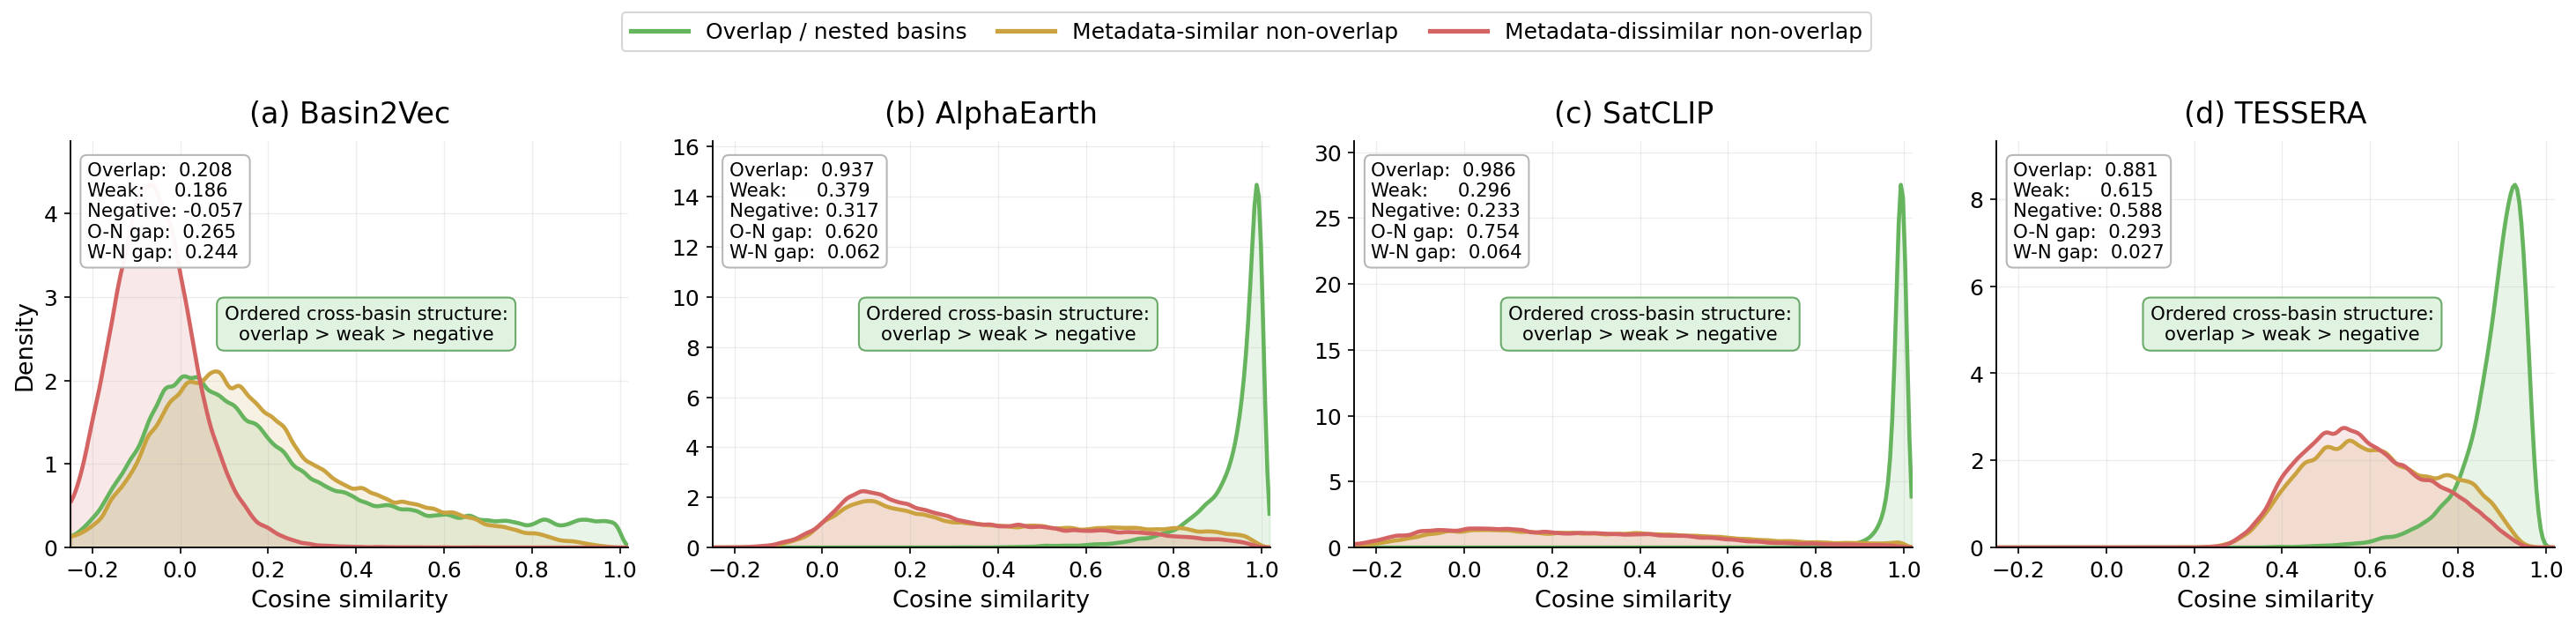


Temporal relation: Basin2Vec
  pairs: 50000

Temporal relation: AlphaEarth
  pairs: 50000
Saved: paper_results_relation_structure_clean/figures/fig_temporal_consistency_b2v_alphaearth_only.png
Saved: paper_results_relation_structure_clean/figures/fig_temporal_consistency_b2v_alphaearth_only.pdf


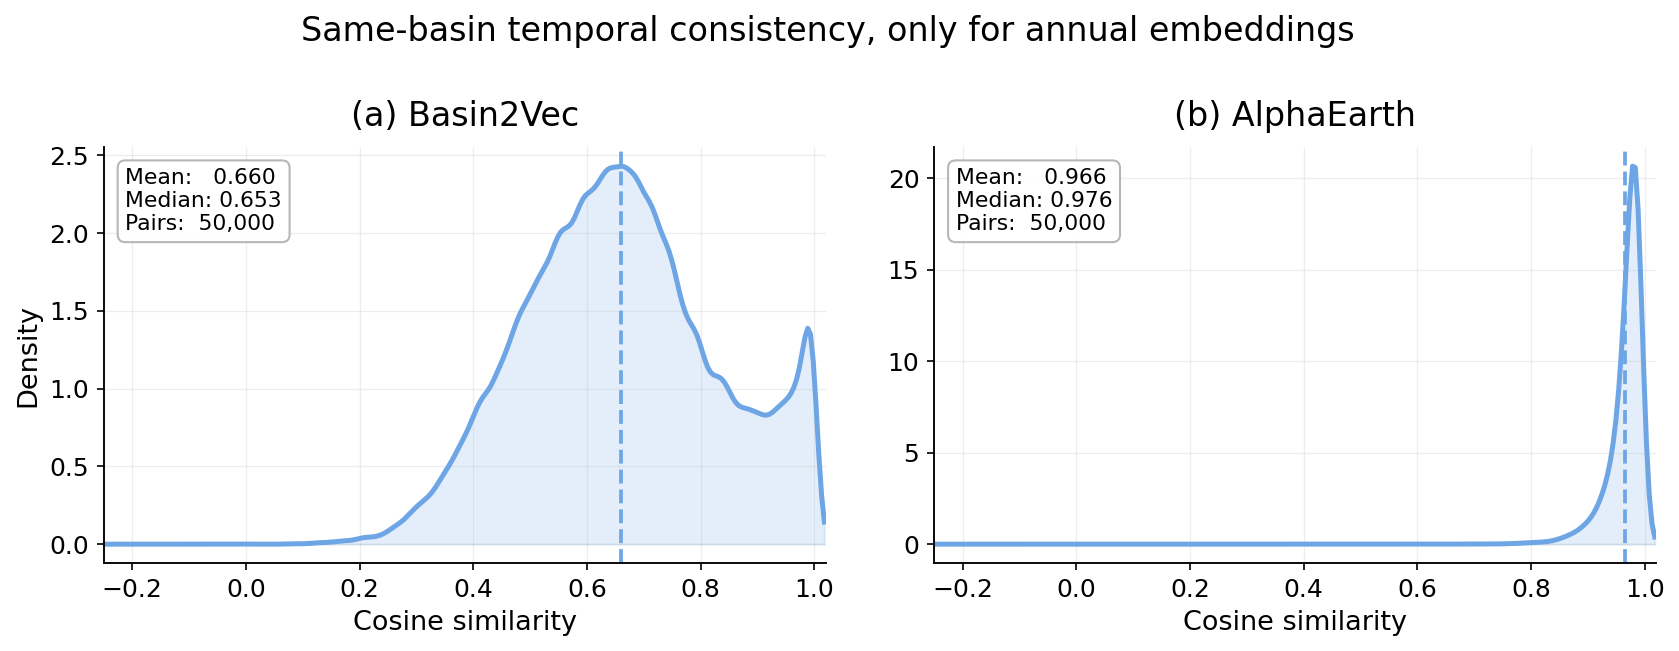

In [16]:
#!/usr/bin/env python3
# ==========================================================
# Appropriate hydrologic relation structure figures:
#
# FIGURE 1:
#   Cross-basin hydrologic relation structure for all embeddings:
#       Basin2Vec | AlphaEarth | SatCLIP | TESSERA
#
#   Relations shown for every model:
#       1. Overlap / nested basins
#       2. Metadata-similar non-overlap basins
#       3. Metadata-dissimilar non-overlap basins
#
# FIGURE 2:
#   Same-basin temporal consistency only where available:
#       Basin2Vec | AlphaEarth
#
# Why this is better:
#   - SatCLIP/TESSERA files contain one basin-level vector per basin:
#       SatCLIP: (9067, 256)
#       TESSERA: (9066, 128)
#     so same-basin temporal/point relations are not available.
#   - The all-model figure should therefore use only cross-basin relations.
# ==========================================================

from __future__ import annotations

from pathlib import Path
from collections import defaultdict
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

warnings.filterwarnings("ignore")


# ==========================================================
# CONFIG
# ==========================================================

SEED = 42
RNG = np.random.default_rng(SEED)

ALPHAEARTH_NPZ = Path(
    "alphaearth_embeddings/embeddings/alphaearth_annual_basin_embeddings_2017_2024_scale500m.npz"
)
SATCLIP_NPZ = Path("satclip_embeddings/satclip_8point_2024_embeddings.npz")
TESSERA_NPZ = Path("tessera_embeddings/tessera_8point_2024_embeddings.npz")
BASIN2VEC_NPZ = Path(
    "../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz"
)

BASIN_METADATA_PATH = Path("/data/basin2vec/cache/metadata/basin_metadata.parquet")
OVERLAP_PAIRS_PARQUET = Path("/data/basin2vec/cache/basin_overlap_pairs.parquet")

OUT_DIR = Path("paper_results_relation_structure_clean")
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_CONFIGS = [
    {
        "name": "Basin2Vec",
        "path": BASIN2VEC_NPZ,
        "preferred_embedding_key": "embeddings",
        "preferred_avg_key": "avg_embeddings",
        "preferred_avg_label_key": "avg_labels",
        "year_min": 1985,
        "year_max": 2024,
    },
    {
        "name": "AlphaEarth",
        "path": ALPHAEARTH_NPZ,
        "preferred_embedding_key": "embeddings",
        "preferred_avg_key": None,
        "preferred_avg_label_key": None,
        "year_min": 2017,
        "year_max": 2024,
    },
    {
        "name": "SatCLIP",
        "path": SATCLIP_NPZ,
        "preferred_embedding_key": "embeddings",
        "preferred_avg_key": None,
        "preferred_avg_label_key": None,
        "year_min": None,
        "year_max": None,
    },
    {
        "name": "TESSERA",
        "path": TESSERA_NPZ,
        "preferred_embedding_key": "embeddings",
        "preferred_avg_key": None,
        "preferred_avg_label_key": None,
        "year_min": None,
        "year_max": None,
    },
]

OVERLAP_THRESHOLD = 0.5

META_TAU = 1.5
META_SIMILAR_Q = 0.90
META_DISSIMILAR_Q = 0.10

MAX_OVERLAP_PAIRS = 50_000
MAX_META_SIM_PAIRS = 50_000
MAX_META_DISSIMILAR_PAIRS = 50_000
MAX_CANDIDATE_NONOVERLAP_PAIRS = 300_000
MAX_TEMPORAL_PAIRS = 50_000

DEFAULT_METADATA_COLUMNS = [
    "log_area_km2_z",
    "log_bbox_width_km_z",
    "log_bbox_height_km_z",
    "log_patch_pixel_width_km_z",
    "log_patch_pixel_height_km_z",
    "log_patch_pixel_area_km2_z",
    "bbox_fill_fraction_z",
    "compactness_z",
    "solidity_z",
    "log_shape_index_z",
    "log_overlap_degree_z",
]

RELATION_COLORS = {
    "overlap": "#67b45f",
    "weak": "#caa23f",
    "negative": "#d46363",
    "temporal": "#6ea6e5",
}

RELATION_LABELS = {
    "overlap": f"Overlap / nested basins",
    "weak": "Metadata-similar non-overlap",
    "negative": "Metadata-dissimilar non-overlap",
    "temporal": "Same basin across years",
}

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# ==========================================================
# BASIC HELPERS
# ==========================================================

def normalize_site_id(x) -> str | None:
    if pd.isna(x):
        return None

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    digits = re.sub(r"\D", "", s)

    if len(digits) == 0:
        return None

    if len(digits) <= 8:
        digits = digits.zfill(8)

    return digits


def l2_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    return x / np.clip(np.linalg.norm(x, axis=1, keepdims=True), eps, None)


def is_numeric_array(arr) -> bool:
    return np.issubdtype(np.asarray(arr).dtype, np.number)


def safe_mean(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.nanmean(x)) if len(x) else np.nan


def safe_median(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.nanmedian(x)) if len(x) else np.nan


def safe_std(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.nanstd(x)) if len(x) else np.nan


def savefig(path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, bbox_inches="tight", dpi=300)
    print(f"Saved: {path}")


def infer_year_from_filename(path: Path) -> int | None:
    matches = re.findall(r"(?<!\d)(19\d{2}|20\d{2})(?!\d)", path.name)
    if not matches:
        return None
    return int(matches[-1])


def slugify(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")


def infer_site_id_column(df: pd.DataFrame) -> str | None:
    candidates = [
        "site_id", "siteid", "gage_id", "gageid", "gauge_id", "gaugeid",
        "station_id", "staid", "site_no", "usgs_id", "basin_id",
        "GAGE_ID", "STAID",
    ]
    lower = {str(c).lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    return None


def infer_site_id_int_column(df: pd.DataFrame) -> str | None:
    candidates = [
        "site_id_int", "site_int", "gage_id_int", "basin_id_int",
        "basin_index", "basin_idx", "index",
    ]
    lower = {str(c).lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    return None


# ==========================================================
# EMBEDDING LOADING
# ==========================================================

def print_npz_keys(path: Path, model_name: str):
    data = np.load(path, allow_pickle=True)

    print("\n" + "=" * 80)
    print(f"{model_name} NPZ keys: {path}")
    print("=" * 80)

    for k in data.files:
        arr = data[k]
        print(f"{k:35s} shape={arr.shape}, dtype={arr.dtype}")

    return data


def choose_embedding_array(data, model_name: str, preferred_key: str | None = None):
    if preferred_key is not None and preferred_key in data.files:
        return preferred_key, np.asarray(data[preferred_key], dtype=np.float32)

    candidates = [
        "embeddings",
        "embedding",
        "raw_embeddings",
        "alphaearth_embeddings",
        "satclip_embeddings",
        "tessera_embeddings",
        "basin_embeddings",
        "avg_embeddings",
        "hydrologic_repr",
        "X",
        "z",
        "features",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if is_numeric_array(arr) and arr.ndim == 2:
                return key, arr.astype(np.float32)

    numeric = []
    for key in data.files:
        arr = np.asarray(data[key])
        if is_numeric_array(arr) and arr.ndim == 2:
            numeric.append((arr.size, key, arr))

    if numeric:
        _, key, arr = max(numeric, key=lambda x: x[0])
        print(f"Warning: auto-selected embedding key for {model_name}: {key}")
        return key, arr.astype(np.float32)

    raise KeyError(f"Could not find 2D embedding array for {model_name}.")


def choose_site_ids(data, model_name: str, n_expected: int):
    candidates = [
        "labels",
        "avg_labels",
        "site_ids",
        "site_id",
        "gage_ids",
        "gauge_ids",
        "basin_ids",
        "basin_id",
        "ids",
        "id",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr

    skip_patterns = [
        "year", "embedding", "feature", "coord", "lat", "lon",
        "x", "y", "point", "dim", "columns", "source",
    ]

    for key in data.files:
        key_lower = key.lower()
        if any(p in key_lower for p in skip_patterns):
            continue

        arr = np.asarray(data[key])
        if arr.ndim != 1 or len(arr) != n_expected:
            continue

        if arr.dtype.kind not in {"O", "U", "S", "i", "u"}:
            continue

        if np.issubdtype(arr.dtype, np.number):
            arr_min = np.nanmin(arr)
            arr_max = np.nanmax(arr)
            if 1900 <= arr_min <= 2100 and 1900 <= arr_max <= 2100:
                continue

        print(f"Warning: auto-selected site ID key for {model_name}: {key}")
        return key, arr

    raise KeyError(
        f"Could not find site/basin ID array for {model_name} "
        f"with length {n_expected}."
    )


def choose_years(data, model_name: str, n_expected: int, path: Path):
    candidates = ["years", "year", "sample_years", "embedding_years"]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr.astype(int)

    inferred = infer_year_from_filename(path)

    if inferred is not None:
        print(f"{model_name}: inferred year={inferred} from filename.")
        return "inferred_from_filename", np.full(n_expected, inferred, dtype=int)

    print(f"{model_name}: no year found; using dummy year=0.")
    return "dummy_year", np.zeros(n_expected, dtype=int)


def average_by_basin(df: pd.DataFrame, emb: np.ndarray):
    df = df.copy()
    df["row"] = np.arange(len(df))

    rows = []
    out_emb = []

    for site_id, sub in df.groupby("site_id", sort=True):
        idx = sub["row"].to_numpy(dtype=int)

        z = emb[idx].mean(axis=0, keepdims=True)
        z = l2_normalize(z)[0]

        rows.append({
            "site_id": str(site_id),
            "n_samples": int(len(idx)),
            "n_years": int(sub["year"].nunique()),
            "min_year": int(sub["year"].min()),
            "max_year": int(sub["year"].max()),
        })

        out_emb.append(z)

    out_df = pd.DataFrame(rows)
    out_emb = np.stack(out_emb, axis=0).astype(np.float32)

    return out_df, out_emb


def load_model_embeddings(cfg: dict):
    model_name = cfg["name"]
    path = Path(cfg["path"])

    if not path.exists():
        raise FileNotFoundError(f"{model_name} NPZ not found: {path}")

    data = print_npz_keys(path, model_name)

    # ------------------------------------------------------
    # Load sample-level embeddings when possible.
    # Basin2Vec/AlphaEarth need these for temporal figure.
    # ------------------------------------------------------
    sample_key, sample_emb = choose_embedding_array(
        data,
        model_name=model_name,
        preferred_key=cfg.get("preferred_embedding_key"),
    )

    n = sample_emb.shape[0]

    site_key, site_ids_raw = choose_site_ids(
        data,
        model_name=model_name,
        n_expected=n,
    )

    year_key, years = choose_years(
        data,
        model_name=model_name,
        n_expected=n,
        path=path,
    )

    site_ids = np.array([normalize_site_id(x) for x in site_ids_raw], dtype=object)

    sample_df = pd.DataFrame({
        "site_id": site_ids,
        "year": years.astype(int),
    })

    valid = sample_df["site_id"].notna().to_numpy(dtype=bool, copy=True)
    year_arr = sample_df["year"].to_numpy(dtype=int, copy=False)

    year_min = cfg.get("year_min")
    year_max = cfg.get("year_max")

    if year_min is not None:
        valid = valid & (year_arr >= int(year_min))

    if year_max is not None:
        valid = valid & (year_arr <= int(year_max))

    sample_df = sample_df.loc[valid].reset_index(drop=True)
    sample_emb = sample_emb[valid]
    sample_emb = l2_normalize(sample_emb)

    # ------------------------------------------------------
    # Load basin-level embeddings.
    # Prefer precomputed avg_embeddings only if label length matches.
    # Otherwise average sample-level embeddings.
    # ------------------------------------------------------
    avg_key = cfg.get("preferred_avg_key")
    avg_label_key = cfg.get("preferred_avg_label_key")

    use_precomputed_avg = (
        avg_key is not None
        and avg_label_key is not None
        and avg_key in data.files
        and avg_label_key in data.files
        and len(data[avg_key]) == len(data[avg_label_key])
    )

    if use_precomputed_avg:
        basin_emb = np.asarray(data[avg_key], dtype=np.float32)
        basin_emb = l2_normalize(basin_emb)

        basin_site_ids = np.array(
            [normalize_site_id(x) for x in data[avg_label_key]],
            dtype=object,
        )

        basin_df = pd.DataFrame({"site_id": basin_site_ids})
        valid_basin = basin_df["site_id"].notna().to_numpy(dtype=bool, copy=True)

        basin_df = basin_df.loc[valid_basin].reset_index(drop=True)
        basin_emb = basin_emb[valid_basin]

        print(f"{model_name}: using precomputed basin average key={avg_key}")

    else:
        basin_df, basin_emb = average_by_basin(sample_df, sample_emb)
        print(f"{model_name}: computed basin averages from sample embeddings")

    print("\nLoaded model:", model_name)
    print("  sample key:", sample_key)
    print("  site key:", site_key)
    print("  year key:", year_key)
    print("  sample shape:", sample_emb.shape)
    print("  sample basins:", sample_df["site_id"].nunique())
    print("  basin shape:", basin_emb.shape)
    print("  basin count:", basin_df["site_id"].nunique())
    print("  sample years:", int(sample_df["year"].min()), "-", int(sample_df["year"].max()))

    return {
        "name": model_name,
        "sample_df": sample_df,
        "sample_emb": sample_emb,
        "basin_df": basin_df,
        "basin_emb": basin_emb,
    }


# ==========================================================
# METADATA AND OVERLAP
# ==========================================================

def load_basin_metadata(path: Path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Metadata file not found: {path}")

    if path.suffix.lower() == ".parquet":
        df = pd.read_parquet(path)
    else:
        df = pd.read_csv(path)

    df = df.copy()

    site_col = infer_site_id_column(df)
    int_col = infer_site_id_int_column(df)

    if site_col is None:
        raise KeyError("Could not infer site ID column from metadata.")

    if int_col is None:
        raise KeyError("Could not infer integer basin ID column from metadata.")

    df["site_id"] = df[site_col].apply(normalize_site_id)
    df["site_id_int"] = pd.to_numeric(df[int_col], errors="coerce").astype("Int64")

    meta_cols = [c for c in DEFAULT_METADATA_COLUMNS if c in df.columns]

    if len(meta_cols) == 0:
        raise KeyError("No expected metadata columns found.")

    for c in meta_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].fillna(df[c].median(skipna=True))

    out = (
        df[["site_id", "site_id_int"] + meta_cols]
        .dropna(subset=["site_id", "site_id_int"])
        .drop_duplicates(subset=["site_id"])
        .reset_index(drop=True)
    )

    out["site_id_int"] = out["site_id_int"].astype(int)

    print("\nLoaded metadata")
    print("  path:", path)
    print("  site column:", site_col)
    print("  int column:", int_col)
    print("  basins:", len(out))
    print("  features:", meta_cols)

    return out, meta_cols


def load_overlap_pairs(path: Path, meta_df: pd.DataFrame):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Overlap file not found: {path}")

    odf = pd.read_parquet(path).copy()

    score_candidates = [
        "overlap_score", "overlap_strength", "overlap",
        "iou", "overlap_frac", "overlap_fraction",
    ]

    score_col = None
    for c in score_candidates:
        if c in odf.columns:
            score_col = c
            break

    # Support either site IDs or site_id_ints.
    if "site_id_a" in odf.columns and "site_id_b" in odf.columns:
        a_site = odf["site_id_a"].apply(normalize_site_id)
        b_site = odf["site_id_b"].apply(normalize_site_id)

    elif "site_id_int_a" in odf.columns and "site_id_int_b" in odf.columns:
        int_to_site = dict(
            zip(
                meta_df["site_id_int"].astype(int),
                meta_df["site_id"].astype(str),
            )
        )

        a_site = odf["site_id_int_a"].astype(int).map(int_to_site)
        b_site = odf["site_id_int_b"].astype(int).map(int_to_site)

    else:
        raise KeyError(
            "Overlap parquet must contain either "
            "site_id_a/site_id_b or site_id_int_a/site_id_int_b."
        )

    overlap_strength = {}
    overlap_neighbors = defaultdict(set)

    for i in range(len(odf)):
        a = a_site.iloc[i]
        b = b_site.iloc[i]

        if pd.isna(a) or pd.isna(b) or a == b:
            continue

        score = float(odf[score_col].iloc[i]) if score_col is not None else 1.0

        key = tuple(sorted((str(a), str(b))))
        overlap_strength[key] = max(score, overlap_strength.get(key, 0.0))

        overlap_neighbors[str(a)].add(str(b))
        overlap_neighbors[str(b)].add(str(a))

    print("\nLoaded overlap pairs")
    print("  path:", path)
    print("  score column:", score_col)
    print("  pairs:", len(overlap_strength))

    return overlap_strength, overlap_neighbors


# ==========================================================
# RELATION SAMPLING
# ==========================================================

def align_basin_embeddings_to_metadata(basin_df, basin_emb, meta_df, meta_cols):
    basin_df = basin_df.copy()
    basin_df["row"] = np.arange(len(basin_df))

    meta_map = meta_df.drop_duplicates(subset=["site_id"]).set_index("site_id")

    keep = basin_df["site_id"].isin(meta_map.index).to_numpy(dtype=bool, copy=True)

    basin_df2 = basin_df.loc[keep].reset_index(drop=True)
    basin_emb2 = basin_emb[keep]

    meta_sub = meta_map.loc[basin_df2["site_id"].astype(str).tolist()]

    X_meta = meta_sub[meta_cols].to_numpy(dtype=np.float32)
    X_meta = (X_meta - X_meta.mean(axis=0, keepdims=True)) / np.clip(
        X_meta.std(axis=0, keepdims=True),
        1e-6,
        None,
    )

    return basin_df2, basin_emb2, X_meta


def build_overlap_pairs_for_model(basin_ids, overlap_strength, threshold=0.5, max_pairs=50_000):
    basin_ids = np.asarray(basin_ids).astype(str)
    id_to_idx = {sid: i for i, sid in enumerate(basin_ids)}

    pairs = []

    for (a, b), score in overlap_strength.items():
        if score < threshold:
            continue

        if a in id_to_idx and b in id_to_idx:
            pairs.append((id_to_idx[a], id_to_idx[b]))

    if len(pairs) > max_pairs:
        idx = RNG.choice(len(pairs), size=max_pairs, replace=False)
        pairs = [pairs[i] for i in idx]

    return pairs


def sample_nonoverlap_candidates(basin_ids, overlap_neighbors, n_pairs=300_000):
    basin_ids = np.asarray(basin_ids).astype(str)
    n = len(basin_ids)

    if n < 2:
        return []

    pairs = []
    seen = set()

    attempts = 0
    max_attempts = max(n_pairs * 20, 100_000)

    while len(pairs) < n_pairs and attempts < max_attempts:
        i = int(RNG.integers(0, n))
        j = int(RNG.integers(0, n - 1))

        if j >= i:
            j += 1

        a = basin_ids[i]
        b = basin_ids[j]

        attempts += 1

        if a == b:
            continue

        if b in overlap_neighbors.get(a, set()):
            continue

        key = (i, j) if i < j else (j, i)

        if key in seen:
            continue

        seen.add(key)
        pairs.append(key)

    return pairs


def metadata_similarity_for_pairs(X_meta, pairs, tau=1.5):
    if len(pairs) == 0:
        return np.array([], dtype=np.float32)

    pairs = np.asarray(pairs, dtype=np.int64)

    diff = X_meta[pairs[:, 0]] - X_meta[pairs[:, 1]]
    d2 = np.sum(diff * diff, axis=1)

    return np.exp(-d2 / (2.0 * tau * tau)).astype(np.float32)


def build_metadata_relation_pairs(
    basin_ids,
    X_meta,
    overlap_neighbors,
    max_sim_pairs=50_000,
    max_dis_pairs=50_000,
):
    candidates = sample_nonoverlap_candidates(
        basin_ids=basin_ids,
        overlap_neighbors=overlap_neighbors,
        n_pairs=MAX_CANDIDATE_NONOVERLAP_PAIRS,
    )

    if len(candidates) == 0:
        return [], []

    sims = metadata_similarity_for_pairs(
        X_meta=X_meta,
        pairs=candidates,
        tau=META_TAU,
    )

    candidates = np.asarray(candidates, dtype=np.int64)

    hi = float(np.quantile(sims, META_SIMILAR_Q))
    lo = float(np.quantile(sims, META_DISSIMILAR_Q))

    sim_idx = np.where(sims >= hi)[0]
    dis_idx = np.where(sims <= lo)[0]

    if len(sim_idx) > max_sim_pairs:
        sim_idx = RNG.choice(sim_idx, size=max_sim_pairs, replace=False)

    if len(dis_idx) > max_dis_pairs:
        dis_idx = RNG.choice(dis_idx, size=max_dis_pairs, replace=False)

    sim_pairs = [tuple(x) for x in candidates[sim_idx]]
    dis_pairs = [tuple(x) for x in candidates[dis_idx]]

    return sim_pairs, dis_pairs


def cosine_for_pairs(emb, pairs):
    if len(pairs) == 0:
        return np.array([], dtype=np.float32)

    pairs = np.asarray(pairs, dtype=np.int64)

    return np.sum(
        emb[pairs[:, 0]] * emb[pairs[:, 1]],
        axis=1,
    ).astype(np.float32)


def build_cross_basin_distributions(
    model,
    meta_df,
    meta_cols,
    overlap_strength,
    overlap_neighbors,
):
    model_name = model["name"]

    basin_df, basin_emb, X_meta = align_basin_embeddings_to_metadata(
        basin_df=model["basin_df"],
        basin_emb=model["basin_emb"],
        meta_df=meta_df,
        meta_cols=meta_cols,
    )

    basin_ids = basin_df["site_id"].astype(str).to_numpy()

    overlap_pairs = build_overlap_pairs_for_model(
        basin_ids=basin_ids,
        overlap_strength=overlap_strength,
        threshold=OVERLAP_THRESHOLD,
        max_pairs=MAX_OVERLAP_PAIRS,
    )

    weak_pairs, negative_pairs = build_metadata_relation_pairs(
        basin_ids=basin_ids,
        X_meta=X_meta,
        overlap_neighbors=overlap_neighbors,
        max_sim_pairs=MAX_META_SIM_PAIRS,
        max_dis_pairs=MAX_META_DISSIMILAR_PAIRS,
    )

    distributions = {
        "overlap": cosine_for_pairs(basin_emb, overlap_pairs),
        "weak": cosine_for_pairs(basin_emb, weak_pairs),
        "negative": cosine_for_pairs(basin_emb, negative_pairs),
    }

    print("\nCross-basin relations:", model_name)
    print("  aligned basins:", len(basin_df))
    print("  overlap pairs:", len(overlap_pairs))
    print("  weak pairs:", len(weak_pairs))
    print("  negative pairs:", len(negative_pairs))

    rows = []

    for rel, values in distributions.items():
        rows.append({
            "model": model_name,
            "relation": rel,
            "relation_label": RELATION_LABELS[rel],
            "n_pairs": int(len(values)),
            "mean": safe_mean(values),
            "median": safe_median(values),
            "std": safe_std(values),
            "q25": float(np.quantile(values, 0.25)) if len(values) else np.nan,
            "q75": float(np.quantile(values, 0.75)) if len(values) else np.nan,
        })

    return distributions, pd.DataFrame(rows)


def build_temporal_pairs(sample_df, max_pairs=50_000):
    basin_to_items = defaultdict(list)

    for i, row in sample_df.reset_index(drop=True).iterrows():
        basin_to_items[str(row["site_id"])].append((int(i), int(row["year"])))

    valid_groups = []

    for _, items in basin_to_items.items():
        years = {yr for _, yr in items}
        if len(items) >= 2 and len(years) >= 2:
            valid_groups.append(items)

    pairs = []
    attempts = 0
    max_attempts = max_pairs * 100

    while len(pairs) < max_pairs and attempts < max_attempts and len(valid_groups) > 0:
        items = valid_groups[RNG.integers(0, len(valid_groups))]
        a, b = RNG.choice(len(items), size=2, replace=False)

        ia, ya = items[a]
        ib, yb = items[b]

        attempts += 1

        if ya == yb:
            continue

        pairs.append((ia, ib))

    return pairs


def build_temporal_distribution(model):
    model_name = model["name"]
    sample_df = model["sample_df"]
    sample_emb = model["sample_emb"]

    if sample_df["year"].nunique() < 2:
        return np.array([], dtype=np.float32)

    pairs = build_temporal_pairs(sample_df, max_pairs=MAX_TEMPORAL_PAIRS)

    print("\nTemporal relation:", model_name)
    print("  pairs:", len(pairs))

    return cosine_for_pairs(sample_emb, pairs)


# ==========================================================
# PLOTTING
# ==========================================================

def smooth_density(values, x_range=(-0.25, 1.02), bins=260, sigma=2.2):
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]

    xs = np.linspace(x_range[0], x_range[1], bins)

    if len(values) == 0:
        return xs, np.zeros_like(xs)

    hist, edges = np.histogram(
        values,
        bins=bins,
        range=x_range,
        density=True,
    )

    centers = 0.5 * (edges[:-1] + edges[1:])
    ys = gaussian_filter1d(hist.astype(np.float64), sigma=sigma, mode="nearest")

    return centers, ys


def relation_mean(summary_df, model_name, relation):
    row = summary_df[
        (summary_df["model"] == model_name) &
        (summary_df["relation"] == relation)
    ]

    if len(row) == 0:
        return np.nan

    return float(row["mean"].iloc[0])


def numeric_box_text(summary_df, model_name):
    overlap = relation_mean(summary_df, model_name, "overlap")
    weak = relation_mean(summary_df, model_name, "weak")
    negative = relation_mean(summary_df, model_name, "negative")

    gap_on = overlap - negative if np.isfinite(overlap) and np.isfinite(negative) else np.nan
    gap_wn = weak - negative if np.isfinite(weak) and np.isfinite(negative) else np.nan

    return (
        f"Overlap:  {overlap:.3f}\n"
        f"Weak:     {weak:.3f}\n"
        f"Negative: {negative:.3f}\n"
        f"O-N gap:  {gap_on:.3f}\n"
        f"W-N gap:  {gap_wn:.3f}"
    )


def interpretation_text(summary_df, model_name):
    overlap = relation_mean(summary_df, model_name, "overlap")
    weak = relation_mean(summary_df, model_name, "weak")
    negative = relation_mean(summary_df, model_name, "negative")

    if np.isfinite(overlap) and np.isfinite(weak) and np.isfinite(negative):
        if overlap > weak > negative:
            return "Ordered cross-basin structure:\noverlap > weak > negative"
        if overlap > negative:
            return "Overlap basins are closer\nthan strong negatives"
        return "Weak cross-basin separation"

    return "Insufficient relation pairs"


def interpretation_style(summary_df, model_name):
    overlap = relation_mean(summary_df, model_name, "overlap")
    weak = relation_mean(summary_df, model_name, "weak")
    negative = relation_mean(summary_df, model_name, "negative")

    good = (
        np.isfinite(overlap)
        and np.isfinite(weak)
        and np.isfinite(negative)
        and overlap > weak > negative
    )

    if good:
        return dict(
            boxstyle="round,pad=0.40",
            facecolor="#dff3df",
            edgecolor="#65a765",
            alpha=0.96,
        )

    return dict(
        boxstyle="round,pad=0.40",
        facecolor="#f7e6d2",
        edgecolor="#b8803b",
        alpha=0.96,
    )


def plot_cross_basin_figure(all_distributions, summary_df):
    model_order = ["Basin2Vec", "AlphaEarth", "SatCLIP", "TESSERA"]
    panel_labels = ["(a)", "(b)", "(c)", "(d)"]

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(20, 4.8),
        sharex=True,
        sharey=False,
    )

    x_range = (-0.25, 1.02)

    for ax, model_name, panel_label in zip(axes, model_order, panel_labels):
        distributions = all_distributions[model_name]

        ymax = 0.0

        for rel in ["overlap", "weak", "negative"]:
            xs, ys = smooth_density(
                distributions[rel],
                x_range=x_range,
                bins=260,
                sigma=2.2,
            )

            ymax = max(ymax, float(np.max(ys)))

            ax.plot(
                xs,
                ys,
                color=RELATION_COLORS[rel],
                linewidth=2.2,
                label=RELATION_LABELS[rel],
            )

            ax.fill_between(
                xs,
                ys,
                0,
                color=RELATION_COLORS[rel],
                alpha=0.14,
            )

        ax.set_title(f"{panel_label} {model_name}", fontsize=16, pad=10)
        ax.set_xlim(*x_range)

        if ymax > 0:
            ax.set_ylim(0, ymax * 1.12)

        ax.set_xlabel("Cosine similarity", fontsize=13)

        if ax is axes[0]:
            ax.set_ylabel("Density", fontsize=13)

        ax.text(
            0.03,
            0.95,
            numeric_box_text(summary_df, model_name),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10.2,
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="white",
                edgecolor="0.70",
                alpha=0.95,
            ),
        )

        ax.text(
            0.53,
            0.55,
            interpretation_text(summary_df, model_name),
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=10.2,
            bbox=interpretation_style(summary_df, model_name),
        )

        ax.grid(True, alpha=0.22, linewidth=0.6)

        for spine in ax.spines.values():
            spine.set_linewidth(0.9)

    handles = [
        plt.Line2D([0], [0], color=RELATION_COLORS["overlap"], lw=2.5, label=RELATION_LABELS["overlap"]),
        plt.Line2D([0], [0], color=RELATION_COLORS["weak"], lw=2.5, label=RELATION_LABELS["weak"]),
        plt.Line2D([0], [0], color=RELATION_COLORS["negative"], lw=2.5, label=RELATION_LABELS["negative"]),
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=3,
        frameon=True,
        fontsize=12.0,
        columnspacing=1.4,
        handlelength=2.6,
    )

    fig.subplots_adjust(
        left=0.055,
        right=0.995,
        bottom=0.16,
        top=0.80,
        wspace=0.15,
    )

    out_png = FIG_DIR / "fig_cross_basin_relation_structure_4_embeddings.png"
    out_pdf = FIG_DIR / "fig_cross_basin_relation_structure_4_embeddings.pdf"

    savefig(out_png)
    savefig(out_pdf)

    plt.show()


def plot_temporal_figure(models):
    keep_models = ["Basin2Vec", "AlphaEarth"]

    temporal = {}

    for model_name in keep_models:
        temporal[model_name] = build_temporal_distribution(models[model_name])

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11.5, 4.2),
        sharex=True,
        sharey=False,
    )

    x_range = (-0.25, 1.02)

    for ax, model_name, panel_label in zip(axes, keep_models, ["(a)", "(b)"]):
        vals = temporal[model_name]
        xs, ys = smooth_density(vals, x_range=x_range, bins=260, sigma=2.2)

        ax.plot(
            xs,
            ys,
            color=RELATION_COLORS["temporal"],
            linewidth=2.4,
            label=RELATION_LABELS["temporal"],
        )

        ax.fill_between(
            xs,
            ys,
            0,
            color=RELATION_COLORS["temporal"],
            alpha=0.18,
        )

        mean_val = safe_mean(vals)
        median_val = safe_median(vals)

        ax.axvline(
            mean_val,
            color=RELATION_COLORS["temporal"],
            linestyle="--",
            linewidth=1.8,
        )

        ax.text(
            0.03,
            0.95,
            f"Mean:   {mean_val:.3f}\nMedian: {median_val:.3f}\nPairs:  {len(vals):,}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10.5,
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="white",
                edgecolor="0.70",
                alpha=0.95,
            ),
        )

        ax.set_title(f"{panel_label} {model_name}", fontsize=16, pad=10)
        ax.set_xlim(*x_range)
        ax.set_xlabel("Cosine similarity", fontsize=13)

        if ax is axes[0]:
            ax.set_ylabel("Density", fontsize=13)

        ax.grid(True, alpha=0.22, linewidth=0.6)

        for spine in ax.spines.values():
            spine.set_linewidth(0.9)

    fig.suptitle(
        "Same-basin temporal consistency, only for annual embeddings",
        fontsize=16,
        y=1.03,
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.16,
        top=0.82,
        wspace=0.15,
    )

    out_png = FIG_DIR / "fig_temporal_consistency_b2v_alphaearth_only.png"
    out_pdf = FIG_DIR / "fig_temporal_consistency_b2v_alphaearth_only.pdf"

    savefig(out_png)
    savefig(out_pdf)

    plt.show()


# ==========================================================
# MAIN
# ==========================================================

def main():
    meta_df, meta_cols = load_basin_metadata(BASIN_METADATA_PATH)

    overlap_strength, overlap_neighbors = load_overlap_pairs(
        OVERLAP_PAIRS_PARQUET,
        meta_df,
    )

    models = {}

    for cfg in MODEL_CONFIGS:
        print("\n" + "#" * 90)
        print(f"Loading model: {cfg['name']}")
        print("#" * 90)

        model = load_model_embeddings(cfg)
        models[cfg["name"]] = model

    all_distributions = {}
    summary_tables = []

    for model_name, model in models.items():
        distributions, summary = build_cross_basin_distributions(
            model=model,
            meta_df=meta_df,
            meta_cols=meta_cols,
            overlap_strength=overlap_strength,
            overlap_neighbors=overlap_neighbors,
        )

        all_distributions[model_name] = distributions
        summary_tables.append(summary)

    summary_df = pd.concat(summary_tables, ignore_index=True)

    summary_path = TABLE_DIR / "cross_basin_relation_summary_4_embeddings.csv"
    summary_df.to_csv(summary_path, index=False)

    print("\nSaved summary:")
    print(summary_path)
    print(summary_df.to_string(index=False))

    plot_cross_basin_figure(
        all_distributions=all_distributions,
        summary_df=summary_df,
    )

    plot_temporal_figure(models)


if __name__ == "__main__":
    main()